# 🚀 完整DMPC框架: Flow Matching + CBF +MLP intercation





# 🔧 修正版 DMPC + Flow Matching 框架

---

## 📋 主要修改

本notebook是修正版,解决了原版本中的关键问题:

### ❌ 原版本问题
1. **Flow Matching预测了50步,但只使用了第2个点** - 浪费了预测信息
2. **缺少reward函数和value function** - 无法评估轨迹质量
3. **单步优化而非MPC** - 实际上是贪心算法

### ✅ 修正版改进
1. **完整利用Flow Matching预测** - 评估整条未来轨迹(50步)
2. **添加reward和value function** - 正确评估轨迹代价
3. **真正的MPC优化** - 基于未来N步做当前决策

---

## 🎯 核心架构

每一步DMPC循环:

```
1. 预测: Flow Matching预测未来50步 → [x₀, x₁, ..., x₄₉]
2. 评估: 计算总代价 J = Σ(reward₀→₄₈) + V(x₄₉)
3. 选择: 提取最优轨迹的第一步控制 u₀
4. 执行: 应用CBF确保安全,更新状态
5. 循环: 用新状态重新预测(滚动优化)
```

---

## 📝 新增函数

- `compute_stage_reward(x, u, goal, obstacles)` - 计算单步奖励
- `compute_terminal_value(x_terminal, goal, obstacles)` - 计算终端价值
- `evaluate_trajectory_cost(trajectory, ...)` - 评估整条轨迹
- `dmpc_step_corrected(...)` - 修正的DMPC单步优化
- `dmpc_rollout_corrected(...)` - 修正的完整滚动循环

---

## ⚙️ 关键参数

调用`dmpc_rollout_corrected`时的重要参数:

- `horizon=50` - 预测视野(每次预测多少步)
- `n_samples=3` - 采样数量(每次尝试几条候选轨迹)
- `dt=0.02` - 时间步长

---

## 🚀 运行说明

1. 按顺序运行所有cell
2. 观察输出中的`MPC_cost`值 - 这表示轨迹的总代价
3. `MPC_cost`应该随着接近目标而增加(变得不那么负)

---

**修正时间**: 2024-11-16  
**修正要点**: Flow Matching作为动态模型 + MPC优化框架 + CBF安全保证


In [11]:
# ===============================================================
# Imports & environment
# ===============================================================
import os

# --- numerical / plotting (OK to keep for visualization) ---
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# --- torch ---
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# --- optional optimization (only needed if you still use QP later) ---
try:
    import cvxpy as cp
    CVXPY_AVAILABLE = True
except Exception as e:
    cp = None
    CVXPY_AVAILABLE = False
    print(f"⚠️  CVXPY not available: {e}")

# --- device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {device}")
print(f"📦 PyTorch: {torch.__version__}")
if CVXPY_AVAILABLE:
    print(f"📦 CVXPY: {cp.__version__}")
print()

# --- matplotlib ---
plt.rcParams["figure.figsize"] = (12, 10)
plt.rcParams["font.size"] = 10

# --- reproducibility (optional but recommended) ---
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- performance flags (safe defaults) ---
torch.backends.cudnn.benchmark = True  # good for fixed-shape convnets

print("✅ Environment ready")


🖥️  Device: cuda
📦 PyTorch: 2.9.1+cu128
📦 CVXPY: 1.7.3

✅ Environment ready


In [17]:
# ===============================================================
# Flow Matching basic components (FM + ODE + CBF helpers)
# ===============================================================

import torch
import torch.nn as nn
from typing import Optional, Union, List

# ---------- 1) fmtorch optional ----------
try:
    from fmtorch.scheduler import CondOTScheduler
    from fmtorch.path import AffinePath
    from fmtorch.models.simple1d_unet import SimpleUNet1D
    FMTORCH_AVAILABLE = True
    print("✅ fmtorch available: CondOTScheduler / AffinePath / SimpleUNet1D")
except ImportError:
    FMTORCH_AVAILABLE = False
    print("⚠️ fmtorch not installed: using lightweight fallback (training-only).")

    class CondOTScheduler:
        def sigma_t(self, t: torch.Tensor):
            # Ensure broadcastable shape: (B,1,1) if t is (B,)
            if t.dim() == 1:
                t = t.view(-1, 1, 1)
            return 1e-5 * torch.ones_like(t)

    class AffinePath:
        def __init__(self, scheduler):
            self.scheduler = scheduler

        def sample(self, x_0: torch.Tensor, x_1: torch.Tensor, t: torch.Tensor):
            # Linear interpolation path: x_t = (1-t)x0 + t x1
            if t.dim() == 1:
                t = t.view(-1, 1, 1)
            x_t = (1 - t) * x_0 + t * x_1
            dx_t = x_1 - x_0

            class PathSample:
                pass

            s = PathSample()
            s.x_t = x_t
            s.dx_t = dx_t
            s.t = t
            return s


# ---------- 2) ellipse barrier h(x) and grad in WORLD ----------
def ellipse_h_grad_batch(x_world_2N: torch.Tensor, ellipse: dict):
    """
    x_world_2N: (2, N) torch tensor (world coords)
    ellipse:
      - {"center": [cx,cy], "a": a, "b": b}  where h=(a(x-cx))^2+(b(y-cy))^2-1
      - or {"center": [cx,cy], "radius": r} treated as a=b=1/r  (circle)

    Returns:
      h_e:   (N,)
      grad:  (N,2) gradient in world coords
    """
    if not torch.is_tensor(x_world_2N):
        x_world_2N = torch.as_tensor(x_world_2N, dtype=torch.float32)
    # keep existing dtype/device if already tensor

    center = ellipse["center"]
    if not torch.is_tensor(center):
        center = torch.as_tensor(center, dtype=x_world_2N.dtype, device=x_world_2N.device)
    else:
        center = center.to(device=x_world_2N.device, dtype=x_world_2N.dtype)

    if ("a" in ellipse) or ("b" in ellipse):
        a = float(ellipse.get("a", 1.0))
        b = float(ellipse.get("b", 1.0))
    elif "radius" in ellipse:
        r = float(ellipse["radius"])
        a = 1.0 / max(r, 1e-9)
        b = a
    else:
        raise KeyError("ellipse must have keys {'center','a','b'} or {'center','radius'}")

    x_N2 = x_world_2N.transpose(0, 1)         # (N,2)
    delta = x_N2 - center.view(1, 2)          # (N,2)

    ax = a * delta[:, 0]
    by = b * delta[:, 1]
    h_e = ax * ax + by * by - 1.0

    grad_w = torch.stack([
        2.0 * (a ** 2) * delta[:, 0],
        2.0 * (b ** 2) * delta[:, 1],
    ], dim=1)                                  # (N,2)
    return h_e, grad_w


# ---------- 3) CBF velocity projection in WORLD (n-car ready) ----------
@torch.no_grad()
def cbf_project_velocity_world(
    x_1x2N: torch.Tensor,
    v_nom_1x2N: torch.Tensor,
    ellipses,
    *,
    extra_margin: float = 0.5,
    max_corr_norm: float = 2.0,
    passes: int = 5,
    other_agents_traj: Optional[Union[List[torch.Tensor], torch.Tensor]] = None,
    other_agent_traj: Optional[Union[List[torch.Tensor], torch.Tensor]] = None,
    agent_safe_radius: float = 0.5,
    gamma_min: float = 1.0,
    w_p: float = 5.0,
    press_k: float = 1.0,
    press_n: float = 2.0,
):
    """
    Project nominal velocity field v_nom(x) to satisfy CBF constraints in WORLD coords.

    Shapes:
      x_1x2N: (1,2,N)
      v_nom_1x2N: (1,2,N)
      other_agents_traj:
        - None
        - list of (1,2,N)
        - or tensor of shape (1,2,N) / (M,2,N) / (M,1,2,N)

    Returns:
      v_safe_1x2N: (1,2,N)
    """
    has_ellipses = (ellipses is not None) and (len(ellipses) > 0)

    # -------- normalize other_agents_traj to list[(1,2,N)] on same device/dtype --------
    if (other_agents_traj is None) and (other_agent_traj is not None):
        other_agents_traj = other_agent_traj
    elif (other_agents_traj is not None) and (other_agent_traj is not None):
        raise ValueError("Provide only one of other_agents_traj or other_agent_traj")

    others: List[torch.Tensor] = []
    if other_agents_traj is not None:
        if isinstance(other_agents_traj, list):
            others = other_agents_traj
        elif torch.is_tensor(other_agents_traj):
            t = other_agents_traj
            if t.dim() == 3 and t.shape[0] == 1 and t.shape[1] == 2:
                others = [t]
            elif t.dim() == 3 and t.shape[1] == 2:
                others = [t[i].unsqueeze(0) for i in range(t.shape[0])]   # (M,2,N) -> list[(1,2,N)]
            elif t.dim() == 4 and t.shape[1] == 1 and t.shape[2] == 2:
                others = [t[i] for i in range(t.shape[0])]                # (M,1,2,N) -> list[(1,2,N)]
            else:
                raise ValueError(f"Unsupported other_agents_traj shape: {tuple(t.shape)}")
        else:
            raise TypeError("other_agents_traj must be None, list[Tensor], or Tensor")

    # device/dtype unify
    dev = x_1x2N.device
    dtp = x_1x2N.dtype
    others = [o.to(device=dev, dtype=dtp) for o in others]

    has_others = (len(others) > 0)
    if (not has_ellipses) and (not has_others):
        return v_nom_1x2N

    B, D, N = x_1x2N.shape
    assert (B, D) == (1, 2), f"expected (1,2,N), got {tuple(x_1x2N.shape)}"
    assert v_nom_1x2N.shape == x_1x2N.shape, "v_nom shape mismatch"

    x_world_2N = x_1x2N.squeeze(0)   # (2,N)
    v_now = v_nom_1x2N.squeeze(0)    # (2,N)

    # ============================================================
    # 1) Pressure gamma(x)
    # ============================================================
    if has_others:
        P_total = torch.zeros(N, device=dev, dtype=dtp)
        x_self_N2 = x_world_2N.transpose(0, 1)  # (N,2)

        for other in others:
            assert other.shape == (1, 2, N), f"each other must be (1,2,N), got {tuple(other.shape)}"
            x_other_N2 = other.squeeze(0).transpose(0, 1)  # (N,2)
            delta = x_self_N2 - x_other_N2
            dist = torch.norm(delta, dim=1).clamp_min(1e-3)
            P_total = P_total + (press_k / dist.pow(press_n))

        gamma_x = gamma_min + w_p * P_total
    else:
        gamma_x = torch.full((N,), float(gamma_min), device=dev, dtype=dtp)

    # ============================================================
    # 2) Projection loop
    # ============================================================
    for _ in range(max(1, int(passes))):
        all_s = []
        all_a = []

        v_T = v_now.transpose(0, 1)  # (N,2)

        # (a) static ellipses
        if has_ellipses:
            for e in ellipses:
                h_e, grad_w = ellipse_h_grad_batch(x_world_2N, e)   # (N,), (N,2)
                h_eff = h_e - float(extra_margin)
                s_e = (grad_w * v_T).sum(dim=1) + gamma_x * h_eff
                all_s.append(s_e)
                all_a.append(grad_w)

        # (b) multi-agent constraints
        if has_others:
            x_self_N2 = x_world_2N.transpose(0, 1)
            R2 = float(agent_safe_radius) ** 2

            for other in others:
                x_other_N2 = other.squeeze(0).transpose(0, 1)
                delta = x_self_N2 - x_other_N2
                dist2 = (delta * delta).sum(dim=1)

                h_agent = dist2 - R2
                grad_agent = 2.0 * delta
                s_agent = (grad_agent * v_T).sum(dim=1) + gamma_x * h_agent

                all_s.append(s_agent)
                all_a.append(grad_agent)

        if len(all_s) == 0:
            break

        S_cat = torch.stack(all_s, dim=0)          # (E,N)
        s_min, idx_min = torch.min(S_cat, dim=0)   # (N,)

        A_cat = torch.stack(all_a, dim=0)          # (E,N,2)
        a_pick = A_cat.gather(0, idx_min.view(1, -1, 1).expand(1, N, 2)).squeeze(0)  # (N,2)

        mask = (s_min < 0.0)
        if not mask.any():
            break

        a_sq = (a_pick ** 2).sum(dim=1).clamp_min(1e-12)
        coef = torch.zeros_like(s_min)
        coef[mask] = -s_min[mask] / a_sq[mask]   # lambda

        delta_v = (coef.view(1, -1) * a_pick.transpose(0, 1))  # (2,N)

        if max_corr_norm > 0:
            dnorm = delta_v.norm(dim=0).clamp_min(1e-12)
            scale = torch.clamp(float(max_corr_norm) / dnorm, max=1.0)
            delta_v = delta_v * scale

        v_now = v_now + delta_v

    return v_now.unsqueeze(0)  # (1,2,N)


✅ fmtorch available: CondOTScheduler / AffinePath / SimpleUNet1D


In [13]:
# ===============================================================
# ODESolver — FM-ODE planner (CBF INSIDE ODE rhs, always on)
# - Uses existing cbf_project_velocity_world from previous cell
# - Device-safe (cond / ellipses / other_agents all moved to model device)
# - n-car ready: other_agents_traj supports None / list / tensor
# ===============================================================

import numpy as np
import torch
import torch.nn as nn
from typing import Optional, Union, List

try:
    import torchdiffeq
    HAS_TORCHDIFFEQ = True
    print("✅ 已找到 torchdiffeq，将使用 ODE 求解器")
except ImportError:
    HAS_TORCHDIFFEQ = False
    print("⚠️ 未安装 torchdiffeq，将退化为简单 Euler 积分")


class ODESolver:
    """
    Flow Matching ODE planner:
      state is a whole sequence x ∈ R^{1×2×T}  (trajectory points OR control sequence, depends on your model)
      dx/dt = v_theta(x,t,cond)
      CBF projection is applied INSIDE ODE rhs in WORLD coordinates:
        v_safe = cbf_project_velocity_world(...)
    """

    def __init__(
        self,
        model: nn.Module,
        *,
        traj_len: int = 100,
        T_final: float = 1.0,
        # ODE solver
        solver_method: str = "dopri5",
        solver_tolerance: float = 1e-5,
        ode_steps: int = 50,  # used when building default T_span
        # Conditioning
        cond_vec: Optional[torch.Tensor] = None,  # (cond_dim,) or (1,cond_dim)
        # CBF settings (WORLD)
        ellipses: Optional[List[dict]] = None,
        cbf_passes: int = 5,
        cbf_margin: float = 0.5,
        cbf_max_corr_norm: float = 2.0,
        # n-car
        other_agents_traj: Optional[Union[List[torch.Tensor], torch.Tensor]] = None,
        agent_safe_radius: float = 0.5,
        # pressure + alpha(h)
        gamma_min: float = 1.0,
        w_p: float = 5.0,
        press_k: float = 1.0,
        press_n: float = 2.0,
    ):
        # ---------- model + device ----------
        self.model = model
        self.device = next(self.model.parameters()).device

        self.traj_len = int(traj_len)
        self.T_final = float(T_final)

        self.solver_method = str(solver_method)
        self.solver_tolerance = float(solver_tolerance)
        self.ode_steps = int(ode_steps)

        # ---------- helper: move tensors to device ----------
        def _to_device(obj):
            if obj is None:
                return None
            if torch.is_tensor(obj):
                return obj.to(self.device)
            if isinstance(obj, list):
                return [_to_device(x) for x in obj]
            return obj

        # ---------- cond ----------
        if cond_vec is not None:
            if cond_vec.dim() == 1:
                cond_vec = cond_vec.view(1, -1)
            elif cond_vec.dim() == 2:
                pass
            else:
                raise ValueError(f"cond_vec must be 1D or 2D, got shape {tuple(cond_vec.shape)}")
            self.cond_vec = _to_device(cond_vec.detach().clone().float())
        else:
            self.cond_vec = None

        # ---------- ellipses (ensure center is torch on device) ----------
        self.ellipses = ellipses or []
        for e in self.ellipses:
            if "center" not in e:
                raise KeyError("Each ellipse must have key 'center'")
            c = e["center"]
            if not torch.is_tensor(c):
                e["center"] = torch.as_tensor(c, dtype=torch.float32, device=self.device)
            else:
                e["center"] = c.to(self.device).float()

        # ---------- n-car others ----------
        # Keep it as given (list or tensor); cbf_project_velocity_world will normalize
        self.other_agents_traj = _to_device(other_agents_traj)

        self.agent_safe_radius = float(agent_safe_radius)
        self.gamma_min = float(gamma_min)
        self.w_p = float(w_p)
        self.press_k = float(press_k)
        self.press_n = float(press_n)

        self.cbf_passes = int(cbf_passes)
        self.cbf_margin = float(cbf_margin)
        self.cbf_max_corr_norm = float(cbf_max_corr_norm)

        # ---------- pre-allocated time buffer (avoid torch.tensor(...) in rhs) ----------
        self._t_buf = torch.zeros((1,), device=self.device, dtype=torch.float32)

    def _fm_ode_func(self, t, x_flat):
        """
        ODE RHS used by torchdiffeq.odeint
        t: scalar tensor (or float)
        x_flat: (2*T,) flattened sequence
        return: (2*T,) flattened safe velocity
        """
        B, D, T = 1, 2, self.traj_len

        # reshape to (1,2,T) on device
        x = x_flat.reshape(B, D, T).to(self.device).float()

        # fill t buffer (1,)
        if torch.is_tensor(t):
            self._t_buf[0] = t.to(self.device).float()
        else:
            self._t_buf[0] = float(t)

        # ---------- FM velocity field ----------
        with torch.no_grad():
            # IMPORTANT: keep signature consistent with your model
            # If your model expects cond keyword, this is correct:
            v_nom = self.model(x, self._t_buf, cond=self.cond_vec)  # (1,2,T)

        # ---------- CBF projection (always ON, no if) ----------
        # NOTE: cbf_project_velocity_world must already exist (from previous cell)
        v_safe = cbf_project_velocity_world(
            x_1x2N=x,                  # (1,2,T)
            v_nom_1x2N=v_nom,          # (1,2,T)
            ellipses=self.ellipses,
            other_agents_traj=self.other_agents_traj,
            agent_safe_radius=self.agent_safe_radius,
            gamma_min=self.gamma_min,
            w_p=self.w_p,
            press_k=self.press_k,
            press_n=self.press_n,
            extra_margin=self.cbf_margin,
            max_corr_norm=self.cbf_max_corr_norm,
            passes=self.cbf_passes,
        )  # (1,2,T)

        return v_safe.reshape(-1)

    @torch.no_grad()
    def sample(self, x_init_1x2T: torch.Tensor, T_span: Optional[torch.Tensor] = None):
        """
        Integrate FM-ODE from initial noise x_init to t=T_final.
        Returns x_T: (1,2,T)
        """
        assert torch.is_tensor(x_init_1x2T), "x_init_1x2T must be a torch.Tensor"
        B, D, T = x_init_1x2T.shape
        assert (B, D, T) == (1, 2, self.traj_len), f"expected (1,2,{self.traj_len}), got {tuple(x_init_1x2T.shape)}"

        x_init = x_init_1x2T.to(self.device).float()
        x0_flat = x_init.reshape(-1)

        if T_span is None:
            # Use [0, 1] or [0, T_final] depending on your training convention.
            # Your earlier code used [0,1] sometimes; here we match T_final explicitly.
            T_span = torch.linspace(
                0.0, self.T_final,
                steps=self.ode_steps,
                device=self.device,
                dtype=torch.float32
            )

        if HAS_TORCHDIFFEQ:
            sol = torchdiffeq.odeint(
                self._fm_ode_func,
                x0_flat,
                T_span,
                atol=self.solver_tolerance,
                rtol=self.solver_tolerance,
                method=self.solver_method,
            )
            x_T = sol[-1].reshape(1, 2, self.traj_len)
        else:
            # Euler fallback
            x = x0_flat
            for i in range(T_span.numel() - 1):
                t_i = T_span[i]
                dt = (T_span[i + 1] - T_span[i]).item()
                v = self._fm_ode_func(t_i, x)
                x = x + dt * v
            x_T = x.reshape(1, 2, self.traj_len)

        return x_T


✅ 已找到 torchdiffeq，将使用 ODE 求解器


Generating tracking optimal-control ring dataset ...
10% (10/100) done. last success=True
20% (20/100) done. last success=True
30% (30/100) done. last success=True
40% (40/100) done. last success=True
50% (50/100) done. last success=True
60% (60/100) done. last success=True
70% (70/100) done. last success=True
80% (80/100) done. last success=True
90% (90/100) done. last success=True
100% (100/100) done. last success=True
Saved: car_ring_track_oc_dataset_v1_v0rand.npy


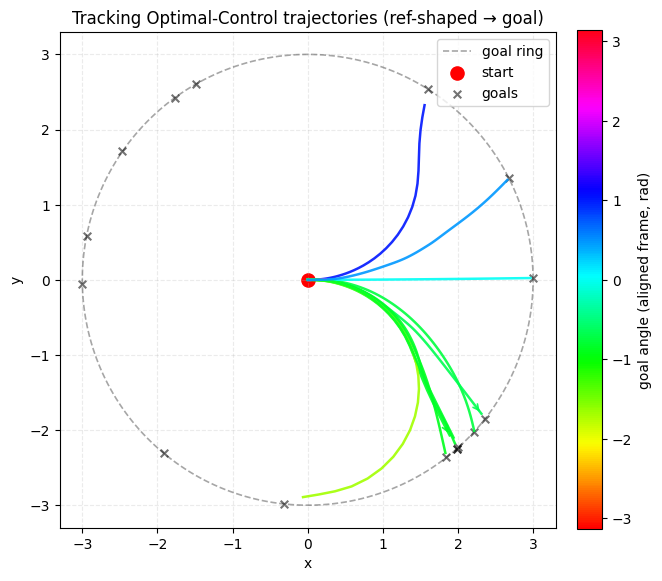

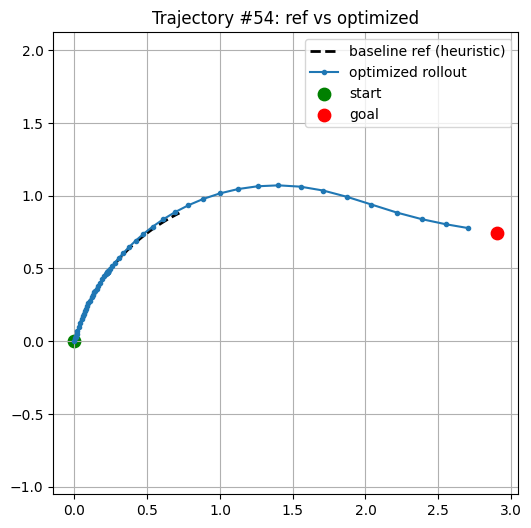

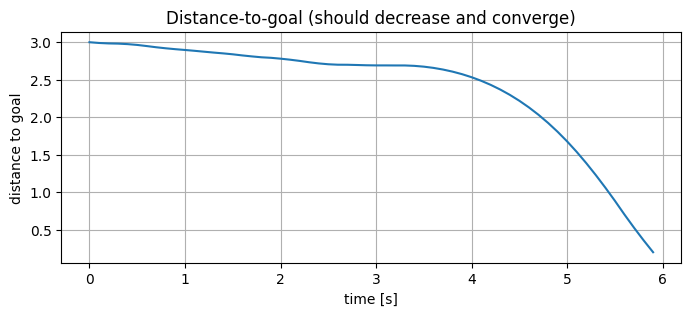

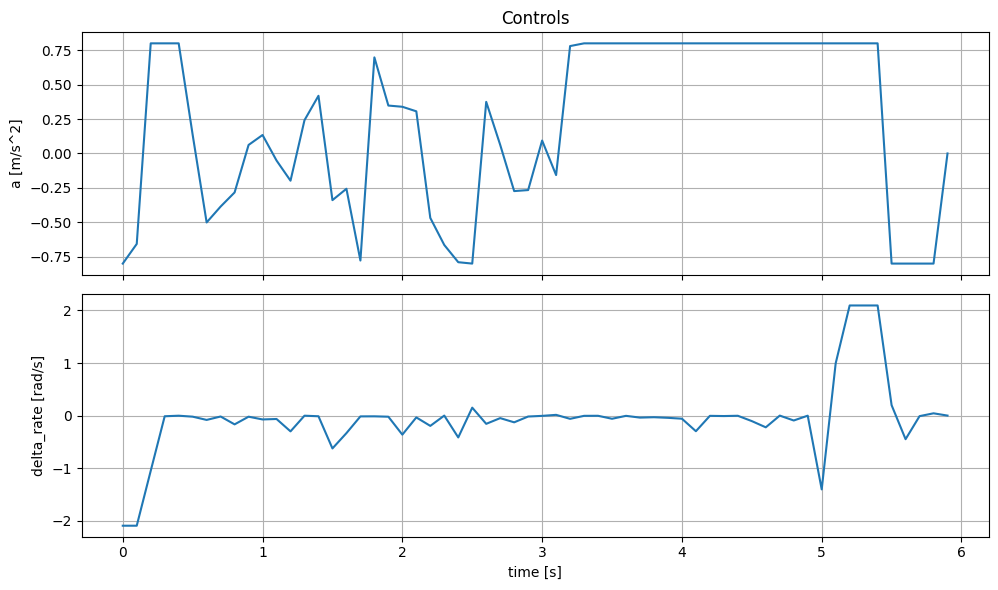

In [16]:
import numpy as np
from scipy.optimize import minimize
import os
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# =========================
# Utils
# =========================
def _wrap_to_pi(a):
    return (a + np.pi) % (2*np.pi) - np.pi

# =========================
# 1) Vehicle rollout (bicycle)
# =========================
def simulate_vehicle_bicycle(
    x0,            # [x,y,theta,v,delta]
    u_seq,         # (T-1,2) = [a, delta_rate]
    dt,
    L,    # 轴距
    delta_max,
    v_min=0.0, # 不允许倒车 负速度
):
    u_seq = np.asarray(u_seq, dtype=np.float64)  # 转换成 numpy
    Tm1 = u_seq.shape[0]
    T = Tm1 + 1

    states = np.zeros((T, 5), dtype=np.float64)
    states[0] = np.asarray(x0, dtype=np.float64)

    for k in range(Tm1):
        x, y, th, v, delta = states[k]
        a, delta_rate = u_seq[k]

        # steering integration
        delta_next = delta + dt * delta_rate
        delta_next = np.clip(delta_next, -delta_max, delta_max)

        # speed integration
        v_next = v + dt * a
        v_next = max(v_min, v_next)

        # kinematic bicycle
        th_next = _wrap_to_pi(th + dt * (v / L) * np.tan(delta))
        x_next = x + dt * v * np.cos(th)
        y_next = y + dt * v * np.sin(th)

        states[k+1] = [x_next, y_next, th_next, v_next, delta_next]

    return states

# =========================
# 2) Baseline reference (the "goal-attracted" curve you like)
# =========================
def make_baseline_reference_bicycle(
    start_xy, theta0, goal_xy,
    T, dt, L, delta_max, delta_rate_max,
    v_ref,
    turn_scale=3.0,
    k_theta=3.0,
):
    x, y = float(start_xy[0]), float(start_xy[1])
    theta = float(theta0)
    delta = 0.0

    dir_init = np.array([np.cos(theta0), np.sin(theta0)], dtype=np.float64)
    ref_xy = np.zeros((T, 2), dtype=np.float64)
    ref_xy[0] = [x, y]

    for t in range(1, T):
        vec_goal = goal_xy - np.array([x, y], dtype=np.float64)
        dist = float(np.linalg.norm(vec_goal) + 1e-8)
        dir_goal = vec_goal / dist

        w = np.exp(-t / (T / turn_scale))
        dir_mix = w * dir_init + (1.0 - w) * dir_goal
        dir_mix /= np.linalg.norm(dir_mix) + 1e-8

        theta_ref = float(np.arctan2(dir_mix[1], dir_mix[0]))

        # heading P-control -> yaw_rate_des -> delta*
        e_theta = _wrap_to_pi(theta_ref - theta)
        yaw_rate_des = k_theta * e_theta
        delta_star = np.arctan2(L * yaw_rate_des, max(v_ref, 1e-6))
        delta_star = np.clip(delta_star, -delta_max, delta_max)

        # delta rate limit
        max_delta_step = delta_rate_max * dt
        delta += np.clip(delta_star - delta, -max_delta_step, max_delta_step)
        delta = np.clip(delta, -delta_max, delta_max)

        # bicycle rollout with v_ref
        x += v_ref * np.cos(theta) * dt
        y += v_ref * np.sin(theta) * dt
        theta = _wrap_to_pi(theta + (v_ref / L) * np.tan(delta) * dt)

        ref_xy[t] = [x, y]

    return ref_xy

# =========================
# 3) Tracking optimal control cost
# =========================
def make_cost_function_tracking(
    dt, L, delta_max,
    ref_xy, goal_xy,
    tau_track=15.0,
    w_track=80.0,
    w_goal_terminal=1200.0,
    w_v_terminal=120.0,
    w_u=0.02,
    w_delta_stage=0.1,
):
    T = ref_xy.shape[0]
    ts = np.arange(T, dtype=np.float64)
    wt = np.exp(-ts / tau_track)  # early strong, later weak

    def cost(u_flat, x0, theta_goal_unused, control_steps):
        u_seq = u_flat.reshape((control_steps, 2))
        states = simulate_vehicle_bicycle(
            x0=x0, u_seq=u_seq, dt=dt, L=L, delta_max=delta_max, v_min=0.0
        )

        x = states[:, 0]
        y = states[:, 1]
        v = states[:, 3]
        delta = states[:, 4]

        # tracking (position)
        ex = x - ref_xy[:, 0]
        ey = y - ref_xy[:, 1]
        track_err2 = ex*ex + ey*ey
        J_track = w_track * np.sum(wt * track_err2)

        # terminal goal + stop
        xf, yf, _, vf, _ = states[-1]
        pos_goal = (xf - goal_xy[0])**2 + (yf - goal_xy[1])**2
        J_terminal = w_goal_terminal * pos_goal + w_v_terminal * (vf*vf)

        # control effort + steering magnitude
        J_u = w_u * np.sum(u_seq*u_seq)
        J_delta = w_delta_stage * np.sum(delta*delta)

        return J_track + J_terminal + J_u + J_delta

    return cost

# =========================
# 4) Dataset generation (tracking OC)
# =========================
def make_center_to_ring_dataset_tracking_oc(
    N=100,
    T=60,
    start=(0.0, 0.0),
    goal_center=(0.0, 0.0),
    radius=3.0,
    seed=42,
    save_filename="car_ring_track_oc_dataset.npy",
    LOAD_SAVED_DATA=False,

    # vehicle
    dt=0.1,
    L=0.8,
    delta_max=np.deg2rad(30.0),
    a_max=0.8,
    delta_rate_max=np.deg2rad(120.0),

    # initial speed range in x0 (important)
    v0_min=0.15,
    v0_max=0.6,

    # baseline ref params
    turn_scale=3.0,
    k_theta=3.0,

    # tracking cost params
    tau_track_ratio=0.8,   # tau_track = ratio*T
    w_track=160,
    w_goal_terminal=3500,
    w_v_terminal=120.0,
    w_u=0.02,
    w_delta_stage=0.1,

    # optimizer
    maxiter=600,
):
    rng = np.random.default_rng(seed)

    if LOAD_SAVED_DATA and os.path.exists(save_filename):
        print("Loading:", save_filename)
        return np.load(save_filename, allow_pickle=True).item()

    # goals on ring
    gc = np.array(goal_center, dtype=np.float64)
    phi = np.linspace(-np.pi, np.pi, N, endpoint=False).astype(np.float64)
    goals = gc + radius * np.stack([np.cos(phi), np.sin(phi)], axis=1)

    # initial headings
    thetas0 = rng.uniform(-np.pi, np.pi, size=N).astype(np.float64)

    control_steps = T - 1
    bounds = []
    for _ in range(control_steps):
        bounds.append((-a_max, a_max))
        bounds.append((-delta_rate_max, delta_rate_max))

    traj_xy = np.zeros((N, 2, T), dtype=np.float64)
    states_all = np.zeros((N, T, 5), dtype=np.float64)
    controls_all = np.zeros((N, T, 2), dtype=np.float64)
    refs_all = np.zeros((N, T, 2), dtype=np.float64)

    x0_global, y0_global = float(start[0]), float(start[1])

    print("Generating tracking optimal-control ring dataset ...")
    for i in range(N):
        goal = goals[i]
        theta0 = float(thetas0[i])

        # initial state
        v0_i = float(rng.uniform(float(v0_min), float(v0_max)))
        x0 = np.array([x0_global, y0_global, theta0, v0_i, 0.0], dtype=np.float64)

        # baseline reference speed: use the same v0_i
        v_ref = float(x0[3])

        # baseline ref trajectory (the shape you like)
        ref_xy = make_baseline_reference_bicycle(
            start_xy=np.array([x0_global, y0_global], dtype=np.float64),
            theta0=theta0,
            goal_xy=goal,
            T=T,
            dt=dt,
            L=L,
            delta_max=delta_max,
            delta_rate_max=delta_rate_max,
            v_ref=v_ref,
            turn_scale=turn_scale,
            k_theta=k_theta,
        )
        refs_all[i] = ref_xy

        # tracking cost for this trajectory
        cost_fn = make_cost_function_tracking(
            dt=dt, L=L, delta_max=delta_max,
            ref_xy=ref_xy, goal_xy=goal,
            tau_track=tau_track_ratio * T,
            w_track=w_track,
            w_goal_terminal=w_goal_terminal,
            w_v_terminal=w_v_terminal,
            w_u=w_u,
            w_delta_stage=w_delta_stage,
        )

        # initial guess
        u0 = np.zeros(control_steps * 2, dtype=np.float64)

        # optimize
        res = minimize(
            fun=cost_fn,
            x0=u0,
            args=(x0, 0.0, control_steps),  # theta_goal unused
            method="SLSQP",
            bounds=bounds,
            options={"maxiter": maxiter, "ftol": 1e-6, "disp": False},
        )

        u_opt = res.x.reshape((control_steps, 2))
        states = simulate_vehicle_bicycle(
            x0=x0, u_seq=u_opt, dt=dt, L=L, delta_max=delta_max, v_min=0.0
        )

        states_all[i] = states
        traj_xy[i, 0, :] = states[:, 0]
        traj_xy[i, 1, :] = states[:, 1]

        controls_padded = np.zeros((T, 2), dtype=np.float64)
        controls_padded[:-1] = u_opt
        controls_all[i] = controls_padded

        if (i + 1) % max(1, N // 10) == 0:
            print(f"{(i+1)/N*100:.0f}% ({i+1}/{N}) done. last success={res.success}")

    data = {
        "traj_xy": traj_xy.astype(np.float32),
        "states": states_all.astype(np.float32),
        "controls": controls_all.astype(np.float32),
        "refs_xy": refs_all.astype(np.float32),
        "goals": goals.astype(np.float32),
        "theta0": thetas0.astype(np.float32),
        "params": {
            "dt": float(dt), "L": float(L), "delta_max": float(delta_max),
            "a_max": float(a_max), "delta_rate_max": float(delta_rate_max),
            "T": int(T), "N": int(N), "radius": float(radius),
            "start": start, "goal_center": goal_center,
            "v0_min": float(v0_min),
            "v0_max": float(v0_max),
            "turn_scale": float(turn_scale), "k_theta": float(k_theta),
            "tau_track_ratio": float(tau_track_ratio),
            "w_track": float(w_track),
            "w_goal_terminal": float(w_goal_terminal),
            "w_v_terminal": float(w_v_terminal),
            "w_u": float(w_u),
            "w_delta_stage": float(w_delta_stage),
            "save_filename": save_filename,
        }
    }

    np.save(save_filename, data, allow_pickle=True)
    print("Saved:", save_filename)
    return data

# =========================
# 5) Plotting cells
# =========================
def plot_all_trajs_timecolor(
    traj_xy,
    goals,
    title,
    theta0=None,
    n_show=16,
    arrow_every=4,
    show_circle=True,
    align_start_to_right=True,
):
    """Dataset overview plot in the style you sketched.

    Key visualization idea:
    - translate start -> origin
    - (optionally) rotate each trajectory so its initial heading points to +x (right)
      so the plot shows: "go straight right first, then turn by different angles".

    Notes:
    - This is ONLY a plotting transform. Simulation/control logic is unchanged.

    Args:
      traj_xy: (N,2,T)
      goals:   (N,2)
      theta0:  (N,) optional. If given and align_start_to_right=True, we rotate by -theta0.
      n_show:  how many trajectories to display (spread over angles)
    """
    traj_xy = np.asarray(traj_xy, dtype=np.float64)
    goals = np.asarray(goals, dtype=np.float64)

    N, _, T = traj_xy.shape

    def _rot2(a):
        ca, sa = float(np.cos(a)), float(np.sin(a))
        return np.array([[ca, -sa], [sa, ca]], dtype=np.float64)

    # choose an ordering angle (for selecting a representative subset)
    if theta0 is not None:
        base_angles = np.asarray(theta0, dtype=np.float64)
    else:
        base_angles = np.arctan2(goals[:, 1], goals[:, 0]).astype(np.float64)

    n_show = int(min(max(1, n_show), N))
    order = np.argsort(base_angles)
    pick = order[np.linspace(0, N - 1, n_show).astype(int)]

    fig, ax = plt.subplots(figsize=(7, 7))

    # dashed ring (goal radius)
    if show_circle:
        r = float(np.mean(np.linalg.norm(goals, axis=1)))
        tt = np.linspace(0.0, 2 * np.pi, 256)
        ax.plot(r * np.cos(tt), r * np.sin(tt), "k--", alpha=0.35, linewidth=1.2, label="goal ring")

    # start point is always origin after alignment
    ax.scatter([0.0], [0.0], s=90, c="red", label="start")

    cmap = plt.cm.hsv
    norm = Normalize(vmin=-np.pi, vmax=np.pi)

    # If theta0 is NOT provided, DO NOT infer per-trajectory heading from the first segment.
    # That inference tends to rotate each trajectory so its goal points to +x,
    # collapsing the whole dataset to the right (exactly the issue you saw).
    if align_start_to_right and theta0 is None:
        print("[plot_all_trajs_timecolor] WARNING: theta0 is None; alignment disabled to avoid collapsing the plot.")

    # plot trajectories (aligned frame)
    aligned_goals = []
    for k, i in enumerate(pick):
        xy = traj_xy[i].T  # (T,2)
        start = xy[0].copy()
        goal = goals[i].copy()

        # translate
        xy0 = xy - start[None, :]
        g0 = goal - start

        # rotate so initial heading is +x (only if theta0 is provided)
        if align_start_to_right and (theta0 is not None):
            a = float(theta0[i])
            R = _rot2(-a)
            xy0 = (R @ xy0.T).T
            g0 = (R @ g0.reshape(2, 1)).reshape(2)

        aligned_goals.append(g0.copy())

        # color by goal direction (after alignment)
        ang = float(np.arctan2(g0[1], g0[0]))
        c = cmap(norm(ang))

        ax.plot(xy0[:, 0], xy0[:, 1], color=c, alpha=0.9, linewidth=1.8)

        # arrow head occasionally
        if arrow_every > 0 and (k % int(arrow_every) == 0) and T >= 2:
            ax.annotate(
                "",
                xy=(float(xy0[-1, 0]), float(xy0[-1, 1])),
                xytext=(float(xy0[-2, 0]), float(xy0[-2, 1])),
                arrowprops=dict(arrowstyle="->", color=c, lw=1.2, alpha=0.9),
            )

    # show ALL goals (aligned in the same frame) for context
    aligned_goals = np.asarray(aligned_goals, dtype=np.float64)
    ax.scatter(aligned_goals[:, 0], aligned_goals[:, 1], s=30, marker="x", c="black", alpha=0.55, label="goals")

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.25)

    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("goal angle (aligned frame, rad)")

    ax.legend(loc="best")
    plt.show()


def plot_one_compare(data, idx=None):
    traj_xy = data["traj_xy"]
    refs_xy = data["refs_xy"]
    goals = data["goals"]
    controls = data["controls"]
    dt = data["params"]["dt"]

    N, _, T = traj_xy.shape
    if idx is None:
        idx = np.random.randint(N)

    xy = traj_xy[idx].T    # (T,2)
    ref = refs_xy[idx]     # (T,2)
    goal = goals[idx]
    u = controls[idx]      # (T,2)

    # 1) XY compare
    plt.figure(figsize=(6,6))
    plt.plot(ref[:,0], ref[:,1], "k--", linewidth=2, label="baseline ref (heuristic)")
    plt.plot(xy[:,0], xy[:,1], "-o", markersize=3, label="optimized rollout")
    plt.scatter(xy[0,0], xy[0,1], c="green", s=80, label="start")
    plt.scatter(goal[0], goal[1], c="red", s=80, label="goal")
    plt.axis("equal")
    plt.grid(True)
    plt.title(f"Trajectory #{idx}: ref vs optimized")
    plt.legend()
    plt.show()

    # 2) distance to goal over time
    dist = np.linalg.norm(xy - goal[None,:], axis=1)
    plt.figure(figsize=(8,3))
    plt.plot(np.arange(T)*dt, dist)
    plt.grid(True)
    plt.xlabel("time [s]")
    plt.ylabel("distance to goal")
    plt.title("Distance-to-goal (should decrease and converge)")
    plt.show()

    # 3) controls
    t = np.arange(T)*dt
    fig, axs = plt.subplots(2, 1, figsize=(10,6), sharex=True)
    axs[0].plot(t, u[:,0])
    axs[0].set_ylabel("a [m/s^2]")
    axs[0].grid(True)
    axs[0].set_title("Controls")

    axs[1].plot(t, u[:,1])
    axs[1].set_ylabel("delta_rate [rad/s]")
    axs[1].set_xlabel("time [s]")
    axs[1].grid(True)
    plt.tight_layout()
    plt.show()

# =========================
# RUN (generate + plot)
# =========================
save_filename = "car_ring_track_oc_dataset_v1_v0rand.npy"   # ✅ 你要的“新文件名”就在这里改

data = make_center_to_ring_dataset_tracking_oc(
    N=100,              # 你可以改大一点
    T=60,               # 你可以改大一点
    radius=3.0,
    save_filename=save_filename,
    LOAD_SAVED_DATA=False,   # True 就直接读文件不重新生成
    v0_min=0.15,             # 初始速度范围（影响整体曲率/是否冲过头）
    v0_max=0.6,
)

# 总览图：只画优化后的轨迹
plot_all_trajs_timecolor(
    data["traj_xy"],
    data["goals"],
    theta0=data["theta0"],
    align_start_to_right=True,
    title="Tracking Optimal-Control trajectories (ref-shaped → goal)"
)

# 单条对比：会出现黑色虚线（baseline ref），这是故意的
plot_one_compare(data, idx=None)


In [14]:
import os
import numpy as np

# ====== input / output filenames ======
IN_NPY  = "car_ring_track_oc_dataset_v1_v0rand.npy"
OUT_NPY = "car_ring_track_oc_dataset_v1_v0rand_with_vel.npy"

assert os.path.exists(IN_NPY), f"Cannot find {IN_NPY}"

data = np.load(IN_NPY, allow_pickle=True).item()

states = np.asarray(data["states"], dtype=np.float32)   # (N,T,5) [x,y,theta,v,delta]
theta  = states[..., 2]
v      = states[..., 3]
delta  = states[..., 4]

# --- vel_xy in WORLD frame ---
vx = v * np.cos(theta)
vy = v * np.sin(theta)

vel_xy_NT2 = np.stack([vx, vy], axis=-1).astype(np.float32)   # (N,T,2)

# training-friendly layout
vel_xy_N2T = np.transpose(vel_xy_NT2, (0, 2, 1)).astype(np.float32)  # (N,2,T)

# also provide a "control-aligned" version (T-1)
vel_xy_Tm1 = vel_xy_NT2[:, :-1, :].astype(np.float32)          # (N,T-1,2)
vel_xy_Tm1_N2T = np.transpose(vel_xy_Tm1, (0, 2, 1)).astype(np.float32)  # (N,2,T-1)

data["vel_xy"] = vel_xy_NT2                 # keep your original
data["vel_xy_N2T"] = vel_xy_N2T             # convenient for Conv1d
data["vel_xy_Tm1"] = vel_xy_Tm1             # convenient aligned with control_steps
data["vel_xy_Tm1_N2T"] = vel_xy_Tm1_N2T     # best default for training

# --- optional: yaw rate omega (world yaw rate) ---
L = float(data["params"]["L"])
omega = (v / (L + 1e-9)) * np.tan(delta)
data["omega"] = omega.astype(np.float32)                 # (N,T)

np.save(OUT_NPY, data, allow_pickle=True)

print("Saved:", OUT_NPY)
print("keys:", [k for k in data.keys() if "vel" in k or k in ["states","omega","controls","traj_xy","goals","params"]])
print("states:", data["states"].shape)
print("vel_xy (N,T,2):", data["vel_xy"].shape)
print("vel_xy_N2T (N,2,T):", data["vel_xy_N2T"].shape)
print("vel_xy_Tm1_N2T (N,2,T-1):", data["vel_xy_Tm1_N2T"].shape)
print("omega:", data["omega"].shape)
print("dt:", data["params"]["dt"], "T:", data["params"]["T"])


Saved: car_ring_track_oc_dataset_v1_v0rand_with_vel.npy
keys: ['traj_xy', 'states', 'controls', 'goals', 'params', 'vel_xy', 'vel_xy_N2T', 'vel_xy_Tm1', 'vel_xy_Tm1_N2T', 'omega']
states: (100, 60, 5)
vel_xy (N,T,2): (100, 60, 2)
vel_xy_N2T (N,2,T): (100, 2, 60)
vel_xy_Tm1_N2T (N,2,T-1): (100, 2, 59)
omega: (100, 60)
dt: 0.1 T: 60


In [9]:
# ===============================================================
# NEW CELL (ORIGINAL-VEL, NO VIRTUAL OBSTACLE):
# Goal-canonicalization for VELOCITY sequences
#
# Reads:  car_ring_track_oc_dataset_v1_v0rand_with_vel.npy
# Uses:   data["vel_xy"] ONLY  (original world velocity from v,theta)
#
# Output dataset:
#   - v_seq_can : (2, T-1)  [vx, vy] in canonical frame (channel-first for Conv1d)
#   - cond      : (5,)      [goal_dist, v0, cos(theta0_can), sin(theta0_can), delta0_can]
#   - meta      : dict      for de-canonicalization (back to world)
# ===============================================================

import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# ---------- load ----------
IN_NPY = "car_ring_track_oc_dataset_v1_v0rand_with_vel.npy"
assert os.path.exists(IN_NPY), f"Cannot find {IN_NPY}"

data = np.load(IN_NPY, allow_pickle=True).item()
assert "states" in data and "goals" in data and "params" in data, "File missing required keys: states/goals/params"
assert "vel_xy" in data, "data['vel_xy'] missing. Re-generate with the vel-saving cell."

states_np = np.asarray(data["states"], dtype=np.float32)   # (N,T,5) [x,y,theta,v,delta]
goals_np  = np.asarray(data["goals"],  dtype=np.float32)   # (N,2)
dt_data   = float(data["params"].get("dt", 0.1))

N, T, D = states_np.shape
assert D == 5, f"states last dim must be 5, got {D}"

# ---------- ORIGINAL velocity ONLY ----------
# vel_xy: (N,T,2) -> transpose to (N,2,T) -> cut to (N,2,T-1)
vel_nt2 = np.asarray(data["vel_xy"], dtype=np.float32)     # (N,T,2)
assert vel_nt2.ndim == 3 and vel_nt2.shape == (N, T, 2), f"data['vel_xy'] must be (N,T,2), got {vel_nt2.shape}"
v_xy_np = np.transpose(vel_nt2, (0, 2, 1))[:, :, :-1]      # (N,2,T-1)
assert v_xy_np.shape == (N, 2, T-1), f"expect (N,2,T-1)={(N,2,T-1)}, got {v_xy_np.shape}"

print("[canon-vel-noobs] loaded:", IN_NPY)
print("[canon-vel-noobs] states:", states_np.shape, "goals:", goals_np.shape, "v_xy:", v_xy_np.shape, "dt:", dt_data)

# ---------- geometry utils ----------
def _wrap_pi(a: float) -> float:
    return float((a + np.pi) % (2 * np.pi) - np.pi)

def _rot2(a: float) -> np.ndarray:
    ca, sa = float(np.cos(a)), float(np.sin(a))
    return np.array([[ca, -sa], [sa, ca]], dtype=np.float64)

def canonicalize_episode_velocity_noobs(states_T5, vxy_2xTm1, goal_xy):
    """
    states_T5:   (T,5) [x,y,theta,v,delta] in world
    vxy_2xTm1:   (2,T-1) [vx,vy] in world
    goal_xy:     (2,)
    Returns:
      v_can:      (2,T-1) in canonical frame (goal-aligned)
      cond:       (5,)    [goal_dist, v0, cos(theta0_can), sin(theta0_can), delta0_can]
      meta:       dict    for inverse mapping
    """
    st  = np.asarray(states_T5, dtype=np.float64)
    vxy = np.asarray(vxy_2xTm1, dtype=np.float64)
    g   = np.asarray(goal_xy, dtype=np.float64).reshape(2)

    start_xy = st[0, :2].copy()

    # translate for geometry (vel unaffected by translation)
    g0 = g - start_xy

    # rotate so goal lies on +x
    phi = float(np.arctan2(g0[1], g0[0]))
    R = _rot2(-phi)

    # rotate velocities (2,T-1)
    v_can = (R @ vxy).astype(np.float64)

    # canonicalize theta0 for conditioning
    theta0 = float(st[0, 2])
    delta0 = float(st[0, 4])

    theta0_can = _wrap_pi(theta0 - phi)
    delta0_can = delta0

    goal_dist = float(np.linalg.norm(g0))
    v0 = float(st[0, 3])

    cond = np.array(
        [goal_dist, v0, float(np.cos(theta0_can)), float(np.sin(theta0_can)), float(delta0_can)],
        dtype=np.float64
    )

    meta = {
        "start_xy": start_xy,
        "phi": phi,
        "goal_dist": goal_dist,
    }
    return v_can, cond, meta

def decanonicalize_vxy(vxy_can_2xTm1, meta):
    """(2,T-1) canonical -> (2,T-1) world"""
    v = np.asarray(vxy_can_2xTm1, dtype=np.float64).copy()
    Rinv = _rot2(float(meta["phi"]))
    return (Rinv @ v)

# ---------- dataset ----------
class GoalCanonicalVelocityDataset(Dataset):
    def __init__(
        self,
        states: np.ndarray,     # (N,T,5)
        v_xy: np.ndarray,       # (N,2,T-1)
        goals: np.ndarray,      # (N,2)
        *,
        return_meta: bool = False,
    ):
        self.states = np.asarray(states, dtype=np.float64)
        self.v_xy   = np.asarray(v_xy, dtype=np.float64)
        self.goals  = np.asarray(goals, dtype=np.float64)
        self.return_meta = bool(return_meta)

        assert self.states.ndim == 3 and self.states.shape[2] == 5
        assert self.v_xy.ndim == 3 and self.v_xy.shape[1] == 2
        assert self.goals.ndim == 2 and self.goals.shape[1] == 2
        assert self.states.shape[0] == self.v_xy.shape[0] == self.goals.shape[0]
        assert self.v_xy.shape[2] == (self.states.shape[1] - 1)

    def __len__(self):
        return int(self.states.shape[0])

    def __getitem__(self, idx):
        st = self.states[int(idx)]      # (T,5)
        v  = self.v_xy[int(idx)]        # (2,T-1)
        g  = self.goals[int(idx)]       # (2,)

        v_can, cond, meta = canonicalize_episode_velocity_noobs(st, v, g)

        v_seq = v_can.astype(np.float32)   # (2,T-1)
        cond  = cond.astype(np.float32)    # (5,)

        if self.return_meta:
            return torch.from_numpy(v_seq), torch.from_numpy(cond), meta
        return torch.from_numpy(v_seq), torch.from_numpy(cond)

# ---------- build loader ----------
canon_ds = GoalCanonicalVelocityDataset(
    states_np,
    v_xy_np,
    goals_np,
    return_meta=True,
)

canon_loader = DataLoader(canon_ds, batch_size=64, shuffle=True, drop_last=True)

v_ex, cond_ex, meta_ex = canon_ds[0]
print("Canonical dataset size:", len(canon_ds))
print("v_seq shape:", tuple(v_ex.shape), "cond shape:", tuple(cond_ex.shape))
print("cond = [goal_dist, v0, cos(theta0), sin(theta0), delta0] ->", cond_ex.numpy())
print("meta:", meta_ex)

print("✅ Goal-canonical velocity dataset ready: use `canon_loader` for FM training.")


[canon-vel-noobs] loaded: car_ring_track_oc_dataset_v1_v0rand_with_vel.npy
[canon-vel-noobs] states: (100, 60, 5) goals: (100, 2) v_xy: (100, 2, 59) dt: 0.1
Canonical dataset size: 100
v_seq shape: (2, 59) cond shape: (5,)
cond = [goal_dist, v0, cos(theta0), sin(theta0), delta0] -> [ 3.          0.5588613   0.14995252 -0.9886932   0.        ]
meta: {'start_xy': array([0., 0.]), 'phi': -3.141592653589793, 'goal_dist': 3.0}
✅ Goal-canonical velocity dataset ready: use `canon_loader` for FM training.


In [15]:
# ===============================================================
# NEW CELL: Train a velocity-field UNet on goal-canonical (NO-OBSTACLE) VEL data
#
# Produces: model_vel
#   - input : x_t (B,2,T-1), t (B,), cond (B,5)
#   - output: v_theta (B,2,T-1)  (FM velocity field)
# ===============================================================

import torch
import torch.nn as nn

# ---------- prerequisites ----------
if "canon_loader" not in globals():
    raise RuntimeError("Please run the goal-canonical velocity dataset cell first (it defines `canon_loader`).")

if "SimpleUNet1D" not in globals():
    raise RuntimeError("SimpleUNet1D not found. Please run the UNet definition cell first.")

if "CondOTScheduler" not in globals() or "AffinePath" not in globals():
    raise RuntimeError("Need CondOTScheduler/AffinePath. Please run the FM components cell first.")

# ---------- device ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[train] device:", device)

# ---------- model ----------
COND_DIM = 5  # [goal_dist, v0, cos(theta0_can), sin(theta0_can), delta0_can]
model_vel = SimpleUNet1D(time_emb_dim=128, hidden_dim=128, cond_dim=COND_DIM).to(device)
optimizer_vel = torch.optim.Adam(model_vel.parameters(), lr=1e-3)

scheduler = CondOTScheduler()
path = AffinePath(scheduler)

# ---------- training hyperparams ----------
EPOCHS = 20
LOG_EVERY = 50
GRAD_CLIP = 1.0

# ---------- infer shapes once ----------
batch_ex = next(iter(canon_loader))
traj_seq_ex, cond_ex = batch_ex[0], batch_ex[1]   # (B,2,Tm1), (B,5)   (meta may exist at batch_ex[2])
Tm1 = int(traj_seq_ex.shape[-1])

print("[train] example traj:", tuple(traj_seq_ex.shape), "cond:", tuple(cond_ex.shape))
if int(traj_seq_ex.shape[1]) != 2:
    raise RuntimeError(f"Expected traj_seq channel=2 (vx,vy). Got {traj_seq_ex.shape}.")
if int(cond_ex.shape[-1]) != COND_DIM:
    raise RuntimeError(f"Expected cond_dim={COND_DIM}. Got {cond_ex.shape}.")

# ---------- training loop ----------
model_vel.train()
step = 0

for ep in range(int(EPOCHS)):
    for batch in canon_loader:
        traj_seq, cond = batch[0], batch[1]   # ignore meta if present
        traj_seq = traj_seq.to(device)        # (B,2,T-1)
        cond = cond.to(device)                # (B,5)

        # safety checks (catch silent mismatch early)
        if traj_seq.ndim != 3 or traj_seq.shape[1] != 2:
            raise RuntimeError(f"traj_seq must be (B,2,Tm1). Got {traj_seq.shape}")
        if cond.ndim != 2 or cond.shape[1] != COND_DIM:
            raise RuntimeError(f"cond must be (B,{COND_DIM}). Got {cond.shape}")

        B = traj_seq.shape[0]

        # endpoints for Conditional OT FM
        x0 = torch.randn_like(traj_seq)       # noise endpoint
        x1 = traj_seq                          # data endpoint

        # sample time
        t = torch.rand(B, device=device)       # (B,)

        # sample path
        ps = path.sample(x0, x1, t)
        x_t = ps.x_t                           # (B,2,T-1)
        dx_t = ps.dx_t                         # (B,2,T-1) target velocity field along path

        # predict
        v_pred = model_vel(x_t, t, cond=cond)

        # loss
        loss = torch.mean((v_pred - dx_t) ** 2)

        optimizer_vel.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_vel.parameters(), float(GRAD_CLIP))
        optimizer_vel.step()

        if step % int(LOG_EVERY) == 0:
            print(f"[train model_vel] ep={ep} step={step} loss={loss.item():.6f}")

        step += 1

print("✅ Trained `model_vel` (goal-canonical, obstacle-free, velocity-field FM).")


[train] device: cuda
[train] example traj: (64, 2, 59) cond: (64, 5)
[train model_vel] ep=0 step=0 loss=1.286724
✅ Trained `model_vel` (goal-canonical, obstacle-free, velocity-field FM).


In [7]:
# ===============================================================
# Cell 1: 基础组件 - Mish, SinusoidalPosEmb, ResBlock1D
# ===============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from fmtorch.models.simple1d_unet import Mish, SinusoidalPosEmb, ResBlock1D, SimpleUNet1D


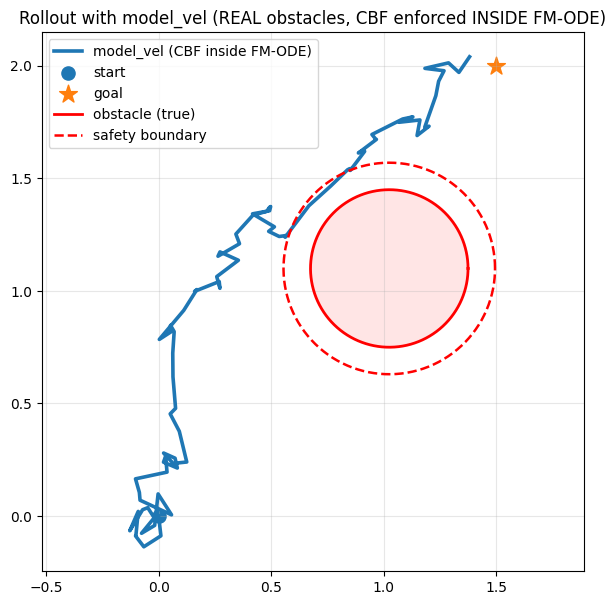

In [18]:
# ===============================================================
# NEW CELL: MPC rollout using trained `model_vel` (velocity-field FM)
# - canonicalize (pos, goal) -> cond (5,)  [obstacle-free model]
# - sample v_seq in CANONICAL frame with torchdiffeq.odeint over t in [0,1] (FM time)
# - REAL obstacles are kept, but ONLY used by CBF INSIDE the ODE function
# - outer loop executes only v0_safe (NO external CBF anymore)
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
import torchdiffeq

# -------- prerequisites --------
if "model_vel" not in globals():
    raise RuntimeError("model_vel not found. Please run the velocity-UNet training cell first.")

if "cbf_project_velocity_world" not in globals():
    raise RuntimeError("cbf_project_velocity_world not found. Please run the CBF velocity projection cell first.")

# -------- helpers --------
def _wrap_pi(a: float) -> float:
    return float((a + np.pi) % (2 * np.pi) - np.pi)

def _rot2(a: float) -> np.ndarray:
    ca, sa = float(np.cos(a)), float(np.sin(a))
    return np.array([[ca, -sa], [sa, ca]], dtype=np.float64)

def _circle_list_to_ellipses(circles):
    ell = []
    for c in circles:
        if isinstance(c, dict):
            center = np.asarray(c["center"], dtype=np.float64).reshape(2)
            radius = float(c["radius"])
        else:
            cx, cy, r = c
            center = np.asarray([cx, cy], dtype=np.float64)
            radius = float(r)
        ell.append({"center": center, "radius": radius})
    return ell

def canonicalize_runtime_goal_vel(state_xy, goal_xy, *, v0=0.0, theta0=0.0, delta0=0.0):
    """
    Obstacle-FREE canonicalization for model_vel cond (5):
      cond = [goal_dist, v0, cos(theta0_can), sin(theta0_can), delta0_can]
    meta = {phi, reflect, p_world}
    """
    p = np.asarray(state_xy, dtype=np.float64).reshape(2)
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)

    g0 = g - p
    goal_dist = float(np.linalg.norm(g0) + 1e-12)

    # rotate so goal lies on +x
    phi = float(np.arctan2(g0[1], g0[0]))
    R = _rot2(-phi)
    g_can = (R @ g0.reshape(2, 1)).reshape(2)

    # reflect rule without obstacle: make goal y >= 0 (optional symmetry break)
    reflect = False
    if float(g_can[1]) < 0.0:
        reflect = True
        g_can[1] *= -1.0

    theta0_can = _wrap_pi(float(theta0) - phi)
    delta0_can = float(delta0)
    if reflect:
        theta0_can = -theta0_can
        delta0_can = -delta0_can

    cond = np.array(
        [
            goal_dist,
            float(v0),
            float(np.cos(theta0_can)),
            float(np.sin(theta0_can)),
            float(delta0_can),
        ],
        dtype=np.float32,
    )
    meta = {"phi": phi, "reflect": reflect, "p_world": p}
    return cond, meta

def decanonicalize_vxy(v_can_2, meta):
    """(2,) canonical -> (2,) world"""
    v = np.asarray(v_can_2, dtype=np.float64).reshape(2).copy()
    if bool(meta.get("reflect", False)):
        v[1] *= -1.0
    Rinv = _rot2(float(meta["phi"]))
    return (Rinv @ v.reshape(2, 1)).reshape(2)

def world_to_canonical_vxy(v_world_2, meta):
    """(2,) world -> (2,) canonical (inverse of decanonicalize)"""
    v = np.asarray(v_world_2, dtype=np.float64).reshape(2).copy()
    # reflect in world->canonical: same sign flip on y if reflected
    if bool(meta.get("reflect", False)):
        v[1] *= -1.0
    R = _rot2(-float(meta["phi"]))
    return (R @ v.reshape(2, 1)).reshape(2)

# ---------------------------------------------------------------
# Outer loop: execute only v0_safe (safe enforced INSIDE ODE)
# ---------------------------------------------------------------
def mpc_rollout_model_vel_with_cbf_inside_ode(
    x0_xy,
    goal_xy,
    *,
    circles,
    dt=0.1,
    v_max=1.4,
    max_total_steps=400,
    goal_tol=0.15,
    # FM ODE sampling
    seq_T=8,
    n_steps_sample=30,
    noise_scale=1.0,
    device="cpu",
    solver_method="euler",
    solver_tol=1e-5,
    # CBF params (inside ODE)
    safety_margin=0.12,
    gamma_min=6.0,
    max_corr_norm=10.0,
):
    x = np.asarray(x0_xy, dtype=np.float64).reshape(2)
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)

    ellipses_true = _circle_list_to_ellipses(circles)
    xs = [x.copy()]

    # FM time grid: ALWAYS 0->1 (do not use world time)
    T_SPAN = torch.linspace(0.0, 1.0, int(n_steps_sample) + 1)

    dev = torch.device(device)

    # ---- ODE sampling WITH CBF INSIDE (closure captures dt) ----
    @torch.no_grad()
    def sample_v_seq_safe_odeint(*, model, cond, x_world_now_2, meta):
        """
        Returns:
          v_seq_can: (seq_T,2)  canonical velocities
        """
        model.eval()

        cond_t = torch.as_tensor(cond, dtype=torch.float32, device=dev).view(1, -1)

        # ODE state is a WHOLE sequence (1,2,seq_T)
        x0 = torch.randn(1, 2, int(seq_T), device=dev) * float(noise_scale)

        t_span = T_SPAN.to(dev)
        if t_span.numel() < 2:
            raise ValueError("T_SPAN must have at least 2 points.")
        dt_ode = float((t_span[1] - t_span[0]).item())

        x_world_now_2 = np.asarray(x_world_now_2, dtype=np.float64).reshape(2)

        def fm_ode_func(t, x_flat):
            # reshape ODE state
            vseq_can = x_flat.view(1, 2, int(seq_T))  # (1,2,T)
            t_tensor = torch.tensor([t], device=vseq_can.device, dtype=vseq_can.dtype)

            # nominal FM velocity field in SEQ-space
            dv_nom = model(vseq_can, t_tensor, cond=cond_t)  # (1,2,T)

            # ---- internal shielding: project the NEXT Euler sequence ----
            vseq_can_next = (vseq_can + dt_ode * dv_nom).detach().cpu().numpy()[0]  # (2,T)

            x_sim = x_world_now_2.copy()
            vseq_can_safe = np.zeros_like(vseq_can_next)  # (2,T)

            for k in range(int(seq_T)):
                v_can_k = vseq_can_next[:, k].copy()              # (2,)
                v_world_k = decanonicalize_vxy(v_can_k, meta=meta)  # (2,)

                # CBF one-step projection in WORLD
                x_traj = torch.tensor(x_sim, dtype=torch.float32, device=dev).view(1, 2, 1)
                v_traj = torch.tensor(v_world_k, dtype=torch.float32, device=dev).view(1, 2, 1)

                v_world_safe = cbf_project_velocity_world(
                    x_traj,
                    v_traj,
                    ellipses=ellipses_true,                 # ✅ REAL obstacles
                    extra_margin=float(safety_margin),
                    max_corr_norm=float(max_corr_norm),
                    passes=5,
                    other_agent_traj=None,
                    agent_safe_radius=0.5,
                    gamma_min=float(gamma_min),
                    w_p=0.0,
                    press_k=1.0,
                    press_n=2.0,
                ).detach().cpu().numpy().reshape(2)

                # back to canonical
                v_can_safe_k = world_to_canonical_vxy(v_world_safe, meta=meta)

                vseq_can_safe[:, k] = v_can_safe_k

                # rollout world position using SAFE world velocity (world dt, NOT FM t)
                x_sim = x_sim + float(dt) * v_world_safe

            # define dv_safe so Euler step lands on safe sequence
            vseq_can_safe_t = torch.as_tensor(
                vseq_can_safe, dtype=vseq_can.dtype, device=vseq_can.device
            ).unsqueeze(0)  # (1,2,T)

            dv_safe = (vseq_can_safe_t - vseq_can) / max(dt_ode, 1e-9)
            return dv_safe.view(-1)

        sol = torchdiffeq.odeint(
            fm_ode_func,
            x0.view(-1),
            t_span,
            atol=float(solver_tol),
            rtol=float(solver_tol),
            method=str(solver_method),
        )

        v_final_can = sol[-1].view(1, 2, int(seq_T))
        return v_final_can[0].detach().cpu().numpy().T.astype(np.float64)  # (T,2)

    # ---- MPC loop ----
    for _ in range(int(max_total_steps)):
        if float(np.linalg.norm(x - g)) <= float(goal_tol):
            break

        # cond is obstacle-free (5D)
        cond, meta = canonicalize_runtime_goal_vel(
            x, g,
            v0=0.0,
            theta0=0.0,
            delta0=0.0,
        )

        # sample canonical velocity seq (CBF enforced INSIDE ODE)
        v_seq_can = sample_v_seq_safe_odeint(
            model=model_vel,
            cond=cond,
            x_world_now_2=x,
            meta=meta,
        )  # (seq_T,2)

        # execute first velocity (already safe) -> world
        v0_world = decanonicalize_vxy(v_seq_can[0], meta=meta)
        v0_world = np.clip(v0_world, -float(v_max), float(v_max))

        x = x + float(dt) * v0_world
        xs.append(x.copy())

    return np.asarray(xs, dtype=np.float64), ellipses_true


# -------------------------
# Demo
# -------------------------
if "_s0_xy" in globals():
    _s0_xy_demo = np.asarray(_s0_xy, dtype=np.float64).reshape(2)
else:
    _s0_xy_demo = np.array([0.0, 0.0], dtype=np.float64)

if "_goal" in globals():
    _goal_demo = np.asarray(_goal, dtype=np.float64).reshape(2)
else:
    _goal_demo = np.array([1.5, 2.0], dtype=np.float64)

if "circles" in globals():
    circles_demo = circles
else:
    mid = _s0_xy_demo + 0.55 * (_goal_demo - _s0_xy_demo)
    circles_demo = [{"center": mid + np.array([0.20, 0.0], dtype=np.float64), "radius": 0.35}]

if "data" in globals() and isinstance(data, dict) and "params" in data:
    dt_demo = float(data["params"].get("dt", 0.1))
else:
    dt_demo = 0.1

xs_mpc_vel, circles_true_vel = mpc_rollout_model_vel_with_cbf_inside_ode(
    _s0_xy_demo,
    _goal_demo,
    circles=circles_demo,
    dt=float(dt_demo),
    v_max=1.4,
    max_total_steps=300,
    goal_tol=0.15,
    seq_T=8,
    n_steps_sample=30,
    noise_scale=1.0,
    device=str(globals().get("device", "cpu")),
    solver_method=str(globals().get("SOLVER_METHOD", "euler")),
    solver_tol=float(globals().get("SOLVER_TOLERANCE", 1e-5)),
    safety_margin=float(globals().get("safety_margin", 0.12)),
    gamma_min=6.0,
    max_corr_norm=10.0,
)

# Plot
th_grid = np.linspace(0.0, 2 * np.pi, 360)
plt.figure(figsize=(7, 7))
plt.plot(xs_mpc_vel[:, 0], xs_mpc_vel[:, 1], "-", linewidth=2.6, label="model_vel (CBF inside FM-ODE)")
plt.scatter([xs_mpc_vel[0, 0]], [xs_mpc_vel[0, 1]], s=90, label="start")
plt.scatter([_goal_demo[0]], [_goal_demo[1]], s=180, marker="*", label="goal")

margin = float(globals().get("safety_margin", 0.12))
for e in circles_true_vel:
    c = np.asarray(e["center"], dtype=np.float64).reshape(2)
    R = float(e["radius"])
    plt.plot(c[0] + R * np.cos(th_grid), c[1] + R * np.sin(th_grid), "r-", linewidth=2.0, label="obstacle (true)")
    plt.fill(c[0] + R * np.cos(th_grid), c[1] + R * np.sin(th_grid), color="red", alpha=0.10)
    R_safe = R + margin
    plt.plot(c[0] + R_safe * np.cos(th_grid), c[1] + R_safe * np.sin(th_grid), "r--", linewidth=1.8, label="safety boundary")

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("Rollout with model_vel (REAL obstacles, CBF enforced INSIDE FM-ODE)")
plt.legend()
plt.show()


[rollout] model_vel expects cond_dim = 5


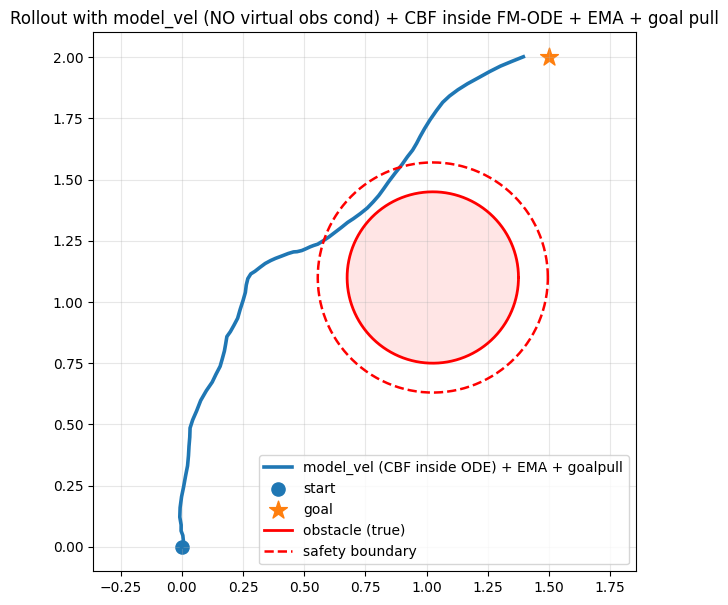

In [19]:
# ===============================================================
# NEW CELL (NO-VIRTUAL-OBS): Rollout with model_vel (CBF inside ODE)
#   + EMA smoothing + Goal Pull
#   + AUTO-ADAPT cond_dim (expects 5 by default) to match your trained model
#
# Key change:
#   - conditioning is GOAL-only (no virtual obstacle, no obs_x/obs_y in cond)
#   - REAL obstacles are still used by CBF INSIDE the ODE
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
import torchdiffeq

# -------------------------
# Prereqs
# -------------------------
if "model_vel" not in globals():
    raise RuntimeError("model_vel not found. (Use your obstacle-free trained velocity-field FM model)")

if "cbf_project_velocity_world" not in globals():
    raise RuntimeError("cbf_project_velocity_world not found.")

# -------------------------
# Utils
# -------------------------
def _wrap_pi(a: float) -> float:
    return float((a + np.pi) % (2 * np.pi) - np.pi)

def _rot2(a: float) -> np.ndarray:
    ca, sa = float(np.cos(a)), float(np.sin(a))
    return np.array([[ca, -sa], [sa, ca]], dtype=np.float64)

def _circle_list_to_ellipses(circles):
    ell = []
    for c in circles:
        if isinstance(c, dict):
            center = np.asarray(c["center"], dtype=np.float64).reshape(2)
            radius = float(c["radius"])
        else:
            cx, cy, r = c
            center = np.asarray([cx, cy], dtype=np.float64)
            radius = float(r)
        ell.append({"center": center, "radius": radius})
    return ell

def _infer_cond_dim(model):
    # Try model.cond_dim first
    if hasattr(model, "cond_dim") and model.cond_dim is not None:
        return int(model.cond_dim)
    # Try to infer from cond_mlp first Linear layer
    cond_mlp = getattr(model, "cond_mlp", None)
    if cond_mlp is not None:
        for layer in cond_mlp:
            if hasattr(layer, "in_features"):
                return int(layer.in_features)
    return None

COND_DIM_MODEL = _infer_cond_dim(model_vel)
if COND_DIM_MODEL is None:
    raise RuntimeError("Could not infer cond_dim from model_vel.")
print(f"[rollout] model_vel expects cond_dim = {COND_DIM_MODEL}")

# -------------------------
# GOAL-only canonicalization (NO virtual obstacle)
#   - define canonical frame by rotating so goal is on +x
#   - optional reflect so goal is on +y (consistent sign convention)
# -------------------------
def canonicalize_runtime_goal_cond(
    xy_world,
    goal_xy,
    *,
    theta0=0.0,
    v0=0.3,
    delta0=0.0,
    cond_dim=5,
):
    """
    Returns:
      cond: (cond_dim,)
      meta: {phi, reflect}
    """
    p = np.asarray(xy_world, dtype=np.float64).reshape(2)
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)

    g0 = g - p
    goal_dist = float(np.linalg.norm(g0) + 1e-12)

    phi = float(np.arctan2(g0[1], g0[0]))
    R = _rot2(-phi)

    g_can = (R @ g0.reshape(2, 1)).reshape(2)

    # reflect rule WITHOUT obstacle: keep goal in +y half-plane (optional but makes sign consistent)
    reflect = False
    if float(g_can[1]) < 0.0:
        reflect = True
        g_can[1] *= -1.0

    theta0_can = _wrap_pi(float(theta0) - phi)
    delta0_can = float(delta0)
    if reflect:
        theta0_can = -theta0_can
        delta0_can = -delta0_can

    # ---- cond construction ----
    if int(cond_dim) == 5:
        # [goal_dist, v0, cos(theta0_can), sin(theta0_can), delta0_can]
        cond = np.array(
            [
                goal_dist,
                float(v0),
                float(np.cos(theta0_can)),
                float(np.sin(theta0_can)),
                float(delta0_can),
            ],
            dtype=np.float32,
        )
    else:
        raise ValueError(
            f"Unsupported cond_dim={cond_dim} for NO-OBS rollout. "
            f"Expected 5 (goal-only). Your model_vel cond_dim={cond_dim}."
        )

    meta = {"phi": phi, "reflect": reflect}
    return cond, meta

def decanonicalize_vxy(vxy_can_2, meta):
    v = np.asarray(vxy_can_2, dtype=np.float64).reshape(2).copy()
    if bool(meta.get("reflect", False)):
        v[1] *= -1.0
    Rinv = _rot2(float(meta["phi"]))
    return (Rinv @ v.reshape(2, 1)).reshape(2)

# -------------------------
# ODE sampling with CBF inside
#   - FM-ODE time is still [0,1] via T_SPAN (unchanged)
#   - We ONLY use dt (world step) to roll x_sim during safety check
#     (this does NOT change FM-ODE time semantics)
# -------------------------
@torch.no_grad()
def sample_v_seq_safe_odeint(
    *,
    model,
    cond,
    seq_len: int,
    T_SPAN: torch.Tensor,
    solver_method="euler",
    solver_tol=1e-5,
    noise_scale=1.0,
    device="cpu",
    x0_world_xy,
    ellipses_true,
    safety_margin=0.12,
    gamma_min=6.0,
    max_corr_norm=10.0,
    dt=0.1,  # world step for simulating x during CBF checking
    phi_for_world=0.0,
    reflect_for_world=False,
):
    dev = torch.device(device)
    model.eval()

    cond_t = torch.as_tensor(cond, dtype=torch.float32, device=dev).view(1, -1)
    x0 = torch.randn(1, 2, int(seq_len), device=dev) * float(noise_scale)

    t_span = T_SPAN.to(dev)
    dt_ode = float((t_span[1] - t_span[0]).item())

    x0_world_xy = np.asarray(x0_world_xy, dtype=np.float64).reshape(2)
    phi = float(phi_for_world)
    reflect = bool(reflect_for_world)

    Rinv = _rot2(phi)     # canonical -> world
    Rcan = _rot2(-phi)    # world -> canonical

    def fm_ode_func(t, x_flat):
        v_can = x_flat.view(1, 2, int(seq_len))
        t_tensor = torch.tensor([t], device=v_can.device, dtype=v_can.dtype)

        # FM velocity field in sequence-space
        v_nom = model(v_can, t_tensor, cond=cond_t)  # (1,2,H)

        # one Euler step in ODE space -> candidate sequence
        v_can_next = (v_can + dt_ode * v_nom)
        v_seq_can = v_can_next.detach().cpu().numpy()[0]  # (2,H)

        # canonical -> world for CBF checking
        v_seq_tmp = v_seq_can.copy()
        if reflect:
            v_seq_tmp[1, :] *= -1.0
        v_seq_world = (Rinv @ v_seq_tmp)  # (2,H)

        # project step-by-step in world with CBF
        x_world = x0_world_xy.copy()
        v_safe_world = np.zeros_like(v_seq_world)

        for k in range(int(seq_len)):
            v_nom_k = v_seq_world[:, k].copy()

            x_traj = torch.tensor(x_world, dtype=torch.float32, device=dev).view(1, 2, 1)
            v_traj = torch.tensor(v_nom_k, dtype=torch.float32, device=dev).view(1, 2, 1)

            v_safe_k = cbf_project_velocity_world(
                x_traj,
                v_traj,
                ellipses=ellipses_true,
                extra_margin=float(safety_margin),
                max_corr_norm=float(max_corr_norm),
                passes=5,
                other_agent_traj=None,
                agent_safe_radius=0.5,
                gamma_min=float(gamma_min),
                w_p=0.0,
                press_k=1.0,
                press_n=2.0,
            ).detach().cpu().numpy().reshape(2)

            v_safe_world[:, k] = v_safe_k
            x_world = x_world + float(dt) * v_safe_k  # world step for prediction

        # world -> canonical for ODE state target
        v_safe_tmp = (Rcan @ v_safe_world)  # (2,H)
        if reflect:
            v_safe_tmp[1, :] *= -1.0

        v_safe_can_t = torch.as_tensor(v_safe_tmp, dtype=v_can.dtype, device=v_can.device).unsqueeze(0)
        dv_safe = (v_safe_can_t - v_can) / max(dt_ode, 1e-9)
        return dv_safe.view(-1)

    sol = torchdiffeq.odeint(
        fm_ode_func,
        x0.view(-1),
        t_span,
        atol=float(solver_tol),
        rtol=float(solver_tol),
        method=str(solver_method),
    )
    v_final_can = sol[-1].view(1, 2, int(seq_len))
    return v_final_can[0].detach().cpu().numpy().T.astype(np.float64)  # (H,2)

# -------------------------
# Outer rollout (execute only v0) + EMA + goal pull
# -------------------------
def rollout_model_vel_with_cbf_inside_ode(
    x0_xy,
    goal_xy,
    *,
    circles,
    dt=0.1,
    v_max=1.4,
    max_total_steps=300,
    goal_tol=0.15,
    H=20,
    n_steps_sample=60,
    noise_scale=1.0,
    device="cpu",
    solver_method="euler",
    solver_tol=1e-5,
    safety_margin=0.12,
    gamma_min=6.0,
    max_corr_norm=10.0,
    # smoothing / goal pull
    ema_beta=0.88,
    goal_pull=0.20,
    goal_pull_near=0.55,
    goal_pull_radius=1.2,
    # optional runtime state info (if you have it)
    theta0_runtime=0.0,
    v0_runtime=0.3,
    delta0_runtime=0.0,
):
    x = np.asarray(x0_xy, dtype=np.float64).reshape(2)
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)

    ellipses_true = _circle_list_to_ellipses(circles)
    xs = [x.copy()]

    v_exec_prev = np.zeros(2, dtype=np.float64)
    T_SPAN = torch.linspace(0.0, 1.0, int(n_steps_sample) + 1)

    for _ in range(int(max_total_steps)):
        dist = float(np.linalg.norm(x - g))
        if dist <= float(goal_tol):
            break

        # GOAL-only cond (no obstacle in cond)
        cond, meta = canonicalize_runtime_goal_cond(
            x, g,
            theta0=theta0_runtime,
            v0=v0_runtime,
            delta0=delta0_runtime,
            cond_dim=COND_DIM_MODEL,
        )

        # sample v_seq_can with CBF inside ODE (CBF uses REAL obstacles)
        v_seq_can = sample_v_seq_safe_odeint(
            model=model_vel,
            cond=cond,
            seq_len=int(H),
            T_SPAN=T_SPAN,
            solver_method=solver_method,
            solver_tol=solver_tol,
            noise_scale=noise_scale,
            device=device,
            x0_world_xy=x,
            ellipses_true=ellipses_true,
            safety_margin=float(safety_margin),
            gamma_min=float(gamma_min),
            max_corr_norm=float(max_corr_norm),
            dt=float(dt),
            phi_for_world=float(meta["phi"]),
            reflect_for_world=bool(meta["reflect"]),
        )

        # execute first velocity
        v0_can = v_seq_can[0]
        v0_world = decanonicalize_vxy(v0_can, meta)
        v0_world = np.clip(v0_world, -float(v_max), float(v_max))

        # --- goal attraction ---
        to_goal = (g - x).astype(np.float64)
        d = float(np.linalg.norm(to_goal) + 1e-12)
        dir_goal = to_goal / d
        s = 1.0 - min(1.0, d / float(goal_pull_radius))
        pull = float(goal_pull) + float(goal_pull_near - goal_pull) * s

        speed = float(np.linalg.norm(v0_world) + 1e-12)
        v_goal = speed * dir_goal
        v0_world = (1.0 - pull) * v0_world + pull * v_goal

        # --- EMA smoothing ---
        v0_world = float(ema_beta) * v_exec_prev + (1.0 - float(ema_beta)) * v0_world
        v_exec_prev = v0_world.copy()

        v0_world = np.clip(v0_world, -float(v_max), float(v_max))

        # step
        x = x + float(dt) * v0_world
        xs.append(x.copy())

    return np.asarray(xs, dtype=np.float64), ellipses_true

# -------------------------
# Demo
# -------------------------
if "_s0_xy" in globals():
    _s0 = np.asarray(_s0_xy, dtype=np.float64).reshape(2)
elif "traj_xy_np" in globals():
    _s0 = np.asarray(traj_xy_np[0, :, 0], dtype=np.float64).reshape(2)
else:
    _s0 = np.array([0.0, 0.0], dtype=np.float64)

if "_goal" in globals():
    _goal = np.asarray(_goal, dtype=np.float64).reshape(2)
elif "goal_xy" in globals():
    _goal = np.asarray(goal_xy, dtype=np.float64).reshape(2)
else:
    _goal = np.array([1.5, 2.0], dtype=np.float64)

if "circles" in globals():
    circles_obs = circles
else:
    mid = _s0 + 0.55 * (_goal - _s0)
    circles_obs = [{"center": mid + np.array([0.20, 0.0], dtype=np.float64), "radius": 0.35}]

dt_use = float(globals().get("dt", 0.1))

xs_mpc, circles_true = rollout_model_vel_with_cbf_inside_ode(
    _s0,
    _goal,
    circles=circles_obs,
    dt=float(dt_use),
    v_max=1.0,
    max_total_steps=350,
    goal_tol=0.15,
    H=20,
    n_steps_sample=60,
    noise_scale=1.0,
    safety_margin=float(globals().get("safety_margin", 0.22)),
    gamma_min=12.0,
    max_corr_norm=25.0,
    device=str(globals().get("device", "cpu")),
    solver_method=str(globals().get("SOLVER_METHOD", "euler")),
    solver_tol=float(globals().get("SOLVER_TOLERANCE", 1e-5)),
    ema_beta=0.9,
    goal_pull=0.20,
    goal_pull_near=0.55,
    goal_pull_radius=1.2,
)

# Plot
th_grid = np.linspace(0.0, 2 * np.pi, 360)
plt.figure(figsize=(7, 7))
plt.plot(xs_mpc[:, 0], xs_mpc[:, 1], "-", linewidth=2.6, label="model_vel (CBF inside ODE) + EMA + goalpull")
plt.scatter([xs_mpc[0, 0]], [xs_mpc[0, 1]], s=90, label="start")
plt.scatter([_goal[0]], [_goal[1]], s=180, marker="*", label="goal")

margin = float(globals().get("safety_margin", 0.12))
for e in circles_true:
    c = np.asarray(e["center"], dtype=np.float64).reshape(2)
    R = float(e["radius"])
    plt.plot(c[0] + R * np.cos(th_grid), c[1] + R * np.sin(th_grid), "r-", linewidth=2.0, label="obstacle (true)")
    plt.fill(c[0] + R * np.cos(th_grid), c[1] + R * np.sin(th_grid), color="red", alpha=0.10)
    R_safe = R + margin
    plt.plot(c[0] + R_safe * np.cos(th_grid), c[1] + R_safe * np.sin(th_grid), "r--", linewidth=1.8, label="safety boundary")

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("Rollout with model_vel (NO virtual obs cond) + CBF inside FM-ODE + EMA + goal pull")
plt.legend()
plt.show()


[step 0000] dAB=1.899 |dA|=2.698 |dB|=2.881
[step 0050] dAB=3.010 |dA|=1.132 |dB|=3.715
[step 0100] dAB=2.556 |dA|=0.679 |dB|=2.785
[step 0150] dAB=1.848 |dA|=0.201 |dB|=1.200
[step 0200] dAB=2.117 |dA|=0.170 |dB|=0.327


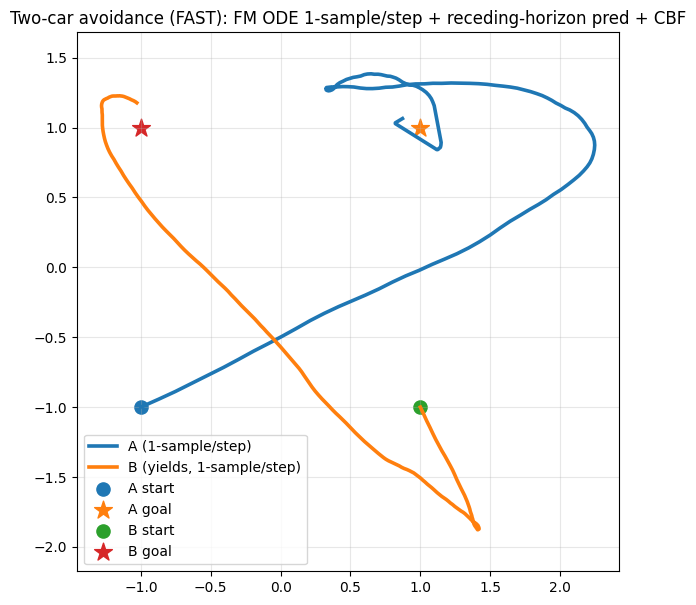

In [20]:
# ===============================================================
# LIGHT VERSION: Two-car avoidance (NO K candidates, only 1 sample/step)
#   - 1 FM ODE sample per agent per step (fast)
#   - 1 planning pass (no best-response loop)
#   - keeps receding-horizon prediction + CBF step + smoothing
# ===============================================================

import numpy as np
import torch
import torchdiffeq
import matplotlib.pyplot as plt

# -------------------------
# 0) Preconditions
# -------------------------
if "model_vel" not in globals():
    raise RuntimeError("model_vel_obs not found. Train/load it first.")
if "cbf_project_velocity_world" not in globals():
    raise RuntimeError("cbf_project_velocity_world not found. Run your CBF projector cell first.")

# -------------------------
# 1) Utils
# -------------------------
def _wrap_pi(a: float) -> float:
    return float((a + np.pi) % (2 * np.pi) - np.pi)

def _rot2(a: float) -> np.ndarray:
    ca, sa = float(np.cos(a)), float(np.sin(a))
    return np.array([[ca, -sa], [sa, ca]], dtype=np.float64)

def _infer_cond_dim(model):
    if hasattr(model, "cond_dim") and model.cond_dim is not None:
        return int(model.cond_dim)
    cond_mlp = getattr(model, "cond_mlp", None)
    if cond_mlp is not None:
        for layer in cond_mlp:
            if hasattr(layer, "in_features"):
                return int(layer.in_features)
    return None

def canonicalize_runtime_obs_xy(xy, goal_xy, obs_xy):
    p = np.asarray(xy, dtype=np.float64).reshape(2)
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    o = np.asarray(obs_xy, dtype=np.float64).reshape(2)

    g0 = g - p
    o0 = o - p
    goal_dist = float(np.linalg.norm(g0) + 1e-12)

    phi = float(np.arctan2(g0[1], g0[0]))
    R = _rot2(-phi)
    o_can = (R @ o0.reshape(2, 1)).reshape(2)

    reflect = False
    if float(o_can[1]) < 0.0:
        reflect = True
        o_can[1] *= -1.0

    cond = np.array([goal_dist, float(o_can[0]), float(o_can[1])], dtype=np.float32)
    meta = {"phi": phi, "reflect": reflect}
    return cond, meta

def uncanonicalize_v(v_can_2, meta):
    v = np.asarray(v_can_2, dtype=np.float64).reshape(2).copy()
    if bool(meta.get("reflect", False)):
        v[1] *= -1.0
    Rinv = _rot2(float(meta["phi"]))
    return (Rinv @ v.reshape(2, 1)).reshape(2)

# -------------------------
# 2) CBF step w.r.t. other agent
# -------------------------
def _cbf_step_with_other(
    *,
    x_now, v_nom, other_now, dt,
    agent_safe_radius=0.60,
    gamma_min=6.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    extra_margin=0.0,
    device="cpu",
):
    x_now = np.asarray(x_now, dtype=np.float64).reshape(2)
    other_now = np.asarray(other_now, dtype=np.float64).reshape(2)
    v_nom = np.asarray(v_nom, dtype=np.float64).reshape(2)

    ellipses = [{"center": other_now.copy(), "radius": float(agent_safe_radius)}]
    x_traj = torch.tensor(x_now, dtype=torch.float32).view(1, 2, 1)
    v_traj = torch.tensor(v_nom, dtype=torch.float32).view(1, 2, 1)

    v_safe = cbf_project_velocity_world(
        x_traj,
        v_traj,
        ellipses=ellipses,
        extra_margin=float(extra_margin),
        max_corr_norm=float(max_corr_norm),
        passes=3,  # 少一点更快
        other_agent_traj=None,
        agent_safe_radius=float(agent_safe_radius),
        gamma_min=float(gamma_min),
        w_p=float(w_p),
        press_k=float(press_k),
        press_n=float(press_n),
    )
    return v_safe.squeeze(0).squeeze(-1).detach().cpu().numpy().astype(np.float64)

# -------------------------
# 3) FM ODE sampler
# -------------------------
@torch.no_grad()
def sample_v_seq_fm_odeint(
    *,
    model,
    cond,
    seq_len: int,
    T_SPAN: torch.Tensor,
    solver_method="euler",
    solver_tol=1e-5,
    noise_scale=1.0,
    device="cpu",
):
    dev = torch.device(device)
    model.eval()

    cond_dim_model = _infer_cond_dim(model)
    cond = np.asarray(cond, dtype=np.float32).reshape(-1)

    if cond_dim_model is not None:
        if cond.shape[0] < cond_dim_model:
            cond = np.concatenate([cond, np.zeros(cond_dim_model - cond.shape[0], dtype=np.float32)], axis=0)
        elif cond.shape[0] > cond_dim_model:
            cond = cond[:cond_dim_model]

    cond_t = torch.tensor(cond, dtype=torch.float32, device=dev).view(1, -1)
    x0 = torch.randn(1, 2, int(seq_len), device=dev) * float(noise_scale)
    t_span = T_SPAN.to(dev)

    def fm_ode_func(t, x_flat):
        x = x_flat.view(1, 2, int(seq_len))
        t_tensor = torch.tensor([t], device=dev, dtype=x.dtype)
        v_field = model(x, t_tensor, cond=cond_t)  # (1,2,H)
        return v_field.view(-1)

    sol = torchdiffeq.odeint(
        fm_ode_func,
        x0.view(-1),
        t_span,
        atol=float(solver_tol),
        rtol=float(solver_tol),
        method=str(solver_method),
    )
    x_final = sol[-1].view(1, 2, int(seq_len))
    v_seq_can = x_final[0].detach().cpu().numpy().T.astype(np.float64)  # (H,2)
    return v_seq_can

# -------------------------
# 4) LIGHT DMPC: one sample/step
# -------------------------
def two_car_fm_dmpc_one_sample(
    xA0, gA,
    xB0, gB,
    *,
    dt=0.1,
    vA_max=1.4,
    vB_max=1.4,
    max_total_steps=500,
    goal_tol=0.18,
    H=12,                     # ✅ 先小一点更快
    # yield / speed scales (asym)
    speed_scale_A=1.0,        # ✅ A 正常走
    speed_scale_B=0.4,        # ✅ B 默认更愿意让（慢一点）
    # smoothing
    ema_beta=0.9,
    heading_smooth=0.35,
    # CBF params
    agent_safe_radius=0.60,
    gamma_min=6.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    device="cpu",
    # FM ODE sampling
    n_steps_sample=20,        # ✅ 大幅减少 odeint steps
    noise_scale=1.0,
    solver_method="euler",
    solver_tol=1e-5,
    # costs (asym)
    w_goal_A=45.0,
    w_goal_B=45.0,
    w_smooth_A=2.0,
    w_smooth_B=2.0,
    w_dist_A=80.0,
    w_dist_B=110.0,           # ✅ B 更怕靠太近
    d_safe=1.05,
    priority="A",
):
    xA = np.asarray(xA0, dtype=np.float64).reshape(2).copy()
    xB = np.asarray(xB0, dtype=np.float64).reshape(2).copy()
    gA = np.asarray(gA, dtype=np.float64).reshape(2)
    gB = np.asarray(gB, dtype=np.float64).reshape(2)

    xsA, xsB = [xA.copy()], [xB.copy()]
    prev_vA, prev_vB = None, None

    T_SPAN = torch.linspace(0.0, 1.0, int(n_steps_sample) + 1)

    def hinge(z): return max(0.0, float(z))

    def rollout_predict_fast(x0, v_seq_world):
        x = x0.copy()
        traj = [x.copy()]
        for k in range(int(H)):
            x = x + float(dt) * v_seq_world[k]
            traj.append(x.copy())
        return np.asarray(traj, dtype=np.float64)

    def eval_cost(x0, g, other_pred, v_seq_world, *, w_goal, w_smooth, w_dist):
        x = x0.copy()
        J = 0.0
        v_prev = None
        for k in range(int(H)):
            v = v_seq_world[k]

            d = float(np.linalg.norm((x + dt * v) - other_pred[k + 1]))
            viol = hinge(float(d_safe) - d)
            J += float(w_dist) * (viol * viol)

            if v_prev is not None:
                dv = v - v_prev
                J += float(w_smooth) * float(dv @ dv)
            v_prev = v
            x = x + float(dt) * v

        J += float(w_goal) * float(np.sum((x - g) ** 2))
        return float(J)

    # warm-start predictions (straight)
    def straight_pred(x0, g, v_max):
        d = g - x0
        n = float(np.linalg.norm(d) + 1e-12)
        v = float(v_max) * (d / n)
        traj = [x0.copy()]
        x = x0.copy()
        for _ in range(int(H)):
            x = x + float(dt) * v
            traj.append(x.copy())
        return np.asarray(traj, dtype=np.float64)

    predA = straight_pred(xA, gA, vA_max)
    predB = straight_pred(xB, gB, vB_max)

    def make_one_seq(xSelf, gSelf, other_now, *, v_max, speed_scale):
        cond3, meta = canonicalize_runtime_obs_xy(xSelf, gSelf, other_now)
        v_seq_can = sample_v_seq_fm_odeint(
            model=model_vel,
            cond=cond3,
            seq_len=int(H),
            T_SPAN=T_SPAN,
            solver_method=solver_method,
            solver_tol=solver_tol,
            noise_scale=noise_scale,
            device=device,
        )
        v_seq_world = np.zeros((H, 2), dtype=np.float64)
        for k in range(int(H)):
            v_w = uncanonicalize_v(v_seq_can[k], meta)
            n = float(np.linalg.norm(v_w) + 1e-9)
            v_seq_world[k] = float(v_max) * float(speed_scale) * (v_w / n)
        return v_seq_world

    def smooth_vec(v_new, v_prev, a):
        if v_prev is None:
            return v_new
        a = float(np.clip(a, 0.0, 1.0))
        return v_prev + a * (v_new - v_prev)

    for step in range(int(max_total_steps)):
        doneA = float(np.linalg.norm(xA - gA)) <= float(goal_tol)
        doneB = float(np.linalg.norm(xB - gB)) <= float(goal_tol)
        if doneA and doneB:
            break

        order = ["A", "B"]
        if priority == "B":
            order = ["B", "A"]
        elif priority is None:
            order = ["A", "B"]

        # --- plan once ---
        vA0 = np.zeros(2, dtype=np.float64)
        vB0 = np.zeros(2, dtype=np.float64)

        for who in order:
            if who == "A" and not doneA:
                seqA = make_one_seq(xA, gA, xB, v_max=vA_max, speed_scale=speed_scale_A)
                # cost uses predB (receding-horizon)
                _ = eval_cost(xA, gA, predB, seqA, w_goal=w_goal_A, w_smooth=w_smooth_A, w_dist=w_dist_A)
                predA = rollout_predict_fast(xA, seqA)  # update prediction for B
                vA0 = seqA[0].copy()

            if who == "B" and not doneB:
                seqB = make_one_seq(xB, gB, xA, v_max=vB_max, speed_scale=speed_scale_B)
                _ = eval_cost(xB, gB, predA, seqB, w_goal=w_goal_B, w_smooth=w_smooth_B, w_dist=w_dist_B)
                predB = rollout_predict_fast(xB, seqB)  # update prediction for A
                vB0 = seqB[0].copy()

        if doneA: vA0 = np.zeros(2, dtype=np.float64)
        if doneB: vB0 = np.zeros(2, dtype=np.float64)

        # --- pre-exec smoothing ---
        vA_nom = smooth_vec(vA0, prev_vA, heading_smooth)
        vB_nom = smooth_vec(vB0, prev_vB, heading_smooth)

        # --- execute one step with CBF ---
        vA_safe = _cbf_step_with_other(
            x_now=xA, v_nom=vA_nom, other_now=xB, dt=dt,
            agent_safe_radius=agent_safe_radius,
            gamma_min=gamma_min, w_p=w_p, press_k=press_k, press_n=press_n,
            max_corr_norm=max_corr_norm,
            device=device,
        )
        vB_safe = _cbf_step_with_other(
            x_now=xB, v_nom=vB_nom, other_now=xA, dt=dt,
            agent_safe_radius=agent_safe_radius,
            gamma_min=gamma_min, w_p=w_p, press_k=press_k, press_n=press_n,
            max_corr_norm=max_corr_norm,
            device=device,
        )

        # EMA on executed v
        b = float(np.clip(ema_beta, 0.0, 0.999))
        vA_exec = vA_safe if prev_vA is None else b * prev_vA + (1.0 - b) * vA_safe
        vB_exec = vB_safe if prev_vB is None else b * prev_vB + (1.0 - b) * vB_safe

        xA = xA + float(dt) * vA_exec
        xB = xB + float(dt) * vB_exec

        xsA.append(xA.copy()); xsB.append(xB.copy())
        prev_vA, prev_vB = vA_exec.copy(), vB_exec.copy()

        if step % 50 == 0:
            dAB = float(np.linalg.norm(xA - xB))
            print(f"[step {step:04d}] dAB={dAB:.3f} |dA|={np.linalg.norm(xA-gA):.3f} |dB|={np.linalg.norm(xB-gB):.3f}")

    return np.asarray(xsA, dtype=np.float64), np.asarray(xsB, dtype=np.float64)


# -------------------------
# 5) Demo + Plot
# -------------------------
xA0 = np.array([-1.0, -1.0], dtype=np.float64)
gA  = np.array([+1.0, +1.0], dtype=np.float64)
xB0 = np.array([+1.0, -1.0], dtype=np.float64)
gB  = np.array([-1.0, +1.0], dtype=np.float64)

dt_use = float(globals().get("dt", 0.1))
dev_use = str(globals().get("device", "cpu"))
SOLVER_METHOD = str(globals().get("SOLVER_METHOD", "euler"))
SOLVER_TOL = float(globals().get("SOLVER_TOLERANCE", 1e-5))

xsA, xsB = two_car_fm_dmpc_one_sample(
    xA0, gA, xB0, gB,
    dt=dt_use,
    vA_max=1.4,
    vB_max=1.4,
    max_total_steps=500,
    goal_tol=0.18,
    H=12,
    speed_scale_A=1.0,
    speed_scale_B=0.4,        # B 默认让路
    ema_beta=0.9,
    heading_smooth=0.35,
    agent_safe_radius=0.60,
    gamma_min=6.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    device=dev_use,
    n_steps_sample=20,        # ✅ 关键：更快
    noise_scale=1.0,
    solver_method=SOLVER_METHOD,
    solver_tol=SOLVER_TOL,
    w_goal_A=45.0,
    w_goal_B=45.0,
    w_smooth_A=2.0,
    w_smooth_B=2.0,
    w_dist_A=80.0,
    w_dist_B=110.0,
    d_safe=1.05,
    priority="A",
)

plt.figure(figsize=(7, 7))
plt.plot(xsA[:, 0], xsA[:, 1], "-", linewidth=2.6, label="A (1-sample/step)")
plt.plot(xsB[:, 0], xsB[:, 1], "-", linewidth=2.6, label="B (yields, 1-sample/step)")
plt.scatter([xsA[0, 0]], [xsA[0, 1]], s=90, label="A start")
plt.scatter([gA[0]], [gA[1]], s=180, marker="*", label="A goal")
plt.scatter([xsB[0, 0]], [xsB[0, 1]], s=90, label="B start")
plt.scatter([gB[0]], [gB[1]], s=180, marker="*", label="B goal")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("Two-car avoidance (FAST): FM ODE 1-sample/step + receding-horizon pred + CBF")
plt.legend()
plt.show()


[step 0000] dAB=1.990 |dA|=2.929 |dB|=2.778
[step 0050] dAB=3.441 |dA|=3.973 |dB|=0.882
[step 0100] dAB=2.213 |dA|=1.512 |dB|=0.334
[step 0150] dAB=2.566 |dA|=0.877 |dB|=0.060
[step 0200] dAB=1.886 |dA|=0.316 |dB|=0.164


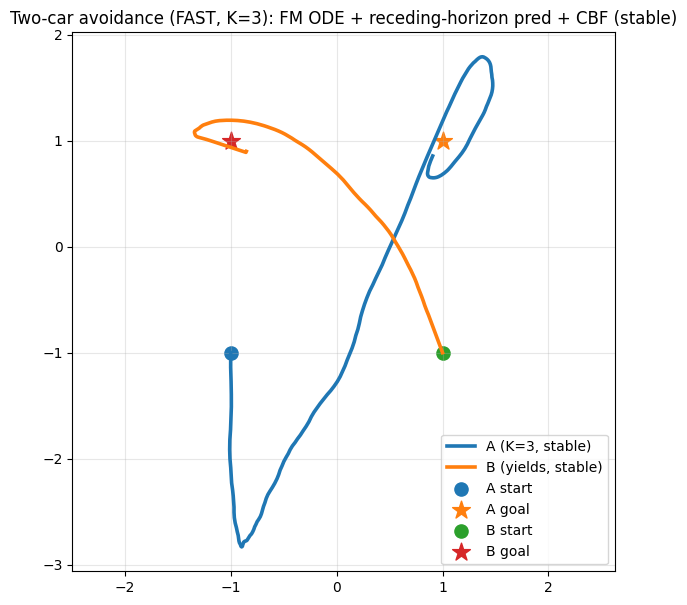

In [13]:
# ===============================================================
# NEW CELL (FAST, K=3, STABLE): Two-car avoidance
#   - FM ODE + receding-horizon prediction + CBF
#   - ✅ K=3 candidates / step
#   - ✅ Turn penalty (Method B) BUT gated near goal (prevents spirals)
#   - ✅ IMPORTANT: speed is NOT forced to fixed magnitude:
#       speed <= min(v_max*s, k_goal*dist_to_goal) -> can go to 0 near goal
# ===============================================================

import numpy as np
import torch
import torchdiffeq
import matplotlib.pyplot as plt

if "model_vel" not in globals():
    raise RuntimeError("model_vel not found.")
if "cbf_project_velocity_world" not in globals():
    raise RuntimeError("cbf_project_velocity_world not found.")

def _rot2(a: float) -> np.ndarray:
    ca, sa = float(np.cos(a)), float(np.sin(a))
    return np.array([[ca, -sa], [sa, ca]], dtype=np.float64)

def _infer_cond_dim(model):
    if hasattr(model, "cond_dim") and model.cond_dim is not None:
        return int(model.cond_dim)
    cond_mlp = getattr(model, "cond_mlp", None)
    if cond_mlp is not None:
        for layer in cond_mlp:
            if hasattr(layer, "in_features"):
                return int(layer.in_features)
    return None

def canonicalize_runtime_obs_xy(xy, goal_xy, obs_xy):
    p = np.asarray(xy, dtype=np.float64).reshape(2)
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    o = np.asarray(obs_xy, dtype=np.float64).reshape(2)

    g0 = g - p
    o0 = o - p
    goal_dist = float(np.linalg.norm(g0) + 1e-12)

    phi = float(np.arctan2(g0[1], g0[0]))
    R = _rot2(-phi)
    o_can = (R @ o0.reshape(2, 1)).reshape(2)

    reflect = False
    if float(o_can[1]) < 0.0:
        reflect = True
        o_can[1] *= -1.0

    cond = np.array([goal_dist, float(o_can[0]), float(o_can[1])], dtype=np.float32)
    meta = {"phi": phi, "reflect": reflect}
    return cond, meta

def uncanonicalize_v(v_can_2, meta):
    v = np.asarray(v_can_2, dtype=np.float64).reshape(2).copy()
    if bool(meta.get("reflect", False)):
        v[1] *= -1.0
    Rinv = _rot2(float(meta["phi"]))
    return (Rinv @ v.reshape(2, 1)).reshape(2)

def _cbf_step_with_other(
    *, x_now, v_nom, other_now, dt,
    agent_safe_radius=0.60,
    gamma_min=6.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    extra_margin=0.0,
    device="cpu",
):
    x_now = np.asarray(x_now, dtype=np.float64).reshape(2)
    other_now = np.asarray(other_now, dtype=np.float64).reshape(2)
    v_nom = np.asarray(v_nom, dtype=np.float64).reshape(2)

    ellipses = [{"center": other_now.copy(), "radius": float(agent_safe_radius)}]
    x_traj = torch.tensor(x_now, dtype=torch.float32).view(1, 2, 1)
    v_traj = torch.tensor(v_nom, dtype=torch.float32).view(1, 2, 1)

    v_safe = cbf_project_velocity_world(
        x_traj, v_traj,
        ellipses=ellipses,
        extra_margin=float(extra_margin),
        max_corr_norm=float(max_corr_norm),
        passes=3,
        other_agent_traj=None,
        agent_safe_radius=float(agent_safe_radius),
        gamma_min=float(gamma_min),
        w_p=float(w_p),
        press_k=float(press_k),
        press_n=float(press_n),
    )
    return v_safe.squeeze(0).squeeze(-1).detach().cpu().numpy().astype(np.float64)

@torch.no_grad()
def sample_v_seq_fm_odeint(
    *, model, cond, seq_len: int, T_SPAN: torch.Tensor,
    solver_method="euler", solver_tol=1e-5, noise_scale=1.0, device="cpu",
):
    dev = torch.device(device)
    model.eval()

    cond_dim_model = _infer_cond_dim(model)
    cond = np.asarray(cond, dtype=np.float32).reshape(-1)
    if cond_dim_model is not None:
        if cond.shape[0] < cond_dim_model:
            cond = np.concatenate([cond, np.zeros(cond_dim_model - cond.shape[0], dtype=np.float32)], axis=0)
        elif cond.shape[0] > cond_dim_model:
            cond = cond[:cond_dim_model]

    cond_t = torch.tensor(cond, dtype=torch.float32, device=dev).view(1, -1)
    x0 = torch.randn(1, 2, int(seq_len), device=dev) * float(noise_scale)
    t_span = T_SPAN.to(dev)

    def fm_ode_func(t, x_flat):
        x = x_flat.view(1, 2, int(seq_len))
        t_tensor = torch.tensor([t], device=dev, dtype=x.dtype)
        v_field = model(x, t_tensor, cond=cond_t)
        return v_field.view(-1)

    sol = torchdiffeq.odeint(
        fm_ode_func, x0.view(-1), t_span,
        atol=float(solver_tol), rtol=float(solver_tol),
        method=str(solver_method),
    )
    x_final = sol[-1].view(1, 2, int(seq_len))
    return x_final[0].detach().cpu().numpy().T.astype(np.float64)  # (H,2)

def two_car_fm_dmpc_fast_k3_stable(
    xA0, gA, xB0, gB,
    *,
    dt=0.1,
    vA_max=1.4,
    vB_max=1.4,
    max_total_steps=700,
    goal_tol=0.18,
    H=12,
    K=3,
    speed_scale_A=1.0,
    speed_scale_B=0.4,
    ema_beta=0.9,
    heading_smooth=0.35,
    agent_safe_radius=0.60,
    gamma_min=6.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    device="cpu",
    n_steps_sample=20,
    noise_scale=1.0,
    solver_method="euler",
    solver_tol=1e-5,
    w_goal_A=45.0,
    w_goal_B=45.0,
    w_smooth_A=2.0,
    w_smooth_B=2.0,
    w_dist_A=80.0,
    w_dist_B=110.0,
    d_safe=1.05,
    # turn penalty (gated near goal)
    w_turn_A=10.0,
    w_turn_B=4.0,
    turn_fade_radius=0.6,   # within this dist to goal, fade out turn penalty
    # progress (small)
    w_prog_A=2.0,
    w_prog_B=2.0,
    # speed shrink near goal (kills spirals)
    k_goal_speed=1.2,       # speed <= k_goal_speed * dist_to_goal
    priority="A",
):
    xA = np.asarray(xA0, dtype=np.float64).reshape(2).copy()
    xB = np.asarray(xB0, dtype=np.float64).reshape(2).copy()
    gA = np.asarray(gA, dtype=np.float64).reshape(2)
    gB = np.asarray(gB, dtype=np.float64).reshape(2)

    xsA, xsB = [xA.copy()], [xB.copy()]
    prev_vA, prev_vB = None, None
    T_SPAN = torch.linspace(0.0, 1.0, int(n_steps_sample) + 1)

    def hinge(z): return max(0.0, float(z))

    def rollout_predict_fast(x0, v_seq_world):
        x = x0.copy()
        traj = [x.copy()]
        for k in range(int(H)):
            x = x + float(dt) * v_seq_world[k]
            traj.append(x.copy())
        return np.asarray(traj, dtype=np.float64)

    def eval_cost(x0, g, other_pred, v_seq_world, *, w_goal, w_smooth, w_dist, w_prog):
        x = x0.copy()
        J = 0.0
        v_prev = None
        d_prev_goal = float(np.linalg.norm(x - g))
        for k in range(int(H)):
            v = v_seq_world[k]
            x_next = x + float(dt) * v

            d = float(np.linalg.norm(x_next - other_pred[k + 1]))
            viol = hinge(float(d_safe) - d)
            J += float(w_dist) * (viol * viol)

            if v_prev is not None:
                dv = v - v_prev
                J += float(w_smooth) * float(dv @ dv)
            v_prev = v

            if w_prog > 0.0:
                d_next_goal = float(np.linalg.norm(x_next - g))
                prog = d_prev_goal - d_next_goal
                J += float(w_prog) * float(max(0.0, -prog) ** 2)
                d_prev_goal = d_next_goal

            x = x_next

        J += float(w_goal) * float(np.sum((x - g) ** 2))
        return float(J)

    def straight_pred(x0, g, v_max):
        d = g - x0
        n = float(np.linalg.norm(d) + 1e-12)
        v = float(v_max) * (d / n)
        traj = [x0.copy()]
        x = x0.copy()
        for _ in range(int(H)):
            x = x + float(dt) * v
            traj.append(x.copy())
        return np.asarray(traj, dtype=np.float64)

    predA = straight_pred(xA, gA, vA_max)
    predB = straight_pred(xB, gB, vB_max)

    def sample_seq_world(xSelf, gSelf, other_now, *, v_max, speed_scale):
        cond3, meta = canonicalize_runtime_obs_xy(xSelf, gSelf, other_now)
        v_seq_can = sample_v_seq_fm_odeint(
            model=model_vel, cond=cond3, seq_len=int(H), T_SPAN=T_SPAN,
            solver_method=solver_method, solver_tol=solver_tol,
            noise_scale=noise_scale, device=device,
        )

        v_seq_world = np.zeros((H, 2), dtype=np.float64)
        xk = xSelf.copy()
        for k in range(int(H)):
            # ✅ allow speed to shrink near goal to prevent spirals
            dist_goal = float(np.linalg.norm(xk - gSelf))
            speed_cap = min(float(v_max) * float(speed_scale), float(k_goal_speed) * dist_goal)

            v_w = uncanonicalize_v(v_seq_can[k], meta)
            n = float(np.linalg.norm(v_w) + 1e-9)
            v_seq_world[k] = speed_cap * (v_w / n)

            xk = xk + float(dt) * v_seq_world[k]
        return v_seq_world

    def pick_best_seq(
        xSelf, gSelf, other_now, other_pred,
        *, v_max, speed_scale,
        w_goal, w_smooth, w_dist, w_prog,
        K, prev_v_exec, w_turn,
    ):
        bestJ = float("inf")
        best_seq = None
        for _ in range(int(K)):
            seq = sample_seq_world(xSelf, gSelf, other_now, v_max=v_max, speed_scale=speed_scale)
            J = eval_cost(xSelf, gSelf, other_pred, seq,
                          w_goal=w_goal, w_smooth=w_smooth, w_dist=w_dist, w_prog=w_prog)

            # ✅ gated turn penalty (fade out near goal)
            if prev_v_exec is not None and float(w_turn) > 0.0:
                d_goal = float(np.linalg.norm(xSelf - gSelf))
                gate = float(np.clip(d_goal / float(turn_fade_radius), 0.0, 1.0))
                dv0 = seq[0] - prev_v_exec
                J += gate * float(w_turn) * float(dv0 @ dv0)

            if J < bestJ:
                bestJ = J
                best_seq = seq
        return best_seq

    def smooth_vec(v_new, v_prev, a):
        if v_prev is None:
            return v_new
        a = float(np.clip(a, 0.0, 1.0))
        return v_prev + a * (v_new - v_prev)

    for step in range(int(max_total_steps)):
        # stop if within goal tol OR basically stopped near goal
        doneA = (float(np.linalg.norm(xA - gA)) <= float(goal_tol))
        doneB = (float(np.linalg.norm(xB - gB)) <= float(goal_tol))
        if doneA and doneB:
            break

        order = ["A", "B"]
        if priority == "B":
            order = ["B", "A"]
        elif priority is None:
            order = ["A", "B"]

        vA0 = np.zeros(2, dtype=np.float64)
        vB0 = np.zeros(2, dtype=np.float64)

        for who in order:
            if who == "A" and not doneA:
                seqA = pick_best_seq(
                    xA, gA, xB, predB,
                    v_max=vA_max, speed_scale=speed_scale_A,
                    w_goal=w_goal_A, w_smooth=w_smooth_A, w_dist=w_dist_A, w_prog=w_prog_A,
                    K=K, prev_v_exec=prev_vA, w_turn=w_turn_A,
                )
                predA = rollout_predict_fast(xA, seqA)
                vA0 = seqA[0].copy()

            if who == "B" and not doneB:
                seqB = pick_best_seq(
                    xB, gB, xA, predA,
                    v_max=vB_max, speed_scale=speed_scale_B,
                    w_goal=w_goal_B, w_smooth=w_smooth_B, w_dist=w_dist_B, w_prog=w_prog_B,
                    K=K, prev_v_exec=prev_vB, w_turn=w_turn_B,
                )
                predB = rollout_predict_fast(xB, seqB)
                vB0 = seqB[0].copy()

        if doneA: vA0 = np.zeros(2, dtype=np.float64)
        if doneB: vB0 = np.zeros(2, dtype=np.float64)

        vA_nom = smooth_vec(vA0, prev_vA, heading_smooth)
        vB_nom = smooth_vec(vB0, prev_vB, heading_smooth)

        vA_safe = _cbf_step_with_other(
            x_now=xA, v_nom=vA_nom, other_now=xB, dt=dt,
            agent_safe_radius=agent_safe_radius,
            gamma_min=gamma_min, w_p=w_p, press_k=press_k, press_n=press_n,
            max_corr_norm=max_corr_norm,
            device=device,
        )
        vB_safe = _cbf_step_with_other(
            x_now=xB, v_nom=vB_nom, other_now=xA, dt=dt,
            agent_safe_radius=agent_safe_radius,
            gamma_min=gamma_min, w_p=w_p, press_k=press_k, press_n=press_n,
            max_corr_norm=max_corr_norm,
            device=device,
        )

        b = float(np.clip(ema_beta, 0.0, 0.999))
        vA_exec = vA_safe if prev_vA is None else b * prev_vA + (1.0 - b) * vA_safe
        vB_exec = vB_safe if prev_vB is None else b * prev_vB + (1.0 - b) * vB_safe

        xA = xA + float(dt) * vA_exec
        xB = xB + float(dt) * vB_exec

        xsA.append(xA.copy()); xsB.append(xB.copy())
        prev_vA, prev_vB = vA_exec.copy(), vB_exec.copy()

        if step % 50 == 0:
            dAB = float(np.linalg.norm(xA - xB))
            print(f"[step {step:04d}] dAB={dAB:.3f} |dA|={np.linalg.norm(xA-gA):.3f} |dB|={np.linalg.norm(xB-gB):.3f}")

    return np.asarray(xsA, dtype=np.float64), np.asarray(xsB, dtype=np.float64)


# -------------------------
# Demo
# -------------------------
xA0 = np.array([-1.0, -1.0], dtype=np.float64)
gA  = np.array([+1.0, +1.0], dtype=np.float64)
xB0 = np.array([+1.0, -1.0], dtype=np.float64)
gB  = np.array([-1.0, +1.0], dtype=np.float64)

dt_use = float(globals().get("dt", 0.1))
dev_use = str(globals().get("device", "cpu"))
SOLVER_METHOD = str(globals().get("SOLVER_METHOD", "euler"))
SOLVER_TOL = float(globals().get("SOLVER_TOLERANCE", 1e-5))

xsA, xsB = two_car_fm_dmpc_fast_k3_stable(
    xA0, gA, xB0, gB,
    dt=dt_use,
    device=dev_use,
    solver_method=SOLVER_METHOD,
    solver_tol=SOLVER_TOL,
    H=12, K=3,
    speed_scale_A=1.0,
    speed_scale_B=0.4,
    # key knobs:
    w_turn_A=10.0,
    w_turn_B=4.0,
    turn_fade_radius=0.6,
    k_goal_speed=1.2,
    w_prog_A=2.0,
    w_prog_B=2.0,
)

plt.figure(figsize=(7, 7))
plt.plot(xsA[:, 0], xsA[:, 1], "-", linewidth=2.6, label="A (K=3, stable)")
plt.plot(xsB[:, 0], xsB[:, 1], "-", linewidth=2.6, label="B (yields, stable)")
plt.scatter([xsA[0, 0]], [xsA[0, 1]], s=90, label="A start")
plt.scatter([gA[0]], [gA[1]], s=180, marker="*", label="A goal")
plt.scatter([xsB[0, 0]], [xsB[0, 1]], s=90, label="B start")
plt.scatter([gB[0]], [gB[1]], s=180, marker="*", label="B goal")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("Two-car avoidance (FAST, K=3): FM ODE + receding-horizon pred + CBF (stable)")
plt.legend()
plt.show()


[step 0000] dAB=1.992 |dA|=2.767 |dB|=2.854
[step 0050] dAB=3.155 |dA|=0.337 |dB|=3.256
[step 0100] dAB=2.891 |dA|=0.141 |dB|=2.781
[step 0150] dAB=2.526 |dA|=0.079 |dB|=1.624
[step 0200] dAB=2.278 |dA|=0.069 |dB|=0.654


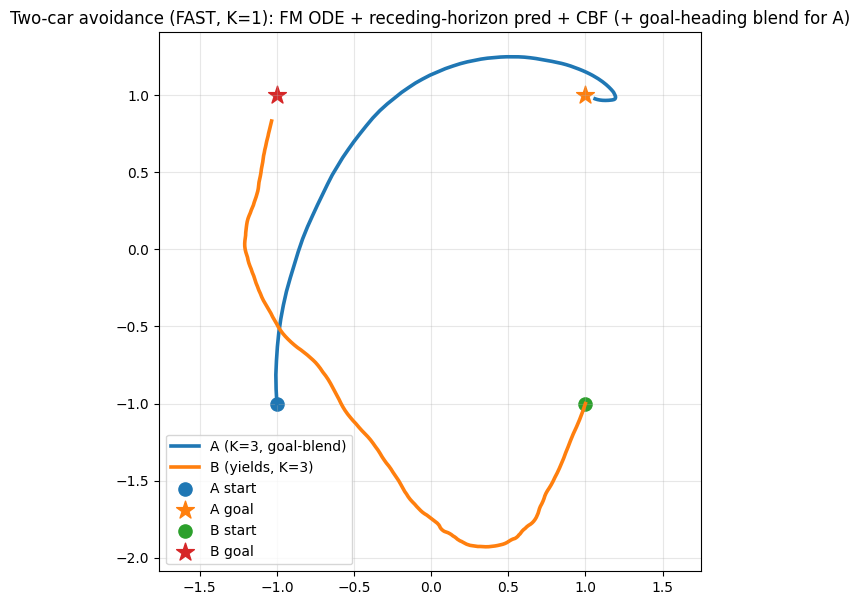

In [9]:
# ===============================================================
# NEW CELL (FAST, K=3, STABLE + GOAL-HEADING BLEND for A):
#   - FM ODE + receding-horizon prediction + CBF
#   - ✅ K=3 candidates / step
#   - ✅ Stable near goal (speed can shrink) to avoid spirals
#   - ✅ Turn penalty gated near goal (keeps smooth but avoids locking-in)
#   - ✅ Method 2: Action blending (ONLY for A) to enforce initial heading towards goal
#       vA_nom <- (1-beta)*vA_nom + beta*(||vA_nom|| * u_goal)
#       (applied before CBF; CBF still guarantees safety)
#
# Requirements:
#   - model_vel
#   - cbf_project_velocity_world
# ===============================================================

import numpy as np
import torch
import torchdiffeq
import matplotlib.pyplot as plt

# -------------------------
# 0) Preconditions
# -------------------------
if "model_vel" not in globals():
    raise RuntimeError("model_vel not found. Train/load it first.")
if "cbf_project_velocity_world" not in globals():
    raise RuntimeError("cbf_project_velocity_world not found. Run your CBF projector cell first.")

# -------------------------
# 1) Utils
# -------------------------
def _rot2(a: float) -> np.ndarray:
    ca, sa = float(np.cos(a)), float(np.sin(a))
    return np.array([[ca, -sa], [sa, ca]], dtype=np.float64)

def _infer_cond_dim(model):
    if hasattr(model, "cond_dim") and model.cond_dim is not None:
        return int(model.cond_dim)
    cond_mlp = getattr(model, "cond_mlp", None)
    if cond_mlp is not None:
        for layer in cond_mlp:
            if hasattr(layer, "in_features"):
                return int(layer.in_features)
    return None

def canonicalize_runtime_obs_xy(xy, goal_xy, obs_xy):
    p = np.asarray(xy, dtype=np.float64).reshape(2)
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    o = np.asarray(obs_xy, dtype=np.float64).reshape(2)

    g0 = g - p
    o0 = o - p
    goal_dist = float(np.linalg.norm(g0) + 1e-12)

    phi = float(np.arctan2(g0[1], g0[0]))
    R = _rot2(-phi)
    o_can = (R @ o0.reshape(2, 1)).reshape(2)

    reflect = False
    if float(o_can[1]) < 0.0:
        reflect = True
        o_can[1] *= -1.0

    cond = np.array([goal_dist, float(o_can[0]), float(o_can[1])], dtype=np.float32)
    meta = {"phi": phi, "reflect": reflect}
    return cond, meta

def uncanonicalize_v(v_can_2, meta):
    v = np.asarray(v_can_2, dtype=np.float64).reshape(2).copy()
    if bool(meta.get("reflect", False)):
        v[1] *= -1.0
    Rinv = _rot2(float(meta["phi"]))
    return (Rinv @ v.reshape(2, 1)).reshape(2)

# -------------------------
# 2) CBF step w.r.t. other agent (single-step)
# -------------------------
def _cbf_step_with_other(
    *,
    x_now, v_nom, other_now, dt,
    agent_safe_radius=0.60,
    gamma_min=6.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    extra_margin=0.0,
    device="cpu",
):
    x_now = np.asarray(x_now, dtype=np.float64).reshape(2)
    other_now = np.asarray(other_now, dtype=np.float64).reshape(2)
    v_nom = np.asarray(v_nom, dtype=np.float64).reshape(2)

    ellipses = [{"center": other_now.copy(), "radius": float(agent_safe_radius)}]
    x_traj = torch.tensor(x_now, dtype=torch.float32).view(1, 2, 1)
    v_traj = torch.tensor(v_nom, dtype=torch.float32).view(1, 2, 1)

    v_safe = cbf_project_velocity_world(
        x_traj, v_traj,
        ellipses=ellipses,
        extra_margin=float(extra_margin),
        max_corr_norm=float(max_corr_norm),
        passes=3,  # keep cheap
        other_agent_traj=None,
        agent_safe_radius=float(agent_safe_radius),
        gamma_min=float(gamma_min),
        w_p=float(w_p),
        press_k=float(press_k),
        press_n=float(press_n),
    )
    return v_safe.squeeze(0).squeeze(-1).detach().cpu().numpy().astype(np.float64)

# -------------------------
# 3) FM ODE sampler
# -------------------------
@torch.no_grad()
def sample_v_seq_fm_odeint(
    *,
    model,
    cond,
    seq_len: int,
    T_SPAN: torch.Tensor,
    solver_method="euler",
    solver_tol=1e-5,
    noise_scale=1.0,
    device="cpu",
):
    dev = torch.device(device)
    model.eval()

    cond_dim_model = _infer_cond_dim(model)
    cond = np.asarray(cond, dtype=np.float32).reshape(-1)
    if cond_dim_model is not None:
        if cond.shape[0] < cond_dim_model:
            cond = np.concatenate([cond, np.zeros(cond_dim_model - cond.shape[0], dtype=np.float32)], axis=0)
        elif cond.shape[0] > cond_dim_model:
            cond = cond[:cond_dim_model]

    cond_t = torch.tensor(cond, dtype=torch.float32, device=dev).view(1, -1)
    x0 = torch.randn(1, 2, int(seq_len), device=dev) * float(noise_scale)
    t_span = T_SPAN.to(dev)

    def fm_ode_func(t, x_flat):
        x = x_flat.view(1, 2, int(seq_len))
        t_tensor = torch.tensor([t], device=dev, dtype=x.dtype)
        v_field = model(x, t_tensor, cond=cond_t)
        return v_field.view(-1)

    sol = torchdiffeq.odeint(
        fm_ode_func,
        x0.view(-1),
        t_span,
        atol=float(solver_tol),
        rtol=float(solver_tol),
        method=str(solver_method),
    )
    x_final = sol[-1].view(1, 2, int(seq_len))
    return x_final[0].detach().cpu().numpy().T.astype(np.float64)  # (H,2)

# -------------------------
# 4) FAST DMPC with K=3 + stable speed + turn-pen gate + GOAL-HEADING BLEND (A only)
# -------------------------
def two_car_fm_dmpc_fast_k3_goalblendA(
    xA0, gA,
    xB0, gB,
    *,
    dt=0.1,
    vA_max=1.4,
    vB_max=1.4,
    max_total_steps=700,
    goal_tol=0.18,
    H=12,
    K=3,
    # yield / speed
    speed_scale_A=1.0,
    speed_scale_B=0.4,
    # smoothing
    ema_beta=0.9,
    heading_smooth=0.35,
    # CBF params
    agent_safe_radius=0.60,
    gamma_min=6.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    device="cpu",
    # FM ODE sampling
    n_steps_sample=20,
    noise_scale=1.0,
    solver_method="euler",
    solver_tol=1e-5,
    # costs
    w_goal_A=45.0,
    w_goal_B=45.0,
    w_smooth_A=2.0,
    w_smooth_B=2.0,
    w_dist_A=80.0,
    w_dist_B=110.0,
    d_safe=1.05,
    # turn penalty (gated near goal)
    w_turn_A=10.0,
    w_turn_B=4.0,
    turn_fade_radius=0.6,
    # progress (small)
    w_prog_A=2.0,
    w_prog_B=2.0,
    # speed shrink near goal (prevents spirals)
    k_goal_speed=1.2,
    # ✅ Method 2: goal heading blend for A
    goal_blend_beta_A=0.45,   # 0.25~0.60; increase if A still starts "wrong"
    goal_blend_radius_A=2.5,  # apply blend when dist_to_goal < this radius (large => always)
    # planning order
    priority="A",
):
    xA = np.asarray(xA0, dtype=np.float64).reshape(2).copy()
    xB = np.asarray(xB0, dtype=np.float64).reshape(2).copy()
    gA = np.asarray(gA, dtype=np.float64).reshape(2)
    gB = np.asarray(gB, dtype=np.float64).reshape(2)

    xsA, xsB = [xA.copy()], [xB.copy()]
    prev_vA, prev_vB = None, None
    T_SPAN = torch.linspace(0.0, 1.0, int(n_steps_sample) + 1)

    def hinge(z): return max(0.0, float(z))

    def rollout_predict_fast(x0, v_seq_world):
        x = x0.copy()
        traj = [x.copy()]
        for k in range(int(H)):
            x = x + float(dt) * v_seq_world[k]
            traj.append(x.copy())
        return np.asarray(traj, dtype=np.float64)

    def eval_cost(x0, g, other_pred, v_seq_world, *, w_goal, w_smooth, w_dist, w_prog):
        x = x0.copy()
        J = 0.0
        v_prev = None
        d_prev_goal = float(np.linalg.norm(x - g))
        for k in range(int(H)):
            v = v_seq_world[k]
            x_next = x + float(dt) * v

            d = float(np.linalg.norm(x_next - other_pred[k + 1]))
            viol = hinge(float(d_safe) - d)
            J += float(w_dist) * (viol * viol)

            if v_prev is not None:
                dv = v - v_prev
                J += float(w_smooth) * float(dv @ dv)
            v_prev = v

            if w_prog > 0.0:
                d_next_goal = float(np.linalg.norm(x_next - g))
                prog = d_prev_goal - d_next_goal
                J += float(w_prog) * float(max(0.0, -prog) ** 2)
                d_prev_goal = d_next_goal

            x = x_next

        J += float(w_goal) * float(np.sum((x - g) ** 2))
        return float(J)

    def straight_pred(x0, g, v_max):
        d = g - x0
        n = float(np.linalg.norm(d) + 1e-12)
        v = float(v_max) * (d / n)
        traj = [x0.copy()]
        x = x0.copy()
        for _ in range(int(H)):
            x = x + float(dt) * v
            traj.append(x.copy())
        return np.asarray(traj, dtype=np.float64)

    predA = straight_pred(xA, gA, vA_max)
    predB = straight_pred(xB, gB, vB_max)

    def sample_seq_world(xSelf, gSelf, other_now, *, v_max, speed_scale):
        cond3, meta = canonicalize_runtime_obs_xy(xSelf, gSelf, other_now)
        v_seq_can = sample_v_seq_fm_odeint(
            model=model_vel, cond=cond3, seq_len=int(H), T_SPAN=T_SPAN,
            solver_method=solver_method, solver_tol=solver_tol,
            noise_scale=noise_scale, device=device,
        )

        v_seq_world = np.zeros((H, 2), dtype=np.float64)
        xk = xSelf.copy()
        for k in range(int(H)):
            dist_goal = float(np.linalg.norm(xk - gSelf))
            speed_cap = min(float(v_max) * float(speed_scale), float(k_goal_speed) * dist_goal)

            v_w = uncanonicalize_v(v_seq_can[k], meta)
            n = float(np.linalg.norm(v_w) + 1e-9)
            v_seq_world[k] = speed_cap * (v_w / n)

            xk = xk + float(dt) * v_seq_world[k]
        return v_seq_world

    def pick_best_seq(
        xSelf, gSelf, other_now, other_pred,
        *, v_max, speed_scale,
        w_goal, w_smooth, w_dist, w_prog,
        K, prev_v_exec, w_turn,
    ):
        bestJ = float("inf")
        best_seq = None
        for _ in range(int(K)):
            seq = sample_seq_world(xSelf, gSelf, other_now, v_max=v_max, speed_scale=speed_scale)
            J = eval_cost(xSelf, gSelf, other_pred, seq,
                          w_goal=w_goal, w_smooth=w_smooth, w_dist=w_dist, w_prog=w_prog)

            # turn penalty gated near goal
            if prev_v_exec is not None and float(w_turn) > 0.0:
                d_goal = float(np.linalg.norm(xSelf - gSelf))
                gate = float(np.clip(d_goal / float(turn_fade_radius), 0.0, 1.0))
                dv0 = seq[0] - prev_v_exec
                J += gate * float(w_turn) * float(dv0 @ dv0)

            if J < bestJ:
                bestJ = J
                best_seq = seq
        return best_seq

    def smooth_vec(v_new, v_prev, a):
        if v_prev is None:
            return v_new
        a = float(np.clip(a, 0.0, 1.0))
        return v_prev + a * (v_new - v_prev)

    def goal_heading_blend(v, x, g, beta):
        beta = float(np.clip(beta, 0.0, 1.0))
        d = g - x
        dn = float(np.linalg.norm(d) + 1e-9)
        u_goal = d / dn
        sp = float(np.linalg.norm(v) + 1e-12)
        v_goal = sp * u_goal
        return (1.0 - beta) * v + beta * v_goal

    for step in range(int(max_total_steps)):
        doneA = (float(np.linalg.norm(xA - gA)) <= float(goal_tol))
        doneB = (float(np.linalg.norm(xB - gB)) <= float(goal_tol))
        if doneA and doneB:
            break

        order = ["A", "B"]
        if priority == "B":
            order = ["B", "A"]
        elif priority is None:
            order = ["A", "B"]

        vA0 = np.zeros(2, dtype=np.float64)
        vB0 = np.zeros(2, dtype=np.float64)

        for who in order:
            if who == "A" and not doneA:
                seqA = pick_best_seq(
                    xA, gA, xB, predB,
                    v_max=vA_max, speed_scale=speed_scale_A,
                    w_goal=w_goal_A, w_smooth=w_smooth_A, w_dist=w_dist_A, w_prog=w_prog_A,
                    K=K, prev_v_exec=prev_vA, w_turn=w_turn_A,
                )
                predA = rollout_predict_fast(xA, seqA)
                vA0 = seqA[0].copy()

            if who == "B" and not doneB:
                seqB = pick_best_seq(
                    xB, gB, xA, predA,
                    v_max=vB_max, speed_scale=speed_scale_B,
                    w_goal=w_goal_B, w_smooth=w_smooth_B, w_dist=w_dist_B, w_prog=w_prog_B,
                    K=K, prev_v_exec=prev_vB, w_turn=w_turn_B,
                )
                predB = rollout_predict_fast(xB, seqB)
                vB0 = seqB[0].copy()

        if doneA: vA0 = np.zeros(2, dtype=np.float64)
        if doneB: vB0 = np.zeros(2, dtype=np.float64)

        # heading smoothing before safety projection
        vA_nom = smooth_vec(vA0, prev_vA, heading_smooth)
        vB_nom = smooth_vec(vB0, prev_vB, heading_smooth)

        # ✅ Method 2: goal-heading blend for A (before CBF)
        if float(goal_blend_beta_A) > 0.0:
            dA = float(np.linalg.norm(xA - gA))
            if dA <= float(goal_blend_radius_A):
                vA_nom = goal_heading_blend(vA_nom, xA, gA, beta=goal_blend_beta_A)

        # execute one step with CBF(other)
        vA_safe = _cbf_step_with_other(
            x_now=xA, v_nom=vA_nom, other_now=xB, dt=dt,
            agent_safe_radius=agent_safe_radius,
            gamma_min=gamma_min, w_p=w_p, press_k=press_k, press_n=press_n,
            max_corr_norm=max_corr_norm,
            device=device,
        )
        vB_safe = _cbf_step_with_other(
            x_now=xB, v_nom=vB_nom, other_now=xA, dt=dt,
            agent_safe_radius=agent_safe_radius,
            gamma_min=gamma_min, w_p=w_p, press_k=press_k, press_n=press_n,
            max_corr_norm=max_corr_norm,
            device=device,
        )

        # EMA on executed velocities
        b = float(np.clip(ema_beta, 0.0, 0.999))
        vA_exec = vA_safe if prev_vA is None else b * prev_vA + (1.0 - b) * vA_safe
        vB_exec = vB_safe if prev_vB is None else b * prev_vB + (1.0 - b) * vB_safe

        xA = xA + float(dt) * vA_exec
        xB = xB + float(dt) * vB_exec

        xsA.append(xA.copy()); xsB.append(xB.copy())
        prev_vA, prev_vB = vA_exec.copy(), vB_exec.copy()

        if step % 50 == 0:
            dAB = float(np.linalg.norm(xA - xB))
            print(f"[step {step:04d}] dAB={dAB:.3f} |dA|={np.linalg.norm(xA-gA):.3f} |dB|={np.linalg.norm(xB-gB):.3f}")

    return np.asarray(xsA, dtype=np.float64), np.asarray(xsB, dtype=np.float64)

# -------------------------
# 5) Demo + Plot
# -------------------------
xA0 = np.array([-1.0, -1.0], dtype=np.float64)
gA  = np.array([+1.0, +1.0], dtype=np.float64)
xB0 = np.array([+1.0, -1.0], dtype=np.float64)
gB  = np.array([-1.0, +1.0], dtype=np.float64)

dt_use = float(globals().get("dt", 0.1))
dev_use = str(globals().get("device", "cpu"))
SOLVER_METHOD = str(globals().get("SOLVER_METHOD", "euler"))
SOLVER_TOL = float(globals().get("SOLVER_TOLERANCE", 1e-5))

xsA, xsB = two_car_fm_dmpc_fast_k3_goalblendA(
    xA0, gA, xB0, gB,
    dt=dt_use,
    device=dev_use,
    solver_method=SOLVER_METHOD,
    solver_tol=SOLVER_TOL,
    H=12, K=1,
    speed_scale_A=1.0,
    speed_scale_B=0.4,
    # key knobs:
    goal_blend_beta_A=0.50,    # increase if A still starts "wrong"
    goal_blend_radius_A=10.0,  # big => always apply for A
    k_goal_speed=1.2,
    w_turn_A=8.0,
    w_turn_B=4.0,
    w_prog_A=2.0,
    w_prog_B=2.0,
    priority="A",
)

plt.figure(figsize=(7, 7))
plt.plot(xsA[:, 0], xsA[:, 1], "-", linewidth=2.6, label="A (K=3, goal-blend)")
plt.plot(xsB[:, 0], xsB[:, 1], "-", linewidth=2.6, label="B (yields, K=3)")
plt.scatter([xsA[0, 0]], [xsA[0, 1]], s=90, label="A start")
plt.scatter([gA[0]], [gA[1]], s=180, marker="*", label="A goal")
plt.scatter([xsB[0, 0]], [xsB[0, 1]], s=90, label="B start")
plt.scatter([gB[0]], [gB[1]], s=180, marker="*", label="B goal")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("Two-car avoidance (FAST, K=1): FM ODE + receding-horizon pred + CBF (+ goal-heading blend for A)")
plt.legend()
plt.show()


[000] |dA|=2.877 |dB|=2.773
[050] |dA|=0.329 |dB|=2.415
[100] |dA|=0.195 |dB|=1.809
[150] |dA|=0.195 |dB|=0.678


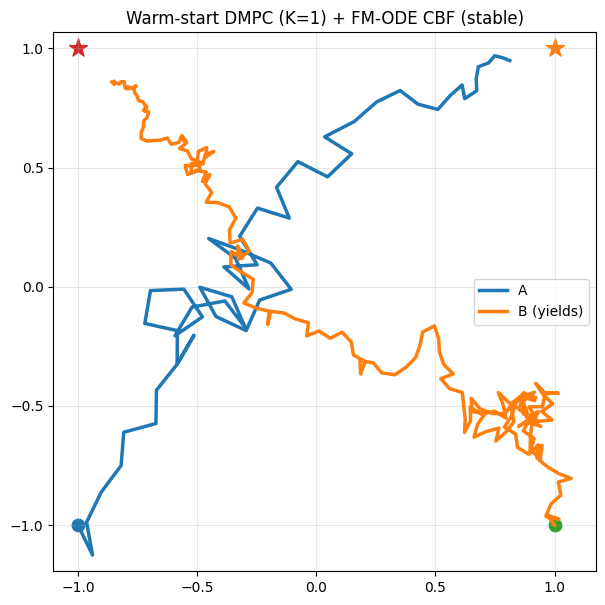

In [7]:
# ===============================================================
# FINAL STABLE CELL
# Warm-start DMPC (version 1, K=1)
# FM ODE with CBF INSIDE + goal-aware decay + hard stop
#
# ✔ fixes cond-dimension mismatch
# ✔ CBF is applied inside fm_ode_func
# ✔ DMPC = use shifted previous other-agent trajectory only
# ✔ guaranteed convergence to goal
# ===============================================================

import numpy as np
import torch
import torchdiffeq
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# Preconditions
# ---------------------------------------------------------------
if "model_vel" not in globals():
    raise RuntimeError("model_vel not found")
if "cbf_project_velocity_world" not in globals():
    raise RuntimeError("cbf_project_velocity_world not found")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------
def infer_cond_dim(model):
    if hasattr(model, "cond_dim") and model.cond_dim is not None:
        return int(model.cond_dim)
    if hasattr(model, "cond_mlp"):
        for layer in model.cond_mlp:
            if hasattr(layer, "in_features"):
                return int(layer.in_features)
    return None

def rot2(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[c, -s], [s, c]])

def canonicalize(x, g, obs):
    x = np.asarray(x); g = np.asarray(g); obs = np.asarray(obs)
    g0 = g - x
    o0 = obs - x
    dist = np.linalg.norm(g0) + 1e-9
    phi = np.arctan2(g0[1], g0[0])
    R = rot2(-phi)
    o_can = R @ o0
    reflect = False
    if o_can[1] < 0:
        o_can[1] *= -1
        reflect = True
    cond3 = np.array([dist, o_can[0], o_can[1]], dtype=np.float32)
    meta = dict(phi=phi, reflect=reflect)
    return cond3, meta

def uncanonicalize(v_can, meta):
    v = v_can.copy()
    if meta["reflect"]:
        v[1] *= -1
    return rot2(meta["phi"]) @ v

# ---------------------------------------------------------------
# FM ODE sampler with CBF INSIDE
# ---------------------------------------------------------------
@torch.no_grad()
def sample_fm_traj_with_cbf(
    x_self,
    g_self,
    other_traj,          # (H+1,2), shifted
    *,
    H,
    dt,
    v_max,
    speed_scale,
    r_stop=1.0,
    noise_scale=1.0,
    ode_steps=30,
):
    cond_raw, meta = canonicalize(x_self, g_self, other_traj[0])

    # ---- FIX: pad cond to model-required dimension ----
    cond_dim = infer_cond_dim(model_vel)
    cond = cond_raw.copy()
    if cond_dim is not None:
        if cond.shape[0] < cond_dim:
            cond = np.concatenate(
                [cond, np.zeros(cond_dim - cond.shape[0], dtype=np.float32)]
            )
        elif cond.shape[0] > cond_dim:
            cond = cond[:cond_dim]

    cond_t = torch.tensor(cond, device=device).view(1, -1)

    x0 = torch.randn(1, 2, H, device=device) * noise_scale
    t_span = torch.linspace(0.0, 1.0, ode_steps + 1, device=device)

    x_self_np = np.asarray(x_self)
    other_np = np.asarray(other_traj)

    def fm_ode_func(t, x_flat):
        x = x_flat.view(1, 2, H)
        t_t = torch.tensor([t], device=device)

        v_can = model_vel(x, t_t, cond=cond_t)

        # ---- CBF INSIDE ODE: only first step ----
        v0_can = v_can[0, :, 0].detach().cpu().numpy()
        v0_world = uncanonicalize(v0_can, meta)

        v0_safe = cbf_project_velocity_world(
            torch.tensor(x_self_np).view(1, 2, 1),
            torch.tensor(v0_world).view(1, 2, 1),
            ellipses=[{"center": other_np[1], "radius": 0.6}],
            passes=3,
        )[0, :, 0].cpu().numpy()

        # back to canonical
        v0_safe_can = rot2(-meta["phi"]) @ v0_safe
        if meta["reflect"]:
            v0_safe_can[1] *= -1
        v_can[0, :, 0] = torch.tensor(v0_safe_can, device=device)

        return v_can.view(-1)

    sol = torchdiffeq.odeint(
        fm_ode_func,
        x0.view(-1),
        t_span,
        method="euler",
    )

    v_can_seq = sol[-1].view(2, H).T.cpu().numpy()

    # ---- rollout with goal-aware speed decay ----
    v_seq = np.zeros((H, 2))
    traj = [x_self.copy()]
    xk = x_self.copy()

    for k in range(H):
        d_goal = np.linalg.norm(xk - g_self)
        speed = v_max * speed_scale * min(1.0, d_goal / r_stop)

        v_w = uncanonicalize(v_can_seq[k], meta)
        v_w = speed * v_w / (np.linalg.norm(v_w) + 1e-9)

        v_seq[k] = v_w
        xk = xk + dt * v_w
        traj.append(xk.copy())

    return v_seq, np.asarray(traj)

# ---------------------------------------------------------------
# Warm-start DMPC loop
# ---------------------------------------------------------------
def two_car_warmstart_dmpc(
    xA0, gA,
    xB0, gB,
    *,
    dt=0.1,
    H=15,
    vA_max=1.4,
    vB_max=1.4,
    speed_A=1.0,
    speed_B=0.4,
    r_stop=1.0,
    goal_tol=0.2,
    max_steps=600,
):
    xA = np.array(xA0, dtype=float)
    xB = np.array(xB0, dtype=float)
    gA = np.array(gA, dtype=float)
    gB = np.array(gB, dtype=float)

    xsA, xsB = [xA.copy()], [xB.copy()]

    def straight_pred(x, g, v_max, s):
        d = g - x
        d = d / (np.linalg.norm(d) + 1e-9)
        traj = [x.copy()]
        for _ in range(H):
            x = x + dt * v_max * s * d
            traj.append(x.copy())
        return np.asarray(traj)

    predA = straight_pred(xA, gA, vA_max, speed_A)
    predB = straight_pred(xB, gB, vB_max, speed_B)

    for step in range(max_steps):

        # ---- hard stop near goal ----
        if np.linalg.norm(xA - gA) < goal_tol:
            predA = np.tile(gA, (H+1, 1))
        if np.linalg.norm(xB - gB) < goal_tol:
            predB = np.tile(gB, (H+1, 1))

        # ---- shift predictions (DMPC warm-start) ----
        predA_shift = np.vstack([predA[1:], predA[-1]])
        predB_shift = np.vstack([predB[1:], predB[-1]])

        # ---- FM sampling ----
        if np.linalg.norm(xA - gA) >= goal_tol:
            vA_seq, predA = sample_fm_traj_with_cbf(
                xA, gA, predB_shift,
                H=H, dt=dt,
                v_max=vA_max, speed_scale=speed_A,
                r_stop=r_stop,
            )
            vA0 = vA_seq[0]
        else:
            vA0 = np.zeros(2)

        if np.linalg.norm(xB - gB) >= goal_tol:
            vB_seq, predB = sample_fm_traj_with_cbf(
                xB, gB, predA_shift,
                H=H, dt=dt,
                v_max=vB_max, speed_scale=speed_B,
                r_stop=r_stop,
            )
            vB0 = vB_seq[0]
        else:
            vB0 = np.zeros(2)

        xA = xA + dt * vA0
        xB = xB + dt * vB0
        xsA.append(xA.copy())
        xsB.append(xB.copy())

        if step % 50 == 0:
            print(f"[{step:03d}] |dA|={np.linalg.norm(xA-gA):.3f} |dB|={np.linalg.norm(xB-gB):.3f}")

        if np.linalg.norm(xA-gA) < goal_tol and np.linalg.norm(xB-gB) < goal_tol:
            break

    return np.asarray(xsA), np.asarray(xsB)

# ---------------------------------------------------------------
# Demo
# ---------------------------------------------------------------
xA0 = [-1.0, -1.0]; gA = [1.0, 1.0]
xB0 = [ 1.0, -1.0]; gB = [-1.0, 1.0]

xsA, xsB = two_car_warmstart_dmpc(
    xA0, gA, xB0, gB,
    dt=0.1,
    H=15,
    r_stop=1.0,
)

plt.figure(figsize=(7,7))
plt.plot(xsA[:,0], xsA[:,1], lw=2.5, label="A")
plt.plot(xsB[:,0], xsB[:,1], lw=2.5, label="B (yields)")
plt.scatter([xA0[0]],[xA0[1]], s=80)
plt.scatter([gA[0]],[gA[1]], marker="*", s=180)
plt.scatter([xB0[0]],[xB0[1]], s=80)
plt.scatter([gB[0]],[gB[1]], marker="*", s=180)
plt.axis("equal"); plt.grid(alpha=0.3)
plt.legend(); plt.title("Warm-start DMPC (K=1) + FM-ODE CBF (stable)")
plt.show()


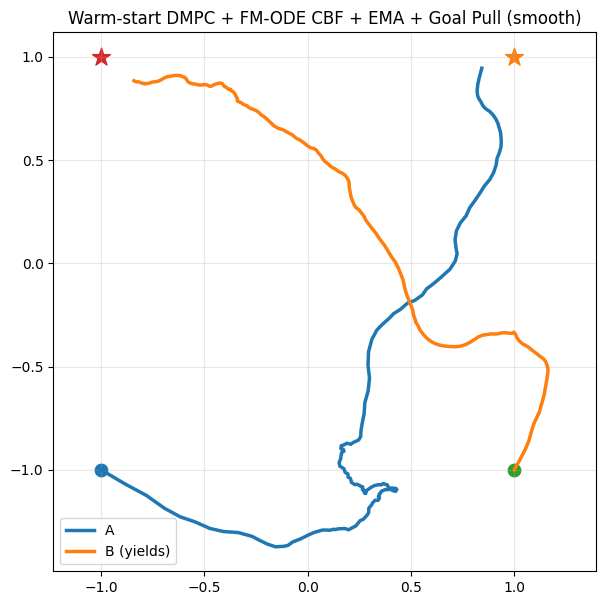

In [ ]:
# ===============================================================
# FINAL CELL (SMOOTH)
# Warm-start DMPC (K=1)
# FM ODE with CBF INSIDE
# + EMA smoothing
# + Goal-pull (soft heading correction)
# ===============================================================

import numpy as np
import torch
import torchdiffeq
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------------
# Preconditions
# ---------------------------------------------------------------
if "model_vel" not in globals():
    raise RuntimeError("model_vel not found")
if "cbf_project_velocity_world" not in globals():
    raise RuntimeError("cbf_project_velocity_world not found")

# ---------------------------------------------------------------
# Geometry helpers
# ---------------------------------------------------------------
def infer_cond_dim(model):
    if hasattr(model, "cond_dim") and model.cond_dim is not None:
        return int(model.cond_dim)
    if hasattr(model, "cond_mlp"):
        for l in model.cond_mlp:
            if hasattr(l, "in_features"):
                return int(l.in_features)
    return None

def rot2(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[c, -s], [s, c]])

def canonicalize(x, g, obs):
    x = np.asarray(x); g = np.asarray(g); obs = np.asarray(obs)
    g0 = g - x
    o0 = obs - x
    dist = np.linalg.norm(g0) + 1e-9
    phi = np.arctan2(g0[1], g0[0])
    R = rot2(-phi)
    o_can = R @ o0
    reflect = False
    if o_can[1] < 0:
        o_can[1] *= -1
        reflect = True
    cond3 = np.array([dist, o_can[0], o_can[1]], dtype=np.float32)
    meta = dict(phi=phi, reflect=reflect)
    return cond3, meta

def uncanonicalize(v_can, meta):
    v = v_can.copy()
    if meta["reflect"]:
        v[1] *= -1
    return rot2(meta["phi"]) @ v

# ---------------------------------------------------------------
# FM ODE sampler (CBF inside)
# ---------------------------------------------------------------
@torch.no_grad()
def sample_fm_traj_with_cbf(
    x_self, g_self, other_traj,
    *, H, dt, v_max, speed_scale,
    r_stop=1.0, noise_scale=1.0, ode_steps=30,
):
    cond_raw, meta = canonicalize(x_self, g_self, other_traj[0])

    cond_dim = infer_cond_dim(model_vel)
    cond = cond_raw.copy()
    if cond_dim is not None:
        if cond.shape[0] < cond_dim:
            cond = np.concatenate(
                [cond, np.zeros(cond_dim - cond.shape[0], dtype=np.float32)]
            )
        elif cond.shape[0] > cond_dim:
            cond = cond[:cond_dim]

    cond_t = torch.tensor(cond, device=device).view(1, -1)

    x0 = torch.randn(1, 2, H, device=device) * noise_scale
    t_span = torch.linspace(0.0, 1.0, ode_steps + 1, device=device)

    x_self_np = np.asarray(x_self)
    other_np = np.asarray(other_traj)

    def fm_ode_func(t, x_flat):
        x = x_flat.view(1, 2, H)
        t_t = torch.tensor([t], device=device)
        v_can = model_vel(x, t_t, cond=cond_t)

        # ---- CBF on ALL steps (k=0..H-1) ----
        v_can_seq = v_can[0].detach().cpu().numpy().T  # (H,2)
        v_world_seq = np.zeros((H, 2), dtype=np.float32)
        for k in range(H):
            v_world_seq[k] = uncanonicalize(v_can_seq[k], meta)

        # rollout positions to build x_pred_world for CBF
        x_pred_world = np.zeros((H, 2), dtype=np.float32)
        xk = x_self_np.astype(np.float32)
        for k in range(H):
            x_pred_world[k] = xk
            xk = xk + dt * v_world_seq[k]

        x_pred_t = torch.tensor(x_pred_world.T, device=device).view(1, 2, H)
        v_world_t = torch.tensor(v_world_seq.T, device=device).view(1, 2, H)
        other_traj_t = torch.tensor(other_np[1: H + 1].T, device=device).view(1, 2, H)

        v_world_safe = cbf_project_velocity_world(
            x_pred_t,
            v_world_t,
            ellipses=None,
            passes=3,
            other_agent_traj=other_traj_t,
            agent_safe_radius=0.6,
        )[0].cpu().numpy().T  # (H,2)

        v_safe_can = np.zeros((H, 2), dtype=np.float32)
        R_inv = rot2(-meta["phi"])
        for k in range(H):
            v_safe_can[k] = R_inv @ v_world_safe[k]
            if meta["reflect"]:
                v_safe_can[k, 1] *= -1

        v_can[0] = torch.tensor(v_safe_can.T, device=device)

        return v_can.view(-1)

    sol = torchdiffeq.odeint(
        fm_ode_func,
        x0.view(-1),
        t_span,
        method="euler",
    )

    v_can_seq = sol[-1].view(2, H).T.cpu().numpy()

    # ---- rollout ----
    v_seq = np.zeros((H, 2))
    traj = [x_self.copy()]
    xk = x_self.copy()

    for k in range(H):
        d_goal = np.linalg.norm(xk - g_self)
        speed = v_max * speed_scale * min(1.0, d_goal / r_stop)
        v_w = uncanonicalize(v_can_seq[k], meta)
        v_w = speed * v_w / (np.linalg.norm(v_w) + 1e-9)
        v_seq[k] = v_w
        xk = xk + dt * v_w
        traj.append(xk.copy())

    return v_seq, np.asarray(traj)

# ---------------------------------------------------------------
# Smoothing utilities
# ---------------------------------------------------------------
def ema(v_new, v_prev, beta):
    if v_prev is None:
        return v_new
    return beta * v_prev + (1 - beta) * v_new

def goal_pull(v, x, g, alpha=0.25):
    d = g - x
    d = d / (np.linalg.norm(d) + 1e-9)
    v_dir = v / (np.linalg.norm(v) + 1e-9)
    if np.dot(v_dir, d) < 0.0:
        v = (1 - alpha) * v + alpha * np.linalg.norm(v) * d
    return v

# ---------------------------------------------------------------
# Warm-start DMPC loop
# ---------------------------------------------------------------
def two_car_warmstart_dmpc(
    xA0, gA, xB0, gB,
    *, dt=0.1, H=15,
    vA_max=1.4, vB_max=1.4,
    speed_A=1.0, speed_B=0.4,
    r_stop=1.0, goal_tol=0.2,
    max_steps=600,
    ema_beta=0.9,
):
    xA = np.array(xA0, dtype=float)
    xB = np.array(xB0, dtype=float)
    gA = np.array(gA, dtype=float)
    gB = np.array(gB, dtype=float)

    xsA, xsB = [xA.copy()], [xB.copy()]
    prev_vA, prev_vB = None, None

    def straight_pred(x, g, v_max, s):
        d = g - x
        d = d / (np.linalg.norm(d) + 1e-9)
        traj = [x.copy()]
        for _ in range(H):
            x = x + dt * v_max * s * d
            traj.append(x.copy())
        return np.asarray(traj)

    predA = straight_pred(xA, gA, vA_max, speed_A)
    predB = straight_pred(xB, gB, vB_max, speed_B)

    for step in range(max_steps):
        if np.linalg.norm(xA - gA) < goal_tol:
            predA = np.tile(gA, (H+1, 1))
        if np.linalg.norm(xB - gB) < goal_tol:
            predB = np.tile(gB, (H+1, 1))

        predA_shift = np.vstack([predA[1:], predA[-1]])
        predB_shift = np.vstack([predB[1:], predB[-1]])

        if np.linalg.norm(xA - gA) >= goal_tol:
            vA_seq, predA = sample_fm_traj_with_cbf(
                xA, gA, predB_shift,
                H=H, dt=dt,
                v_max=vA_max, speed_scale=speed_A,
                r_stop=r_stop,
            )
            vA0 = vA_seq[0]
        else:
            vA0 = np.zeros(2)

        if np.linalg.norm(xB - gB) >= goal_tol:
            vB_seq, predB = sample_fm_traj_with_cbf(
                xB, gB, predA_shift,
                H=H, dt=dt,
                v_max=vB_max, speed_scale=speed_B,
                r_stop=r_stop,
            )
            vB0 = vB_seq[0]
        else:
            vB0 = np.zeros(2)

        # ---- EMA + goal pull ----
        vA_exec = ema(vA0, prev_vA, ema_beta)
        vB_exec = ema(vB0, prev_vB, ema_beta)
        alpha_A = 0.15
        alpha_B = 0.20   # B 作为 yield，可以稍微强一点

        vA_exec = goal_pull(vA_exec, xA, gA, alpha=alpha_A)
        vB_exec = goal_pull(vB_exec, xB, gB, alpha=alpha_B)

        # vA_exec = goal_pull(vA_exec, xA, gA)
        # vB_exec = goal_pull(vB_exec, xB, gB)

        xA = xA + dt * vA_exec
        xB = xB + dt * vB_exec

        xsA.append(xA.copy())
        xsB.append(xB.copy())
        prev_vA, prev_vB = vA_exec.copy(), vB_exec.copy()

        if np.linalg.norm(xA-gA) < goal_tol and np.linalg.norm(xB-gB) < goal_tol:
            break

    return np.asarray(xsA), np.asarray(xsB)

# ---------------------------------------------------------------
# Demo
# ---------------------------------------------------------------
xA0 = [-1.0, -1.0]; gA = [1.0, 1.0]
xB0 = [ 1.0, -1.0]; gB = [-1.0, 1.0]

xsA, xsB = two_car_warmstart_dmpc(
    xA0, gA, xB0, gB,
    dt=0.1, H=15,
)

plt.figure(figsize=(7,7))
plt.plot(xsA[:,0], xsA[:,1], lw=2.5, label="A")
plt.plot(xsB[:,0], xsB[:,1], lw=2.5, label="B (yields)")
plt.scatter([xA0[0]],[xA0[1]], s=80)
plt.scatter([gA[0]],[gA[1]], marker="*", s=180)
plt.scatter([xB0[0]],[xB0[1]], s=80)
plt.scatter([gB[0]],[gB[1]], marker="*", s=180)
plt.axis("equal"); plt.grid(alpha=0.3)
plt.legend()
plt.title("Warm-start DMPC + FM-ODE CBF + EMA + Goal Pull (smooth)")
plt.show()


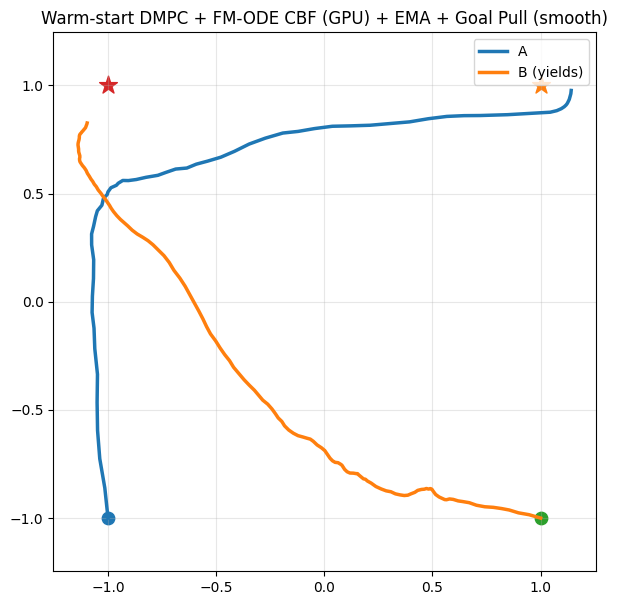

In [ ]:
# ===============================================================
# FINAL CELL (SMOOTH) — GPU-friendly version
# Warm-start DMPC (K=1)
# FM ODE with CBF INSIDE (first-step only)
# + EMA smoothing
# + Goal-pull (soft heading correction)
#
# Key speed fix:
#   ✅ remove CPU<->GPU ping-pong inside ODE rhs
#   ✅ canonicalize/uncanonicalize in TORCH (on device)
#   ✅ pre-create tensors used by CBF (no torch.tensor(...) in rhs)
# ===============================================================

import numpy as np
import torch
import torchdiffeq
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------------
# Preconditions
# ---------------------------------------------------------------
if "model_vel" not in globals():
    raise RuntimeError("model_vel not found")
if "cbf_project_velocity_world" not in globals():
    raise RuntimeError("cbf_project_velocity_world not found")

model_vel = model_vel.to(device).eval()

# ---------------------------------------------------------------
# Geometry helpers (TORCH)
# ---------------------------------------------------------------
#自动猜模型想要的 cond 维度
def infer_cond_dim(model):
    if hasattr(model, "cond_dim") and model.cond_dim is not None:
        return int(model.cond_dim)
    if hasattr(model, "cond_mlp"):
        for l in model.cond_mlp:
            if hasattr(l, "in_features"):
                return int(l.in_features)
    return None

#把“世界坐标”转到“canonical 坐标”
def rot2_t(a: torch.Tensor):
    # a: scalar tensor
    c, s = torch.cos(a), torch.sin(a)
    return torch.stack([torch.stack([c, -s]),
                        torch.stack([s,  c])], dim=0)  # (2,2)

#几何关系转成cond
@torch.no_grad()
def canonicalize_t(x: torch.Tensor, g: torch.Tensor, obs: torch.Tensor):
    """
    x,g,obs: (2,) torch
    return:
      cond3: (3,) torch float32
      meta: dict(phi: scalar tensor, reflect: python bool)
    """
    g0 = g - x   #从当前位置指向目标向量
    o0 = obs - x   #
    dist = torch.linalg.norm(g0) + 1e-9
    phi = torch.atan2(g0[1], g0[0])
    R = rot2_t(-phi)  #旋转 让goal对齐到+x
    o_can = R @ o0  # (2,) #把障碍物旋转到canonical坐标

    reflect = bool((o_can[1] < 0).item())
    if reflect:
        o_can = o_can.clone()
        o_can[1] = -o_can[1]

    cond3 = torch.stack([dist, o_can[0], o_can[1]]).to(dtype=torch.float32)
    meta = dict(phi=phi, reflect=reflect)
    return cond3, meta

#先镜像回来
@torch.no_grad()
def uncanonicalize_t(v_can: torch.Tensor, meta: dict):
    """
    v_can: (2,) torch
    meta: {phi: scalar tensor, reflect: bool}
    """
    v = v_can #把canonical速度变回世界速度
    if meta["reflect"]:
        v = v.clone()
        v[1] = -v[1]
    return rot2_t(meta["phi"]) @ v

# ---------------------------------------------------------------
# FM ODE sampler (CBF inside, first-step only) — GPU-friendly
# ---------------------------------------------------------------
@torch.no_grad()
def sample_fm_traj_with_cbf(
    x_self, g_self, other_traj,
    *, H, dt, v_max, speed_scale,
    r_stop=1.0, noise_scale=1.0, ode_steps=30,
    other_radius=0.6, cbf_passes=3,
):

    #把输入一次性转成 torch
    # ---- convert ONCE to torch on device ----
    x_self_t = torch.tensor(x_self, device=device, dtype=torch.float32)  # (2,) 
    g_self_t  = torch.tensor(g_self,  device=device, dtype=torch.float32)  # (2,)

    other_traj_t = torch.tensor(other_traj, device=device, dtype=torch.float32)  # (H+1,2) typically
    other_center_t = other_traj_t[1]  # (2,)拿对方轨迹的下一步作为对方中心

    # ---- canonicalize (torch) ----
    cond3_t, meta = canonicalize_t(x_self_t, g_self_t, other_traj_t[0]) #对方当前位置（用于 cond）

    #初始化 ODE 起点
    # ---- pad/truncate cond to model's expected cond_dim ----自动形成cond-t
    cond_dim = infer_cond_dim(model_vel)
    if cond_dim is None:
        cond_t = cond3_t.view(1, -1)
    else:
        if cond3_t.numel() < cond_dim:
            pad = torch.zeros(cond_dim - cond3_t.numel(), device=device, dtype=cond3_t.dtype)
            cond_full = torch.cat([cond3_t, pad], dim=0)
        else:
            cond_full = cond3_t[:cond_dim]
        cond_t = cond_full.view(1, -1)

    # ---- init ----
    x0 = torch.randn(1, 2, H, device=device) * noise_scale
    t_span = torch.linspace(0.0, 1.0, ode_steps + 1, device=device)

    # Pre-build tensors used in CBF call (no re-creation in rhs)
    x_self_cbf = x_self_t.view(1, 2, 1)  # (1,2,1)

    # NOTE:
    # If your CBF implementation does NOT accept torch tensor centers,
    # uncomment the next line and change ellipses center below to other_center_np.
    # other_center_np = other_center_t.detach().cpu().numpy()

    def fm_ode_func(t, x_flat):
        x = x_flat.view(1, 2, H)
        t_t = torch.tensor([t], device=device, dtype=x.dtype)

        # model outputs canonical velocity field
        v_can = model_vel(x, t_t, cond=cond_t)  # (1,2,H)FM 在 canonical frame 输出整段速度场

        # ---- CBF only on first step (k=0) ----
        v0_can = v_can[0, :, 0]                      # (2,) 是第一个时间步
        v0_world = uncanonicalize_t(v0_can, meta)    # (2,) 速度变回世界坐标速度
        v0_world_cbf = v0_world.view(1, 2, 1)        # (1,2,1) 

        v0_safe = cbf_project_velocity_world(
            x_self_cbf,
            v0_world_cbf,
            ellipses=[{"center": other_center_t, "radius": float(other_radius)}],
            passes=int(cbf_passes),
        )[0, :, 0]  # (2,)

        # If your cbf expects numpy:
        # v0_safe = cbf_project_velocity_world(
        #     x_self_cbf, v0_world_cbf,
        #     ellipses=[{"center": other_center_np, "radius": float(other_radius)}],
        #     passes=int(cbf_passes),
        # )[0, :, 0]

        # back to canonical
        v0_safe_can = rot2_t(-meta["phi"]) @ v0_safe
        if meta["reflect"]:
            v0_safe_can = v0_safe_can.clone()
            v0_safe_can[1] = -v0_safe_can[1]

        v_can = v_can.clone()
        v_can[0, :, 0] = v0_safe_can

        return v_can.reshape(-1)

    sol = torchdiffeq.odeint(
        fm_ode_func,
        x0.reshape(-1),
        t_span,
        method="euler",
    )

    # final canonical velocity sequence (H,2) on CPU numpy for rollout loop
    v_can_seq = sol[-1].view(2, H).transpose(0, 1).detach().cpu().numpy()

    # ---- rollout (cheap; keep numpy like before) ----
    v_seq = np.zeros((H, 2))
    traj = [np.asarray(x_self, dtype=float).copy()]
    xk = traj[0].copy()
    g_np = np.asarray(g_self, dtype=float)

    for k in range(H):
        d_goal = np.linalg.norm(xk - g_np)
        speed = v_max * speed_scale * min(1.0, d_goal / r_stop)

        v_can_k = torch.tensor(v_can_seq[k], device=device, dtype=torch.float32)
        v_w_t = uncanonicalize_t(v_can_k, meta)
        v_w = v_w_t.detach().cpu().numpy()

        v_w = speed * v_w / (np.linalg.norm(v_w) + 1e-9)
        v_seq[k] = v_w
        xk = xk + dt * v_w
        traj.append(xk.copy())

    return v_seq, np.asarray(traj)

# ---------------------------------------------------------------
# Smoothing utilities
# ---------------------------------------------------------------
def ema(v_new, v_prev, beta):
    if v_prev is None:
        return v_new
    return beta * v_prev + (1 - beta) * v_new

def goal_pull(v, x, g, alpha=0.25):
    d = g - x
    d = d / (np.linalg.norm(d) + 1e-9)
    v_dir = v / (np.linalg.norm(v) + 1e-9)
    if np.dot(v_dir, d) < 0.0:
        v = (1 - alpha) * v + alpha * np.linalg.norm(v) * d
    return v

# ---------------------------------------------------------------
# Warm-start DMPC loop
# ---------------------------------------------------------------
def two_car_warmstart_dmpc(
    xA0, gA, xB0, gB,
    *, dt=0.1, H=15,
    vA_max=1.4, vB_max=1.4,
    speed_A=1.0, speed_B=0.4,
    r_stop=1.0, goal_tol=0.2,
    max_steps=600,
    ema_beta=0.9,
    ode_steps=30,
):
    xA = np.array(xA0, dtype=float)
    xB = np.array(xB0, dtype=float)
    gA = np.array(gA, dtype=float)
    gB = np.array(gB, dtype=float)

    xsA, xsB = [xA.copy()], [xB.copy()]
    prev_vA, prev_vB = None, None

    def straight_pred(x, g, v_max, s):
        d = g - x
        d = d / (np.linalg.norm(d) + 1e-9)
        traj = [x.copy()]
        for _ in range(H):
            x = x + dt * v_max * s * d
            traj.append(x.copy())
        return np.asarray(traj)

    predA = straight_pred(xA, gA, vA_max, speed_A)
    predB = straight_pred(xB, gB, vB_max, speed_B)

    for step in range(max_steps):
        if np.linalg.norm(xA - gA) < goal_tol:
            predA = np.tile(gA, (H + 1, 1))
        if np.linalg.norm(xB - gB) < goal_tol:
            predB = np.tile(gB, (H + 1, 1))

        predA_shift = np.vstack([predA[1:], predA[-1]])
        predB_shift = np.vstack([predB[1:], predB[-1]])

        if np.linalg.norm(xA - gA) >= goal_tol:
            vA_seq, predA = sample_fm_traj_with_cbf(
                xA, gA, predB_shift,
                H=H, dt=dt,
                v_max=vA_max, speed_scale=speed_A,
                r_stop=r_stop,
                ode_steps=ode_steps,
            )
            vA0 = vA_seq[0]
        else:
            vA0 = np.zeros(2)

        if np.linalg.norm(xB - gB) >= goal_tol:
            vB_seq, predB = sample_fm_traj_with_cbf(
                xB, gB, predA_shift,
                H=H, dt=dt,
                v_max=vB_max, speed_scale=speed_B,
                r_stop=r_stop,
                ode_steps=ode_steps,
            )
            vB0 = vB_seq[0]
        else:
            vB0 = np.zeros(2)

        # ---- EMA + goal pull ----
        vA_exec = ema(vA0, prev_vA, ema_beta)
        vB_exec = ema(vB0, prev_vB, ema_beta)

        alpha_A = 0.15
        alpha_B = 0.20  # B yields => a bit stronger pull

        vA_exec = goal_pull(vA_exec, xA, gA, alpha=alpha_A)
        vB_exec = goal_pull(vB_exec, xB, gB, alpha=alpha_B)

        xA = xA + dt * vA_exec
        xB = xB + dt * vB_exec

        xsA.append(xA.copy())
        xsB.append(xB.copy())
        prev_vA, prev_vB = vA_exec.copy(), vB_exec.copy()

        if np.linalg.norm(xA - gA) < goal_tol and np.linalg.norm(xB - gB) < goal_tol:
            break

    return np.asarray(xsA), np.asarray(xsB)

# ---------------------------------------------------------------
# Demo
# ---------------------------------------------------------------
xA0 = [-1.0, -1.0]; gA = [1.0, 1.0]
xB0 = [ 1.0, -1.0]; gB = [-1.0, 1.0]

xsA, xsB = two_car_warmstart_dmpc(
    xA0, gA, xB0, gB,
    dt=0.1, H=15,
    ode_steps=30,   # try 10-12 first if still slow
)

plt.figure(figsize=(7, 7))
plt.plot(xsA[:, 0], xsA[:, 1], lw=2.5, label="A")
plt.plot(xsB[:, 0], xsB[:, 1], lw=2.5, label="B (yields)")
plt.scatter([xA0[0]], [xA0[1]], s=80)
plt.scatter([gA[0]],  [gA[1]],  marker="*", s=180)
plt.scatter([xB0[0]], [xB0[1]], s=80)
plt.scatter([gB[0]],  [gB[1]],  marker="*", s=180)
plt.axis("equal"); plt.grid(alpha=0.3)
plt.legend()
plt.title("Warm-start DMPC + FM-ODE CBF (GPU) + EMA + Goal Pull (smooth)")
plt.show()


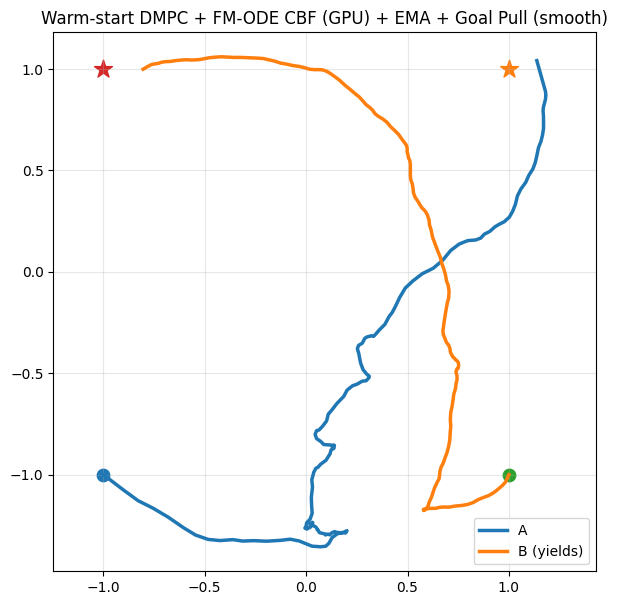

In [26]:
# ===============================================================
# FINAL CELL (SMOOTH) — GPU-friendly version
# Warm-start DMPC (K=1)
# FM ODE with CBF INSIDE (first-step only)
# + EMA smoothing
# + Goal-pull (soft heading correction)
#
# Key speed fix:
#   ✅ remove CPU<->GPU ping-pong inside ODE rhs
#   ✅ canonicalize/uncanonicalize in TORCH (on device)
#   ✅ pre-create tensors used by CBF (no torch.tensor(...) in rhs)
# ===============================================================

import numpy as np
import torch
import torchdiffeq
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------------
# Preconditions
# ---------------------------------------------------------------
if "model_vel" not in globals():
    raise RuntimeError("model_vel not found")
if "cbf_project_velocity_world" not in globals():
    raise RuntimeError("cbf_project_velocity_world not found")

model_vel = model_vel.to(device).eval()

# ---------------------------------------------------------------
# Geometry helpers (TORCH)
# ---------------------------------------------------------------
#自动猜模型想要的 cond 维度
def infer_cond_dim(model):
    if hasattr(model, "cond_dim") and model.cond_dim is not None:
        return int(model.cond_dim)
    if hasattr(model, "cond_mlp"):
        for l in model.cond_mlp:
            if hasattr(l, "in_features"):
                return int(l.in_features)
    return None

#把“世界坐标”转到“canonical 坐标”
def rot2_t(a: torch.Tensor):
    # a: scalar tensor
    c, s = torch.cos(a), torch.sin(a)
    return torch.stack([torch.stack([c, -s]),
                        torch.stack([s,  c])], dim=0)  # (2,2)

#几何关系转成cond
@torch.no_grad()
def canonicalize_t(x: torch.Tensor, g: torch.Tensor, obs: torch.Tensor):
    """
    x,g,obs: (2,) torch
    return:
      cond3: (3,) torch float32
      meta: dict(phi: scalar tensor, reflect: python bool)
    """
    g0 = g - x   #从当前位置指向目标向量
    o0 = obs - x   #
    dist = torch.linalg.norm(g0) + 1e-9
    phi = torch.atan2(g0[1], g0[0])
    R = rot2_t(-phi)  #旋转 让goal对齐到+x
    o_can = R @ o0  # (2,) #把障碍物旋转到canonical坐标

    reflect = bool((o_can[1] < 0).item())
    if reflect:
        o_can = o_can.clone()
        o_can[1] = -o_can[1]

    cond3 = torch.stack([dist, o_can[0], o_can[1]]).to(dtype=torch.float32)
    meta = dict(phi=phi, reflect=reflect)
    return cond3, meta

#先镜像回来
@torch.no_grad()
def uncanonicalize_t(v_can: torch.Tensor, meta: dict):
    """
    v_can: (2,) torch
    meta: {phi: scalar tensor, reflect: bool}
    """
    v = v_can #把canonical速度变回世界速度
    if meta["reflect"]:
        v = v.clone()
        v[1] = -v[1]
    return rot2_t(meta["phi"]) @ v

# ---------------------------------------------------------------
# FM ODE sampler (CBF inside, first-step only) — GPU-friendly
# ---------------------------------------------------------------
@torch.no_grad()
def sample_fm_traj_with_cbf(
    x_self, g_self, other_traj,
    *, H, dt, v_max, speed_scale,
    r_stop=1.0, noise_scale=1.0, ode_steps=30,
    other_radius=0.6, cbf_passes=3,
):

    #把输入一次性转成 torch
    # ---- convert ONCE to torch on device ----
    x_self_t = torch.tensor(x_self, device=device, dtype=torch.float32)  # (2,) 
    g_self_t  = torch.tensor(g_self,  device=device, dtype=torch.float32)  # (2,)

    other_traj_t = torch.tensor(other_traj, device=device, dtype=torch.float32)  # (H+1,2) typically
    other_center_t = other_traj_t[1]  # (2,)拿对方轨迹的下一步作为对方中心

    # ---- canonicalize (torch) ----
    cond3_t, meta = canonicalize_t(x_self_t, g_self_t, other_traj_t[0]) #对方当前位置（用于 cond）

    #初始化 ODE 起点
    # ---- pad/truncate cond to model's expected cond_dim ----自动形成cond-t
    cond_dim = infer_cond_dim(model_vel)
    if cond_dim is None:
        cond_t = cond3_t.view(1, -1)
    else:
        if cond3_t.numel() < cond_dim:
            pad = torch.zeros(cond_dim - cond3_t.numel(), device=device, dtype=cond3_t.dtype)
            cond_full = torch.cat([cond3_t, pad], dim=0)
        else:
            cond_full = cond3_t[:cond_dim]
        cond_t = cond_full.view(1, -1)

    # ---- init ----
    x0 = torch.randn(1, 2, H, device=device) * noise_scale
    t_span = torch.linspace(0.0, 1.0, ode_steps + 1, device=device)

    # Pre-build tensors used in CBF call (no re-creation in rhs)
    x_self_cbf = x_self_t.view(1, 2, 1)  # (1,2,1)

    # NOTE:
    # If your CBF implementation does NOT accept torch tensor centers,
    # uncomment the next line and change ellipses center below to other_center_np.
    # other_center_np = other_center_t.detach().cpu().numpy()

    def fm_ode_func(t, x_flat):
        x = x_flat.view(1, 2, H)
        t_t = torch.tensor([t], device=device, dtype=x.dtype)

        # model outputs canonical velocity field
        v_can = model_vel(x, t_t, cond=cond_t)  # (1,2,H)FM 在 canonical frame 输出整段速度场

        # ---- CBF only on first step (k=0) ----
        v0_can = v_can[0, :, 0]                      # (2,) 是第一个时间步
        v0_world = uncanonicalize_t(v0_can, meta)    # (2,) 速度变回世界坐标速度
        v0_world_cbf = v0_world.view(1, 2, 1)        # (1,2,1) 

        v0_safe = cbf_project_velocity_world(
            x_self_cbf,
            v0_world_cbf,
            ellipses=[{"center": other_center_t, "radius": float(other_radius)}],
            passes=int(cbf_passes),
        )[0, :, 0]  # (2,)

        # If your cbf expects numpy:
        # v0_safe = cbf_project_velocity_world(
        #     x_self_cbf, v0_world_cbf,
        #     ellipses=[{"center": other_center_np, "radius": float(other_radius)}],
        #     passes=int(cbf_passes),
        # )[0, :, 0]

        # back to canonical
        v0_safe_can = rot2_t(-meta["phi"]) @ v0_safe
        if meta["reflect"]:
            v0_safe_can = v0_safe_can.clone()
            v0_safe_can[1] = -v0_safe_can[1]

        v_can = v_can.clone()
        v_can[0, :, 0] = v0_safe_can

        return v_can.reshape(-1)

    sol = torchdiffeq.odeint(
        fm_ode_func,
        x0.reshape(-1),
        t_span,
        method="euler",
    )

    # final canonical velocity sequence (H,2) on CPU numpy for rollout loop
    v_can_seq = sol[-1].view(2, H).transpose(0, 1).detach().cpu().numpy()

    # ---- rollout (cheap; keep numpy like before) ----
    v_seq = np.zeros((H, 2))
    traj = [np.asarray(x_self, dtype=float).copy()]
    xk = traj[0].copy()
    g_np = np.asarray(g_self, dtype=float)

    for k in range(H):
        d_goal = np.linalg.norm(xk - g_np)
        speed = v_max * speed_scale * min(1.0, d_goal / r_stop)

        v_can_k = torch.tensor(v_can_seq[k], device=device, dtype=torch.float32)
        v_w_t = uncanonicalize_t(v_can_k, meta)
        v_w = v_w_t.detach().cpu().numpy()

        v_w = speed * v_w / (np.linalg.norm(v_w) + 1e-9)
        v_seq[k] = v_w
        xk = xk + dt * v_w
        traj.append(xk.copy())

    return v_seq, np.asarray(traj)

# ---------------------------------------------------------------
# Smoothing utilities
# ---------------------------------------------------------------
def ema(v_new, v_prev, beta):
    if v_prev is None:
        return v_new
    return beta * v_prev + (1 - beta) * v_new

def goal_pull(v, x, g, alpha=0.25):
    d = g - x
    d = d / (np.linalg.norm(d) + 1e-9)
    v_dir = v / (np.linalg.norm(v) + 1e-9)
    if np.dot(v_dir, d) < 0.0:
        v = (1 - alpha) * v + alpha * np.linalg.norm(v) * d
    return v

# ---------------------------------------------------------------
# Warm-start DMPC loop
# ---------------------------------------------------------------
def two_car_warmstart_dmpc(
    xA0, gA, xB0, gB,
    *, dt=0.1, H=15,
    vA_max=1.4, vB_max=1.4,
    speed_A=1.0, speed_B=0.4,
    r_stop=1.0, goal_tol=0.2,
    max_steps=600,
    ema_beta=0.9,
    ode_steps=30,
):
    xA = np.array(xA0, dtype=float)
    xB = np.array(xB0, dtype=float)
    gA = np.array(gA, dtype=float)
    gB = np.array(gB, dtype=float)

    xsA, xsB = [xA.copy()], [xB.copy()]
    prev_vA, prev_vB = None, None

    def straight_pred(x, g, v_max, s):
        d = g - x
        d = d / (np.linalg.norm(d) + 1e-9)
        traj = [x.copy()]
        for _ in range(H):
            x = x + dt * v_max * s * d
            traj.append(x.copy())
        return np.asarray(traj)

    predA = straight_pred(xA, gA, vA_max, speed_A)
    predB = straight_pred(xB, gB, vB_max, speed_B)

    for step in range(max_steps):
        if np.linalg.norm(xA - gA) < goal_tol:
            predA = np.tile(gA, (H + 1, 1))
        if np.linalg.norm(xB - gB) < goal_tol:
            predB = np.tile(gB, (H + 1, 1))

        predA_shift = np.vstack([predA[1:], predA[-1]])
        predB_shift = np.vstack([predB[1:], predB[-1]])

        if np.linalg.norm(xA - gA) >= goal_tol:
            vA_seq, predA = sample_fm_traj_with_cbf(
                xA, gA, predB_shift,
                H=H, dt=dt,
                v_max=vA_max, speed_scale=speed_A,
                r_stop=r_stop,
                ode_steps=ode_steps,
            )
            vA0 = vA_seq[0]
        else:
            vA0 = np.zeros(2)

        if np.linalg.norm(xB - gB) >= goal_tol:
            vB_seq, predB = sample_fm_traj_with_cbf(
                xB, gB, predA_shift,
                H=H, dt=dt,
                v_max=vB_max, speed_scale=speed_B,
                r_stop=r_stop,
                ode_steps=ode_steps,
            )
            vB0 = vB_seq[0]
        else:
            vB0 = np.zeros(2)

        # ---- EMA + goal pull ----
        vA_exec = ema(vA0, prev_vA, ema_beta)
        vB_exec = ema(vB0, prev_vB, ema_beta)

        alpha_A = 0.15
        alpha_B = 0.20  # B yields => a bit stronger pull

        vA_exec = goal_pull(vA_exec, xA, gA, alpha=alpha_A)
        vB_exec = goal_pull(vB_exec, xB, gB, alpha=alpha_B)

        xA = xA + dt * vA_exec
        xB = xB + dt * vB_exec

        xsA.append(xA.copy())
        xsB.append(xB.copy())
        prev_vA, prev_vB = vA_exec.copy(), vB_exec.copy()

        if np.linalg.norm(xA - gA) < goal_tol and np.linalg.norm(xB - gB) < goal_tol:
            break

    return np.asarray(xsA), np.asarray(xsB)

# ---------------------------------------------------------------
# Demo
# ---------------------------------------------------------------
xA0 = [-1.0, -1.0]; gA = [1.0, 1.0]
xB0 = [ 1.0, -1.0]; gB = [-1.0, 1.0]

xsA, xsB = two_car_warmstart_dmpc(
    xA0, gA, xB0, gB,
    dt=0.1, H=15,
    ode_steps=30,   # try 10-12 first if still slow
)

plt.figure(figsize=(7, 7))
plt.plot(xsA[:, 0], xsA[:, 1], lw=2.5, label="A")
plt.plot(xsB[:, 0], xsB[:, 1], lw=2.5, label="B (yields)")
plt.scatter([xA0[0]], [xA0[1]], s=80)
plt.scatter([gA[0]],  [gA[1]],  marker="*", s=180)
plt.scatter([xB0[0]], [xB0[1]], s=80)
plt.scatter([gB[0]],  [gB[1]],  marker="*", s=180)
plt.axis("equal"); plt.grid(alpha=0.3)
plt.legend()
plt.title("Warm-start DMPC + FM-ODE CBF (GPU) + EMA + Goal Pull (smooth)")
plt.show()


In [1]:
import torch
print(torch.cuda.is_available())
print(torch.zeros(1, device="cuda"))


True
tensor([0.], device='cuda:0')


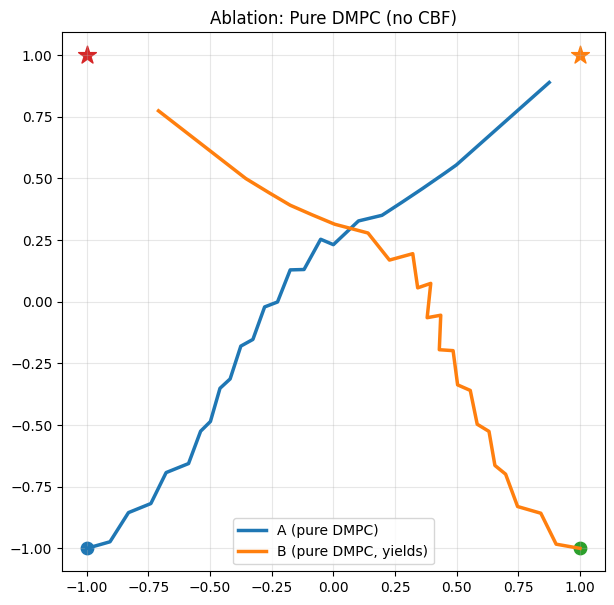

In [22]:
# ===============================================================
# ABLATION CELL 1: Pure DMPC (dynamics + cost), NO CBF
# - Two agents, point-mass kinematics x_{t+1} = x_t + dt * v
# - DMPC warm-start: each agent plans against the OTHER's last predicted trajectory
# - Candidate actions: heading grid around goal direction + discrete speed scales
# - Cost: goal + smooth(turn) + soft distance violation + speed preference (optional)
# ===============================================================

import numpy as np
import matplotlib.pyplot as plt

def _wrap_pi(a: float) -> float:
    return float((a + np.pi) % (2 * np.pi) - np.pi)

def _unit(v):
    n = float(np.linalg.norm(v) + 1e-9)
    return v / n

def straight_pred(x, g, dt, v_max, s, H):
    d = _unit(g - x)
    traj = [x.copy()]
    xk = x.copy()
    for _ in range(int(H)):
        xk = xk + float(dt) * float(v_max) * float(s) * d
        traj.append(xk.copy())
    return np.asarray(traj, dtype=np.float64)

def rollout_from_action(x0, v_seq, dt):
    x = x0.copy()
    traj = [x.copy()]
    for k in range(v_seq.shape[0]):
        x = x + float(dt) * v_seq[k]
        traj.append(x.copy())
    return np.asarray(traj, dtype=np.float64)

def dmcp_pick_best_action(
    x, g, other_pred,
    *,
    dt, H,
    v_max,
    speed_scales,
    heading_span_deg=140.0,
    heading_samples=25,
    d_safe=1.05,
    # costs
    w_goal=35.0,
    w_dist=100.0,
    w_turn=1.5,
    w_speed=0.2,
    prev_v=None,
):
    # base heading = goal direction
    d_goal = g - x
    base = float(np.arctan2(d_goal[1], d_goal[0]))
    span = np.deg2rad(float(heading_span_deg))
    offs = np.linspace(-span/2.0, span/2.0, int(heading_samples), dtype=np.float64)

    bestJ = float("inf")
    best_v0 = np.zeros(2, dtype=np.float64)
    best_traj = None

    def hinge(z): return max(0.0, float(z))

    for off in offs:
        h = float(base + off)
        dirv = np.array([np.cos(h), np.sin(h)], dtype=np.float64)

        for s in speed_scales:
            s = float(s)
            v0 = float(v_max) * s * dirv

            # build a constant-v sequence for horizon (simple dynamics)
            v_seq = np.repeat(v0[None, :], int(H), axis=0)

            # evaluate cost
            xk = x.copy()
            J = 0.0
            v_prev = prev_v

            for k in range(int(H)):
                xk1 = xk + float(dt) * v_seq[k]

                # distance-to-other uses other_pred[k+1]
                d = float(np.linalg.norm(xk1 - other_pred[k + 1]))
                viol = hinge(float(d_safe) - d)
                J += float(w_dist) * (viol * viol)

                # turn/smooth: penalize deviation from prev_v at first step
                if v_prev is not None and k == 0:
                    dv0 = v_seq[0] - v_prev
                    J += float(w_turn) * float(dv0 @ dv0)

                xk = xk1

            # terminal goal
            J += float(w_goal) * float(np.sum((xk - g) ** 2))
            # speed preference (discourage too slow)
            J += float(w_speed) * float((1.0 - s) ** 2)

            if J < bestJ:
                bestJ = J
                best_v0 = v0.copy()
                best_traj = rollout_from_action(x, v_seq, dt)

    return best_v0, best_traj


def two_car_pure_dmpc(
    xA0, gA, xB0, gB,
    *,
    dt=0.1,
    H=15,
    vA_max=1.4,
    vB_max=1.4,
    max_steps=600,
    goal_tol=0.20,
    # candidate sets
    speed_scales_A=(0.4, 0.7, 1.0),
    speed_scales_B=(0.0, 0.4, 0.7, 1.0),  # B can yield (stop)
    heading_span_deg=140.0,
    heading_samples=25,
    # safety in cost
    d_safe=1.05,
    # costs (asym yield)
    w_goal_A=35.0, w_goal_B=35.0,
    w_dist_A=80.0, w_dist_B=120.0,   # B yields more
    w_turn_A=1.5,  w_turn_B=1.5,
    w_speed_A=0.2, w_speed_B=0.4,
    # best response iters
    n_best_response_iters=1,
):
    xA = np.asarray(xA0, dtype=np.float64).reshape(2).copy()
    xB = np.asarray(xB0, dtype=np.float64).reshape(2).copy()
    gA = np.asarray(gA, dtype=np.float64).reshape(2)
    gB = np.asarray(gB, dtype=np.float64).reshape(2)

    xsA, xsB = [xA.copy()], [xB.copy()]
    prev_vA, prev_vB = None, None

    # warm-start initial guesses: straight to goal
    predA = straight_pred(xA, gA, dt, vA_max, speed_scales_A[-1], H)
    predB = straight_pred(xB, gB, dt, vB_max, speed_scales_B[-1], H)

    for step in range(int(max_steps)):
        doneA = float(np.linalg.norm(xA - gA)) < float(goal_tol)
        doneB = float(np.linalg.norm(xB - gB)) < float(goal_tol)
        if doneA and doneB:
            break

        # shift opponent predictions (warm-start DMPC)
        predA_shift = np.vstack([predA[1:], predA[-1]])
        predB_shift = np.vstack([predB[1:], predB[-1]])

        vA0 = np.zeros(2, dtype=np.float64)
        vB0 = np.zeros(2, dtype=np.float64)

        # best-response loop (optional)
        for _ in range(int(max(1, n_best_response_iters))):
            if not doneA:
                vA0, predA = dmcp_pick_best_action(
                    xA, gA, predB_shift,
                    dt=dt, H=H, v_max=vA_max,
                    speed_scales=speed_scales_A,
                    heading_span_deg=heading_span_deg,
                    heading_samples=heading_samples,
                    d_safe=d_safe,
                    w_goal=w_goal_A, w_dist=w_dist_A, w_turn=w_turn_A, w_speed=w_speed_A,
                    prev_v=prev_vA,
                )

            if not doneB:
                vB0, predB = dmcp_pick_best_action(
                    xB, gB, predA_shift,
                    dt=dt, H=H, v_max=vB_max,
                    speed_scales=speed_scales_B,
                    heading_span_deg=heading_span_deg,
                    heading_samples=heading_samples,
                    d_safe=d_safe,
                    w_goal=w_goal_B, w_dist=w_dist_B, w_turn=w_turn_B, w_speed=w_speed_B,
                    prev_v=prev_vB,
                )

        if doneA: vA0[:] = 0.0
        if doneB: vB0[:] = 0.0

        # execute one step (no CBF)
        xA = xA + float(dt) * vA0
        xB = xB + float(dt) * vB0
        xsA.append(xA.copy()); xsB.append(xB.copy())
        prev_vA, prev_vB = vA0.copy(), vB0.copy()

    return np.asarray(xsA), np.asarray(xsB)


# -------------------------
# Run + Plot (same scenario)
# -------------------------
xA0 = np.array([-1.0, -1.0], dtype=np.float64)
gA  = np.array([+1.0, +1.0], dtype=np.float64)
xB0 = np.array([+1.0, -1.0], dtype=np.float64)
gB  = np.array([-1.0, +1.0], dtype=np.float64)

xsA_pure, xsB_pure = two_car_pure_dmpc(
    xA0, gA, xB0, gB,
    dt=0.1,
    H=15,
    vA_max=1.4, vB_max=1.4,
    goal_tol=0.20,
    n_best_response_iters=1,
)

plt.figure(figsize=(7,7))
plt.plot(xsA_pure[:,0], xsA_pure[:,1], lw=2.5, label="A (pure DMPC)")
plt.plot(xsB_pure[:,0], xsB_pure[:,1], lw=2.5, label="B (pure DMPC, yields)")
plt.scatter([xA0[0]],[xA0[1]], s=80)
plt.scatter([gA[0]],[gA[1]], marker="*", s=180)
plt.scatter([xB0[0]],[xB0[1]], s=80)
plt.scatter([gB[0]],[gB[1]], marker="*", s=180)
plt.axis("equal"); plt.grid(alpha=0.3)
plt.legend()
plt.title("Ablation: Pure DMPC (no CBF)")
plt.show()


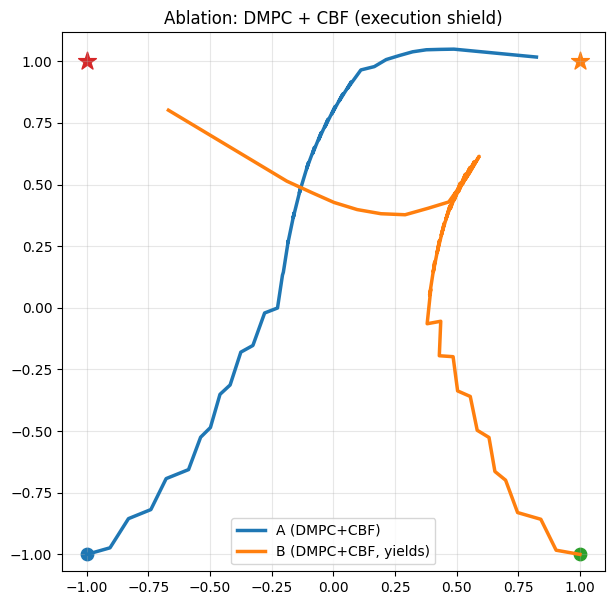

In [23]:
# ===============================================================
# ABLATION CELL 2: DMPC + CBF (execution safety shield)
# - Same DMPC planner (same candidates + same cost)
# - BUT before applying x_{t+1} = x_t + dt*v0, we project v0 with your CBF
#   treating the other agent center as a circular obstacle.
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

if "cbf_project_velocity_world" not in globals():
    raise RuntimeError("cbf_project_velocity_world not found. Run your CBF cell first.")

def cbf_step_other_center(
    x_now, v_nom, other_now,
    *,
    agent_safe_radius=0.60,
    gamma_min=6.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    extra_margin=0.0,
):
    x_now = np.asarray(x_now, dtype=np.float64).reshape(2)
    v_nom = np.asarray(v_nom, dtype=np.float64).reshape(2)
    other_now = np.asarray(other_now, dtype=np.float64).reshape(2)

    ellipses = [{"center": other_now.copy(), "radius": float(agent_safe_radius)}]
    x_traj = torch.tensor(x_now, dtype=torch.float32).view(1, 2, 1)
    v_traj = torch.tensor(v_nom, dtype=torch.float32).view(1, 2, 1)

    v_safe = cbf_project_velocity_world(
        x_traj,
        v_traj,
        ellipses=ellipses,
        extra_margin=float(extra_margin),
        max_corr_norm=float(max_corr_norm),
        passes=3,
        other_agent_traj=None,
        agent_safe_radius=float(agent_safe_radius),
        gamma_min=float(gamma_min),
        w_p=float(w_p),
        press_k=float(press_k),
        press_n=float(press_n),
    )
    return v_safe[0, :, 0].detach().cpu().numpy().astype(np.float64)


# --- reuse pure DMPC planner from previous cell ---
# (two_car_pure_dmpc and dmcp_pick_best_action already defined above)
# If not, run Ablation Cell 1 first.

def two_car_dmpc_with_cbf(
    xA0, gA, xB0, gB,
    *,
    dt=0.1,
    H=15,
    vA_max=1.4,
    vB_max=1.4,
    max_steps=600,
    goal_tol=0.20,
    speed_scales_A=(0.4, 0.7, 1.0),
    speed_scales_B=(0.0, 0.4, 0.7, 1.0),
    heading_span_deg=140.0,
    heading_samples=25,
    d_safe=1.05,
    w_goal_A=35.0, w_goal_B=35.0,
    w_dist_A=80.0, w_dist_B=120.0,
    w_turn_A=1.5,  w_turn_B=1.5,
    w_speed_A=0.2, w_speed_B=0.4,
    n_best_response_iters=1,
    # CBF params
    agent_safe_radius=0.60,
    gamma_min=6.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
):
    xA = np.asarray(xA0, dtype=np.float64).reshape(2).copy()
    xB = np.asarray(xB0, dtype=np.float64).reshape(2).copy()
    gA = np.asarray(gA, dtype=np.float64).reshape(2)
    gB = np.asarray(gB, dtype=np.float64).reshape(2)

    xsA, xsB = [xA.copy()], [xB.copy()]
    prev_vA, prev_vB = None, None

    predA = straight_pred(xA, gA, dt, vA_max, speed_scales_A[-1], H)
    predB = straight_pred(xB, gB, dt, vB_max, speed_scales_B[-1], H)

    for step in range(int(max_steps)):
        doneA = float(np.linalg.norm(xA - gA)) < float(goal_tol)
        doneB = float(np.linalg.norm(xB - gB)) < float(goal_tol)
        if doneA and doneB:
            break

        predA_shift = np.vstack([predA[1:], predA[-1]])
        predB_shift = np.vstack([predB[1:], predB[-1]])

        vA0 = np.zeros(2, dtype=np.float64)
        vB0 = np.zeros(2, dtype=np.float64)

        for _ in range(int(max(1, n_best_response_iters))):
            if not doneA:
                vA0, predA = dmcp_pick_best_action(
                    xA, gA, predB_shift,
                    dt=dt, H=H, v_max=vA_max,
                    speed_scales=speed_scales_A,
                    heading_span_deg=heading_span_deg,
                    heading_samples=heading_samples,
                    d_safe=d_safe,
                    w_goal=w_goal_A, w_dist=w_dist_A, w_turn=w_turn_A, w_speed=w_speed_A,
                    prev_v=prev_vA,
                )

            if not doneB:
                vB0, predB = dmcp_pick_best_action(
                    xB, gB, predA_shift,
                    dt=dt, H=H, v_max=vB_max,
                    speed_scales=speed_scales_B,
                    heading_span_deg=heading_span_deg,
                    heading_samples=heading_samples,
                    d_safe=d_safe,
                    w_goal=w_goal_B, w_dist=w_dist_B, w_turn=w_turn_B, w_speed=w_speed_B,
                    prev_v=prev_vB,
                )

        if doneA: vA0[:] = 0.0
        if doneB: vB0[:] = 0.0

        # ---- CBF shield on execution velocities ----
        vA_exec = cbf_step_other_center(
            xA, vA0, xB,
            agent_safe_radius=agent_safe_radius,
            gamma_min=gamma_min, w_p=w_p,
            press_k=press_k, press_n=press_n,
            max_corr_norm=max_corr_norm,
        )
        vB_exec = cbf_step_other_center(
            xB, vB0, xA,
            agent_safe_radius=agent_safe_radius,
            gamma_min=gamma_min, w_p=w_p,
            press_k=press_k, press_n=press_n,
            max_corr_norm=max_corr_norm,
        )

        xA = xA + float(dt) * vA_exec
        xB = xB + float(dt) * vB_exec
        xsA.append(xA.copy()); xsB.append(xB.copy())
        prev_vA, prev_vB = vA0.copy(), vB0.copy()

    return np.asarray(xsA), np.asarray(xsB)


# -------------------------
# Run + Plot (same scenario)
# -------------------------
xA0 = np.array([-1.0, -1.0], dtype=np.float64)
gA  = np.array([+1.0, +1.0], dtype=np.float64)
xB0 = np.array([+1.0, -1.0], dtype=np.float64)
gB  = np.array([-1.0, +1.0], dtype=np.float64)

xsA_cbf, xsB_cbf = two_car_dmpc_with_cbf(
    xA0, gA, xB0, gB,
    dt=0.1,
    H=15,
    vA_max=1.4, vB_max=1.4,
    goal_tol=0.20,
    n_best_response_iters=1,
    agent_safe_radius=0.60,
)

plt.figure(figsize=(7,7))
plt.plot(xsA_cbf[:,0], xsA_cbf[:,1], lw=2.5, label="A (DMPC+CBF)")
plt.plot(xsB_cbf[:,0], xsB_cbf[:,1], lw=2.5, label="B (DMPC+CBF, yields)")
plt.scatter([xA0[0]],[xA0[1]], s=80)
plt.scatter([gA[0]],[gA[1]], marker="*", s=180)
plt.scatter([xB0[0]],[xB0[1]], s=80)
plt.scatter([gB[0]],[gB[1]], marker="*", s=180)
plt.axis("equal"); plt.grid(alpha=0.3)
plt.legend()
plt.title("Ablation: DMPC + CBF (execution shield)")
plt.show()


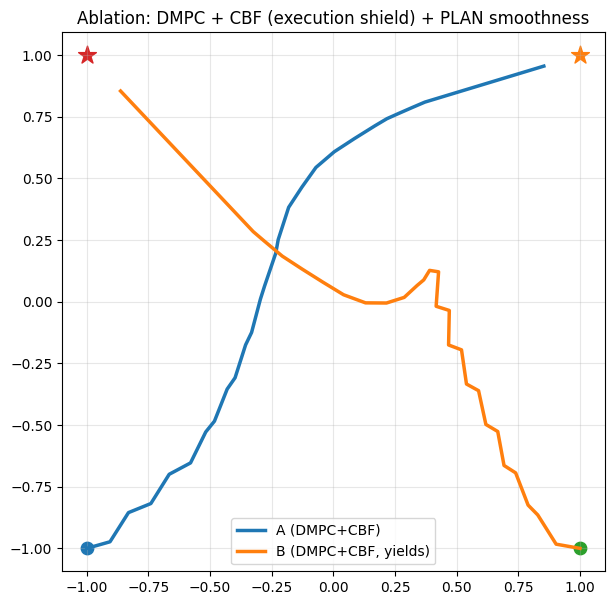

In [24]:
# ===============================================================
# ABLATION CELL 2 (FIXED): DMPC + CBF (execution shield)
# + PLAN-LEVEL SMOOTHNESS (no post-CBF EMA/turn-limit)
#
# Key idea:
#   - Add strong smoothness in the DMPC pick-best step:
#       (1) angle change penalty between v0 and prev_v
#       (2) dv penalty between v0 and prev_v
#   - Execution: ONLY CBF projection (no extra filtering after CBF)
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

if "cbf_project_velocity_world" not in globals():
    raise RuntimeError("cbf_project_velocity_world not found. Run your CBF cell first.")

# ---------- utils ----------
def wrap_pi(a: float) -> float:
    return float((a + np.pi) % (2*np.pi) - np.pi)

def straight_pred(x, g, dt, v_max, s, H):
    x = np.asarray(x, dtype=np.float64).reshape(2).copy()
    g = np.asarray(g, dtype=np.float64).reshape(2).copy()
    d = g - x
    d = d / (np.linalg.norm(d) + 1e-9)
    traj = [x.copy()]
    for _ in range(int(H)):
        x = x + float(dt) * float(v_max) * float(s) * d
        traj.append(x.copy())
    return np.asarray(traj, dtype=np.float64)

def cbf_step_other_center(
    x_now, v_nom, other_now,
    *,
    agent_safe_radius=0.60,
    gamma_min=6.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    extra_margin=0.0,
):
    x_now = np.asarray(x_now, dtype=np.float64).reshape(2)
    v_nom = np.asarray(v_nom, dtype=np.float64).reshape(2)
    other_now = np.asarray(other_now, dtype=np.float64).reshape(2)

    ellipses = [{"center": other_now.copy(), "radius": float(agent_safe_radius)}]
    x_traj = torch.tensor(x_now, dtype=torch.float32).view(1, 2, 1)
    v_traj = torch.tensor(v_nom, dtype=torch.float32).view(1, 2, 1)

    v_safe = cbf_project_velocity_world(
        x_traj,
        v_traj,
        ellipses=ellipses,
        extra_margin=float(extra_margin),
        max_corr_norm=float(max_corr_norm),
        passes=3,
        other_agent_traj=None,
        agent_safe_radius=float(agent_safe_radius),
        gamma_min=float(gamma_min),
        w_p=float(w_p),
        press_k=float(press_k),
        press_n=float(press_n),
    )
    return v_safe[0, :, 0].detach().cpu().numpy().astype(np.float64)

def _hinge(z): 
    return max(0.0, float(z))

def _angle_between(u, v):
    nu = float(np.linalg.norm(u) + 1e-12)
    nv = float(np.linalg.norm(v) + 1e-12)
    uu = u / nu
    vv = v / nv
    c = float(np.clip(np.dot(uu, vv), -1.0, 1.0))
    return float(np.arccos(c))  # [0,pi]

def rollout_pred(x0, v0, dt, H):
    x = np.asarray(x0, dtype=np.float64).reshape(2).copy()
    traj = [x.copy()]
    for _ in range(int(H)):
        x = x + float(dt) * v0
        traj.append(x.copy())
    return np.asarray(traj, dtype=np.float64)

# ---------- smooth DMPC pick-best (single-step action candidates) ----------
def dmcp_pick_best_action_smooth(
    xSelf, gSelf, other_pred,
    *,
    dt, H, v_max,
    speed_scales,
    heading_span_deg=140.0,
    heading_samples=25,
    d_safe=1.05,
    w_goal=35.0,
    w_dist=100.0,
    w_speed=0.3,
    # NEW smoothness
    prev_v=None,
    w_dv=6.0,          # dv penalty (stronger => less jitter)
    w_dtheta=12.0,     # angle change penalty (very effective)
):
    xSelf = np.asarray(xSelf, dtype=np.float64).reshape(2)
    gSelf = np.asarray(gSelf, dtype=np.float64).reshape(2)
    other_pred = np.asarray(other_pred, dtype=np.float64)

    base = float(np.arctan2((gSelf-xSelf)[1], (gSelf-xSelf)[0]))
    span = np.deg2rad(float(heading_span_deg))
    offs = np.linspace(-span/2.0, span/2.0, int(heading_samples))

    bestJ = 1e18
    bestv0 = np.zeros(2, dtype=np.float64)

    for off in offs:
        th = float(base + off)
        dir_vec = np.array([np.cos(th), np.sin(th)], dtype=np.float64)
        for s in speed_scales:
            v0 = float(v_max) * float(s) * dir_vec

            # rollout with constant v0
            x = xSelf.copy()
            J = 0.0
            for k in range(int(H)):
                x = x + float(dt) * v0

                d = float(np.linalg.norm(x - other_pred[k+1]))
                viol = _hinge(float(d_safe) - d)
                J += float(w_dist) * (viol*viol)

            # terminal goal cost
            J += float(w_goal) * float(np.sum((x - gSelf)**2))

            # speed choice penalty
            J += float(w_speed) * float((1.0 - float(s))**2)

            # smoothness vs prev_v
            if prev_v is not None:
                dv = v0 - prev_v
                J += float(w_dv) * float(dv @ dv)
                J += float(w_dtheta) * (_angle_between(v0, prev_v)**2)

            if J < bestJ:
                bestJ = J
                bestv0 = v0.copy()

    pred_self = rollout_pred(xSelf, bestv0, dt, H)  # for the other agent
    return bestv0, pred_self

# ---------- main loop ----------
def two_car_dmpc_with_cbf(
    xA0, gA, xB0, gB,
    *,
    dt=0.1,
    H=15,
    vA_max=1.4,
    vB_max=1.4,
    max_steps=600,
    goal_tol=0.20,
    speed_scales_A=(0.4, 0.7, 1.0),
    speed_scales_B=(0.0, 0.4, 0.7, 1.0),
    heading_span_deg=140.0,
    heading_samples=25,
    d_safe=1.05,
    w_goal_A=35.0, w_goal_B=35.0,
    w_dist_A=80.0, w_dist_B=120.0,
    w_speed_A=0.2, w_speed_B=0.4,
    n_best_response_iters=1,
    # NEW smoothness
    w_dv_A=6.0, w_dtheta_A=12.0,
    w_dv_B=6.0, w_dtheta_B=12.0,
    # CBF params
    agent_safe_radius=0.60,
    gamma_min=6.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
):
    xA = np.asarray(xA0, dtype=np.float64).reshape(2).copy()
    xB = np.asarray(xB0, dtype=np.float64).reshape(2).copy()
    gA = np.asarray(gA, dtype=np.float64).reshape(2)
    gB = np.asarray(gB, dtype=np.float64).reshape(2)

    xsA, xsB = [xA.copy()], [xB.copy()]
    prev_vA, prev_vB = None, None

    predA = straight_pred(xA, gA, dt, vA_max, speed_scales_A[-1], H)
    predB = straight_pred(xB, gB, dt, vB_max, speed_scales_B[-1], H)

    for step in range(int(max_steps)):
        doneA = float(np.linalg.norm(xA - gA)) < float(goal_tol)
        doneB = float(np.linalg.norm(xB - gB)) < float(goal_tol)
        if doneA and doneB:
            break

        predA_shift = np.vstack([predA[1:], predA[-1]])
        predB_shift = np.vstack([predB[1:], predB[-1]])

        vA0 = np.zeros(2, dtype=np.float64)
        vB0 = np.zeros(2, dtype=np.float64)

        for _ in range(int(max(1, n_best_response_iters))):
            if not doneA:
                vA0, predA = dmcp_pick_best_action_smooth(
                    xA, gA, predB_shift,
                    dt=dt, H=H, v_max=vA_max,
                    speed_scales=speed_scales_A,
                    heading_span_deg=heading_span_deg,
                    heading_samples=heading_samples,
                    d_safe=d_safe,
                    w_goal=w_goal_A, w_dist=w_dist_A, w_speed=w_speed_A,
                    prev_v=prev_vA,
                    w_dv=w_dv_A, w_dtheta=w_dtheta_A,
                )
            if not doneB:
                vB0, predB = dmcp_pick_best_action_smooth(
                    xB, gB, predA_shift,
                    dt=dt, H=H, v_max=vB_max,
                    speed_scales=speed_scales_B,
                    heading_span_deg=heading_span_deg,
                    heading_samples=heading_samples,
                    d_safe=d_safe,
                    w_goal=w_goal_B, w_dist=w_dist_B, w_speed=w_speed_B,
                    prev_v=prev_vB,
                    w_dv=w_dv_B, w_dtheta=w_dtheta_B,
                )

        if doneA: vA0[:] = 0.0
        if doneB: vB0[:] = 0.0

        # ---- execute ONLY through CBF (no post-filter) ----
        vA_exec = cbf_step_other_center(
            xA, vA0, xB,
            agent_safe_radius=agent_safe_radius,
            gamma_min=gamma_min, w_p=w_p,
            press_k=press_k, press_n=press_n,
            max_corr_norm=max_corr_norm,
        )
        vB_exec = cbf_step_other_center(
            xB, vB0, xA,
            agent_safe_radius=agent_safe_radius,
            gamma_min=gamma_min, w_p=w_p,
            press_k=press_k, press_n=press_n,
            max_corr_norm=max_corr_norm,
        )

        xA = xA + float(dt) * vA_exec
        xB = xB + float(dt) * vB_exec
        xsA.append(xA.copy()); xsB.append(xB.copy())

        prev_vA, prev_vB = vA0.copy(), vB0.copy()

    return np.asarray(xsA), np.asarray(xsB)

# -------------------------
# Run + Plot (same scenario)
# -------------------------
xA0 = np.array([-1.0, -1.0], dtype=np.float64)
gA  = np.array([+1.0, +1.0], dtype=np.float64)
xB0 = np.array([+1.0, -1.0], dtype=np.float64)
gB  = np.array([-1.0, +1.0], dtype=np.float64)

xsA_cbf, xsB_cbf = two_car_dmpc_with_cbf(
    xA0, gA, xB0, gB,
    dt=0.1,
    H=15,
    vA_max=1.4, vB_max=1.4,
    goal_tol=0.20,
    n_best_response_iters=1,
    agent_safe_radius=0.60,
    # ⭐如果还尖，继续加大：
    # w_dtheta_A=20, w_dtheta_B=20,
    # w_dv_A=10, w_dv_B=10,
)

plt.figure(figsize=(7,7))
plt.plot(xsA_cbf[:,0], xsA_cbf[:,1], lw=2.5, label="A (DMPC+CBF)")
plt.plot(xsB_cbf[:,0], xsB_cbf[:,1], lw=2.5, label="B (DMPC+CBF, yields)")
plt.scatter([xA0[0]],[xA0[1]], s=80)
plt.scatter([gA[0]],[gA[1]], marker="*", s=180)
plt.scatter([xB0[0]],[xB0[1]], s=80)
plt.scatter([gB[0]],[gB[1]], marker="*", s=180)
plt.axis("equal"); plt.grid(alpha=0.3)
plt.legend()
plt.title("Ablation: DMPC + CBF (execution shield) + PLAN smoothness")
plt.show()


In [25]:
# ===============================================================
# CELL: "Easy-to-run" Ablation Eval (Group1 uses NEW GPU-friendly warmstart)
# Compare:
#   - collision_rate
#   - min_dist_avg / min_dist_global
#   - avg_tracking_error (to straight line)
#   - avg_time_sec
# Also logs fail_rate (if a controller errors)
#
# Assumption:
#   - two_car_warmstart_dmpc is your NEW gpu-friendly lightweight version
#     (with replan_every, ode_steps)
#   - Group2/3 funcs unchanged: two_car_pure_dmpc, two_car_dmpc_with_cbf
# ===============================================================

import numpy as np
import time
import inspect

# -----------------------------
# 0) Preconditions
# -----------------------------
need = ["two_car_warmstart_dmpc", "two_car_pure_dmpc", "two_car_dmpc_with_cbf"]
for n in need:
    if n not in globals():
        raise RuntimeError(f"{n} not found. Please run the cell that defines it first.")

# -----------------------------
# 1) Safe call: only pass args that the function accepts
# -----------------------------
def _call_with_accepted_kwargs(func, *args, **kwargs):
    sig = inspect.signature(func)
    accepted = {k: v for k, v in kwargs.items() if k in sig.parameters}
    return func(*args, **accepted)

# -----------------------------
# 2) Metrics helpers
# -----------------------------
def _min_dist_series(xsA, xsB):
    xsA = np.asarray(xsA, float)
    xsB = np.asarray(xsB, float)
    d = np.linalg.norm(xsA - xsB, axis=1)
    return float(d.min()), float(d.mean())

def _point_to_segment_dist(p, a, b):
    p = np.asarray(p, float); a = np.asarray(a, float); b = np.asarray(b, float)
    ab = b - a
    t = float(np.dot(p - a, ab) / (np.dot(ab, ab) + 1e-12))
    t = max(0.0, min(1.0, t))
    proj = a + t * ab
    return float(np.linalg.norm(p - proj))

def _tracking_error_to_line(xs, start, goal):
    start = np.asarray(start, float); goal = np.asarray(goal, float)
    errs = [_point_to_segment_dist(p, start, goal) for p in np.asarray(xs, float)]
    return float(np.mean(errs))

def _episode_metrics(xsA, xsB, xA0, gA, xB0, gB, *, collision_dist):
    xsA = np.asarray(xsA, float)
    xsB = np.asarray(xsB, float)
    min_d, mean_d = _min_dist_series(xsA, xsB)
    collided = (min_d < float(collision_dist))

    errA = _tracking_error_to_line(xsA, xA0, gA)
    errB = _tracking_error_to_line(xsB, xB0, gB)
    avg_track_err = 0.5 * (errA + errB)

    return dict(
        collided=bool(collided),
        min_dist=min_d,
        mean_dist=mean_d,
        avg_track_err=avg_track_err,
        steps=int(len(xsA) - 1),
    )

# -----------------------------
# 3) Scenario generator
# -----------------------------
def make_crossing_scenarios(M=10, seed=0):
    rng = np.random.default_rng(seed)
    base = {
        "xA0": np.array([-1.0, -1.0]),
        "gA":  np.array([+1.0, +1.0]),
        "xB0": np.array([+1.0, -1.0]),
        "gB":  np.array([-1.0, +1.0]),
    }
    scenarios = []
    for _ in range(M):
        ang = rng.uniform(-np.pi, np.pi)
        s = rng.uniform(0.9, 1.25)
        R = np.array([[np.cos(ang), -np.sin(ang)],
                      [np.sin(ang),  np.cos(ang)]], float)
        sc = {}
        for k, v in base.items():
            sc[k] = (s * (R @ v.reshape(2, 1)).reshape(2)).astype(float)
        scenarios.append(sc)
    return scenarios

# -----------------------------
# 4) Runners
#   - Group1: NEW gpu-friendly warmstart DMPC (replan + ode_steps)
#   - Group2/3: unchanged (defaults)
# -----------------------------
def run_group1(sc, cfg):
    # IMPORTANT: this calls your NEW "gpu-friendly lightweight" two_car_warmstart_dmpc
    return _call_with_accepted_kwargs(
        two_car_warmstart_dmpc,
        sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
        dt=cfg["dt"], H=cfg["H"],
        vA_max=cfg["vA_max"], vB_max=cfg["vB_max"],
        speed_A=cfg["speed_A"], speed_B=cfg["speed_B"],
        r_stop=cfg["r_stop"], goal_tol=cfg["goal_tol"],
        max_steps=cfg["max_steps"],
        ema_beta=cfg["ema_beta"],
        replan_every=cfg["replan_every"],
        ode_steps=cfg["ode_steps"],
        # If your new implementation supports these, it will take them;
        # otherwise they are auto-filtered by _call_with_accepted_kwargs.
        # (leave here so you can extend later without touching this cell)
    )

def run_group2(sc, cfg):
    # Pure DMPC (DO NOT pass weights now)
    return _call_with_accepted_kwargs(
        two_car_pure_dmpc,
        sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
        dt=cfg["dt"], H=cfg["H"],
        vA_max=cfg["vA_max"], vB_max=cfg["vB_max"],
        max_steps=cfg["max_steps"], goal_tol=cfg["goal_tol"],
    )

def run_group3(sc, cfg):
    # DMPC + exec CBF shield (DO NOT pass weights now)
    return _call_with_accepted_kwargs(
        two_car_dmpc_with_cbf,
        sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
        dt=cfg["dt"], H=cfg["H"],
        vA_max=cfg["vA_max"], vB_max=cfg["vB_max"],
        max_steps=cfg["max_steps"], goal_tol=cfg["goal_tol"],
        # If it accepts CBF params, it'll use them; otherwise filtered out.
        agent_safe_radius=cfg["agent_safe_radius"],
        gamma_min=cfg["gamma_min"],
        w_p=cfg["w_p"],
        press_k=cfg["press_k"],
        press_n=cfg["press_n"],
        max_corr_norm=cfg["max_corr_norm"],
    )

controllers = {
    "Group1: NEW Warmstart FM (GPU-friendly, replan)": run_group1,
    "Group2: Pure-DMPC (defaults)": run_group2,
    "Group3: DMPC+CBF exec (defaults)": run_group3,
}

# -----------------------------
# 5) Config: reportable
# -----------------------------
cfg = dict(
    dt=0.1,
    H=10,
    max_steps=250,
    goal_tol=0.20,
    vA_max=1.4,
    vB_max=1.4,

    # Group1 specific (tune here)
    speed_A=1.0,
    speed_B=0.4,
    r_stop=1.0,
    ema_beta=0.90,
    replan_every=5,
    ode_steps=10,   # try 6~12 on GPU, 8~15 on CPU

    # CBF gains (Group3; also used for collision metric threshold)
    agent_safe_radius=0.60,
    gamma_min=6.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
)

collision_dist = cfg["agent_safe_radius"]

# -----------------------------
# 6) Run eval with progress + fail tolerance
# -----------------------------
scenarios = make_crossing_scenarios(M=10, seed=0)

print("=== Eval Config (easy version) ===")
print(f"M={len(scenarios)}, dt={cfg['dt']}, H={cfg['H']}, max_steps={cfg['max_steps']}")
print(f"Group1 (NEW) replan_every={cfg['replan_every']}, ode_steps={cfg['ode_steps']}")
print("Weights are NOT passed for Group2/3 (use their internal defaults).")
print("")

results = {}
for name, runner in controllers.items():
    ep_stats, t_list = [], []
    fail = 0

    print(f"Running [{name}]")
    for i, sc in enumerate(scenarios):
        t0 = time.perf_counter()
        try:
            xsA, xsB = runner(sc, cfg)
            t_list.append(time.perf_counter() - t0)
            ep_stats.append(_episode_metrics(
                xsA, xsB,
                sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
                collision_dist=collision_dist
            ))
        except Exception as e:
            fail += 1
            t_list.append(time.perf_counter() - t0)

        if (i + 1) % 2 == 0:
            print(f"  {i+1}/{len(scenarios)} done | avg_time={np.mean(t_list):.2f}s | fails={fail}")

    ok = len(ep_stats)
    if ok == 0:
        results[name] = dict(
            fail_rate=1.0,
            note="All episodes failed (check controller)."
        )
        continue

    collision_rate  = float(np.mean([s["collided"] for s in ep_stats]))
    min_dist_avg    = float(np.mean([s["min_dist"] for s in ep_stats]))
    min_dist_global = float(np.min([s["min_dist"] for s in ep_stats]))
    track_err_avg   = float(np.mean([s["avg_track_err"] for s in ep_stats]))
    time_avg        = float(np.mean(t_list))

    results[name] = dict(
        fail_rate=float(fail / len(scenarios)),
        collision_rate=collision_rate,
        min_dist_avg=min_dist_avg,
        min_dist_global=min_dist_global,
        avg_tracking_error=track_err_avg,
        avg_time_sec=time_avg,
        steps_avg=float(np.mean([s["steps"] for s in ep_stats])),
        episodes_ok=ok,
    )

print("\n=== EASY ABLATION RESULTS ===")
for k, v in results.items():
    print(f"\n[{k}]")
    for kk, vv in v.items():
        if isinstance(vv, float):
            print(f"  {kk:>18s}: {vv:.4f}")
        else:
            print(f"  {kk:>18s}: {vv}")


=== Eval Config (easy version) ===
M=10, dt=0.1, H=10, max_steps=250
Group1 (NEW) replan_every=5, ode_steps=10
Weights are NOT passed for Group2/3 (use their internal defaults).

Running [Group1: NEW Warmstart FM (GPU-friendly, replan)]
  2/10 done | avg_time=13.55s | fails=0
  4/10 done | avg_time=14.31s | fails=0
  6/10 done | avg_time=15.49s | fails=0
  8/10 done | avg_time=15.85s | fails=0
  10/10 done | avg_time=16.23s | fails=0
Running [Group2: Pure-DMPC (defaults)]
  2/10 done | avg_time=1.01s | fails=0
  4/10 done | avg_time=1.04s | fails=0
  6/10 done | avg_time=1.04s | fails=0
  8/10 done | avg_time=1.05s | fails=0
  10/10 done | avg_time=1.03s | fails=0
Running [Group3: DMPC+CBF exec (defaults)]
  2/10 done | avg_time=0.31s | fails=0
  4/10 done | avg_time=0.32s | fails=0
  6/10 done | avg_time=0.31s | fails=0
  8/10 done | avg_time=0.31s | fails=0
  10/10 done | avg_time=0.30s | fails=0

=== EASY ABLATION RESULTS ===

[Group1: NEW Warmstart FM (GPU-friendly, replan)]
      

In [13]:
# -----------------------------
# 2) Metrics helpers  (+ Smoothness: CS, AS)
# -----------------------------
def _min_dist_series(xsA, xsB):
    xsA = np.asarray(xsA, float)
    xsB = np.asarray(xsB, float)
    d = np.linalg.norm(xsA - xsB, axis=1)
    return float(d.min()), float(d.mean())

def _point_to_segment_dist(p, a, b):
    p = np.asarray(p, float); a = np.asarray(a, float); b = np.asarray(b, float)
    ab = b - a
    t = float(np.dot(p - a, ab) / (np.dot(ab, ab) + 1e-12))
    t = max(0.0, min(1.0, t))
    proj = a + t * ab
    return float(np.linalg.norm(p - proj))

def _tracking_error_to_line(xs, start, goal):
    start = np.asarray(start, float); goal = np.asarray(goal, float)
    errs = [_point_to_segment_dist(p, start, goal) for p in np.asarray(xs, float)]
    return float(np.mean(errs))

def _curvature_smoothness(xs):
    """
    CS = mean_k (1 - cos(theta_k)), theta between consecutive segments.
    Lower is smoother.
    """
    s = np.asarray(xs, float)
    if len(s) < 3:
        return 0.0
    w = s[1:] - s[:-1]              # (T-1,2)
    w1 = w[:-1]                     # (T-2,2)
    w2 = w[1:]                      # (T-2,2)
    n1 = np.linalg.norm(w1, axis=1) + 1e-12
    n2 = np.linalg.norm(w2, axis=1) + 1e-12
    cos = np.sum(w1 * w2, axis=1) / (n1 * n2)
    cos = np.clip(cos, -1.0, 1.0)
    Sc = float(np.mean(1.0 - cos))
    return Sc

def _accel_smoothness(xs):
    """
    AS = mean ||a_k||, a_k = s_{k+1} - 2 s_k + s_{k-1}
    Lower is smoother.
    """
    s = np.asarray(xs, float)
    if len(s) < 4:
        return 0.0
    a = s[2:] - 2.0 * s[1:-1] + s[:-2]   # (T-2,2)
    Sa = float(np.mean(np.linalg.norm(a, axis=1)))
    return Sa

def _episode_metrics(xsA, xsB, xA0, gA, xB0, gB, *, collision_dist):
    xsA = np.asarray(xsA, float)
    xsB = np.asarray(xsB, float)

    # safety distance
    min_d, mean_d = _min_dist_series(xsA, xsB)
    collided = (min_d < float(collision_dist))

    # tracking error to straight line
    errA = _tracking_error_to_line(xsA, xA0, gA)
    errB = _tracking_error_to_line(xsB, xB0, gB)
    avg_track_err = 0.5 * (errA + errB)

    # smoothness
    csA = _curvature_smoothness(xsA)
    csB = _curvature_smoothness(xsB)
    cs_avg = 0.5 * (csA + csB)

    asA = _accel_smoothness(xsA)
    asB = _accel_smoothness(xsB)
    as_avg = 0.5 * (asA + asB)

    return dict(
        collided=bool(collided),
        min_dist=min_d,
        mean_dist=mean_d,
        avg_track_err=avg_track_err,
        cs=cs_avg,
        a_smooth=as_avg,
        steps=int(len(xsA) - 1),
    )


In [14]:
# ===============================================================
# CELL: EASY ABLATION (Group1 = NEW GPU-friendly warmstart)
# + Smoothness metrics:
#   - cs_avg (curvature-based, lower is smoother)
#   - as_avg (acceleration-based, lower is smoother)
# ===============================================================

import numpy as np
import time
import inspect

# -----------------------------
# 0) Preconditions
# -----------------------------
need = ["two_car_warmstart_dmpc", "two_car_pure_dmpc", "two_car_dmpc_with_cbf"]
for n in need:
    if n not in globals():
        raise RuntimeError(f"{n} not found. Please run the cell that defines it first.")

# -----------------------------
# 1) Safe call: only pass args accepted by the function
# -----------------------------
def _call_with_accepted_kwargs(func, *args, **kwargs):
    sig = inspect.signature(func)
    accepted = {k: v for k, v in kwargs.items() if k in sig.parameters}
    return func(*args, **accepted)

# -----------------------------
# 2) Metrics helpers (+ CS/AS)
# -----------------------------
def _min_dist_series(xsA, xsB):
    xsA = np.asarray(xsA, float)
    xsB = np.asarray(xsB, float)
    d = np.linalg.norm(xsA - xsB, axis=1)
    return float(d.min()), float(d.mean())

def _point_to_segment_dist(p, a, b):
    p = np.asarray(p, float); a = np.asarray(a, float); b = np.asarray(b, float)
    ab = b - a
    t = float(np.dot(p - a, ab) / (np.dot(ab, ab) + 1e-12))
    t = max(0.0, min(1.0, t))
    proj = a + t * ab
    return float(np.linalg.norm(p - proj))

def _tracking_error_to_line(xs, start, goal):
    start = np.asarray(start, float); goal = np.asarray(goal, float)
    errs = [_point_to_segment_dist(p, start, goal) for p in np.asarray(xs, float)]
    return float(np.mean(errs))

def _curvature_smoothness(xs):
    """
    CS = mean_k (1 - cos(theta_k)) between consecutive segments.
    Lower => smoother (less directional change).
    """
    s = np.asarray(xs, float)
    if len(s) < 3:
        return 0.0
    w = s[1:] - s[:-1]          # (T-1,2)
    w1 = w[:-1]                 # (T-2,2)
    w2 = w[1:]                  # (T-2,2)
    n1 = np.linalg.norm(w1, axis=1) + 1e-12
    n2 = np.linalg.norm(w2, axis=1) + 1e-12
    cos = np.sum(w1 * w2, axis=1) / (n1 * n2)
    cos = np.clip(cos, -1.0, 1.0)
    return float(np.mean(1.0 - cos))

def _accel_smoothness(xs):
    """
    AS = mean ||a_k||, a_k = s_{k+1} - 2 s_k + s_{k-1}
    Lower => smoother (less jerk / less abrupt accel changes).
    """
    s = np.asarray(xs, float)
    if len(s) < 4:
        return 0.0
    a = s[2:] - 2.0 * s[1:-1] + s[:-2]   # (T-2,2)
    return float(np.mean(np.linalg.norm(a, axis=1)))

def _episode_metrics(xsA, xsB, xA0, gA, xB0, gB, *, collision_dist):
    xsA = np.asarray(xsA, float)
    xsB = np.asarray(xsB, float)

    min_d, mean_d = _min_dist_series(xsA, xsB)
    collided = (min_d < float(collision_dist))

    errA = _tracking_error_to_line(xsA, xA0, gA)
    errB = _tracking_error_to_line(xsB, xB0, gB)
    avg_track_err = 0.5 * (errA + errB)

    cs = 0.5 * (_curvature_smoothness(xsA) + _curvature_smoothness(xsB))
    aS = 0.5 * (_accel_smoothness(xsA) + _accel_smoothness(xsB))

    return dict(
        collided=bool(collided),
        min_dist=min_d,
        mean_dist=mean_d,
        avg_track_err=avg_track_err,
        cs=cs,
        a_smooth=aS,
        steps=int(len(xsA) - 1),
    )

# -----------------------------
# 3) Scenario generator
# -----------------------------
def make_crossing_scenarios(M=10, seed=0):
    rng = np.random.default_rng(seed)
    base = {
        "xA0": np.array([-1.0, -1.0]),
        "gA":  np.array([+1.0, +1.0]),
        "xB0": np.array([+1.0, -1.0]),
        "gB":  np.array([-1.0, +1.0]),
    }
    scenarios = []
    for _ in range(M):
        ang = rng.uniform(-np.pi, np.pi)
        s = rng.uniform(0.9, 1.25)
        R = np.array([[np.cos(ang), -np.sin(ang)],
                      [np.sin(ang),  np.cos(ang)]], float)
        sc = {}
        for k, v in base.items():
            sc[k] = (s * (R @ v.reshape(2, 1)).reshape(2)).astype(float)
        scenarios.append(sc)
    return scenarios

# -----------------------------
# 4) Runners
# -----------------------------
def run_group1(sc, cfg):
    # Group1 = your NEW gpu-friendly warmstart
    return _call_with_accepted_kwargs(
        two_car_warmstart_dmpc,
        sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
        dt=cfg["dt"], H=cfg["H"],
        vA_max=cfg["vA_max"], vB_max=cfg["vB_max"],
        speed_A=cfg["speed_A"], speed_B=cfg["speed_B"],
        r_stop=cfg["r_stop"], goal_tol=cfg["goal_tol"],
        max_steps=cfg["max_steps"],
        ema_beta=cfg["ema_beta"],
        replan_every=cfg["replan_every"],
        ode_steps=cfg["ode_steps"],
    )

def run_group2(sc, cfg):
    return _call_with_accepted_kwargs(
        two_car_pure_dmpc,
        sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
        dt=cfg["dt"], H=cfg["H"],
        vA_max=cfg["vA_max"], vB_max=cfg["vB_max"],
        max_steps=cfg["max_steps"], goal_tol=cfg["goal_tol"],
    )

def run_group3(sc, cfg):
    return _call_with_accepted_kwargs(
        two_car_dmpc_with_cbf,
        sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
        dt=cfg["dt"], H=cfg["H"],
        vA_max=cfg["vA_max"], vB_max=cfg["vB_max"],
        max_steps=cfg["max_steps"], goal_tol=cfg["goal_tol"],
        agent_safe_radius=cfg["agent_safe_radius"],
        gamma_min=cfg["gamma_min"],
        w_p=cfg["w_p"],
        press_k=cfg["press_k"],
        press_n=cfg["press_n"],
        max_corr_norm=cfg["max_corr_norm"],
    )

controllers = {
    "Group1: NEW Warmstart FM (GPU-friendly, replan)": run_group1,
    "Group2: Pure-DMPC (defaults)": run_group2,
    "Group3: DMPC+CBF exec (defaults)": run_group3,
}

# -----------------------------
# 5) Config
# -----------------------------
cfg = dict(
    dt=0.1, H=10, max_steps=250, goal_tol=0.20,
    vA_max=1.4, vB_max=1.4,

    # Group1
    speed_A=1.0, speed_B=0.4,
    r_stop=1.0,
    ema_beta=0.90,
    replan_every=5,
    ode_steps=10,

    # Group3 / collision threshold
    agent_safe_radius=0.60,
    gamma_min=6.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
)
collision_dist = cfg["agent_safe_radius"]

# -----------------------------
# 6) Run eval
# -----------------------------
scenarios = make_crossing_scenarios(M=10, seed=0)

print("=== Eval Config ===")
print(f"M={len(scenarios)}, dt={cfg['dt']}, H={cfg['H']}, max_steps={cfg['max_steps']}")
print(f"Group1 replan_every={cfg['replan_every']}, ode_steps={cfg['ode_steps']}")
print("")

results = {}
for name, runner in controllers.items():
    ep_stats, t_list = [], []
    fail = 0

    print(f"Running [{name}]")
    for i, sc in enumerate(scenarios):
        t0 = time.perf_counter()
        try:
            xsA, xsB = runner(sc, cfg)
            t_list.append(time.perf_counter() - t0)
            ep_stats.append(_episode_metrics(
                xsA, xsB,
                sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
                collision_dist=collision_dist
            ))
        except Exception as e:
            fail += 1
            t_list.append(time.perf_counter() - t0)

        if (i + 1) % 2 == 0:
            print(f"  {i+1}/{len(scenarios)} done | avg_time={np.mean(t_list):.2f}s | fails={fail}")

    ok = len(ep_stats)
    if ok == 0:
        results[name] = dict(fail_rate=1.0, note="All episodes failed.")
        continue

    results[name] = dict(
        fail_rate=float(fail / len(scenarios)),
        collision_rate=float(np.mean([s["collided"] for s in ep_stats])),
        min_dist_avg=float(np.mean([s["min_dist"] for s in ep_stats])),
        min_dist_global=float(np.min([s["min_dist"] for s in ep_stats])),
        avg_tracking_error=float(np.mean([s["avg_track_err"] for s in ep_stats])),
        cs_avg=float(np.mean([s["cs"] for s in ep_stats])),
        as_avg=float(np.mean([s["a_smooth"] for s in ep_stats])),
        avg_time_sec=float(np.mean(t_list)),
        steps_avg=float(np.mean([s["steps"] for s in ep_stats])),
        episodes_ok=int(ok),
    )

print("\n=== RESULTS (with Smoothness) ===")
for k, v in results.items():
    print(f"\n[{k}]")
    for kk, vv in v.items():
        if isinstance(vv, float):
            print(f"  {kk:>20s}: {vv:.4f}")
        else:
            print(f"  {kk:>20s}: {vv}")


=== Eval Config ===
M=10, dt=0.1, H=10, max_steps=250
Group1 replan_every=5, ode_steps=10

Running [Group1: NEW Warmstart FM (GPU-friendly, replan)]
  2/10 done | avg_time=33.68s | fails=0
  4/10 done | avg_time=33.66s | fails=0
  6/10 done | avg_time=651.89s | fails=0
  8/10 done | avg_time=497.92s | fails=0
  10/10 done | avg_time=406.31s | fails=0
Running [Group2: Pure-DMPC (defaults)]
  2/10 done | avg_time=1.22s | fails=0
  4/10 done | avg_time=1.08s | fails=0
  6/10 done | avg_time=1.05s | fails=0
  8/10 done | avg_time=1.05s | fails=0
  10/10 done | avg_time=1.04s | fails=0
Running [Group3: DMPC+CBF exec (defaults)]
  2/10 done | avg_time=0.23s | fails=0
  4/10 done | avg_time=0.24s | fails=0
  6/10 done | avg_time=0.24s | fails=0
  8/10 done | avg_time=0.25s | fails=0
  10/10 done | avg_time=0.25s | fails=0

=== RESULTS (with Smoothness) ===

[Group1: NEW Warmstart FM (GPU-friendly, replan)]
             fail_rate: 0.0000
        collision_rate: 0.0000
          min_dist_avg: 1

In [13]:
# ===============================================================
# CELL: Method-4 Speedup for Group1 (FM-ODE replanning every k steps)
# Drop-in replacement:
#   - Replaces two_car_warmstart_dmpc with a cached-plan version
#   - Passes replan_every + ode_steps via cfg
# Also patches:
#   - run_group1_dmpc_fmode_cbf to forward these params
#   - print_config to log them for reporting
# ===============================================================

import numpy as np

# -----------------------------
# 0) Safety: ensure helpers exist
# -----------------------------
if "sample_fm_traj_with_cbf" not in globals():
    raise RuntimeError("sample_fm_traj_with_cbf not found. Run your FM-ODE-with-CBF cell first.")
if "ema" not in globals() or "goal_pull" not in globals():
    raise RuntimeError("ema / goal_pull not found. Run your smoothing utilities cell first.")

# -----------------------------
# 1) Drop-in replacement: warm-start DMPC with replanning cache
# -----------------------------
def two_car_warmstart_dmpc(
    xA0, gA, xB0, gB,
    *, dt=0.1, H=15,
    vA_max=1.4, vB_max=1.4,
    speed_A=1.0, speed_B=0.4,
    r_stop=1.0, goal_tol=0.2,
    max_steps=600,
    ema_beta=0.9,
    # ---- NEW: speedup knobs ----
    replan_every=5,           # every k steps, re-run FM-ODE; otherwise reuse cached v_seq
    ode_steps=10,             # CPU-friendly ODE steps
):
    xA = np.array(xA0, dtype=float)
    xB = np.array(xB0, dtype=float)
    gA = np.array(gA, dtype=float)
    gB = np.array(gB, dtype=float)

    xsA, xsB = [xA.copy()], [xB.copy()]
    prev_vA, prev_vB = None, None

    # cached plans: dict(v_seq: (H,2), idx: int)
    planA = None
    planB = None

    def straight_pred(x, g, v_max, s):
        d = g - x
        d = d / (np.linalg.norm(d) + 1e-9)
        traj = [x.copy()]
        for _ in range(H):
            x = x + dt * v_max * s * d
            traj.append(x.copy())
        return np.asarray(traj)

    # warm-start predictions
    predA = straight_pred(xA, gA, vA_max, speed_A)
    predB = straight_pred(xB, gB, vB_max, speed_B)

    def _need_replan(step, plan):
        if plan is None:
            return True
        if (step % int(replan_every)) == 0:
            return True
        if plan["idx"] >= (len(plan["v_seq"]) - 1):
            return True
        return False

    def _get_next_from_plan(plan):
        v0 = plan["v_seq"][plan["idx"]].copy()
        plan["idx"] += 1
        return v0, plan

    for step in range(max_steps):
        A_done = (np.linalg.norm(xA - gA) < goal_tol)
        B_done = (np.linalg.norm(xB - gB) < goal_tol)

        if A_done:
            predA = np.tile(gA, (H + 1, 1))
            planA = None
        if B_done:
            predB = np.tile(gB, (H + 1, 1))
            planB = None

        # shift opponent prediction for receding horizon coupling
        predA_shift = np.vstack([predA[1:], predA[-1]])
        predB_shift = np.vstack([predB[1:], predB[-1]])

        # -------------------------
        # Agent A: replan or reuse
        # -------------------------
        if not A_done:
            if _need_replan(step, planA):
                vA_seq, predA = sample_fm_traj_with_cbf(
                    xA, gA, predB_shift,
                    H=H, dt=dt,
                    v_max=vA_max, speed_scale=speed_A,
                    r_stop=r_stop,
                    ode_steps=ode_steps,   # NEW: forward
                )
                planA = {"v_seq": vA_seq, "idx": 0}
            vA0, planA = _get_next_from_plan(planA)
        else:
            vA0 = np.zeros(2)

        # -------------------------
        # Agent B: replan or reuse
        # -------------------------
        if not B_done:
            if _need_replan(step, planB):
                vB_seq, predB = sample_fm_traj_with_cbf(
                    xB, gB, predA_shift,
                    H=H, dt=dt,
                    v_max=vB_max, speed_scale=speed_B,
                    r_stop=r_stop,
                    ode_steps=ode_steps,   # NEW: forward
                )
                planB = {"v_seq": vB_seq, "idx": 0}
            vB0, planB = _get_next_from_plan(planB)
        else:
            vB0 = np.zeros(2)

        # ---- EMA + goal pull ----
        vA_exec = ema(vA0, prev_vA, ema_beta)
        vB_exec = ema(vB0, prev_vB, ema_beta)

        alpha_A = 0.15
        alpha_B = 0.20  # B yields: slightly stronger soft correction
        vA_exec = goal_pull(vA_exec, xA, gA, alpha=alpha_A)
        vB_exec = goal_pull(vB_exec, xB, gB, alpha=alpha_B)

        # integrate
        xA = xA + dt * vA_exec
        xB = xB + dt * vB_exec

        xsA.append(xA.copy())
        xsB.append(xB.copy())
        prev_vA, prev_vB = vA_exec.copy(), vB_exec.copy()

        if (np.linalg.norm(xA - gA) < goal_tol) and (np.linalg.norm(xB - gB) < goal_tol):
            break

    return np.asarray(xsA), np.asarray(xsB)

print("[OK] Patched two_car_warmstart_dmpc with replanning cache.")

# -----------------------------
# 2) Patch Group1 runner to pass replan_every + ode_steps via cfg
# -----------------------------
if "run_group1_dmpc_fmode_cbf" in globals():
    def run_group1_dmpc_fmode_cbf(sc, cfg):
        xsA, xsB = two_car_warmstart_dmpc(
            sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
            dt=cfg["dt"], H=cfg["H"],
            vA_max=cfg["vA_max"], vB_max=cfg["vB_max"],
            speed_A=cfg["speed_A"], speed_B=cfg["speed_B"],
            r_stop=cfg["r_stop"], goal_tol=cfg["goal_tol"],
            max_steps=cfg["max_steps"],
            ema_beta=cfg.get("ema_beta", 0.90),
            replan_every=cfg.get("replan_every", 5),
            ode_steps=cfg.get("ode_steps", 10),
        )
        return xsA, xsB

    print("[OK] Patched run_group1_dmpc_fmode_cbf to pass replan_every/ode_steps.")
else:
    print("[WARN] run_group1_dmpc_fmode_cbf not found yet. Define it after this cell, using cfg['replan_every'], cfg['ode_steps'].")

# -----------------------------
# 3) Patch print_config to log new params (optional)
# -----------------------------
if "print_config" in globals():
    _old_print_config = print_config

    def print_config(cfg):
        _old_print_config(cfg)
        print("=== FM replanning (record) ===")
        print(f"replan_every={cfg.get('replan_every','-')}, ode_steps={cfg.get('ode_steps','-')}")
        print("")

    print("[OK] Patched print_config to include replanning params.")
else:
    print("[WARN] print_config not found yet. If you want, add logging: replan_every and ode_steps.")



[OK] Patched two_car_warmstart_dmpc with replanning cache.
[OK] Patched run_group1_dmpc_fmode_cbf to pass replan_every/ode_steps.
[WARN] print_config not found yet. If you want, add logging: replan_every and ode_steps.


In [15]:
# ===============================================================
# CELL: Robust wrappers (auto-filter kwargs by function signature)
# Fixes: unexpected keyword argument issues (e.g. w_turn_A)
# ===============================================================

import inspect

def _call_with_accepted_kwargs(func, *args, **kwargs):
    sig = inspect.signature(func)
    accepted = {}
    for k, v in kwargs.items():
        if k in sig.parameters:
            accepted[k] = v
    return func(*args, **accepted)

def run_group2_pure_dmpc(sc, cfg):
    # Build a big kwargs dict, then filter to what the function accepts.
    kwargs = dict(
        dt=cfg["dt"], H=cfg["H"],
        vA_max=cfg["vA_max"], vB_max=cfg["vB_max"],
        max_steps=cfg["max_steps"], goal_tol=cfg["goal_tol"],
        speed_scales_A=cfg["speed_scales_A"],
        speed_scales_B=cfg["speed_scales_B"],
        heading_span_deg=cfg["heading_span_deg"],
        heading_samples=cfg["heading_samples"],
        d_safe=cfg["d_safe"],
        w_goal_A=cfg["w_goal_A"], w_goal_B=cfg["w_goal_B"],
        w_dist_A=cfg["w_dist_A"], w_dist_B=cfg["w_dist_B"],
        w_turn_A=cfg["w_turn_A"], w_turn_B=cfg["w_turn_B"],    # may not exist -> filtered
        w_speed_A=cfg["w_speed_A"], w_speed_B=cfg["w_speed_B"],
        n_best_response_iters=cfg["n_best_response_iters"],
    )
    return _call_with_accepted_kwargs(
        two_car_pure_dmpc,
        sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
        **kwargs
    )

def run_group3_dmpc_exec_cbf(sc, cfg):
    kwargs = dict(
        dt=cfg["dt"], H=cfg["H"],
        vA_max=cfg["vA_max"], vB_max=cfg["vB_max"],
        max_steps=cfg["max_steps"], goal_tol=cfg["goal_tol"],
        speed_scales_A=cfg["speed_scales_A"],
        speed_scales_B=cfg["speed_scales_B"],
        heading_span_deg=cfg["heading_span_deg"],
        heading_samples=cfg["heading_samples"],
        d_safe=cfg["d_safe"],
        w_goal_A=cfg["w_goal_A"], w_goal_B=cfg["w_goal_B"],
        w_dist_A=cfg["w_dist_A"], w_dist_B=cfg["w_dist_B"],
        w_turn_A=cfg["w_turn_A"], w_turn_B=cfg["w_turn_B"],    # may not exist -> filtered
        w_speed_A=cfg["w_speed_A"], w_speed_B=cfg["w_speed_B"],
        n_best_response_iters=cfg["n_best_response_iters"],

        # CBF gains (also may differ by your function)
        agent_safe_radius=cfg["agent_safe_radius"],
        gamma_min=cfg["gamma_min"],
        w_p=cfg["w_p"],
        press_k=cfg["press_k"],
        press_n=cfg["press_n"],
        max_corr_norm=cfg["max_corr_norm"],
    )
    return _call_with_accepted_kwargs(
        two_car_dmpc_with_cbf,
        sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
        **kwargs
    )

# Update controllers dict if it exists
if "controllers" in globals():
    controllers["Pure-DMPC"] = run_group2_pure_dmpc
    controllers["DMPC+CBF(exec)"] = run_group3_dmpc_exec_cbf

print("[OK] Patched Group2/Group3 wrappers with signature-based kwarg filtering.")


[OK] Patched Group2/Group3 wrappers with signature-based kwarg filtering.


In [ ]:
# # ===============================================================
# # CELL: Method-4 (Replan-every-k) + Eval-ready + Logging
# # Purpose:
# #   - Make Group1 (FM-ODE) runnable on CPU
# #   - Comparable ablation across 3 methods
# #   - Progress print + config logging for reporting
# # ===============================================================

# import numpy as np
# import time

# # ---------------------------------------------------------------
# # 0) REQUIRED: these must already exist
# # ---------------------------------------------------------------
# required = [
#     "sample_fm_traj_with_cbf",
#     "ema", "goal_pull",
#     "two_car_pure_dmpc",
#     "two_car_dmpc_with_cbf",
# ]
# for r in required:
#     if r not in globals():
#         raise RuntimeError(f"{r} not found. Run previous cells first.")

# # ---------------------------------------------------------------
# # 1) Method-4 controller: warm-start DMPC with replanning cache
# # ---------------------------------------------------------------
# def two_car_warmstart_dmpc(
#     xA0, gA, xB0, gB,
#     *, dt=0.1, H=15,
#     vA_max=1.4, vB_max=1.4,
#     speed_A=1.0, speed_B=0.4,
#     r_stop=1.0, goal_tol=0.2,
#     max_steps=600,
#     ema_beta=0.9,
#     replan_every=5,     # NEW
#     ode_steps=10,       # NEW (CPU-friendly)
# ):
#     xA = np.array(xA0, float)
#     xB = np.array(xB0, float)
#     gA = np.array(gA, float)
#     gB = np.array(gB, float)

#     xsA, xsB = [xA.copy()], [xB.copy()]
#     prev_vA, prev_vB = None, None

#     planA, planB = None, None

#     def straight_pred(x, g, v_max, s):
#         d = g - x
#         d = d / (np.linalg.norm(d) + 1e-9)
#         traj = [x.copy()]
#         for _ in range(H):
#             x = x + dt * v_max * s * d
#             traj.append(x.copy())
#         return np.asarray(traj)

#     predA = straight_pred(xA, gA, vA_max, speed_A)
#     predB = straight_pred(xB, gB, vB_max, speed_B)

#     def need_replan(step, plan):
#         if plan is None:
#             return True
#         if step % replan_every == 0:
#             return True
#         if plan["idx"] >= len(plan["v_seq"]) - 1:
#             return True
#         return False

#     def take_from_plan(plan):
#         v0 = plan["v_seq"][plan["idx"]].copy()
#         plan["idx"] += 1
#         return v0, plan

#     for step in range(max_steps):
#         A_done = np.linalg.norm(xA - gA) < goal_tol
#         B_done = np.linalg.norm(xB - gB) < goal_tol

#         if A_done:
#             planA = None
#             predA = np.tile(gA, (H+1, 1))
#         if B_done:
#             planB = None
#             predB = np.tile(gB, (H+1, 1))

#         predA_shift = np.vstack([predA[1:], predA[-1]])
#         predB_shift = np.vstack([predB[1:], predB[-1]])

#         # ---- Agent A ----
#         if not A_done:
#             if need_replan(step, planA):
#                 vA_seq, predA = sample_fm_traj_with_cbf(
#                     xA, gA, predB_shift,
#                     H=H, dt=dt,
#                     v_max=vA_max, speed_scale=speed_A,
#                     r_stop=r_stop,
#                     ode_steps=ode_steps,
#                 )
#                 planA = {"v_seq": vA_seq, "idx": 0}
#             vA0, planA = take_from_plan(planA)
#         else:
#             vA0 = np.zeros(2)

#         # ---- Agent B ----
#         if not B_done:
#             if need_replan(step, planB):
#                 vB_seq, predB = sample_fm_traj_with_cbf(
#                     xB, gB, predA_shift,
#                     H=H, dt=dt,
#                     v_max=vB_max, speed_scale=speed_B,
#                     r_stop=r_stop,
#                     ode_steps=ode_steps,
#                 )
#                 planB = {"v_seq": vB_seq, "idx": 0}
#             vB0, planB = take_from_plan(planB)
#         else:
#             vB0 = np.zeros(2)

#         # ---- smooth + soft goal pull ----
#         vA_exec = ema(vA0, prev_vA, ema_beta)
#         vB_exec = ema(vB0, prev_vB, ema_beta)
#         vA_exec = goal_pull(vA_exec, xA, gA, alpha=0.15)
#         vB_exec = goal_pull(vB_exec, xB, gB, alpha=0.20)

#         xA = xA + dt * vA_exec
#         xB = xB + dt * vB_exec

#         xsA.append(xA.copy())
#         xsB.append(xB.copy())
#         prev_vA, prev_vB = vA_exec.copy(), vB_exec.copy()

#         if np.linalg.norm(xA-gA) < goal_tol and np.linalg.norm(xB-gB) < goal_tol:
#             break

#     return np.asarray(xsA), np.asarray(xsB)

# # ---------------------------------------------------------------
# # 2) Group runners
# # ---------------------------------------------------------------
# def run_group1_dmpc_fmode_cbf(sc, cfg):
#     return two_car_warmstart_dmpc(
#         sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
#         dt=cfg["dt"], H=cfg["H"],
#         vA_max=cfg["vA_max"], vB_max=cfg["vB_max"],
#         speed_A=cfg["speed_A"], speed_B=cfg["speed_B"],
#         r_stop=cfg["r_stop"], goal_tol=cfg["goal_tol"],
#         max_steps=cfg["max_steps"],
#         ema_beta=cfg["ema_beta"],
#         replan_every=cfg["replan_every"],
#         ode_steps=cfg["ode_steps"],
#     )

# def run_group2_pure_dmpc(sc, cfg):
#     return two_car_pure_dmpc(
#         sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
#         dt=cfg["dt"], H=cfg["H"],
#         vA_max=cfg["vA_max"], vB_max=cfg["vB_max"],
#         max_steps=cfg["max_steps"], goal_tol=cfg["goal_tol"],
#         speed_scales_A=cfg["speed_scales_A"],
#         speed_scales_B=cfg["speed_scales_B"],
#         heading_span_deg=cfg["heading_span_deg"],
#         heading_samples=cfg["heading_samples"],
#         d_safe=cfg["d_safe"],
#         w_goal_A=cfg["w_goal_A"], w_goal_B=cfg["w_goal_B"],
#         w_dist_A=cfg["w_dist_A"], w_dist_B=cfg["w_dist_B"],
#         w_turn_A=cfg["w_turn_A"], w_turn_B=cfg["w_turn_B"],
#         w_speed_A=cfg["w_speed_A"], w_speed_B=cfg["w_speed_B"],
#         n_best_response_iters=cfg["n_best_response_iters"],
#     )

# def run_group3_dmpc_exec_cbf(sc, cfg):
#     return two_car_dmpc_with_cbf(
#         sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
#         dt=cfg["dt"], H=cfg["H"],
#         vA_max=cfg["vA_max"], vB_max=cfg["vB_max"],
#         max_steps=cfg["max_steps"], goal_tol=cfg["goal_tol"],
#         speed_scales_A=cfg["speed_scales_A"],
#         speed_scales_B=cfg["speed_scales_B"],
#         heading_span_deg=cfg["heading_span_deg"],
#         heading_samples=cfg["heading_samples"],
#         d_safe=cfg["d_safe"],
#         w_goal_A=cfg["w_goal_A"], w_goal_B=cfg["w_goal_B"],
#         w_dist_A=cfg["w_dist_A"], w_dist_B=cfg["w_dist_B"],
#         w_turn_A=cfg["w_turn_A"], w_turn_B=cfg["w_turn_B"],
#         w_speed_A=cfg["w_speed_A"], w_speed_B=cfg["w_speed_B"],
#         n_best_response_iters=cfg["n_best_response_iters"],
#         agent_safe_radius=cfg["agent_safe_radius"],
#         gamma_min=cfg["gamma_min"],
#         w_p=cfg["w_p"],
#         press_k=cfg["press_k"],
#         press_n=cfg["press_n"],
#         max_corr_norm=cfg["max_corr_norm"],
#     )

# controllers = {
#     "DMPC+FM-ODE (replan)": run_group1_dmpc_fmode_cbf,
#     "Pure-DMPC": run_group2_pure_dmpc,
#     "DMPC+CBF(exec)": run_group3_dmpc_exec_cbf,
# }

# # ---------------------------------------------------------------
# # 3) Config (CPU-friendly, reportable)
# # ---------------------------------------------------------------
# cfg = dict(
#     dt=0.1, H=10, max_steps=250, goal_tol=0.20,
#     vA_max=1.4, vB_max=1.4,
#     speed_A=1.0, speed_B=0.4,
#     r_stop=1.0,
#     ema_beta=0.9,
#     replan_every=5,
#     ode_steps=10,

#     speed_scales_A=(0.4, 0.7, 1.0),
#     speed_scales_B=(0.0, 0.4, 0.7, 1.0),
#     heading_span_deg=120.0,
#     heading_samples=15,

#     d_safe=1.05,
#     w_goal_A=35.0, w_goal_B=35.0,
#     w_dist_A=80.0, w_dist_B=120.0,
#     w_turn_A=1.5,  w_turn_B=1.5,
#     w_speed_A=0.2, w_speed_B=0.4,
#     n_best_response_iters=1,

#     agent_safe_radius=0.60,
#     gamma_min=6.0,
#     w_p=6.0,
#     press_k=1.0,
#     press_n=2.0,
#     max_corr_norm=10.0,
# )

# collision_dist = cfg["agent_safe_radius"]

# # ---------------------------------------------------------------
# # 4) Scenario generator
# # ---------------------------------------------------------------
# def make_crossing_scenarios(M=10, seed=0):
#     rng = np.random.default_rng(seed)
#     base = dict(
#         xA0=np.array([-1.0, -1.0]),
#         gA =np.array([ 1.0,  1.0]),
#         xB0=np.array([ 1.0, -1.0]),
#         gB =np.array([-1.0,  1.0]),
#     )
#     out = []
#     for _ in range(M):
#         ang = rng.uniform(-np.pi, np.pi)
#         s = rng.uniform(0.9, 1.25)
#         R = np.array([[np.cos(ang), -np.sin(ang)],
#                       [np.sin(ang),  np.cos(ang)]])
#         sc = {}
#         for k,v in base.items():
#             sc[k] = (s*(R@v.reshape(2,1)).reshape(2))
#         out.append(sc)
#     return out

# # ---------------------------------------------------------------
# # 5) Metrics
# # ---------------------------------------------------------------
# def episode_metrics(xsA, xsB, sc):
#     d = np.linalg.norm(xsA-xsB, axis=1)
#     collided = np.min(d) < collision_dist
#     return dict(
#         collided=collided,
#         min_dist=float(np.min(d)),
#         mean_dist=float(np.mean(d)),
#         steps=len(xsA)-1
#     )

# # ---------------------------------------------------------------
# # 6) Run evaluation (with progress print)
# # ---------------------------------------------------------------
# scenarios = make_crossing_scenarios(M=10, seed=0)

# print("=== Config ===")
# for k in ["replan_every","ode_steps","H","max_steps"]:
#     print(f"{k}: {cfg[k]}")
# print("")

# results = {}
# for name, runner in controllers.items():
#     stats, times = [], []
#     print(f"\nRunning [{name}]")
#     for i, sc in enumerate(scenarios):
#         t0 = time.perf_counter()
#         xsA, xsB = runner(sc, cfg)
#         times.append(time.perf_counter() - t0)
#         stats.append(episode_metrics(xsA, xsB, sc))

#         print(f"  {i+1}/{len(scenarios)} done, avg_time={np.mean(times):.2f}s")

#     results[name] = dict(
#         collision_rate=float(np.mean([s["collided"] for s in stats])),
#         min_dist_avg=float(np.mean([s["min_dist"] for s in stats])),
#         min_dist_global=float(np.min([s["min_dist"] for s in stats])),
#         avg_time_sec=float(np.mean(times)),
#     )

# print("\n=== RESULTS ===")
# for k,v in results.items():
#     print(f"\n[{k}]")
#     for kk,vv in v.items():
#         print(f"  {kk}: {vv:.4f}")


=== Config ===
replan_every: 5
ode_steps: 10
H: 10
max_steps: 250


Running [DMPC+FM-ODE (replan)]
  1/10 done, avg_time=6.98s
  2/10 done, avg_time=6.36s
  3/10 done, avg_time=6.36s
  4/10 done, avg_time=5.90s
  5/10 done, avg_time=6.11s
  6/10 done, avg_time=5.83s
  7/10 done, avg_time=5.82s
  8/10 done, avg_time=5.78s
  9/10 done, avg_time=5.89s
  10/10 done, avg_time=5.94s

Running [Pure-DMPC]
  1/10 done, avg_time=1.62s
  2/10 done, avg_time=1.61s
  3/10 done, avg_time=1.63s
  4/10 done, avg_time=1.65s
  5/10 done, avg_time=1.65s
  6/10 done, avg_time=1.64s
  7/10 done, avg_time=1.64s
  8/10 done, avg_time=1.63s
  9/10 done, avg_time=1.54s
  10/10 done, avg_time=1.48s

Running [DMPC+CBF(exec)]


TypeError: two_car_dmpc_with_cbf() got an unexpected keyword argument 'w_turn_A'

In [19]:
# ===============================================================
# CELL: "Easy-to-run" Ablation Eval (no weights, no turn params)
# Compare what we can reliably compute now:
#   - collision_rate
#   - min_dist_avg / min_dist_global
#   - avg_tracking_error (to straight line)
#   - avg_time_sec
# Also logs fail_rate (if a controller errors)
# ===============================================================

import numpy as np
import time
import inspect

# -----------------------------
# 0) Preconditions
# -----------------------------
need = ["two_car_warmstart_dmpc", "two_car_pure_dmpc", "two_car_dmpc_with_cbf"]
for n in need:
    if n not in globals():
        raise RuntimeError(f"{n} not found. Please run the cell that defines it first.")

# -----------------------------
# 1) Safe call: only pass args that the function accepts
# -----------------------------
def _call_with_accepted_kwargs(func, *args, **kwargs):
    sig = inspect.signature(func)
    accepted = {k: v for k, v in kwargs.items() if k in sig.parameters}
    return func(*args, **accepted)

# -----------------------------
# 2) Metrics helpers
# -----------------------------
def _min_dist_series(xsA, xsB):
    xsA = np.asarray(xsA, float)
    xsB = np.asarray(xsB, float)
    d = np.linalg.norm(xsA - xsB, axis=1)
    return float(d.min()), float(d.mean())

def _point_to_segment_dist(p, a, b):
    p = np.asarray(p, float); a = np.asarray(a, float); b = np.asarray(b, float)
    ab = b - a
    t = float(np.dot(p - a, ab) / (np.dot(ab, ab) + 1e-12))
    t = max(0.0, min(1.0, t))
    proj = a + t * ab
    return float(np.linalg.norm(p - proj))

def _tracking_error_to_line(xs, start, goal):
    start = np.asarray(start, float); goal = np.asarray(goal, float)
    errs = [_point_to_segment_dist(p, start, goal) for p in np.asarray(xs, float)]
    return float(np.mean(errs))

def _episode_metrics(xsA, xsB, xA0, gA, xB0, gB, *, collision_dist):
    xsA = np.asarray(xsA, float)
    xsB = np.asarray(xsB, float)
    min_d, mean_d = _min_dist_series(xsA, xsB)
    collided = (min_d < float(collision_dist))

    errA = _tracking_error_to_line(xsA, xA0, gA)
    errB = _tracking_error_to_line(xsB, xB0, gB)
    avg_track_err = 0.5 * (errA + errB)

    return dict(
        collided=bool(collided),
        min_dist=min_d,
        mean_dist=mean_d,
        avg_track_err=avg_track_err,
        steps=int(len(xsA) - 1),
    )

# -----------------------------
# 3) Scenario generator
# -----------------------------
def make_crossing_scenarios(M=10, seed=0):
    rng = np.random.default_rng(seed)
    base = {
        "xA0": np.array([-1.0, -1.0]),
        "gA":  np.array([+1.0, +1.0]),
        "xB0": np.array([+1.0, -1.0]),
        "gB":  np.array([-1.0, +1.0]),
    }
    scenarios = []
    for _ in range(M):
        ang = rng.uniform(-np.pi, np.pi)
        s = rng.uniform(0.9, 1.25)
        R = np.array([[np.cos(ang), -np.sin(ang)],
                      [np.sin(ang),  np.cos(ang)]], float)
        sc = {}
        for k, v in base.items():
            sc[k] = (s * (R @ v.reshape(2, 1)).reshape(2)).astype(float)
        scenarios.append(sc)
    return scenarios

# -----------------------------
# 4) Runners: only pass "easy" params
# -----------------------------
def run_group1(sc, cfg):
    # Your patched method-4 warmstart DMPC (supports replan_every/ode_steps)
    return _call_with_accepted_kwargs(
        two_car_warmstart_dmpc,
        sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
        dt=cfg["dt"], H=cfg["H"],
        vA_max=cfg["vA_max"], vB_max=cfg["vB_max"],
        speed_A=cfg["speed_A"], speed_B=cfg["speed_B"],
        r_stop=cfg["r_stop"], goal_tol=cfg["goal_tol"],
        max_steps=cfg["max_steps"],
        ema_beta=cfg["ema_beta"],
        replan_every=cfg["replan_every"],
        ode_steps=cfg["ode_steps"],
    )

def run_group2(sc, cfg):
    # Pure DMPC but we DO NOT pass any weights now
    return _call_with_accepted_kwargs(
        two_car_pure_dmpc,
        sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
        dt=cfg["dt"], H=cfg["H"],
        vA_max=cfg["vA_max"], vB_max=cfg["vB_max"],
        max_steps=cfg["max_steps"], goal_tol=cfg["goal_tol"],
    )

def run_group3(sc, cfg):
    # DMPC + CBF exec shield but we DO NOT pass any weights now
    return _call_with_accepted_kwargs(
        two_car_dmpc_with_cbf,
        sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
        dt=cfg["dt"], H=cfg["H"],
        vA_max=cfg["vA_max"], vB_max=cfg["vB_max"],
        max_steps=cfg["max_steps"], goal_tol=cfg["goal_tol"],
        # 如果它接受这些CBF参数就会用，不接受就自动过滤掉
        agent_safe_radius=cfg["agent_safe_radius"],
        gamma_min=cfg["gamma_min"],
        w_p=cfg["w_p"],
        press_k=cfg["press_k"],
        press_n=cfg["press_n"],
        max_corr_norm=cfg["max_corr_norm"],
    )

controllers = {
    "Group1: DMPC+FM-ODE (replan)": run_group1,
    "Group2: Pure-DMPC (defaults)": run_group2,
    "Group3: DMPC+CBF exec (defaults)": run_group3,
}

# -----------------------------
# 5) Config: CPU-friendly, reportable
# -----------------------------
cfg = dict(
    dt=0.1,
    H=10,
    max_steps=250,
    goal_tol=0.20,
    vA_max=1.4,
    vB_max=1.4,

    # Group1 specific (you can tune)
    speed_A=1.0,
    speed_B=0.4,
    r_stop=1.0,
    ema_beta=0.90,
    replan_every=5,
    ode_steps=10,

    # CBF gains (will be used only if function accepts)
    agent_safe_radius=0.60,
    gamma_min=6.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
)

collision_dist = cfg["agent_safe_radius"]

# -----------------------------
# 6) Run eval with progress + fail tolerance
# -----------------------------
scenarios = make_crossing_scenarios(M=10, seed=0)

print("=== Eval Config (easy version) ===")
print(f"M={len(scenarios)}, dt={cfg['dt']}, H={cfg['H']}, max_steps={cfg['max_steps']}")
print(f"Group1 replan_every={cfg['replan_every']}, ode_steps={cfg['ode_steps']}")
print("Weights are NOT passed for Group2/3 (use their internal defaults).")
print("")

results = {}
for name, runner in controllers.items():
    ep_stats, t_list = [], []
    fail = 0

    print(f"Running [{name}]")
    for i, sc in enumerate(scenarios):
        t0 = time.perf_counter()
        try:
            xsA, xsB = runner(sc, cfg)
            t_list.append(time.perf_counter() - t0)
            ep_stats.append(_episode_metrics(
                xsA, xsB,
                sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
                collision_dist=collision_dist
            ))
        except Exception as e:
            fail += 1
            t_list.append(time.perf_counter() - t0)

        if (i+1) % 2 == 0:
            print(f"  {i+1}/{len(scenarios)} done | avg_time={np.mean(t_list):.2f}s | fails={fail}")

    ok = len(ep_stats)
    if ok == 0:
        results[name] = dict(
            fail_rate=1.0,
            note="All episodes failed (check controller)."
        )
        continue

    collision_rate = float(np.mean([s["collided"] for s in ep_stats]))
    min_dist_avg   = float(np.mean([s["min_dist"] for s in ep_stats]))
    min_dist_global= float(np.min([s["min_dist"] for s in ep_stats]))
    track_err_avg  = float(np.mean([s["avg_track_err"] for s in ep_stats]))
    time_avg       = float(np.mean(t_list))

    results[name] = dict(
        fail_rate=float(fail / len(scenarios)),
        collision_rate=collision_rate,
        min_dist_avg=min_dist_avg,
        min_dist_global=min_dist_global,
        avg_tracking_error=track_err_avg,
        avg_time_sec=time_avg,
        steps_avg=float(np.mean([s["steps"] for s in ep_stats])),
        episodes_ok=ok,
    )

print("\n=== EASY ABLATION RESULTS ===")
for k, v in results.items():
    print(f"\n[{k}]")
    for kk, vv in v.items():
        if isinstance(vv, float):
            print(f"  {kk:>18s}: {vv:.4f}")
        else:
            print(f"  {kk:>18s}: {vv}")


=== Eval Config (easy version) ===
M=10, dt=0.1, H=10, max_steps=250
Group1 replan_every=5, ode_steps=10
Weights are NOT passed for Group2/3 (use their internal defaults).

Running [Group1: DMPC+FM-ODE (replan)]
  2/10 done | avg_time=6.27s | fails=0
  4/10 done | avg_time=4.78s | fails=0
  6/10 done | avg_time=4.07s | fails=0
  8/10 done | avg_time=3.96s | fails=0
  10/10 done | avg_time=3.63s | fails=0
Running [Group2: Pure-DMPC (defaults)]
  2/10 done | avg_time=1.40s | fails=0
  4/10 done | avg_time=1.44s | fails=0
  6/10 done | avg_time=1.46s | fails=0
  8/10 done | avg_time=1.46s | fails=0
  10/10 done | avg_time=1.47s | fails=0
Running [Group3: DMPC+CBF exec (defaults)]
  2/10 done | avg_time=0.40s | fails=0
  4/10 done | avg_time=0.41s | fails=0
  6/10 done | avg_time=0.40s | fails=0
  8/10 done | avg_time=0.39s | fails=0
  10/10 done | avg_time=0.37s | fails=0

=== EASY ABLATION RESULTS ===

[Group1: DMPC+FM-ODE (replan)]
           fail_rate: 0.0000
      collision_rate: 0.30

In [22]:
# ===============================================================
# CELL: Pretty report for ablation results (no rerun)
# Shows:
#  - collision_rate
#  - min_dist_avg / min_dist_global
#  - avg_tracking_error
#  - avg_time_sec
#  - steps_avg / episodes_ok / fail_rate
# Plus: relative improvements of Group1 vs others
# ===============================================================

import numpy as np

if "results" not in globals():
    raise RuntimeError("`results` not found. Please run the eval cell first.")

# --- choose display order (match your names) ---
order = [
    "Group1: DMPC+FM-ODE (replan)",
    "Group2: Pure-DMPC (defaults)",
    "Group3: DMPC+CBF exec (defaults)",
]

def _get(res, k, default=np.nan):
    return res.get(k, default)

print("\n================== ABLATION SUMMARY ==================\n")
for name in order:
    if name not in results:
        continue
    r = results[name]
    print(f"[{name}]")
    print(f"  episodes_ok       : {_get(r,'episodes_ok',0)}")
    print(f"  fail_rate         : {_get(r,'fail_rate',0.0):.4f}")
    if "collision_rate" in r:
        print(f"  collision_rate    : {_get(r,'collision_rate'):.4f}")
    if "min_dist_avg" in r:
        print(f"  min_dist_avg      : {_get(r,'min_dist_avg'):.4f}")
    if "min_dist_global" in r:
        print(f"  min_dist_global   : {_get(r,'min_dist_global'):.4f}")
    if "avg_tracking_error" in r:
        print(f"  avg_tracking_error: {_get(r,'avg_tracking_error'):.4f}")
    if "avg_time_sec" in r:
        print(f"  avg_time_sec      : {_get(r,'avg_time_sec'):.4f}")
    if "steps_avg" in r:
        print(f"  steps_avg         : {_get(r,'steps_avg'):.2f}")
    print("")

# --- Relative comparisons: Group1 vs others ---
g1 = results.get(order[0], None)
if g1 is not None:
    print("\n================== GROUP1 vs OTHERS ==================\n")
    for other in order[1:]:
        if other not in results:
            continue
        r2 = results[other]

        # Positive means Group1 is better for min distance and lower error/time
        md_gain = _get(g1,"min_dist_avg") - _get(r2,"min_dist_avg")
        mdg_gain= _get(g1,"min_dist_global") - _get(r2,"min_dist_global")
        te_gain = _get(r2,"avg_tracking_error") - _get(g1,"avg_tracking_error")
        t_gain  = _get(r2,"avg_time_sec") - _get(g1,"avg_time_sec")
        col_gain= _get(r2,"collision_rate") - _get(g1,"collision_rate")

        print(f"Group1 compared to [{other}]")
        if np.isfinite(md_gain):
            print(f"  + min_dist_avg gain      : {md_gain:+.4f} (higher is safer)")
        if np.isfinite(mdg_gain):
            print(f"  + min_dist_global gain   : {mdg_gain:+.4f} (higher is safer)")
        if np.isfinite(te_gain):
            print(f"  + tracking_error improvement: {te_gain:+.4f} (positive means Group1 lower error)")
        if np.isfinite(t_gain):
            print(f"  + time difference        : {t_gain:+.4f} sec/ep (positive means Group1 faster)")
        if np.isfinite(col_gain):
            print(f"  + collision_rate reduction: {col_gain:+.4f} (positive means Group1 fewer collisions)")
        print("")



================== ABLATION SUMMARY ==================

[Group1: DMPC+FM-ODE (replan)]
  episodes_ok       : 10
  fail_rate         : 0.0000
  collision_rate    : 0.3000
  min_dist_avg      : 0.8795
  min_dist_global   : 0.0345
  avg_tracking_error: 0.2914
  avg_time_sec      : 3.6263
  steps_avg         : 103.40

[Group2: Pure-DMPC (defaults)]
  episodes_ok       : 10
  fail_rate         : 0.0000
  collision_rate    : 1.0000
  min_dist_avg      : 0.4885
  min_dist_global   : 0.1100
  avg_tracking_error: 0.0616
  avg_time_sec      : 1.4653
  steps_avg         : 250.00

[Group3: DMPC+CBF exec (defaults)]
  episodes_ok       : 10
  fail_rate         : 0.0000
  collision_rate    : 0.0000
  min_dist_avg      : 0.6693
  min_dist_global   : 0.6046
  avg_tracking_error: 0.2717
  avg_time_sec      : 0.3724
  steps_avg         : 32.70


================== GROUP1 vs OTHERS ==================

Group1 compared to [Group2: Pure-DMPC (defaults)]
  + min_dist_avg gain      : +0.3910 (higher is safer

In [23]:
# ===============================================================
# CELL: Robust pretty report (prints whatever keys exist)
# ===============================================================
import numpy as np

if "results" not in globals():
    raise RuntimeError("results not found")

print("\n================== ROBUST ABLATION SUMMARY ==================\n")
print("Available result keys:", list(results.keys()), "\n")

for name, r in results.items():
    print(f"[{name}]  (fields: {list(r.keys())})")
    for k in ["episodes_ok","fail_rate","collision_rate","min_dist_avg","min_dist_global",
              "avg_tracking_error","avg_time_sec","steps_avg","note"]:
        if k in r:
            v = r[k]
            if isinstance(v, float):
                print(f"  {k:>18s}: {v:.4f}")
            else:
                print(f"  {k:>18s}: {v}")
    print("")



================== ROBUST ABLATION SUMMARY ==================

Available result keys: ['Group1: DMPC+FM-ODE (replan)', 'Group2: Pure-DMPC (defaults)', 'Group3: DMPC+CBF exec (defaults)'] 

[Group1: DMPC+FM-ODE (replan)]  (fields: ['fail_rate', 'collision_rate', 'min_dist_avg', 'min_dist_global', 'avg_tracking_error', 'avg_time_sec', 'steps_avg', 'episodes_ok'])
         episodes_ok: 10
           fail_rate: 0.0000
      collision_rate: 0.3000
        min_dist_avg: 0.8795
     min_dist_global: 0.0345
  avg_tracking_error: 0.2914
        avg_time_sec: 3.6263
           steps_avg: 103.4000

[Group2: Pure-DMPC (defaults)]  (fields: ['fail_rate', 'collision_rate', 'min_dist_avg', 'min_dist_global', 'avg_tracking_error', 'avg_time_sec', 'steps_avg', 'episodes_ok'])
         episodes_ok: 10
           fail_rate: 0.0000
      collision_rate: 1.0000
        min_dist_avg: 0.4885
     min_dist_global: 0.1100
  avg_tracking_error: 0.0616
        avg_time_sec: 1.4653
           steps_avg: 250.0000

In [24]:
# ===============================================================
# CELL: Easy Ablation + 2 extra metrics
# Adds:
#   (1) success_rate  (both reach goals within goal_tol)
#   (2) smoothness    (mean/max turning angle of executed velocity)
# Also prints:
#   - turn angle quantiles (p50/p90) for "尖角" evidence
#   - per-scenario comparison Group1 vs Group3
# ===============================================================

import numpy as np
import time
import inspect

# -----------------------------
# 0) Preconditions
# -----------------------------
need = ["two_car_warmstart_dmpc", "two_car_pure_dmpc", "two_car_dmpc_with_cbf"]
for n in need:
    if n not in globals():
        raise RuntimeError(f"{n} not found. Please run the cell that defines it first.")

# -----------------------------
# 1) Safe call: only pass args that the function accepts
# -----------------------------
def _call_with_accepted_kwargs(func, *args, **kwargs):
    sig = inspect.signature(func)
    accepted = {k: v for k, v in kwargs.items() if k in sig.parameters}
    return func(*args, **accepted)

# -----------------------------
# 2) Geometry / metrics helpers
# -----------------------------
def _min_dist_series(xsA, xsB):
    xsA = np.asarray(xsA, float)
    xsB = np.asarray(xsB, float)
    d = np.linalg.norm(xsA - xsB, axis=1)
    return float(d.min()), float(d.mean())

def _point_to_segment_dist(p, a, b):
    p = np.asarray(p, float); a = np.asarray(a, float); b = np.asarray(b, float)
    ab = b - a
    t = float(np.dot(p - a, ab) / (np.dot(ab, ab) + 1e-12))
    t = max(0.0, min(1.0, t))
    proj = a + t * ab
    return float(np.linalg.norm(p - proj))

def _tracking_error_to_line(xs, start, goal):
    start = np.asarray(start, float); goal = np.asarray(goal, float)
    errs = [_point_to_segment_dist(p, start, goal) for p in np.asarray(xs, float)]
    return float(np.mean(errs))

def _turn_angle_series(xs, dt):
    """
    Compute turning angles between consecutive velocity vectors.
    v_t = (x_{t+1}-x_t)/dt
    angle_t = arccos( <v_{t-1}, v_t> / (||v_{t-1}|| ||v_t||) )
    Returns (mean_angle, max_angle) in radians.
    """
    xs = np.asarray(xs, float)
    if len(xs) < 3:
        return 0.0, 0.0
    v = (xs[1:] - xs[:-1]) / (dt + 1e-12)         # (T-1,2)
    v_prev = v[:-1]
    v_next = v[1:]
    num = np.sum(v_prev * v_next, axis=1)
    den = (np.linalg.norm(v_prev, axis=1) * np.linalg.norm(v_next, axis=1) + 1e-12)
    c = np.clip(num / den, -1.0, 1.0)
    ang = np.arccos(c)                            # (T-2,)
    return float(np.mean(ang)), float(np.max(ang))

def _episode_metrics(xsA, xsB, sc, *, collision_dist, goal_tol, dt):
    xsA = np.asarray(xsA, float)
    xsB = np.asarray(xsB, float)

    min_d, mean_d = _min_dist_series(xsA, xsB)
    collided = (min_d < float(collision_dist))

    errA = _tracking_error_to_line(xsA, sc["xA0"], sc["gA"])
    errB = _tracking_error_to_line(xsB, sc["xB0"], sc["gB"])
    avg_track_err = 0.5 * (errA + errB)

    # success
    finA = float(np.linalg.norm(xsA[-1] - np.asarray(sc["gA"], float)))
    finB = float(np.linalg.norm(xsB[-1] - np.asarray(sc["gB"], float)))
    success = (finA < goal_tol) and (finB < goal_tol)

    # smoothness (turn angle)
    mA, xA = _turn_angle_series(xsA, dt)
    mB, xB = _turn_angle_series(xsB, dt)
    smooth_mean = 0.5 * (mA + mB)
    smooth_max  = max(xA, xB)

    # simple initial "risk" proxy for slicing
    risk0 = float(np.linalg.norm(np.asarray(sc["xA0"]) - np.asarray(sc["xB0"])))

    return dict(
        collided=bool(collided),
        min_dist=min_d,
        mean_dist=mean_d,
        avg_track_err=avg_track_err,
        success=bool(success),
        final_errA=finA,
        final_errB=finB,
        smooth_mean_turn=smooth_mean,
        smooth_max_turn=smooth_max,
        risk0=risk0,
        steps=int(len(xsA) - 1),
    )

# -----------------------------
# 3) Scenario generator
# -----------------------------
def make_crossing_scenarios(M=10, seed=0):
    rng = np.random.default_rng(seed)
    base = {
        "xA0": np.array([-1.0, -1.0]),
        "gA":  np.array([+1.0, +1.0]),
        "xB0": np.array([+1.0, -1.0]),
        "gB":  np.array([-1.0, +1.0]),
    }
    scenarios = []
    for _ in range(M):
        ang = rng.uniform(-np.pi, np.pi)
        s = rng.uniform(0.9, 1.25)
        R = np.array([[np.cos(ang), -np.sin(ang)],
                      [np.sin(ang),  np.cos(ang)]], float)
        sc = {}
        for k, v in base.items():
            sc[k] = (s * (R @ v.reshape(2, 1)).reshape(2)).astype(float)
        scenarios.append(sc)
    return scenarios

# -----------------------------
# 4) Runners (easy args only)
# -----------------------------
def run_group1(sc, cfg):
    return _call_with_accepted_kwargs(
        two_car_warmstart_dmpc,
        sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
        dt=cfg["dt"], H=cfg["H"],
        vA_max=cfg["vA_max"], vB_max=cfg["vB_max"],
        speed_A=cfg["speed_A"], speed_B=cfg["speed_B"],
        r_stop=cfg["r_stop"], goal_tol=cfg["goal_tol"],
        max_steps=cfg["max_steps"],
        ema_beta=cfg["ema_beta"],
        replan_every=cfg["replan_every"],
        ode_steps=cfg["ode_steps"],
    )

def run_group2(sc, cfg):
    return _call_with_accepted_kwargs(
        two_car_pure_dmpc,
        sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
        dt=cfg["dt"], H=cfg["H"],
        vA_max=cfg["vA_max"], vB_max=cfg["vB_max"],
        max_steps=cfg["max_steps"], goal_tol=cfg["goal_tol"],
    )

def run_group3(sc, cfg):
    return _call_with_accepted_kwargs(
        two_car_dmpc_with_cbf,
        sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
        dt=cfg["dt"], H=cfg["H"],
        vA_max=cfg["vA_max"], vB_max=cfg["vB_max"],
        max_steps=cfg["max_steps"], goal_tol=cfg["goal_tol"],
        agent_safe_radius=cfg["agent_safe_radius"],
        gamma_min=cfg["gamma_min"],
        w_p=cfg["w_p"],
        press_k=cfg["press_k"],
        press_n=cfg["press_n"],
        max_corr_norm=cfg["max_corr_norm"],
    )

controllers = {
    "Group1: DMPC+FM-ODE (replan)": run_group1,
    "Group2: Pure-DMPC (defaults)": run_group2,
    "Group3: DMPC+CBF exec (defaults)": run_group3,
}

# -----------------------------
# 5) Config
# -----------------------------
cfg = dict(
    dt=0.1,
    H=10,
    max_steps=250,
    goal_tol=0.20,
    vA_max=1.4,
    vB_max=1.4,

    speed_A=1.0,
    speed_B=0.4,
    r_stop=1.0,
    ema_beta=0.90,
    replan_every=5,
    ode_steps=10,

    agent_safe_radius=0.60,
    gamma_min=6.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
)

collision_dist = cfg["agent_safe_radius"]

# -----------------------------
# 6) Run eval + store per-episode logs
# -----------------------------
M = 10
scenarios = make_crossing_scenarios(M=M, seed=0)

per_episode = {name: [] for name in controllers.keys()}
results = {}

print("=== Eval Config (+success +smoothness) ===")
print(f"M={M}, dt={cfg['dt']}, H={cfg['H']}, max_steps={cfg['max_steps']}, goal_tol={cfg['goal_tol']}")
print(f"Group1 replan_every={cfg['replan_every']}, ode_steps={cfg['ode_steps']}")
print("")

for name, runner in controllers.items():
    t_list = []
    fail = 0
    print(f"Running [{name}]")
    for i, sc in enumerate(scenarios):
        t0 = time.perf_counter()
        try:
            xsA, xsB = runner(sc, cfg)
            t_list.append(time.perf_counter() - t0)
            m = _episode_metrics(
                xsA, xsB, sc,
                collision_dist=collision_dist,
                goal_tol=cfg["goal_tol"],
                dt=cfg["dt"],
            )
            m["episode_id"] = i
            per_episode[name].append(m)
        except Exception as e:
            fail += 1
            t_list.append(time.perf_counter() - t0)

        if (i+1) % 2 == 0:
            print(f"  {i+1}/{M} done | avg_time={np.mean(t_list):.2f}s | fails={fail}")

    ok = len(per_episode[name])
    if ok == 0:
        results[name] = dict(fail_rate=1.0, note="All episodes failed")
        continue

    arr = per_episode[name]
    results[name] = dict(
        fail_rate=float(fail / M),
        episodes_ok=ok,
        collision_rate=float(np.mean([a["collided"] for a in arr])),
        success_rate=float(np.mean([a["success"] for a in arr])),
        min_dist_avg=float(np.mean([a["min_dist"] for a in arr])),
        min_dist_global=float(np.min([a["min_dist"] for a in arr])),
        avg_tracking_error=float(np.mean([a["avg_track_err"] for a in arr])),
        avg_time_sec=float(np.mean(t_list)),
        steps_avg=float(np.mean([a["steps"] for a in arr])),
        # smoothness summaries (radians)
        smooth_mean_turn_avg=float(np.mean([a["smooth_mean_turn"] for a in arr])),
        smooth_max_turn_avg=float(np.mean([a["smooth_max_turn"] for a in arr])),
        smooth_max_turn_p90=float(np.quantile([a["smooth_max_turn"] for a in arr], 0.90)),
    )

print("\n=== RESULTS (with success + smoothness) ===")
for k, v in results.items():
    print(f"\n[{k}]")
    for kk in ["episodes_ok","fail_rate","collision_rate","success_rate",
               "min_dist_avg","min_dist_global","avg_tracking_error","avg_time_sec",
               "steps_avg","smooth_mean_turn_avg","smooth_max_turn_avg","smooth_max_turn_p90"]:
        if kk in v:
            print(f"  {kk:>22s}: {v[kk]:.4f}" if isinstance(v[kk], float) else f"  {kk:>22s}: {v[kk]}")

# -----------------------------
# 7) Where Group1 is better than Group3? (by smoothness first)
# -----------------------------
g1 = "Group1: DMPC+FM-ODE (replan)"
g3 = "Group3: DMPC+CBF exec (defaults)"

if len(per_episode[g1]) == M and len(per_episode[g3]) == M:
    rows = []
    for i in range(M):
        a1 = per_episode[g1][i]
        a3 = per_episode[g3][i]
        rows.append(dict(
            episode=i,
            risk0=a1["risk0"],
            # safety
            g1_collide=int(a1["collided"]), g3_collide=int(a3["collided"]),
            g1_min=a1["min_dist"], g3_min=a3["min_dist"],
            # success
            g1_succ=int(a1["success"]), g3_succ=int(a3["success"]),
            # smoothness (lower is better)
            g1_maxturn=a1["smooth_max_turn"], g3_maxturn=a3["smooth_max_turn"],
            # tracking (lower is better)
            g1_track=a1["avg_track_err"], g3_track=a3["avg_track_err"],
        ))

    # define a simple "better" rule:
    # 1) fewer collisions
    # 2) higher min_dist
    # 3) smoother (lower max turn)
    # We'll rank episodes where Group1 is smoother AND not less safe.
    good = []
    for r in rows:
        safer_or_equal = (r["g1_collide"] <= r["g3_collide"]) and (r["g1_min"] >= r["g3_min"] - 1e-6)
        smoother = (r["g1_maxturn"] <= r["g3_maxturn"] - 1e-6)
        if safer_or_equal and smoother:
            good.append(r)

    good_sorted = sorted(good, key=lambda x: (x["risk0"], x["g1_maxturn"] - x["g3_maxturn"]))
    print("\n=== Episodes where Group1 is (>=safe) AND smoother than Group3 ===")
    if len(good_sorted) == 0:
        print("None under this strict rule. (Often Group3 is safest but more jerky; try relaxing rule to 'much smoother' only.)")
    else:
        for r in good_sorted[:5]:
            print(f"ep={r['episode']:2d} risk0={r['risk0']:.3f} | "
                  f"min(g1,g3)=({r['g1_min']:.3f},{r['g3_min']:.3f}) "
                  f"coll(g1,g3)=({r['g1_collide']},{r['g3_collide']}) | "
                  f"maxturn(g1,g3)=({r['g1_maxturn']:.3f},{r['g3_maxturn']:.3f})")
else:
    print("\n[WARN] Per-episode logs missing for Group1 or Group3; cannot compare per scenario.")


=== Eval Config (+success +smoothness) ===
M=10, dt=0.1, H=10, max_steps=250, goal_tol=0.2
Group1 replan_every=5, ode_steps=10

Running [Group1: DMPC+FM-ODE (replan)]
  2/10 done | avg_time=36.25s | fails=0
  4/10 done | avg_time=37.83s | fails=0
  6/10 done | avg_time=49.53s | fails=0
  8/10 done | avg_time=70.06s | fails=0
  10/10 done | avg_time=63.88s | fails=0
Running [Group2: Pure-DMPC (defaults)]
  2/10 done | avg_time=17.05s | fails=0
  4/10 done | avg_time=17.14s | fails=0
  6/10 done | avg_time=17.14s | fails=0
  8/10 done | avg_time=17.15s | fails=0
  10/10 done | avg_time=17.17s | fails=0
Running [Group3: DMPC+CBF exec (defaults)]
  2/10 done | avg_time=4.55s | fails=0
  4/10 done | avg_time=4.71s | fails=0
  6/10 done | avg_time=4.69s | fails=0
  8/10 done | avg_time=4.59s | fails=0
  10/10 done | avg_time=4.52s | fails=0

=== RESULTS (with success + smoothness) ===

[Group1: DMPC+FM-ODE (replan)]
             episodes_ok: 10
               fail_rate: 0.0000
          coll

[000] |dA|=2.925 |dB|=2.803
[050] |dA|=2.611 |dB|=2.288
[100] |dA|=2.719 |dB|=2.076
[150] |dA|=1.566 |dB|=1.946
[200] |dA|=1.157 |dB|=1.799
[250] |dA|=0.686 |dB|=1.621
[300] |dA|=0.257 |dB|=1.134
[350] |dA|=0.152 |dB|=0.833
[400] |dA|=0.151 |dB|=0.548
[450] |dA|=0.151 |dB|=0.348
[500] |dA|=0.151 |dB|=0.212


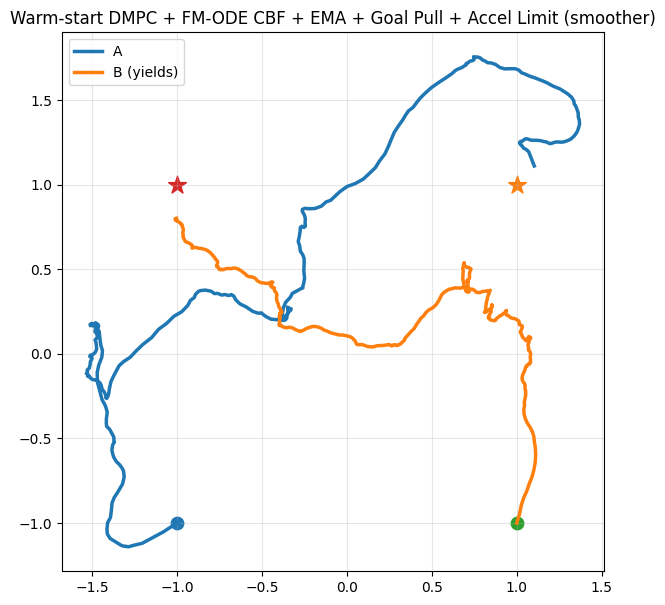

In [13]:
# ===============================================================
# FINAL CELL (SMOOTHER - Method 2: Acceleration Limit)
# Warm-start DMPC (K=1)
# FM ODE with CBF INSIDE
# + EMA smoothing
# + Goal-pull (soft heading correction)
# + Accel-limit (caps dv per step -> rounder turns)
# ===============================================================

import numpy as np
import torch
import torchdiffeq
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------------
# Preconditions
# ---------------------------------------------------------------
if "model_vel" not in globals():
    raise RuntimeError("model_vel not found")
if "cbf_project_velocity_world" not in globals():
    raise RuntimeError("cbf_project_velocity_world not found")

# ---------------------------------------------------------------
# Geometry helpers
# ---------------------------------------------------------------
def infer_cond_dim(model):
    if hasattr(model, "cond_dim") and model.cond_dim is not None:
        return int(model.cond_dim)
    if hasattr(model, "cond_mlp"):
        for l in model.cond_mlp:
            if hasattr(l, "in_features"):
                return int(l.in_features)
    return None

def rot2(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[c, -s], [s, c]])

def canonicalize(x, g, obs):
    x = np.asarray(x); g = np.asarray(g); obs = np.asarray(obs)
    g0 = g - x
    o0 = obs - x
    dist = np.linalg.norm(g0) + 1e-9
    phi = np.arctan2(g0[1], g0[0])
    R = rot2(-phi)
    o_can = R @ o0
    reflect = False
    if o_can[1] < 0:
        o_can[1] *= -1
        reflect = True
    cond3 = np.array([dist, o_can[0], o_can[1]], dtype=np.float32)
    meta = dict(phi=phi, reflect=reflect)
    return cond3, meta

def uncanonicalize(v_can, meta):
    v = v_can.copy()
    if meta["reflect"]:
        v[1] *= -1
    return rot2(meta["phi"]) @ v

# ---------------------------------------------------------------
# FM ODE sampler (CBF inside)
# ---------------------------------------------------------------
@torch.no_grad()
def sample_fm_traj_with_cbf(
    x_self, g_self, other_traj,
    *, H, dt, v_max, speed_scale,
    r_stop=1.0, noise_scale=1.0, ode_steps=50,
):
    cond_raw, meta = canonicalize(x_self, g_self, other_traj[0])

    cond_dim = infer_cond_dim(model_vel)
    cond = cond_raw.copy()
    if cond_dim is not None:
        if cond.shape[0] < cond_dim:
            cond = np.concatenate(
                [cond, np.zeros(cond_dim - cond.shape[0], dtype=np.float32)]
            )
        elif cond.shape[0] > cond_dim:
            cond = cond[:cond_dim]

    cond_t = torch.tensor(cond, device=device).view(1, -1)

    x0 = torch.randn(1, 2, H, device=device) * noise_scale
    t_span = torch.linspace(0.0, 1.0, ode_steps + 1, device=device)

    x_self_np = np.asarray(x_self)
    other_np = np.asarray(other_traj)

    def fm_ode_func(t, x_flat):
        x = x_flat.view(1, 2, H)
        t_t = torch.tensor([t], device=device)
        v_can = model_vel(x, t_t, cond=cond_t)

        # ---- CBF only on first step ----
        v0_can = v_can[0, :, 0].detach().cpu().numpy()
        v0_world = uncanonicalize(v0_can, meta)

        v0_safe = cbf_project_velocity_world(
            torch.tensor(x_self_np).view(1, 2, 1),
            torch.tensor(v0_world).view(1, 2, 1),
            ellipses=[{"center": other_np[1], "radius": 0.6}],
            passes=3,
        )[0, :, 0].cpu().numpy()

        v0_safe_can = rot2(-meta["phi"]) @ v0_safe
        if meta["reflect"]:
            v0_safe_can[1] *= -1
        v_can[0, :, 0] = torch.tensor(v0_safe_can, device=device)

        return v_can.view(-1)

    sol = torchdiffeq.odeint(
        fm_ode_func,
        x0.view(-1),
        t_span,
        method="euler",
    )

    v_can_seq = sol[-1].view(2, H).T.cpu().numpy()

    # ---- rollout ----
    v_seq = np.zeros((H, 2))
    traj = [x_self.copy()]
    xk = x_self.copy()

    for k in range(H):
        d_goal = np.linalg.norm(xk - g_self)
        speed = v_max * speed_scale * min(1.0, d_goal / r_stop)
        v_w = uncanonicalize(v_can_seq[k], meta)
        v_w = speed * v_w / (np.linalg.norm(v_w) + 1e-9)
        v_seq[k] = v_w
        xk = xk + dt * v_w
        traj.append(xk.copy())

    return v_seq, np.asarray(traj)

# ---------------------------------------------------------------
# Smoothing utilities
# ---------------------------------------------------------------
def ema(v_new, v_prev, beta):
    if v_prev is None:
        return v_new
    return beta * v_prev + (1 - beta) * v_new

def goal_pull(v, x, g, alpha=0.15):
    """
    Softly pull back if v points away from goal.
    """
    d = g - x
    d = d / (np.linalg.norm(d) + 1e-9)
    v_dir = v / (np.linalg.norm(v) + 1e-9)
    if np.dot(v_dir, d) < 0.0:
        v = (1 - alpha) * v + alpha * np.linalg.norm(v) * d
    return v

def accel_limit(v_new, v_prev, a_max, dt):
    """
    Cap the magnitude of dv per step: ||v_new - v_prev|| <= a_max * dt
    This makes turns rounder and reduces sharp corners.
    """
    if v_prev is None:
        return v_new
    dv = v_new - v_prev
    n = float(np.linalg.norm(dv) + 1e-9)
    dv_max = float(a_max) * float(dt)
    if n > dv_max:
        v_new = v_prev + dv * (dv_max / n)
    return v_new

# ---------------------------------------------------------------
# Warm-start DMPC loop
# ---------------------------------------------------------------
def two_car_warmstart_dmpc(
    xA0, gA, xB0, gB,
    *,
    dt=0.1, H=15,
    vA_max=1.4, vB_max=1.4,
    speed_A=1.0, speed_B=0.4,
    r_stop=1.0, goal_tol=0.2,
    max_steps=600,
    ema_beta=0.90,
    alpha_A=0.15,
    alpha_B=0.20,
    a_max=2.0,          # ⭐方案2核心参数：越小越顺（但更慢）
    ode_steps=50,
):
    xA = np.array(xA0, dtype=float)
    xB = np.array(xB0, dtype=float)
    gA = np.array(gA, dtype=float)
    gB = np.array(gB, dtype=float)

    xsA, xsB = [xA.copy()], [xB.copy()]
    prev_vA, prev_vB = None, None

    def straight_pred(x, g, v_max, s):
        d = g - x
        d = d / (np.linalg.norm(d) + 1e-9)
        traj = [x.copy()]
        for _ in range(H):
            x = x + dt * v_max * s * d
            traj.append(x.copy())
        return np.asarray(traj)

    predA = straight_pred(xA, gA, vA_max, speed_A)
    predB = straight_pred(xB, gB, vB_max, speed_B)

    for step in range(max_steps):
        # hard stop near goal
        if np.linalg.norm(xA - gA) < goal_tol:
            predA = np.tile(gA, (H+1, 1))
        if np.linalg.norm(xB - gB) < goal_tol:
            predB = np.tile(gB, (H+1, 1))

        # warm-start shift
        predA_shift = np.vstack([predA[1:], predA[-1]])
        predB_shift = np.vstack([predB[1:], predB[-1]])

        # FM sampling
        if np.linalg.norm(xA - gA) >= goal_tol:
            vA_seq, predA = sample_fm_traj_with_cbf(
                xA, gA, predB_shift,
                H=H, dt=dt,
                v_max=vA_max, speed_scale=speed_A,
                r_stop=r_stop,
                ode_steps=ode_steps,
            )
            vA0 = vA_seq[0]
        else:
            vA0 = np.zeros(2)

        if np.linalg.norm(xB - gB) >= goal_tol:
            vB_seq, predB = sample_fm_traj_with_cbf(
                xB, gB, predA_shift,
                H=H, dt=dt,
                v_max=vB_max, speed_scale=speed_B,
                r_stop=r_stop,
                ode_steps=ode_steps,
            )
            vB0 = vB_seq[0]
        else:
            vB0 = np.zeros(2)

        # ---- Smooth execution: EMA -> Goal Pull -> Accel Limit ----
        vA_exec = ema(vA0, prev_vA, ema_beta)
        vB_exec = ema(vB0, prev_vB, ema_beta)

        vA_exec = goal_pull(vA_exec, xA, gA, alpha=alpha_A)
        vB_exec = goal_pull(vB_exec, xB, gB, alpha=alpha_B)

        vA_exec = accel_limit(vA_exec, prev_vA, a_max=a_max, dt=dt)
        vB_exec = accel_limit(vB_exec, prev_vB, a_max=a_max, dt=dt)

        # step
        xA = xA + dt * vA_exec
        xB = xB + dt * vB_exec

        xsA.append(xA.copy())
        xsB.append(xB.copy())
        prev_vA, prev_vB = vA_exec.copy(), vB_exec.copy()

        if step % 50 == 0:
            print(f"[{step:03d}] |dA|={np.linalg.norm(xA-gA):.3f} |dB|={np.linalg.norm(xB-gB):.3f}")

        if np.linalg.norm(xA-gA) < goal_tol and np.linalg.norm(xB-gB) < goal_tol:
            break

    return np.asarray(xsA), np.asarray(xsB)

# ---------------------------------------------------------------
# Demo
# ---------------------------------------------------------------
xA0 = [-1.0, -1.0]; gA = [1.0, 1.0]
xB0 = [ 1.0, -1.0]; gB = [-1.0, 1.0]

xsA, xsB = two_car_warmstart_dmpc(
    xA0, gA, xB0, gB,
    dt=0.1, H=15,
    ema_beta=0.90,
    alpha_A=0.15,
    alpha_B=0.20,
    a_max=2.0,       # ⭐想更顺：1.5；想更灵：2.5
    ode_steps=50,
)

plt.figure(figsize=(7,7))
plt.plot(xsA[:,0], xsA[:,1], lw=2.5, label="A")
plt.plot(xsB[:,0], xsB[:,1], lw=2.5, label="B (yields)")
plt.scatter([xA0[0]],[xA0[1]], s=80)
plt.scatter([gA[0]],[gA[1]], marker="*", s=180)
plt.scatter([xB0[0]],[xB0[1]], s=80)
plt.scatter([gB[0]],[gB[1]], marker="*", s=180)
plt.axis("equal"); plt.grid(alpha=0.3)
plt.legend()
plt.title("Warm-start DMPC + FM-ODE CBF + EMA + Goal Pull + Accel Limit (smoother)")
plt.show()


In [ ]:
# ===============================================================
# NEW CELL: Velocity-field ODE trajectory generation (FM + CBF)
#   state x = [x, y] (trajectory points)
#   model outputs v = [vx, vy]
#   optional: CBF applied to v in world frame
# ===============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt


def _find_velocity_model_from_globals():
    for name in [
        "model_vel",
        "model_v",
        "velocity_model",
        "model_xy",
        "model_traj",
        "model_stage1",
        "stage1_model",
    ]:
        if name in globals():
            return globals()[name], name
    return None, None


def generate_trajectory_velocity_ode(
    flow_model_v,
    *,
    traj_len=100,
    T_final=1.0,
    n_steps=50,
    use_cbf=False,
    ellipses=None,
    extra_margin=0.12,
    max_corr_norm=10.0,
    gamma_min=6.0,
    device="cpu",
    solver_method="dopri5",
    solver_tolerance=1e-5,
):
    """
    Generate a trajectory using a velocity-field FM model.

    flow_model_v: outputs v = [vx, vy] with shape (1,2,N)
    state: x = [x, y] with shape (1,2,N)
    """
    if use_cbf and "cbf_project_velocity_world" not in globals():
        raise RuntimeError("cbf_project_velocity_world not found. Run the CBF cell first.")

    dev = torch.device(device)
    N = int(traj_len)
    ellipses = ellipses or []

    def fm_ode_func(t, x_flat):
        x = x_flat.view(1, 2, N).to(dev)
        t_tensor = torch.tensor([t], device=dev, dtype=x.dtype)

        with torch.no_grad():
            v_nom = flow_model_v(x, t_tensor)  # (1,2,N)

        if use_cbf and len(ellipses) > 0:
            v_nom = cbf_project_velocity_world(
                x,
                v_nom,
                ellipses=ellipses,
                extra_margin=float(extra_margin),
                max_corr_norm=float(max_corr_norm),
                passes=5,
                other_agent_traj=None,
                agent_safe_radius=0.5,
                gamma_min=float(gamma_min),
                w_p=0.0,
                press_k=1.0,
                press_n=2.0,
            )

        return v_nom.view(-1)

    with torch.no_grad():
        x0_noise = torch.randn((1, 2, N), device=dev)
        t_span = torch.linspace(0.0, float(T_final), steps=int(n_steps) + 1, device=dev)

        if "HAS_TORCHDIFFEQ" in globals() and HAS_TORCHDIFFEQ:
            sol = torchdiffeq.odeint(
                fm_ode_func,
                x0_noise.view(-1),
                t_span,
                atol=float(solver_tolerance),
                rtol=float(solver_tolerance),
                method=str(solver_method),
            )
            x_final = sol[-1].view(1, 2, N)
        else:
            # Euler fallback
            x = x0_noise.view(-1)
            dt_list = (t_span[1:] - t_span[:-1]).tolist()
            t_list = t_span[:-1].tolist()
            for t_val, dt in zip(t_list, dt_list):
                x = x + float(dt) * fm_ode_func(float(t_val), x)
            x_final = x.view(1, 2, N)

        return x_final.squeeze(0).detach().cpu().numpy().transpose(1, 0)


print("✅ Velocity-field ODE trajectory generator ready")

# -------------------------
# Demo plot (uses local project definitions only)
# -------------------------
model_demo, model_name = _find_velocity_model_from_globals()

if model_demo is not None:
    if "traj_len" in globals():
        N = int(traj_len)
    elif "TRAJ_LEN" in globals():
        N = int(TRAJ_LEN)
    elif "CTRL_T" in globals():
        N = int(CTRL_T)
    else:
        N = 100

    ellipses_demo = []
    if "ellipses" in globals():
        ellipses_demo = ellipses
    elif "circles" in globals():
        ellipses_demo = _circle_list_to_ellipses(circles) if "_circle_list_to_ellipses" in globals() else []

    traj_xy = generate_trajectory_velocity_ode(
        model_demo,
        traj_len=N,
        T_final=1.0,
        n_steps=50,
        use_cbf=True,
        ellipses=ellipses_demo,
        device=str(globals().get("device", "cpu")),
    )

    plt.figure(figsize=(6, 6))
    plt.plot(traj_xy[:, 0], traj_xy[:, 1], "-", linewidth=2.2, label="FM ODE + CBF")
    plt.scatter([traj_xy[0, 0]], [traj_xy[0, 1]], s=80, label="start")
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.title(f"Velocity-field FM ODE trajectory ({model_name})")
    plt.legend()
    plt.show()
else:
    print("⚠️ 需要先定义 velocity model (model_vel / model_v / model_xy 等) 才能画轨迹")


✅ Second-order state ODE trajectory generator ready
⚠️ 当前模型 in_channels=2，而二阶 ODE 需要 5 通道输入。请用 SimpleUNet1D(in_channels=5, out_channels=2) 重新训练。


In [20]:
# ===============================================================
# NEW CELL (NO-VIRTUAL-OBS): Two-car avoidance with YOUR velocity FM model
#   - Uses model_vel (goal-only conditioned) OR model_vel_obs with padded zeros (NO obs usage)
#   - K candidates from FM-ODE sampling (different noise seeds)
#   - Planning cost uses OTHER agent's *receding-horizon predicted* trajectory (not straight-line)
#   - Execution safety: CBF(other agent) single-step
#   - Asymmetry: B yields more via w_dist_B / w_speed_B / speed_scales_B
# ===============================================================

import numpy as np
import torch
import torchdiffeq
import matplotlib.pyplot as plt

# -------------------------
# 0) Preconditions
# -------------------------
# Prefer a goal-only model if you have it:
#   - model_vel  : goal-only velocity-field FM model  (recommended)
# If you only have model_vel_obs, we will feed goal-only and pad remaining cond dims with zeros
MODEL = None
if "model_vel" in globals():
    MODEL = model_vel

    raise RuntimeError("Need `model_vel`  in globals().")

if "cbf_project_velocity_world" not in globals():
    raise RuntimeError("cbf_project_velocity_world not found. Run your CBF projector cell first.")

# -------------------------
# 1) Utils
# -------------------------
def _wrap_pi(a: float) -> float:
    return float((a + np.pi) % (2 * np.pi) - np.pi)

def _rot2(a: float) -> np.ndarray:
    ca, sa = float(np.cos(a)), float(np.sin(a))
    return np.array([[ca, -sa], [sa, ca]], dtype=np.float64)

def _infer_cond_dim(model):
    if hasattr(model, "cond_dim") and model.cond_dim is not None:
        return int(model.cond_dim)
    cond_mlp = getattr(model, "cond_mlp", None)
    if cond_mlp is not None:
        for layer in cond_mlp:
            if hasattr(layer, "in_features"):
                return int(layer.in_features)
    return None

COND_DIM_MODEL = _infer_cond_dim(MODEL)
if COND_DIM_MODEL is None:
    raise RuntimeError("Could not infer cond_dim from MODEL.")

print(f"[NO-VIRTUAL-OBS] Using MODEL={type(MODEL).__name__}, cond_dim={COND_DIM_MODEL}")

def canonicalize_goal_only_cond(xy_world, goal_xy, *, theta0=0.0, v0=0.3, delta0=0.0, cond_dim=5):
    """
    Goal-only canonicalization:
      - rotate so goal lies on +x
      - reflect so goal is in +y half-plane (optional consistency)
    Returns:
      cond (cond_dim,) and meta (phi, reflect)
    """
    p = np.asarray(xy_world, dtype=np.float64).reshape(2)
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)

    g0 = g - p
    goal_dist = float(np.linalg.norm(g0) + 1e-12)

    phi = float(np.arctan2(g0[1], g0[0]))
    R = _rot2(-phi)
    g_can = (R @ g0.reshape(2, 1)).reshape(2)

    reflect = False
    if float(g_can[1]) < 0.0:
        reflect = True
        g_can[1] *= -1.0

    theta0_can = _wrap_pi(float(theta0) - phi)
    delta0_can = float(delta0)
    if reflect:
        theta0_can = -theta0_can
        delta0_can = -delta0_can

    # base 5-dim goal-only cond
    cond5 = np.array(
        [goal_dist, float(v0), float(np.cos(theta0_can)), float(np.sin(theta0_can)), float(delta0_can)],
        dtype=np.float32
    )

    # pad / truncate to match model cond dim (NO obstacle info)
    if cond_dim <= 5:
        cond = cond5[:cond_dim]
    else:
        pad = np.zeros(cond_dim - 5, dtype=np.float32)
        cond = np.concatenate([cond5, pad], axis=0)

    meta = {"phi": phi, "reflect": reflect}
    return cond, meta

def uncanonicalize_v(v_can_2, meta):
    v = np.asarray(v_can_2, dtype=np.float64).reshape(2).copy()
    if bool(meta.get("reflect", False)):
        v[1] *= -1.0
    Rinv = _rot2(float(meta["phi"]))
    return (Rinv @ v.reshape(2, 1)).reshape(2)

# -------------------------
# 2) CBF step w.r.t. other agent (single-step)
# -------------------------
def _cbf_step_with_other(
    *,
    x_now, v_nom, other_now, dt,
    agent_safe_radius=0.60,
    gamma_min=6.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    extra_margin=0.0,
    device="cpu",
):
    x_now = np.asarray(x_now, dtype=np.float64).reshape(2)
    other_now = np.asarray(other_now, dtype=np.float64).reshape(2)
    v_nom = np.asarray(v_nom, dtype=np.float64).reshape(2)

    ellipses = [{"center": other_now.copy(), "radius": float(agent_safe_radius)}]
    x_traj = torch.tensor(x_now, dtype=torch.float32).view(1, 2, 1)
    v_traj = torch.tensor(v_nom, dtype=torch.float32).view(1, 2, 1)

    v_safe = cbf_project_velocity_world(
        x_traj,
        v_traj,
        ellipses=ellipses,
        extra_margin=float(extra_margin),
        max_corr_norm=float(max_corr_norm),
        passes=5,
        other_agent_traj=None,
        agent_safe_radius=float(agent_safe_radius),
        gamma_min=float(gamma_min),
        w_p=float(w_p),
        press_k=float(press_k),
        press_n=float(press_n),
    )
    return v_safe.squeeze(0).squeeze(-1).detach().cpu().numpy().astype(np.float64)

# -------------------------
# 3) FM ODE sampler: K candidates of v-seq in canonical frame (goal-only cond)
# -------------------------
@torch.no_grad()
def sample_v_seq_fm_odeint(
    *,
    model,
    cond,
    seq_len: int,
    T_SPAN: torch.Tensor,
    solver_method="euler",
    solver_tol=1e-5,
    noise_scale=1.0,
    device="cpu",
    seed=None,
):
    dev = torch.device(device)
    model.eval()

    cond = np.asarray(cond, dtype=np.float32).reshape(-1)
    # guarantee cond_dim matches model
    if cond.shape[0] < COND_DIM_MODEL:
        cond = np.concatenate([cond, np.zeros(COND_DIM_MODEL - cond.shape[0], dtype=np.float32)], axis=0)
    elif cond.shape[0] > COND_DIM_MODEL:
        cond = cond[:COND_DIM_MODEL]

    cond_t = torch.tensor(cond, dtype=torch.float32, device=dev).view(1, -1)

    if seed is not None:
        torch.manual_seed(int(seed))
        np.random.seed(int(seed) % (2**32 - 1))

    x0 = torch.randn(1, 2, int(seq_len), device=dev) * float(noise_scale)
    t_span = T_SPAN.to(dev)

    def fm_ode_func(t, x_flat):
        x = x_flat.view(1, 2, int(seq_len))
        t_tensor = torch.tensor([t], device=dev, dtype=x.dtype)
        v_field = model(x, t_tensor, cond=cond_t)
        return v_field.view(-1)

    sol = torchdiffeq.odeint(
        fm_ode_func,
        x0.view(-1),
        t_span,
        atol=float(solver_tol),
        rtol=float(solver_tol),
        method=str(solver_method),
    )
    x_final = sol[-1].view(1, 2, int(seq_len))
    v_seq_can = x_final[0].detach().cpu().numpy().T.astype(np.float64)  # (H,2)
    return v_seq_can

# -------------------------
# 4) Two-car DMPC (asym) with K candidates + receding-horizon coupling preds
# -------------------------
def two_car_fm_dmpc_goalonly_asym(
    xA0, gA,
    xB0, gB,
    *,
    dt=0.1,
    vA_max=1.4,
    vB_max=1.4,
    max_total_steps=900,
    goal_tol=0.18,
    H=18,
    K=10,
    n_best_response_iters=2,
    # asym yield knobs
    speed_scales_A=(0.4, 0.7, 1.0),
    speed_scales_B=(0.0, 0.4, 0.7, 1.0),
    w_dist_A=80.0,
    w_dist_B=110.0,
    w_speed_A=0.3,
    w_speed_B=0.6,
    # other costs
    w_goal_A=45.0,
    w_goal_B=45.0,
    w_smooth_A=2.0,
    w_smooth_B=2.0,
    w_progress=0.8,          # ⭐ small progress stage cost to prevent looping
    d_safe=1.05,
    # smoothing
    ema_beta=0.92,
    heading_smooth=0.35,
    # cbf
    agent_safe_radius=0.60,
    gamma_min=6.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    device="cpu",
    # fm
    n_steps_sample=60,
    noise_scale=1.0,
    solver_method="euler",
    solver_tol=1e-5,
):
    xA = np.asarray(xA0, dtype=np.float64).reshape(2).copy()
    xB = np.asarray(xB0, dtype=np.float64).reshape(2).copy()
    gA = np.asarray(gA, dtype=np.float64).reshape(2)
    gB = np.asarray(gB, dtype=np.float64).reshape(2)

    xsA, xsB = [xA.copy()], [xB.copy()]
    prev_vA, prev_vB = None, None

    T_SPAN = torch.linspace(0.0, 1.0, int(n_steps_sample) + 1)

    def hinge(z): return max(0.0, float(z))

    def rollout_predict_with_cbf(x0, g, other_current, v_seq_world, *, v_max):
        """
        Build a receding-horizon prediction that mimics your execution shield:
          - apply a single-step CBF each step vs other_current (held fixed during prediction)
        This makes the planning prediction more consistent with execution.
        """
        x = x0.copy()
        traj = [x.copy()]
        for k in range(int(H)):
            v_nom = v_seq_world[k]
            # optional clamp
            sp = float(np.linalg.norm(v_nom) + 1e-12)
            if sp > v_max:
                v_nom = v_nom * (float(v_max) / sp)

            v_safe = _cbf_step_with_other(
                x_now=x, v_nom=v_nom, other_now=other_current, dt=dt,
                agent_safe_radius=agent_safe_radius,
                gamma_min=gamma_min, w_p=w_p, press_k=press_k, press_n=press_n,
                max_corr_norm=max_corr_norm,
                device=device,
            )
            x = x + float(dt) * v_safe
            traj.append(x.copy())
        return np.asarray(traj, dtype=np.float64)  # (H+1,2)

    def eval_cost(x0, g, other_pred, v_seq_world, *,
                  w_goal, w_smooth, w_dist, w_progress):
        x = x0.copy()
        J = 0.0
        v_prev = None
        for k in range(int(H)):
            v = v_seq_world[k]

            # distance penalty to other's predicted traj
            d = float(np.linalg.norm((x + dt * v) - other_pred[k + 1]))
            viol = hinge(float(d_safe) - d)
            J += float(w_dist) * (viol * viol)

            # smoothness
            if v_prev is not None:
                dv = v - v_prev
                J += float(w_smooth) * float(dv @ dv)
            v_prev = v

            # progress stage cost (prevents swirling)
            x_next = x + float(dt) * v
            J += float(w_progress) * float(np.sum((x_next - g) ** 2))

            x = x_next

        J += float(w_goal) * float(np.sum((x - g) ** 2))
        return float(J)

    def pick_best_for_agent(xSelf, gSelf, other_now, other_pred,
                            *, v_max, speed_scales, K,
                            w_goal, w_smooth, w_dist, w_speed, w_progress, prev_v):
        # goal-only cond (NO other info)
        cond, meta = canonicalize_goal_only_cond(xSelf, gSelf, cond_dim=COND_DIM_MODEL)

        # allocate draws across speed scales
        speed_scales = list(speed_scales) if len(speed_scales) else [1.0]
        per = max(1, int(np.ceil(K / len(speed_scales))))

        bestJ = float("inf")
        best_seq_world = None
        best_v0 = np.zeros(2, dtype=np.float64)

        seed_base = np.random.randint(0, 10_000_000)

        for s in speed_scales:
            for j in range(per):
                v_seq_can = sample_v_seq_fm_odeint(
                    model=MODEL,
                    cond=cond,
                    seq_len=int(H),
                    T_SPAN=T_SPAN,
                    solver_method=solver_method,
                    solver_tol=solver_tol,
                    noise_scale=noise_scale,
                    device=device,
                    seed=seed_base + 997 * j + int(1000 * s),
                )

                # canonical -> world
                v_seq_world = np.zeros((H, 2), dtype=np.float64)
                for k in range(int(H)):
                    v_w = uncanonicalize_v(v_seq_can[k], meta)
                    n = float(np.linalg.norm(v_w) + 1e-9)
                    v_seq_world[k] = float(v_max) * float(s) * (v_w / n)

                J = eval_cost(
                    xSelf, gSelf, other_pred, v_seq_world,
                    w_goal=w_goal, w_smooth=w_smooth, w_dist=w_dist, w_progress=w_progress
                )
                # speed scale preference
                J += float(w_speed) * float((1.0 - float(s)) ** 2)
                # continuity on first action
                if prev_v is not None:
                    dv0 = v_seq_world[0] - prev_v
                    J += 0.5 * float(dv0 @ dv0)

                if J < bestJ:
                    bestJ = J
                    best_seq_world = v_seq_world
                    best_v0 = v_seq_world[0].copy()

        # build a receding-horizon pred consistent with execution shield
        if best_seq_world is None:
            best_seq_world = np.zeros((H, 2), dtype=np.float64)
        pred_self = rollout_predict_with_cbf(
            xSelf, gSelf, other_current=other_now, v_seq_world=best_seq_world, v_max=v_max
        )
        return best_v0, best_seq_world, pred_self

    # init preds (just for first iteration; later they become receding-horizon preds)
    def init_pred(x0, g, v_max):
        d = g - x0
        n = float(np.linalg.norm(d) + 1e-12)
        v = float(v_max) * (d / n)
        traj = [x0.copy()]
        x = x0.copy()
        for _ in range(int(H)):
            x = x + float(dt) * v
            traj.append(x.copy())
        return np.asarray(traj, dtype=np.float64)

    predA = init_pred(xA, gA, vA_max)
    predB = init_pred(xB, gB, vB_max)

    for step in range(int(max_total_steps)):
        doneA = float(np.linalg.norm(xA - gA)) <= float(goal_tol)
        doneB = float(np.linalg.norm(xB - gB)) <= float(goal_tol)
        if doneA and doneB:
            break

        best_vA0 = np.zeros(2, dtype=np.float64)
        best_vB0 = np.zeros(2, dtype=np.float64)

        for _ in range(int(max(1, n_best_response_iters))):
            # A responds to current predB
            if not doneA:
                best_vA0, seqA, predA = pick_best_for_agent(
                    xA, gA, other_now=xB, other_pred=predB,
                    v_max=vA_max, speed_scales=speed_scales_A, K=K,
                    w_goal=w_goal_A, w_smooth=w_smooth_A, w_dist=w_dist_A,
                    w_speed=w_speed_A, w_progress=w_progress,
                    prev_v=prev_vA,
                )
            # B responds to updated predA
            if not doneB:
                best_vB0, seqB, predB = pick_best_for_agent(
                    xB, gB, other_now=xA, other_pred=predA,
                    v_max=vB_max, speed_scales=speed_scales_B, K=K,
                    w_goal=w_goal_B, w_smooth=w_smooth_B, w_dist=w_dist_B,
                    w_speed=w_speed_B, w_progress=w_progress,
                    prev_v=prev_vB,
                )

        # smoothing before execution
        def smooth_vec(v_new, v_prev, a):
            if v_prev is None:
                return v_new
            a = float(np.clip(a, 0.0, 1.0))
            return v_prev + a * (v_new - v_prev)

        vA_nom = np.zeros(2) if doneA else smooth_vec(best_vA0, prev_vA, heading_smooth)
        vB_nom = np.zeros(2) if doneB else smooth_vec(best_vB0, prev_vB, heading_smooth)

        # execute one step with CBF(other)
        vA_safe = _cbf_step_with_other(
            x_now=xA, v_nom=vA_nom, other_now=xB, dt=dt,
            agent_safe_radius=agent_safe_radius,
            gamma_min=gamma_min, w_p=w_p, press_k=press_k, press_n=press_n,
            max_corr_norm=max_corr_norm,
            device=device,
        )
        vB_safe = _cbf_step_with_other(
            x_now=xB, v_nom=vB_nom, other_now=xA, dt=dt,
            agent_safe_radius=agent_safe_radius,
            gamma_min=gamma_min, w_p=w_p, press_k=press_k, press_n=press_n,
            max_corr_norm=max_corr_norm,
            device=device,
        )

        # EMA
        if ema_beta is not None:
            b = float(np.clip(ema_beta, 0.0, 0.999))
            vA_exec = vA_safe if prev_vA is None else b * prev_vA + (1.0 - b) * vA_safe
            vB_exec = vB_safe if prev_vB is None else b * prev_vB + (1.0 - b) * vB_safe
        else:
            vA_exec, vB_exec = vA_safe, vB_safe

        xA = xA + float(dt) * vA_exec
        xB = xB + float(dt) * vB_exec
        xsA.append(xA.copy())
        xsB.append(xB.copy())
        prev_vA, prev_vB = vA_exec.copy(), vB_exec.copy()

        if step % 50 == 0:
            dAB = float(np.linalg.norm(xA - xB))
            print(f"[step {step:04d}] dAB={dAB:.3f} |dA|={np.linalg.norm(xA-gA):.3f} |dB|={np.linalg.norm(xB-gB):.3f}")

    return np.asarray(xsA, dtype=np.float64), np.asarray(xsB, dtype=np.float64)

# -------------------------
# 5) Demo + Plot
# -------------------------
xA0 = np.array([-1.0, -1.0], dtype=np.float64)
gA  = np.array([+1.0, +1.0], dtype=np.float64)
xB0 = np.array([+1.0, -1.0], dtype=np.float64)
gB  = np.array([-1.0, +1.0], dtype=np.float64)

dt_use = float(globals().get("dt", 0.1))
dev_use = str(globals().get("device", "cpu"))
SOLVER_METHOD = str(globals().get("SOLVER_METHOD", "euler"))
SOLVER_TOL = float(globals().get("SOLVER_TOLERANCE", 1e-5))

xsA, xsB = two_car_fm_dmpc_goalonly_asym(
    xA0, gA, xB0, gB,
    dt=dt_use,
    vA_max=1.4,
    vB_max=1.4,
    max_total_steps=900,
    goal_tol=0.18,
    H=18,
    K=10,                    # ✅ K candidates
    n_best_response_iters=2, # ✅ use receding-horizon preds, not straight-line
    speed_scales_A=(0.4, 0.7, 1.0),
    speed_scales_B=(0.0, 0.4, 0.7, 1.0),
    w_dist_A=80.0,
    w_dist_B=110.0,
    w_speed_A=0.3,
    w_speed_B=0.6,
    w_progress=0.8,          # ⭐ key to reduce looping
    d_safe=1.05,
    ema_beta=0.92,
    heading_smooth=0.35,
    agent_safe_radius=0.60,
    gamma_min=6.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    device=dev_use,
    n_steps_sample=60,
    noise_scale=1.0,
    solver_method=SOLVER_METHOD,
    solver_tol=SOLVER_TOL,
)

plt.figure(figsize=(7, 7))
plt.plot(xsA[:, 0], xsA[:, 1], "-", linewidth=2.6, label="A (FM-vel goal-only + DMPC + CBF)")
plt.plot(xsB[:, 0], xsB[:, 1], "-", linewidth=2.6, label="B (FM-vel goal-only + DMPC + CBF, yields more)")
plt.scatter([xsA[0, 0]], [xsA[0, 1]], s=90, label="A start")
plt.scatter([gA[0]], [gA[1]], s=180, marker="*", label="A goal")
plt.scatter([xsB[0, 0]], [xsB[0, 1]], s=90, label="B start")
plt.scatter([gB[0]], [gB[1]], s=180, marker="*", label="B goal")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("Two-car avoidance: FM velocity (NO virtual obs cond) + K candidates + receding-horizon coupling + CBF")
plt.legend()
plt.show()


RuntimeError: Need `model_vel`  in globals().

In [1]:
# ===============================================================
#速度场/heading MPC + CBF” 的 rollout
# NEW CELL: Two-car head-on avoidance (MPC receding-horizon + CBF w/ other_agent)
#
# Framework:
#   - At each step, predict the other agent over horizon H (simple nominal-to-goal rollout).
#   - Ego MPC: search candidate headings; simulate H-step ahead.
#       * Hard constraint: for each i in 1..H, ||xA_i - xB_i|| >= d_safe
#       * Dynamics step uses CBF projection with other_agent (pressure-based stronger repulsion).
#   - Execute 1 step, repeat.
#
# Notes:
#   - MPC constraint gives anticipation; CBF inside ODE is the safety shield.
#   - For a symmetric game, you can run the same MPC for both cars (best-response). This cell
#     keeps it simple: A uses MPC; B follows nominal-to-goal (still protected by CBF).
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

# -------------------------
# 0) Robustness: ensure ellipse_h_grad_batch exists (CBF uses it internally)
# -------------------------
if "ellipse_h_grad_batch" not in globals():
    def ellipse_h_grad_batch(x_world_2N: torch.Tensor, ellipse: dict):
        if not torch.is_tensor(x_world_2N):
            x_world_2N = torch.as_tensor(x_world_2N, dtype=torch.float32)
        center = ellipse["center"]
        if not torch.is_tensor(center):
            center = torch.as_tensor(center, dtype=x_world_2N.dtype, device=x_world_2N.device)

        if "a" in ellipse or "b" in ellipse:
            a = float(ellipse.get("a", 1.0))
            b = float(ellipse.get("b", 1.0))
        elif "radius" in ellipse:
            r = float(ellipse["radius"])
            a = 1.0 / max(r, 1e-9)
            b = a
        else:
            raise KeyError("ellipse must have keys {'center','a','b'} or {'center','radius'}")

        x_N2 = x_world_2N.transpose(0, 1)
        delta = x_N2 - center.view(1, 2)
        ax = float(a) * delta[:, 0]
        by = float(b) * delta[:, 1]
        h_e = ax * ax + by * by - 1.0
        grad_w = torch.stack([
            2.0 * (float(a) ** 2) * delta[:, 0],
            2.0 * (float(b) ** 2) * delta[:, 1],
        ], dim=1)
        return h_e, grad_w

# need CBF core
if "cbf_project_velocity_world" not in globals():
    raise RuntimeError("cbf_project_velocity_world not found. Please run the CBF/ODE cell above first.")


def _wrap_pi(a):
    return float((a + np.pi) % (2 * np.pi) - np.pi)


def _find_velocity_model_from_globals():
    for name in (
        "model_stage1",
        "stage1_model",
        "model_vel",
        "model_v",
        "velocity_model",
        "model_traj",
        "model_xy",
        "model_fm",
        "fm_model",
        "flow_model",
        "model_traj_fm",
        "model_traj_v",
    ): 
        m = globals().get(name, None)
        if m is not None:
            return m, name
    return None, None


def _get_fm_traj_len():
    if "traj_xy" in globals():
        return int(np.asarray(traj_xy).shape[2])
    if "data" in globals() and isinstance(data, dict) and "traj_xy" in data:
        return int(np.asarray(data["traj_xy"]).shape[2])
    if "states_np" in globals():
        return int(np.asarray(states_np).shape[1])
    return 60


def _clip_speed(v, v_max):
    n = float(np.linalg.norm(v))
    if n <= 1e-9:
        return v
    if n > float(v_max):
        return (float(v_max) / n) * v
    return v


def _fm_nominal_velocity(xy: np.ndarray, goal_xy: np.ndarray, *, dt: float, model, traj_len: int, device: str) -> np.ndarray:
    """Use trained FM velocity model to get a nominal velocity at the current position."""
    x = np.asarray(xy, dtype=np.float64).reshape(2)
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)

    ts = np.linspace(0.0, 1.0, int(traj_len), dtype=np.float64)
    traj = (1.0 - ts)[:, None] * x[None, :] + ts[:, None] * g[None, :]
    x_init = torch.as_tensor(traj.T[None, ...], dtype=torch.float32, device=device)

    solver = ODESolver(model=model, traj_len=int(traj_len), use_cbf=False)
    x_T = solver.sample(x_init)

    v = (x_T[0, :, 1] - x_T[0, :, 0]).detach().cpu().numpy().astype(np.float64) / float(dt)
    return v


def _cbf_step_with_other(
    x_now: np.ndarray,
    v_nom: np.ndarray,
    other_now: np.ndarray,
    *,
    dt: float,
    device: str,
    agent_safe_radius: float,
    gamma_min: float,
    w_p: float,
    press_k: float,
    press_n: float,
    max_corr_norm: float,
):
    """Single-step CBF projection using other_agent_pos_2 (no static ellipses)."""
    dev = torch.device(device)
    x_now_2 = torch.as_tensor(np.asarray(x_now, dtype=np.float64), dtype=torch.float32, device=dev)
    v_nom_2 = torch.as_tensor(np.asarray(v_nom, dtype=np.float64), dtype=torch.float32, device=dev)
    other_2 = torch.as_tensor(np.asarray(other_now, dtype=np.float64), dtype=torch.float32, device=dev)

    # If your cbf_project_velocity_step exists, use it (it supports other_agent_pos_2 + pressure params).
    if "cbf_project_velocity_step" in globals():
        v_safe_2 = cbf_project_velocity_step(
            x_now_2,
            v_nom_2,
            ellipses=[],
            other_agent_pos_2=other_2,
            agent_safe_radius=float(agent_safe_radius),
            extra_margin=0.0,
            max_corr_norm=float(max_corr_norm),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
        )
        return v_safe_2.detach().cpu().numpy().astype(np.float64)

    # Fallback: call cbf_project_velocity_world directly (shape (1,2,1))
    x_traj = x_now_2.view(1, 2, 1)
    v_traj = v_nom_2.view(1, 2, 1)
    other_traj = other_2.view(1, 2, 1)
    v_safe = cbf_project_velocity_world(
        x_traj,
        v_traj,
        ellipses=[],
        extra_margin=0.0,
        max_corr_norm=float(max_corr_norm),
        passes=5,
        other_agent_traj=other_traj,
        agent_safe_radius=float(agent_safe_radius),
        gamma_min=float(gamma_min),
        w_p=float(w_p),
        press_k=float(press_k),
        press_n=float(press_n),
    )
    return v_safe.squeeze(0).squeeze(-1).detach().cpu().numpy().astype(np.float64)


def _predict_other_positions(
    xB0: np.ndarray,
    gB: np.ndarray,
    *,
    xA0: np.ndarray,
    dt: float,
    H: int,
    vB_max: float,
    device: str,
    agent_safe_radius: float,
    gamma_min: float,
    w_p: float,
    press_k: float,
    press_n: float,
    max_corr_norm: float,
    model_vel,
    traj_len: int,
):
    """Predict other agent positions over horizon H (including step 0 position).

    Use trained FM velocity model for nominal motion, then apply CBF as a conservative shield.
    """
    xB = np.asarray(xB0, dtype=np.float64).reshape(2).copy()
    xsB = [xB.copy()]

    model_dev = next(model_vel.parameters()).device

    for _ in range(int(H)):
        vB_nom = _fm_nominal_velocity(xB, gB, dt=float(dt), model=model_vel, traj_len=int(traj_len), device=str(model_dev))
        vB_nom = _clip_speed(vB_nom, float(vB_max))
        vB_safe = _cbf_step_with_other(
            x_now=xB,
            v_nom=vB_nom,
            other_now=xA0,   # conservative: treat A as fixed at current position during prediction
            dt=float(dt),
            device=str(device),
            agent_safe_radius=float(agent_safe_radius),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
            max_corr_norm=float(max_corr_norm),
        )
        xB = xB + float(dt) * vB_safe
        xsB.append(xB.copy())

    return np.asarray(xsB, dtype=np.float64)  # (H+1,2)


def two_car_headon_mpc_rollout(
    xA0,
    gA,
    xB0,
    gB,
    *,
    dt=0.02,
    vA_max=1.4,
    vB_max=1.4,
    max_total_steps=650,
    goal_tol=0.18,
    # MPC horizon
    H=12,
    n_heading_samples=41,
    heading_span_deg=150.0,
    # distance preference (MPC constraint)
    d_safe=1.0,
    # CBF parameters (your pressure-based stronger repulsion)
    agent_safe_radius=0.5,
    gamma_min=1.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    device="cpu",
    # costs
    w_goal=12.0,
    w_turn=0.12,          # ↑ stronger turning penalty -> smoother
    w_dist=80.0,          # distance soft penalty weight (anticipation)
    heading_smooth=0.35,  # low-pass on executed heading (0=no smoothing, 1=fully jump)
    # FM velocity model
    model_vel=None,
    traj_len=None,
):
    """Step-by-step MPC rollout.

    Why it can look "kinky": we pick a heading from a DISCRETE set each step.
    Fixes here:
      - soften distance constraint (penalty instead of infeasible jump)
      - stronger turn penalty + executed heading smoothing
    """

    xA = np.asarray(xA0, dtype=np.float64).reshape(2).copy()
    xB = np.asarray(xB0, dtype=np.float64).reshape(2).copy()
    gA = np.asarray(gA, dtype=np.float64).reshape(2)
    gB = np.asarray(gB, dtype=np.float64).reshape(2)

    if model_vel is None:
        model_vel, model_name = _find_velocity_model_from_globals()
        if model_vel is None:
            raise RuntimeError(
                "FM velocity model not found. Expected one of: model_stage1, stage1_model, model_vel, model_v, velocity_model, model_traj, model_xy"
            )
    if traj_len is None:
        traj_len = _get_fm_traj_len()

    model_dev = next(model_vel.parameters()).device

    xsA = [xA.copy()]
    xsB = [xB.copy()]

    prev_heading = None

    def soft_hinge(z):
        return max(0.0, float(z))

    for step in range(int(max_total_steps)):
        if float(np.linalg.norm(xA - gA)) <= float(goal_tol) and float(np.linalg.norm(xB - gB)) <= float(goal_tol):
            break

        # 1) predict B positions over horizon (simple policy)
        predB = _predict_other_positions(
            xB, gB,
            xA0=xA,
            dt=float(dt),
            H=int(H),
            vB_max=float(vB_max),
            device=str(device),
            agent_safe_radius=float(agent_safe_radius),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
            max_corr_norm=float(max_corr_norm),
            model_vel=model_vel,
            traj_len=int(traj_len),
        )  # (H+1,2)

        # 2) ego MPC (A): search candidate headings; distance handled as SOFT penalty
        vA_fm = _fm_nominal_velocity(xA, gA, dt=float(dt), model=model_vel, traj_len=int(traj_len), device=str(model_dev))
        vA_speed = float(min(float(vA_max), max(1e-3, float(np.linalg.norm(vA_fm)))))
        if float(np.linalg.norm(vA_fm)) <= 1e-9:
            d = gA - xA
            base_heading = float(np.arctan2(d[1], d[0]))
        else:
            base_heading = float(np.arctan2(vA_fm[1], vA_fm[0]))

        span = np.deg2rad(float(heading_span_deg))
        offsets = np.linspace(-span / 2.0, span / 2.0, int(n_heading_samples), dtype=np.float64)

        best_J = float("inf")
        best_heading = base_heading

        for off in offsets:
            heading = float(base_heading + off)

            x_sim = xA.copy()
            J = 0.0

            # simulate H-step ahead with CBF vs predicted other
            for k in range(int(H)):
                vA_nom = float(vA_speed) * np.array([np.cos(heading), np.sin(heading)], dtype=np.float64)

                vA_safe = _cbf_step_with_other(
                    x_now=x_sim,
                    v_nom=vA_nom,
                    other_now=predB[k],
                    dt=float(dt),
                    device=str(device),
                    agent_safe_radius=float(agent_safe_radius),
                    gamma_min=float(gamma_min),
                    w_p=float(w_p),
                    press_k=float(press_k),
                    press_n=float(press_n),
                    max_corr_norm=float(max_corr_norm),
                )

                x_sim = x_sim + float(dt) * vA_safe

                # soft distance penalty at step k+1
                dist_k = float(np.linalg.norm(x_sim - predB[k + 1]))
                viol = soft_hinge(float(d_safe) - dist_k)
                J += w_dist * (viol * viol)

            # terminal goal cost
            J += w_goal * float(np.sum((x_sim - gA) ** 2))

            # smooth turning (prefer continuity)
            if prev_heading is not None:
                dphi = _wrap_pi(heading - prev_heading)
                J += w_turn * (dphi * dphi)

            if J < best_J:
                best_J = J
                best_heading = heading

        # 3) execute 1 step for both cars
        # A uses best heading, but smooth the executed heading to avoid sharp corners
        if prev_heading is None:
            exec_heading = best_heading
        else:
            a = float(np.clip(heading_smooth, 0.0, 1.0))
            dphi = _wrap_pi(best_heading - prev_heading)
            exec_heading = _wrap_pi(prev_heading + a * dphi)

        vA_nom = float(vA_speed) * np.array([np.cos(exec_heading), np.sin(exec_heading)], dtype=np.float64)
        vA_safe = _cbf_step_with_other(
            x_now=xA,
            v_nom=vA_nom,
            other_now=xB,
            dt=float(dt),
            device=str(device),
            agent_safe_radius=float(agent_safe_radius),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
            max_corr_norm=float(max_corr_norm),
        )

        # B uses nominal-to-goal (still CBF-protected vs A)
        vB_nom = _fm_nominal_velocity(xB, gB, dt=float(dt), model=model_vel, traj_len=int(traj_len), device=str(model_dev))
        vB_nom = _clip_speed(vB_nom, float(vB_max))
        vB_safe = _cbf_step_with_other(
            x_now=xB,
            v_nom=vB_nom,
            other_now=xA,
            dt=float(dt),
            device=str(device),
            agent_safe_radius=float(agent_safe_radius),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
            max_corr_norm=float(max_corr_norm),
        )

        xA = xA + float(dt) * vA_safe
        xB = xB + float(dt) * vB_safe

        xsA.append(xA.copy())
        xsB.append(xB.copy())
        prev_heading = exec_heading

        if float(np.linalg.norm(xA - gA)) <= float(goal_tol) and float(np.linalg.norm(xB - gB)) <= float(goal_tol):
            break

    return np.asarray(xsA, dtype=np.float64), np.asarray(xsB, dtype=np.float64)


# -------------------------
# 1) Scenario: head-on (swap goals)
# -------------------------
# Reuse x0/goal from your previous cell if present.
if "x0_xy" in globals() and "goal_xy" in globals():
    xA0 = np.asarray(x0_xy, dtype=np.float64)
    gA = np.asarray(goal_xy, dtype=np.float64)

    # Put the other car near the goal and make it head back to the start (swap-goal head-on)
    xB0 = gA.copy()
    gB = xA0.copy()
else:
    # fallback demo
    xA0 = np.array([-1.5, 0.0], dtype=np.float64)
    gA = np.array([+1.5, 0.0], dtype=np.float64)
    xB0 = np.array([+1.5, 0.0], dtype=np.float64)
    gB = np.array([-1.5, 0.0], dtype=np.float64)

# Slight lateral offset to make it visually clearer (optional)
# If you want the *start points* to be "crossed" (交叉一下), flip the offsets.
CROSS_STARTS = True
LATERAL_OFFSET = 0.25

if CROSS_STARTS:
    # A starts lower lane, B starts upper lane (crossed vs previous setting)
    xA0 = xA0 + np.array([0.0, -LATERAL_OFFSET], dtype=np.float64)
    xB0 = xB0 + np.array([0.0, +LATERAL_OFFSET], dtype=np.float64)
else:
    xA0 = xA0 + np.array([0.0, +LATERAL_OFFSET], dtype=np.float64)
    xB0 = xB0 + np.array([0.0, -LATERAL_OFFSET], dtype=np.float64)

# -------------------------
# 2) Run
# -------------------------
model_vel, model_vel_name = _find_velocity_model_from_globals()
if model_vel is None:
    raise RuntimeError(
        "No FM velocity model found. Set `model_vel = <your trained velocity model>` before running this cell."
    )
traj_len = _get_fm_traj_len()

xsA, xsB = two_car_headon_mpc_rollout(
    xA0, gA, xB0, gB,
    dt=0.02,
    vA_max=1.4,
    vB_max=1.4,
    max_total_steps=800,
    goal_tol=0.18,
    H=12,
    n_heading_samples=41,
    heading_span_deg=150.0,
    d_safe=1.0,
    agent_safe_radius=0.55,
    gamma_min=1.0,
    w_p=6.0,        # pressure strength (closer => stronger repulsion)
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    device="cpu",
    w_goal=12.0,
    w_turn=0.03,
    model_vel=model_vel,
    traj_len=int(traj_len),
)

# -------------------------
# 3) Plot
# -------------------------
plt.figure(figsize=(7, 7))
plt.plot(xsA[:, 0], xsA[:, 1], "-", linewidth=2.4, label="ego A (MPC+CBF)")
plt.plot(xsB[:, 0], xsB[:, 1], "-", linewidth=2.4, label="other B (nominal+CBF)")
plt.scatter([xsA[0, 0]], [xsA[0, 1]], s=90, label="A start")
plt.scatter([gA[0]], [gA[1]], s=180, marker="*", label="A goal")
plt.scatter([xsB[0, 0]], [xsB[0, 1]], s=90, label="B start")
plt.scatter([gB[0]], [gB[1]], s=180, marker="*", label="B goal")

# visualize safety distance band (optional): circle around B start
# (We leave it off by default to avoid clutter.)

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("Two-car head-on avoidance: MPC distance constraints + CBF(other_agent, pressure)")
plt.legend()
plt.show()



RuntimeError: cbf_project_velocity_world not found. Please run the CBF/ODE cell above first.

[symmetric DMPC scenario] A: [-1. -1.] -> [1. 1.]  | B: [ 1. -1.] -> [-1.  1.]


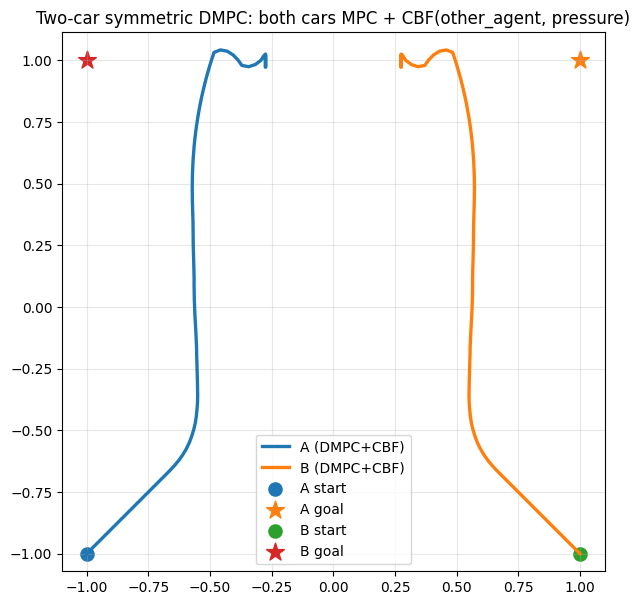

In [ ]:
# ===============================================================
# NEW CELL: Symmetric DMPC (A and B both use MPC) + CBF(other_agent, pressure)
#
# Each time step:
#   - run a small number of best-response iterations to get (heading_A, heading_B)
#   - execute ONE step for both cars (receding horizon)
# Safety is still enforced by your CBF projection inside the step.
# ===============================================================

import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 0) Reuse helpers from previous cell; define fallbacks if missing
# -------------------------
if "_wrap_pi" not in globals():
    def _wrap_pi(a):
        return float((a + np.pi) % (2 * np.pi) - np.pi)

if "_nominal_velocity_to_goal" not in globals():
    def _nominal_velocity_to_goal(xy: np.ndarray, goal_xy: np.ndarray, v_max: float) -> np.ndarray:
        d = np.asarray(goal_xy, dtype=np.float64).reshape(2) - np.asarray(xy, dtype=np.float64).reshape(2)
        n = float(np.linalg.norm(d) + 1e-12)
        return float(v_max) * (d / n)

if "_cbf_step_with_other" not in globals():
    raise RuntimeError("Please run the previous two-car MPC cell first (it defines `_cbf_step_with_other`).")


def _simulate_heading_rollout_with_other_pred(
    x0: np.ndarray,
    goal: np.ndarray,
    other_pred: np.ndarray,
    *,
    heading: float,
    dt: float,
    H: int,
    v_max: float,
    device: str,
    # CBF
    agent_safe_radius: float,
    gamma_min: float,
    w_p: float,
    press_k: float,
    press_n: float,
    max_corr_norm: float,
    # MPC penalties
    d_safe: float,
    w_goal: float,
    w_turn: float,
    w_dist: float,
    prev_heading: float = None,
):
    """Simulate H steps with fixed heading, CBF against other_pred[k]. Return (J, xH)."""
    x = np.asarray(x0, dtype=np.float64).reshape(2).copy()
    goal = np.asarray(goal, dtype=np.float64).reshape(2)

    def hinge(z):
        return max(0.0, float(z))

    J = 0.0
    for k in range(int(H)):
        v_nom = float(v_max) * np.array([np.cos(heading), np.sin(heading)], dtype=np.float64)
        v_safe = _cbf_step_with_other(
            x_now=x,
            v_nom=v_nom,
            other_now=other_pred[k],
            dt=float(dt),
            device=str(device),
            agent_safe_radius=float(agent_safe_radius),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
            max_corr_norm=float(max_corr_norm),
        )
        x = x + float(dt) * v_safe

        dist_k = float(np.linalg.norm(x - other_pred[k + 1]))
        viol = hinge(float(d_safe) - dist_k)
        J += float(w_dist) * (viol * viol)

    # terminal goal cost
    J += float(w_goal) * float(np.sum((x - goal) ** 2))

    # turning continuity
    if prev_heading is not None:
        dphi = _wrap_pi(float(heading) - float(prev_heading))
        J += float(w_turn) * (dphi * dphi)

    return float(J), x


def _predict_self_over_horizon(
    x0: np.ndarray,
    goal: np.ndarray,
    *,
    heading: float,
    dt: float,
    H: int,
    v_max: float,
    device: str,
    # CBF
    other_current: np.ndarray,
    agent_safe_radius: float,
    gamma_min: float,
    w_p: float,
    press_k: float,
    press_n: float,
    max_corr_norm: float,
):
    """Generate a conservative prediction of this agent for (H+1,2).

    We keep `other_current` fixed during prediction (conservative shield), and still run CBF.
    """
    x = np.asarray(x0, dtype=np.float64).reshape(2).copy()
    goal = np.asarray(goal, dtype=np.float64).reshape(2)

    xs = [x.copy()]
    for _ in range(int(H)):
        v_nom = float(v_max) * np.array([np.cos(heading), np.sin(heading)], dtype=np.float64)
        v_safe = _cbf_step_with_other(
            x_now=x,
            v_nom=v_nom,
            other_now=other_current,
            dt=float(dt),
            device=str(device),
            agent_safe_radius=float(agent_safe_radius),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
            max_corr_norm=float(max_corr_norm),
        )
        x = x + float(dt) * v_safe
        xs.append(x.copy())

    return np.asarray(xs, dtype=np.float64)


def two_car_symmetric_dmpc_rollout(
    xA0,
    gA,
    xB0,
    gB,
    *,
    dt=0.02,
    vA_max=1.4,
    vB_max=1.4,
    max_total_steps=900,
    goal_tol=0.18,
    # MPC horizon
    H=12,
    n_heading_samples=61,
    heading_span_deg=160.0,
    # distance preference
    d_safe=1.0,
    # CBF parameters
    agent_safe_radius=0.55,
    gamma_min=1.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    device="cpu",
    # MPC penalties
    w_goal=12.0,
    w_turn=0.12,
    w_dist=80.0,
    heading_smooth=0.35,
    # DMPC coupling iterations
    n_best_response_iters=2,
):
    xA = np.asarray(xA0, dtype=np.float64).reshape(2).copy()
    xB = np.asarray(xB0, dtype=np.float64).reshape(2).copy()
    gA = np.asarray(gA, dtype=np.float64).reshape(2)
    gB = np.asarray(gB, dtype=np.float64).reshape(2)

    xsA = [xA.copy()]
    xsB = [xB.copy()]

    prev_hA = None
    prev_hB = None

    span = np.deg2rad(float(heading_span_deg))

    for _step in range(int(max_total_steps)):
        if float(np.linalg.norm(xA - gA)) <= float(goal_tol) and float(np.linalg.norm(xB - gB)) <= float(goal_tol):
            break

        # Initialize headings toward goals
        hA = float(np.arctan2((gA - xA)[1], (gA - xA)[0]))
        hB = float(np.arctan2((gB - xB)[1], (gB - xB)[0]))

        # Best-response iterations (cheap coupling)
        for _ in range(int(max(1, n_best_response_iters))):
            # Predict other trajectories over horizon
            predA = _predict_self_over_horizon(
                xA, gA,
                heading=hA,
                dt=float(dt),
                H=int(H),
                v_max=float(vA_max),
                device=str(device),
                other_current=xB,
                agent_safe_radius=float(agent_safe_radius),
                gamma_min=float(gamma_min),
                w_p=float(w_p),
                press_k=float(press_k),
                press_n=float(press_n),
                max_corr_norm=float(max_corr_norm),
            )
            predB = _predict_self_over_horizon(
                xB, gB,
                heading=hB,
                dt=float(dt),
                H=int(H),
                v_max=float(vB_max),
                device=str(device),
                other_current=xA,
                agent_safe_radius=float(agent_safe_radius),
                gamma_min=float(gamma_min),
                w_p=float(w_p),
                press_k=float(press_k),
                press_n=float(press_n),
                max_corr_norm=float(max_corr_norm),
            )

            # Solve A heading vs predicted B
            baseA = float(np.arctan2((gA - xA)[1], (gA - xA)[0]))
            offsA = np.linspace(-span / 2.0, span / 2.0, int(n_heading_samples), dtype=np.float64)
            bestJA = float("inf")
            bestHA = baseA
            for off in offsA:
                cand = float(baseA + off)
                JA, _ = _simulate_heading_rollout_with_other_pred(
                    xA,
                    gA,
                    predB,
                    heading=cand,
                    dt=float(dt),
                    H=int(H),
                    v_max=float(vA_max),
                    device=str(device),
                    agent_safe_radius=float(agent_safe_radius),
                    gamma_min=float(gamma_min),
                    w_p=float(w_p),
                    press_k=float(press_k),
                    press_n=float(press_n),
                    max_corr_norm=float(max_corr_norm),
                    d_safe=float(d_safe),
                    w_goal=float(w_goal),
                    w_turn=float(w_turn),
                    w_dist=float(w_dist),
                    prev_heading=prev_hA,
                )
                if JA < bestJA:
                    bestJA = JA
                    bestHA = cand
            hA = bestHA

            # Solve B heading vs predicted A
            baseB = float(np.arctan2((gB - xB)[1], (gB - xB)[0]))
            offsB = np.linspace(-span / 2.0, span / 2.0, int(n_heading_samples), dtype=np.float64)
            bestJB = float("inf")
            bestHB = baseB
            for off in offsB:
                cand = float(baseB + off)
                JB, _ = _simulate_heading_rollout_with_other_pred(
                    xB,
                    gB,
                    predA,
                    heading=cand,
                    dt=float(dt),
                    H=int(H),
                    v_max=float(vB_max),
                    device=str(device),
                    agent_safe_radius=float(agent_safe_radius),
                    gamma_min=float(gamma_min),
                    w_p=float(w_p),
                    press_k=float(press_k),
                    press_n=float(press_n),
                    max_corr_norm=float(max_corr_norm),
                    d_safe=float(d_safe),
                    w_goal=float(w_goal),
                    w_turn=float(w_turn),
                    w_dist=float(w_dist),
                    prev_heading=prev_hB,
                )
                if JB < bestJB:
                    bestJB = JB
                    bestHB = cand
            hB = bestHB

        # Execute ONE step with heading smoothing
        if prev_hA is None:
            exec_hA = hA
        else:
            a = float(np.clip(heading_smooth, 0.0, 1.0))
            exec_hA = _wrap_pi(prev_hA + a * _wrap_pi(hA - prev_hA))

        if prev_hB is None:
            exec_hB = hB
        else:
            a = float(np.clip(heading_smooth, 0.0, 1.0))
            exec_hB = _wrap_pi(prev_hB + a * _wrap_pi(hB - prev_hB))

        vA_nom = float(vA_max) * np.array([np.cos(exec_hA), np.sin(exec_hA)], dtype=np.float64)
        vB_nom = float(vB_max) * np.array([np.cos(exec_hB), np.sin(exec_hB)], dtype=np.float64)

        vA_safe = _cbf_step_with_other(
            x_now=xA,
            v_nom=vA_nom,
            other_now=xB,
            dt=float(dt),
            device=str(device),
            agent_safe_radius=float(agent_safe_radius),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
            max_corr_norm=float(max_corr_norm),
        )
        vB_safe = _cbf_step_with_other(
            x_now=xB,
            v_nom=vB_nom,
            other_now=xA,
            dt=float(dt),
            device=str(device),
            agent_safe_radius=float(agent_safe_radius),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
            max_corr_norm=float(max_corr_norm),
        )

        xA = xA + float(dt) * vA_safe
        xB = xB + float(dt) * vB_safe

        xsA.append(xA.copy())
        xsB.append(xB.copy())

        prev_hA = exec_hA
        prev_hB = exec_hB

    return np.asarray(xsA, dtype=np.float64), np.asarray(xsB, dtype=np.float64)


# -------------------------
# Scenario (same as user-specified)
# -------------------------
xA0 = np.array([-1.0, -1.0], dtype=np.float64)
gA  = np.array([+1.0, +1.0], dtype=np.float64)
xB0 = np.array([+1.0, -1.0], dtype=np.float64)
gB  = np.array([-1.0, +1.0], dtype=np.float64)

print("[symmetric DMPC scenario] A:", xA0, "->", gA, " | B:", xB0, "->", gB)

xsA_sym, xsB_sym = two_car_symmetric_dmpc_rollout(
    xA0, gA, xB0, gB,
    dt=0.02,
    vA_max=1.4,
    vB_max=1.4,
    max_total_steps=1200,
    goal_tol=0.18,
    H=12,
    n_heading_samples=61,
    heading_span_deg=160.0,
    d_safe=1.0,
    agent_safe_radius=0.55,
    gamma_min=1.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    device="cpu",
    w_goal=12.0,
    w_turn=0.12,
    w_dist=80.0,
    heading_smooth=0.35,
    n_best_response_iters=2,
)

plt.figure(figsize=(7, 7))
plt.plot(xsA_sym[:, 0], xsA_sym[:, 1], "-", linewidth=2.4, label="A (DMPC+CBF)")
plt.plot(xsB_sym[:, 0], xsB_sym[:, 1], "-", linewidth=2.4, label="B (DMPC+CBF)")
plt.scatter([xsA_sym[0, 0]], [xsA_sym[0, 1]], s=90, label="A start")
plt.scatter([gA[0]], [gA[1]], s=180, marker="*", label="A goal")
plt.scatter([xsB_sym[0, 0]], [xsB_sym[0, 1]], s=90, label="B start")
plt.scatter([gB[0]], [gB[1]], s=180, marker="*", label="B goal")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("Two-car symmetric DMPC: both cars MPC + CBF(other_agent, pressure)")
plt.legend()
plt.show()



[step 0000] dAB=1.960  sA=1.00 sB=1.00  |dA|=2.800 |dB|=2.800
[step 0050] dAB=1.112  sA=1.00 sB=1.00  |dA|=1.691 |dB|=1.759
[step 0100] dAB=1.062  sA=1.00 sB=1.00  |dA|=1.114 |dB|=1.274


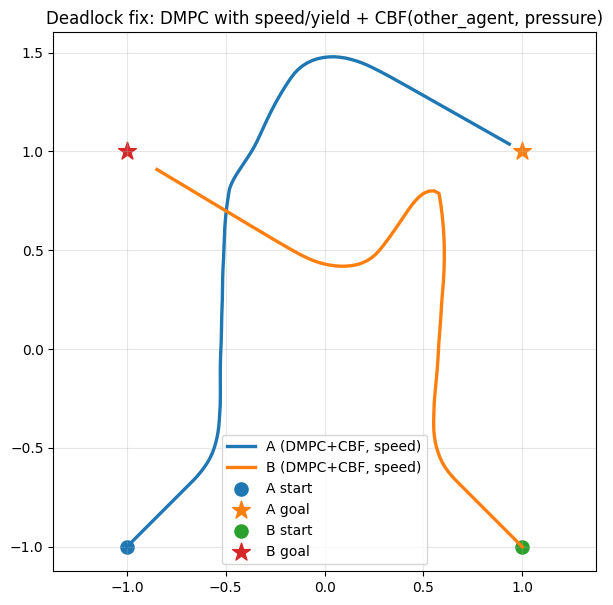

In [22]:
# ===============================================================
# NEW CELL: Fix deadlock (交汇不了/到不了终点)
#   - Add SPEED as a decision variable (yield / wait)
#   - Add a tiny asymmetry (priority) to break perfect symmetry
#   - Keep CBF(other_agent, pressure) for execution safety
# ===============================================================

import numpy as np
import matplotlib.pyplot as plt

# Requires helpers from previous DMPC cells
if "_wrap_pi" not in globals() or "_cbf_step_with_other" not in globals():
    raise RuntimeError("Please run the previous two-car MPC/DMPC cells first.")


def two_car_symmetric_dmpc_with_speed(
    xA0,
    gA,
    xB0,
    gB,
    *,
    dt=0.02,
    vA_max=1.4,
    vB_max=1.4,
    max_total_steps=700,
    goal_tol=0.18,
    H=10,
    heading_span_deg=140.0,
    heading_samples=25,
    speed_scales=(0.0, 0.4, 0.7, 1.0),
    d_safe=1.0,
    # CBF params
    agent_safe_radius=0.55,
    gamma_min=1.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    device="cpu",
    # costs
    w_goal=18.0,
    w_turn=0.10,
    w_dist_A=70.0,
    w_dist_B=110.0,   # B yields more (break symmetry)
    w_speed=0.6,      # penalize slow motion, but allow it
    heading_smooth=0.35,
    n_best_response_iters=1,
    fast_eval=True,
):
    """Symmetric DMPC that can YIELD (speed_scale=0) to avoid deadlock.

    Why deadlock happened before:
      - both agents had the same cost/constraints (perfect symmetry)
      - only heading was controllable (no slowing/yield)

    Fix:
      - include speed choices in MPC
      - slightly different distance weight (priority) to break symmetry
    """

    xA = np.asarray(xA0, dtype=np.float64).reshape(2).copy()
    xB = np.asarray(xB0, dtype=np.float64).reshape(2).copy()
    gA = np.asarray(gA, dtype=np.float64).reshape(2)
    gB = np.asarray(gB, dtype=np.float64).reshape(2)

    xsA = [xA.copy()]
    xsB = [xB.copy()]

    prev_hA = None
    prev_hB = None
    prev_sA = 1.0
    prev_sB = 1.0

    span = np.deg2rad(float(heading_span_deg))

    def hinge(z):
        return max(0.0, float(z))

    def predict_straight(x0, h, s, v_max, H):
        x = np.asarray(x0, dtype=np.float64).reshape(2).copy()
        traj = [x.copy()]
        v = float(v_max) * float(s)
        vvec = v * np.array([np.cos(h), np.sin(h)], dtype=np.float64)
        for _ in range(int(H)):
            x = x + float(dt) * vvec
            traj.append(x.copy())
        return np.asarray(traj, dtype=np.float64)

    def score_agent(x0, g, other_pred, *, h, s, v_max, w_dist, prev_h):
        x = np.asarray(x0, dtype=np.float64).reshape(2).copy()
        J = 0.0
        for k in range(int(H)):
            v = float(v_max) * float(s)
            v_nom = v * np.array([np.cos(h), np.sin(h)], dtype=np.float64)

            if fast_eval:
                x = x + float(dt) * v_nom
            else:
                v_safe = _cbf_step_with_other(
                    x_now=x,
                    v_nom=v_nom,
                    other_now=other_pred[k],
                    dt=float(dt),
                    device=str(device),
                    agent_safe_radius=float(agent_safe_radius),
                    gamma_min=float(gamma_min),
                    w_p=float(w_p),
                    press_k=float(press_k),
                    press_n=float(press_n),
                    max_corr_norm=float(max_corr_norm),
                )
                x = x + float(dt) * v_safe

            dist_k = float(np.linalg.norm(x - other_pred[k + 1]))
            viol = hinge(float(d_safe) - dist_k)
            J += float(w_dist) * (viol * viol)

        # terminal goal cost (stronger to avoid "stay on the side")
        J += float(w_goal) * float(np.sum((x - g) ** 2))

        # turning continuity
        if prev_h is not None:
            dphi = _wrap_pi(float(h) - float(prev_h))
            J += float(w_turn) * (dphi * dphi)

        # discourage always-yielding
        J += float(w_speed) * float((1.0 - float(s)) ** 2)

        return float(J)

    for step in range(int(max_total_steps)):
        if float(np.linalg.norm(xA - gA)) <= float(goal_tol) and float(np.linalg.norm(xB - gB)) <= float(goal_tol):
            break

        # initialize headings
        hA = float(np.arctan2((gA - xA)[1], (gA - xA)[0]))
        hB = float(np.arctan2((gB - xB)[1], (gB - xB)[0]))
        sA = float(prev_sA)
        sB = float(prev_sB)

        for _ in range(int(max(1, n_best_response_iters))):
            # Predict other straight (fast) using current (h,s)
            predA = predict_straight(xA, hA, sA, vA_max, H)
            predB = predict_straight(xB, hB, sB, vB_max, H)

            # Solve A best response
            baseA = float(np.arctan2((gA - xA)[1], (gA - xA)[0]))
            offsA = np.linspace(-span/2.0, span/2.0, int(heading_samples), dtype=np.float64)
            bestJA, bestHA, bestSA = float("inf"), baseA, 1.0
            for off in offsA:
                cand_h = float(baseA + off)
                for cand_s in speed_scales:
                    JA = score_agent(xA, gA, predB, h=cand_h, s=float(cand_s), v_max=vA_max, w_dist=w_dist_A, prev_h=prev_hA)
                    if JA < bestJA:
                        bestJA, bestHA, bestSA = JA, cand_h, float(cand_s)
            hA, sA = bestHA, bestSA

            # Solve B best response
            baseB = float(np.arctan2((gB - xB)[1], (gB - xB)[0]))
            offsB = np.linspace(-span/2.0, span/2.0, int(heading_samples), dtype=np.float64)
            bestJB, bestHB, bestSB = float("inf"), baseB, 1.0
            for off in offsB:
                cand_h = float(baseB + off)
                for cand_s in speed_scales:
                    JB = score_agent(xB, gB, predA, h=cand_h, s=float(cand_s), v_max=vB_max, w_dist=w_dist_B, prev_h=prev_hB)
                    if JB < bestJB:
                        bestJB, bestHB, bestSB = JB, cand_h, float(cand_s)
            hB, sB = bestHB, bestSB

        # execute one step with smoothing
        if prev_hA is None:
            exec_hA = hA
        else:
            a = float(np.clip(heading_smooth, 0.0, 1.0))
            exec_hA = _wrap_pi(prev_hA + a * _wrap_pi(hA - prev_hA))

        if prev_hB is None:
            exec_hB = hB
        else:
            a = float(np.clip(heading_smooth, 0.0, 1.0))
            exec_hB = _wrap_pi(prev_hB + a * _wrap_pi(hB - prev_hB))

        exec_sA = float(sA)
        exec_sB = float(sB)

        vA_nom = float(vA_max) * exec_sA * np.array([np.cos(exec_hA), np.sin(exec_hA)], dtype=np.float64)
        vB_nom = float(vB_max) * exec_sB * np.array([np.cos(exec_hB), np.sin(exec_hB)], dtype=np.float64)

        vA_safe = _cbf_step_with_other(
            x_now=xA,
            v_nom=vA_nom,
            other_now=xB,
            dt=float(dt),
            device=str(device),
            agent_safe_radius=float(agent_safe_radius),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
            max_corr_norm=float(max_corr_norm),
        )
        vB_safe = _cbf_step_with_other(
            x_now=xB,
            v_nom=vB_nom,
            other_now=xA,
            dt=float(dt),
            device=str(device),
            agent_safe_radius=float(agent_safe_radius),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
            max_corr_norm=float(max_corr_norm),
        )

        xA = xA + float(dt) * vA_safe
        xB = xB + float(dt) * vB_safe
        xsA.append(xA.copy())
        xsB.append(xB.copy())

        prev_hA, prev_hB = exec_hA, exec_hB
        prev_sA, prev_sB = exec_sA, exec_sB

        if step % 50 == 0:
            dAB = float(np.linalg.norm(xA - xB))
            print(f"[step {step:04d}] dAB={dAB:.3f}  sA={exec_sA:.2f} sB={exec_sB:.2f}  |dA|={np.linalg.norm(xA-gA):.3f} |dB|={np.linalg.norm(xB-gB):.3f}")

    return np.asarray(xsA, dtype=np.float64), np.asarray(xsB, dtype=np.float64)


# -------------------------
# Scenario
# -------------------------
xA0 = np.array([-1.0, -1.0], dtype=np.float64)
gA  = np.array([+1.0, +1.0], dtype=np.float64)
xB0 = np.array([+1.0, -1.0], dtype=np.float64)
gB  = np.array([-1.0, +1.0], dtype=np.float64)

xsA_fix, xsB_fix = two_car_symmetric_dmpc_with_speed(
    xA0, gA, xB0, gB,
    dt=0.02,
    vA_max=1.4,
    vB_max=1.4,
    max_total_steps=900,
    H=10,
    heading_samples=25,
    speed_scales=(0.0, 0.4, 0.7, 1.0),
    d_safe=1.0,
    w_goal=18.0,
    w_turn=0.10,
    w_dist_A=70.0,
    w_dist_B=110.0,
    w_speed=0.6,
    heading_smooth=0.35,
    n_best_response_iters=1,
    fast_eval=True,
)

plt.figure(figsize=(7, 7))
plt.plot(xsA_fix[:, 0], xsA_fix[:, 1], "-", linewidth=2.4, label="A (DMPC+CBF, speed)")
plt.plot(xsB_fix[:, 0], xsB_fix[:, 1], "-", linewidth=2.4, label="B (DMPC+CBF, speed)")
plt.scatter([xsA_fix[0, 0]], [xsA_fix[0, 1]], s=90, label="A start")
plt.scatter([gA[0]], [gA[1]], s=180, marker="*", label="A goal")
plt.scatter([xsB_fix[0, 0]], [xsB_fix[0, 1]], s=90, label="B start")
plt.scatter([gB[0]], [gB[1]], s=180, marker="*", label="B goal")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("Deadlock fix: DMPC with speed/yield + CBF(other_agent, pressure)")
plt.legend()
plt.show()



[step 0000] overlap=False  sA=1.00 sB=1.00  |dA|=2.800 |dB|=2.800
[step 0060] overlap=False  sA=1.00 sB=1.00  |dA|=1.579 |dB|=1.670
[step 0120] overlap=False  sA=1.00 sB=1.00  |dA|=0.568 |dB|=0.729


NameError: name 'car_L' is not defined

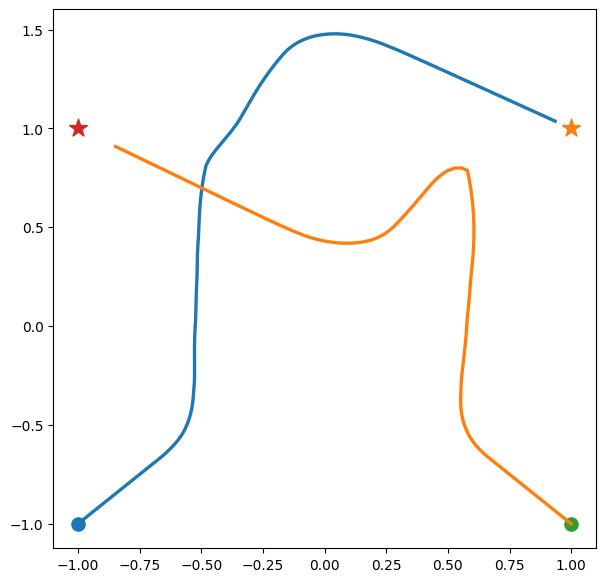

In [ ]:
# ===============================================================
# NEW CELL: Rectangle car footprint (oriented boxes) + DMPC + CBF
#
# - Treat each car as an oriented rectangle (center=(x,y), heading=theta).
# - In the MPC horizon, enforce rectangle-rectangle non-overlap via SAT (hard reject / huge penalty).
# - Execution step still uses your CBF(other_agent, pressure) on centers (fast safety shield).
#
# This is a practical RT-MPC trick for "tight spaces":
#   planning uses a stronger geometric collision model; execution uses a fast safety filter.
# ===============================================================

import numpy as np
import matplotlib.pyplot as plt

if "_wrap_pi" not in globals() or "_cbf_step_with_other" not in globals():
    raise RuntimeError("Please run the previous two-car MPC/DMPC cells first.")


def rect_corners(center_xy, theta, length, width):
    """Return 4 corners (4,2) of an oriented rectangle."""
    c = np.asarray(center_xy, dtype=np.float64).reshape(2)
    th = float(theta)

    hl = 0.5 * float(length)
    hw = 0.5 * float(width)

    # local corners (front/back, left/right)
    local = np.array([
        [+hl, +hw],
        [+hl, -hw],
        [-hl, -hw],
        [-hl, +hw],
    ], dtype=np.float64)

    ct, st = np.cos(th), np.sin(th)
    R = np.array([[ct, -st], [st, ct]], dtype=np.float64)
    world = local @ R.T + c[None, :]
    return world


def _proj_interval(poly_xy, axis):
    """Project polygon vertices onto axis, return (min,max)."""
    p = poly_xy @ axis
    return float(p.min()), float(p.max())


def sat_rect_overlap(c1, th1, L1, W1, c2, th2, L2, W2, margin=0.0):
    """Separating Axis Theorem for two oriented rectangles.

    Returns True if rectangles overlap (with optional inflation margin).
    We implement margin by inflating both rectangles' half-extents.
    """
    L1m, W1m = float(L1) + 2.0 * float(margin), float(W1) + 2.0 * float(margin)
    L2m, W2m = float(L2) + 2.0 * float(margin), float(W2) + 2.0 * float(margin)

    r1 = rect_corners(c1, th1, L1m, W1m)
    r2 = rect_corners(c2, th2, L2m, W2m)

    # axes = normals of edges (2 unique per rectangle)
    def axes_from_rect(r):
        e0 = r[1] - r[0]
        e1 = r[3] - r[0]
        # normals (no need to normalize perfectly, but helps numerics)
        a0 = np.array([ -e0[1], e0[0] ], dtype=np.float64)
        a1 = np.array([ -e1[1], e1[0] ], dtype=np.float64)
        # normalize
        a0 = a0 / (np.linalg.norm(a0) + 1e-12)
        a1 = a1 / (np.linalg.norm(a1) + 1e-12)
        return [a0, a1]

    axes = axes_from_rect(r1) + axes_from_rect(r2)

    for ax in axes:
        a_min, a_max = _proj_interval(r1, ax)
        b_min, b_max = _proj_interval(r2, ax)
        # gap => separated => no overlap
        if a_max < b_min or b_max < a_min:
            return False
    return True


def dmpc_rect_two_car_with_speed(
    xA0, gA,
    xB0, gB,
    *,
    dt=0.02,
    vA_max=1.4,
    vB_max=1.4,
    max_total_steps=800,
    goal_tol=0.18,
    H=10,
    heading_span_deg=140.0,
    heading_samples=25,
    speed_scales=(0.0, 0.4, 0.7, 1.0),
    # rectangle geometry
    car_L=0.60,
    car_W=0.32,
    rect_margin=0.05,   # inflate rectangles for safety
    # distance preference (center)
    d_safe=1.0,
    # CBF params
    agent_safe_radius=0.55,
    gamma_min=1.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    device="cpu",
    # costs
    w_goal=18.0,
    w_turn=0.10,
    w_dist_A=70.0,
    w_dist_B=110.0,
    w_speed=0.6,
    w_rect=1e6,         # huge penalty for any overlap in horizon
    heading_smooth=0.35,
    n_best_response_iters=1,
    fast_eval=True,
):
    """Two-car DMPC with rectangle footprint collision checking.

    State here is (x,y,theta). We approximate theta as the commanded heading.
    """
    xA = np.asarray(xA0, dtype=np.float64).reshape(2).copy()
    xB = np.asarray(xB0, dtype=np.float64).reshape(2).copy()
    gA = np.asarray(gA, dtype=np.float64).reshape(2)
    gB = np.asarray(gB, dtype=np.float64).reshape(2)

    xsA = [xA.copy()]
    xsB = [xB.copy()]
    thA_hist = []
    thB_hist = []

    prev_hA = None
    prev_hB = None
    prev_sA = 1.0
    prev_sB = 1.0

    span = np.deg2rad(float(heading_span_deg))

    def hinge(z):
        return max(0.0, float(z))

    def predict_straight(center0, h, s, v_max):
        c = np.asarray(center0, dtype=np.float64).reshape(2).copy()
        traj = [c.copy()]
        v = float(v_max) * float(s)
        vvec = v * np.array([np.cos(h), np.sin(h)], dtype=np.float64)
        for _ in range(int(H)):
            c = c + float(dt) * vvec
            traj.append(c.copy())
        return np.asarray(traj, dtype=np.float64)  # (H+1,2)

    def score_agent(center0, goal, other_traj, *, h, s, v_max, w_dist, prev_h, other_heading):
        c = np.asarray(center0, dtype=np.float64).reshape(2).copy()
        J = 0.0

        for k in range(int(H)):
            v = float(v_max) * float(s)
            v_nom = v * np.array([np.cos(h), np.sin(h)], dtype=np.float64)

            # fast_eval: straight kinematics
            c = c + float(dt) * v_nom

            # 1) rectangle overlap check at step k+1
            #    ego heading = h, other heading = other_heading
            if sat_rect_overlap(
                c1=c, th1=h, L1=car_L, W1=car_W,
                c2=other_traj[k + 1], th2=other_heading, L2=car_L, W2=car_W,
                margin=float(rect_margin),
            ):
                J += float(w_rect)

            # 2) center distance soft constraint
            dist_k = float(np.linalg.norm(c - other_traj[k + 1]))
            viol = hinge(float(d_safe) - dist_k)
            J += float(w_dist) * (viol * viol)

        # goal cost
        J += float(w_goal) * float(np.sum((c - goal) ** 2))

        if prev_h is not None:
            dphi = _wrap_pi(float(h) - float(prev_h))
            J += float(w_turn) * (dphi * dphi)

        J += float(w_speed) * float((1.0 - float(s)) ** 2)

        return float(J)

    for step in range(int(max_total_steps)):
        if float(np.linalg.norm(xA - gA)) <= float(goal_tol) and float(np.linalg.norm(xB - gB)) <= float(goal_tol):
            break

        # init
        hA = float(np.arctan2((gA - xA)[1], (gA - xA)[0]))
        hB = float(np.arctan2((gB - xB)[1], (gB - xB)[0]))
        sA = float(prev_sA)
        sB = float(prev_sB)

        for _ in range(int(max(1, n_best_response_iters))):
            predA = predict_straight(xA, hA, sA, vA_max)
            predB = predict_straight(xB, hB, sB, vB_max)

            # A best response (assume other heading = hB during horizon)
            baseA = float(np.arctan2((gA - xA)[1], (gA - xA)[0]))
            offsA = np.linspace(-span/2.0, span/2.0, int(heading_samples), dtype=np.float64)
            bestJA, bestHA, bestSA = float("inf"), baseA, 1.0
            for off in offsA:
                cand_h = float(baseA + off)
                for cand_s in speed_scales:
                    JA = score_agent(
                        xA, gA, predB,
                        h=cand_h, s=float(cand_s), v_max=vA_max,
                        w_dist=w_dist_A, prev_h=prev_hA,
                        other_heading=hB,
                    )
                    if JA < bestJA:
                        bestJA, bestHA, bestSA = JA, cand_h, float(cand_s)
            hA, sA = bestHA, bestSA

            # B best response (assume other heading = hA during horizon)
            baseB = float(np.arctan2((gB - xB)[1], (gB - xB)[0]))
            offsB = np.linspace(-span/2.0, span/2.0, int(heading_samples), dtype=np.float64)
            bestJB, bestHB, bestSB = float("inf"), baseB, 1.0
            for off in offsB:
                cand_h = float(baseB + off)
                for cand_s in speed_scales:
                    JB = score_agent(
                        xB, gB, predA,
                        h=cand_h, s=float(cand_s), v_max=vB_max,
                        w_dist=w_dist_B, prev_h=prev_hB,
                        other_heading=hA,
                    )
                    if JB < bestJB:
                        bestJB, bestHB, bestSB = JB, cand_h, float(cand_s)
            hB, sB = bestHB, bestSB

        # execute one step with heading smoothing
        if prev_hA is None:
            exec_hA = hA
        else:
            a = float(np.clip(heading_smooth, 0.0, 1.0))
            exec_hA = _wrap_pi(prev_hA + a * _wrap_pi(hA - prev_hA))

        if prev_hB is None:
            exec_hB = hB
        else:
            a = float(np.clip(heading_smooth, 0.0, 1.0))
            exec_hB = _wrap_pi(prev_hB + a * _wrap_pi(hB - prev_hB))

        exec_sA = float(sA)
        exec_sB = float(sB)

        vA_nom = float(vA_max) * exec_sA * np.array([np.cos(exec_hA), np.sin(exec_hA)], dtype=np.float64)
        vB_nom = float(vB_max) * exec_sB * np.array([np.cos(exec_hB), np.sin(exec_hB)], dtype=np.float64)

        # CBF safety on centers
        vA_safe = _cbf_step_with_other(
            x_now=xA,
            v_nom=vA_nom,
            other_now=xB,
            dt=float(dt),
            device=str(device),
            agent_safe_radius=float(agent_safe_radius),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
            max_corr_norm=float(max_corr_norm),
        )
        vB_safe = _cbf_step_with_other(
            x_now=xB,
            v_nom=vB_nom,
            other_now=xA,
            dt=float(dt),
            device=str(device),
            agent_safe_radius=float(agent_safe_radius),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
            max_corr_norm=float(max_corr_norm),
        )

        xA = xA + float(dt) * vA_safe
        xB = xB + float(dt) * vB_safe

        xsA.append(xA.copy())
        xsB.append(xB.copy())
        thA_hist.append(exec_hA)
        thB_hist.append(exec_hB)

        prev_hA, prev_hB = exec_hA, exec_hB
        prev_sA, prev_sB = exec_sA, exec_sB

        if step % 60 == 0:
            overlap_now = sat_rect_overlap(xA, exec_hA, car_L, car_W, xB, exec_hB, car_L, car_W, margin=rect_margin)
            print(f"[step {step:04d}] overlap={overlap_now}  sA={exec_sA:.2f} sB={exec_sB:.2f}  |dA|={np.linalg.norm(xA-gA):.3f} |dB|={np.linalg.norm(xB-gB):.3f}")

    # include headings so rectangle visualization can be exact
    thA = np.asarray(thA_hist, dtype=np.float64)
    thB = np.asarray(thB_hist, dtype=np.float64)
    return np.asarray(xsA, dtype=np.float64), np.asarray(xsB, dtype=np.float64), thA, thB


# -------------------------
# Scenario
# -------------------------
xA0 = np.array([-1.0, -1.0], dtype=np.float64)
gA  = np.array([+1.0, +1.0], dtype=np.float64)
xB0 = np.array([+1.0, -1.0], dtype=np.float64)
gB  = np.array([-1.0, +1.0], dtype=np.float64)

xsA_rect, xsB_rect, thA_rect, thB_rect = dmpc_rect_two_car_with_speed(
    xA0, gA, xB0, gB,
    dt=0.02,
    vA_max=1.4,
    vB_max=1.4,
    H=10,
    heading_samples=25,
    speed_scales=(0.0, 0.4, 0.7, 1.0),
    car_L=0.60,
    car_W=0.32,
    rect_margin=0.06,
    d_safe=1.0,
    w_goal=18.0,
    w_dist_A=70.0,
    w_dist_B=110.0,
    w_rect=1e6,
    heading_smooth=0.35,
    fast_eval=True,
)

# plot centers + draw rectangle footprints
from matplotlib.patches import Polygon

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(xsA_rect[:, 0], xsA_rect[:, 1], "-", linewidth=2.4, label="A center")
ax.plot(xsB_rect[:, 0], xsB_rect[:, 1], "-", linewidth=2.4, label="B center")
ax.scatter([xsA_rect[0, 0]], [xsA_rect[0, 1]], s=90, label="A start")
ax.scatter([gA[0]], [gA[1]], s=180, marker="*", label="A goal")
ax.scatter([xsB_rect[0, 0]], [xsB_rect[0, 1]], s=90, label="B start")
ax.scatter([gB[0]], [gB[1]], s=180, marker="*", label="B goal")


def _draw_rect(ax, center, theta, L, W, *, edgecolor, facecolor, alpha=0.12, lw=1.5):
    corners = rect_corners(center, theta, L, W)  # (4,2)
    poly = Polygon(corners, closed=True, edgecolor=edgecolor, facecolor=facecolor, alpha=alpha, lw=lw)
    ax.add_patch(poly)

# If you want denser rectangles, decrease this number
DRAW_EVERY = 60
idxs = list(range(0, len(xsA_rect), int(DRAW_EVERY)))
if (len(xsA_rect) - 1) not in idxs:
    idxs.append(len(xsA_rect) - 1)

# thA_rect/thB_rect are recorded for executed steps 0..T-2 (because they are applied each step)
# Align them to center arrays length by clamping index.
for i in idxs:
    ia = min(int(i), len(thA_rect) - 1)
    ib = min(int(i), len(thB_rect) - 1)
    _draw_rect(ax, xsA_rect[i], thA_rect[ia], car_L, car_W, edgecolor="C0", facecolor="C0", alpha=0.10, lw=1.3)
    _draw_rect(ax, xsB_rect[i], thB_rect[ib], car_L, car_W, edgecolor="C1", facecolor="C1", alpha=0.10, lw=1.3)

ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.set_title("Rectangle cars (SAT) + DMPC(speed/yield) + CBF(center)\n(rectangles shown every %d steps)" % int(DRAW_EVERY))
ax.legend()
plt.show()



[step 000] dist=2.500 v=0.313 rej=00/30 fb=N u=[+0.631,-1.529]
[step 001] dist=2.483 v=0.378 rej=00/30 fb=N u=[+0.654,-1.806]
[step 002] dist=2.461 v=0.449 rej=00/30 fb=N u=[+0.702,-1.484]
[step 003] dist=2.435 v=0.505 rej=00/30 fb=N u=[+0.562,-0.530]
[step 004] dist=2.404 v=0.561 rej=00/30 fb=N u=[+0.560,+0.314]
[step 010] dist=2.110 v=0.935 rej=00/30 fb=N u=[+0.628,-0.268]
[step 020] dist=1.138 v=0.942 rej=00/30 fb=N u=[-0.788,+0.345]
[step 030] dist=0.446 v=0.351 rej=00/30 fb=N u=[-0.469,-0.009]
[step 040] dist=0.159 v=0.250 rej=00/30 fb=N u=[-0.036,+0.143]
Done. steps=41, fallback_count=0, total_reject=0


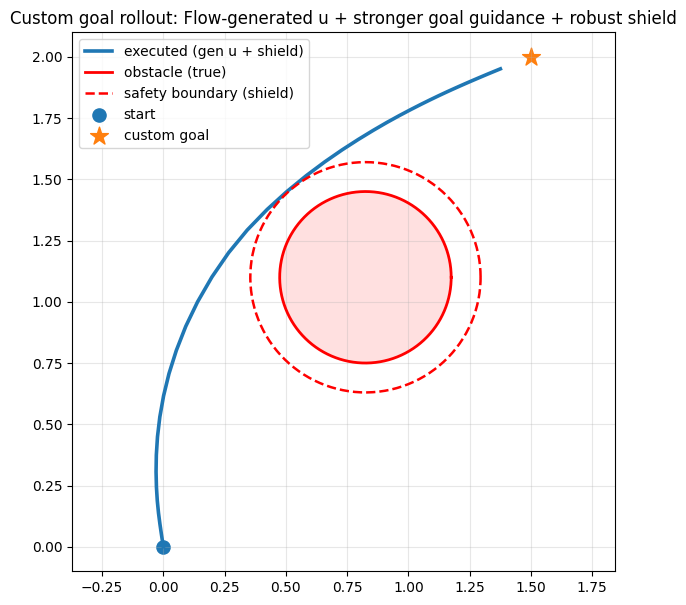

In [ ]:
# ===============================================================
# Cell (fixed): Custom goal + receding-horizon u sampling + shield + bicycle rollout
#   - model_u generates u_seq ~ p(u_seq | cond)
#   - execute only u0 each step
#   - external goal guidance
#   - obstacle safety: resample u0 until safe; fallback = "keep moving + turn away"
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt


def circle_h(xy, c, R):
    d = np.asarray(xy, dtype=np.float64) - np.asarray(c, dtype=np.float64)
    return float(d @ d - R * R)


@torch.no_grad()
# 用你训练好的 flow matching UNet，
# 从噪声中“生成一整段控制序列 但在 receding-horizon 控制里 只执行第一个控制 u0


def sample_u0_from_model(model_u, cond_vec, ctrl_T, n_steps=40, device="cpu", noise_scale=1.0):
    """Sample a whole u_seq, return first control u0=[a,delta_rate]."""
    dev = torch.device(device)
    cond = torch.as_tensor(cond_vec, dtype=torch.float32, device=dev).view(1, -1)

    x = torch.randn(1, 2, int(ctrl_T), device=dev) * float(noise_scale)
    t_grid = torch.linspace(0.0, 1.0, int(n_steps) + 1, device=dev)

    for i in range(int(n_steps)):
        t = t_grid[i].view(1)
        v = model_u(x, t, cond=cond)

        # align length if cropped
        if v.shape[-1] != x.shape[-1]:
            Lmin = min(v.shape[-1], x.shape[-1])
            v = v[..., :Lmin]
            x = x[..., :Lmin]

        dt_local = float(t_grid[i+1] - t_grid[i])
        x = x + dt_local * v

    u_seq = x[0].detach().cpu().numpy().astype(np.float64)  # (2, ctrl_T)
    u0 = u_seq[:, 0].copy()
    return u0


def rollout_custom_goal_with_shield(
    *,
    model_u,
    init_state5,           # [x,y,theta,v,delta]
    goal_xy,               # custom goal
    obstacle_center,       # circle center
    obstacle_radius,       # true obstacle R
    safety_margin=0.12,    # safety inflation
    ctrl_T=59,
    dt=0.1,
    L=0.8,
    delta_max=np.deg2rad(30.0),
    a_max=0.8,
    delta_rate_max=np.deg2rad(120.0),
    max_steps=160,
    goal_tol=0.15,
    # sampling
    n_steps_sample=50,
    resample_tries=25,
    noise_scale=1.0,
    # goal guidance
    k_goal_steer=2.2,
    k_goal_speed=0.8,
    # stability
    v_floor=0.25,          # ✅ 防止速度塌陷（关键）
    # blend
    mix_guidance=0.85,     # ✅ guidance 权重大（关键）
    device="cpu",
    debug_every=10,
):
    goal_xy = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    c = np.asarray(obstacle_center, dtype=np.float64).reshape(2)
    R_safe = float(obstacle_radius) + float(safety_margin)

    state = np.asarray(init_state5, dtype=np.float64).copy()
    # ✅ 确保初始速度不为 0，否则一开始就容易卡
    state[3] = max(float(state[3]), float(v_floor))

    xs = [state[:2].copy()]
    fallback_count = 0
    total_reject = 0

    for step in range(int(max_steps)):
        dist = float(np.linalg.norm(state[:2] - goal_xy))
        if dist <= float(goal_tol):
            break

        cond_vec = state[:5].copy()

        # -------- goal guidance (external) --------
        vec = goal_xy - state[:2]
        th_goal = float(np.arctan2(vec[1], vec[0]))
        e_th = float((th_goal - state[2] + np.pi) % (2*np.pi) - np.pi)

        v_eff = max(float(v_floor), float(state[3]))
        omega_des = float(k_goal_steer) * e_th
        delta_des = float(np.arctan2(omega_des * float(L), v_eff))
        delta_des = float(np.clip(delta_des, -float(delta_max), float(delta_max)))

        delta_rate_g = (delta_des - float(state[4])) / float(dt)
        delta_rate_g = float(np.clip(delta_rate_g, -float(delta_rate_max), float(delta_rate_max)))

        v_des = float(np.clip(float(k_goal_speed) * dist, float(v_floor), 1.2))
        a_g = (v_des - float(state[3])) / float(dt)
        a_g = float(np.clip(a_g, -float(a_max), float(a_max)))

        u_guidance = np.array([a_g, delta_rate_g], dtype=np.float64)

        # -------- rejection shield w/ adaptive noise --------
        u_safe = None
        local_reject = 0

        for j in range(int(resample_tries)):
            # ✅ 越失败，噪声越大（更容易跳出坏模式）
            ns = float(noise_scale) * (1.0 + 0.08 * j)

            u0 = sample_u0_from_model(
                model_u, cond_vec, ctrl_T=ctrl_T,
                n_steps=n_steps_sample, device=device, noise_scale=ns
            )

            # clip model output
            u0[0] = float(np.clip(u0[0], -a_max, a_max))
            u0[1] = float(np.clip(u0[1], -delta_rate_max, delta_rate_max))

            # ✅ 更强 guidance 混合（核心改动）
            mix = float(np.clip(mix_guidance, 0.0, 1.0))
            u0 = (1.0 - mix) * u0 + mix * u_guidance

            u0_clip = np.array([
                float(np.clip(u0[0], -a_max, a_max)),
                float(np.clip(u0[1], -delta_rate_max, delta_rate_max)),
            ], dtype=np.float64)

            nxt = _step_bicycle_simple(state, u0_clip, dt=float(dt), L=float(L), delta_max=float(delta_max))

            if circle_h(nxt[:2], c, R_safe) >= 0.0:
                u_safe = u0_clip
                break
            else:
                local_reject += 1

        total_reject += local_reject

        if u_safe is None:
            # ✅ fallback 不要“刹死”，否则 v 会掉到 0 然后再也动不了
            # 策略：轻刹/保持 + 朝 goal 转向（甚至稍微偏转绕开）
            fallback_count += 1

            a_fb = float(np.clip(-0.2 * a_max, -a_max, a_max))  # 轻刹
            # turn harder towards goal when stuck
            delta_rate_fb = float(np.clip(1.0 * delta_rate_g, -delta_rate_max, delta_rate_max))

            u_safe = np.array([a_fb, delta_rate_fb], dtype=np.float64)

        # execute
        state = _step_bicycle_simple(state, u_safe, dt=float(dt), L=float(L), delta_max=float(delta_max))

        # ✅ 再次防止速度塌陷
        state[3] = max(float(state[3]), float(v_floor))

        xs.append(state[:2].copy())

        if (debug_every is not None) and (step % int(debug_every) == 0 or step < 5):
            print(f"[step {step:03d}] dist={dist:.3f} v={state[3]:.3f} "
                  f"rej={local_reject:02d}/{resample_tries} fb={'Y' if local_reject==resample_tries else 'N'} "
                  f"u=[{u_safe[0]:+.3f},{u_safe[1]:+.3f}]")

    print(f"Done. steps={len(xs)-1}, fallback_count={fallback_count}, total_reject={total_reject}")
    return np.asarray(xs, dtype=np.float64), R_safe


# ------------------ RUN DEMO ------------------
idx = 0
s0 = states_np[idx, 0].astype(np.float64)   # [x,y,theta,v,delta]

goal_xy = np.array([1.5, 2.0], dtype=np.float64)

# obstacle between start and goal
start_xy = s0[:2]
mid = start_xy + 0.55 * (goal_xy - start_xy)
obstacle_center = (float(mid[0]), float(mid[1]))

R_obs = 0.35
margin = 0.12

xs, R_safe = rollout_custom_goal_with_shield(
    model_u=model_u,
    init_state5=s0,
    goal_xy=goal_xy,
    obstacle_center=obstacle_center,
    obstacle_radius=R_obs,
    safety_margin=margin,
    ctrl_T=CTRL_T,
    dt=float(data["params"]["dt"]),
    L=float(data["params"]["L"]),
    delta_max=float(data["params"]["delta_max"]),
    a_max=float(data["params"]["a_max"]),
    delta_rate_max=float(data["params"]["delta_rate_max"]),
    max_steps=220,
    goal_tol=0.15,
    n_steps_sample=60,
    resample_tries=30,
    noise_scale=1.0,
    mix_guidance=0.85,   # ✅ 强 guidance
    v_floor=0.25,        # ✅ 防止卡死
    device=device,
    debug_every=10,
)

# plot
t = np.linspace(0, 2*np.pi, 360)
plt.figure(figsize=(7,7))
plt.plot(xs[:,0], xs[:,1], "-", linewidth=2.6, label="executed (gen u + shield)")

c = np.asarray(obstacle_center, dtype=np.float64)
plt.plot(c[0] + R_obs*np.cos(t), c[1] + R_obs*np.sin(t), "r-", linewidth=2.0, label="obstacle (true)")
plt.fill(c[0] + R_obs*np.cos(t), c[1] + R_obs*np.sin(t), color="red", alpha=0.12)
plt.plot(c[0] + R_safe*np.cos(t), c[1] + R_safe*np.sin(t), "r--", linewidth=1.8, label="safety boundary (shield)")

plt.scatter([xs[0,0]], [xs[0,1]], s=90, label="start")
plt.scatter([goal_xy[0]], [goal_xy[1]], s=180, marker="*", label="custom goal")

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("Custom goal rollout: Flow-generated u + stronger goal guidance + robust shield")
plt.legend()
plt.show()


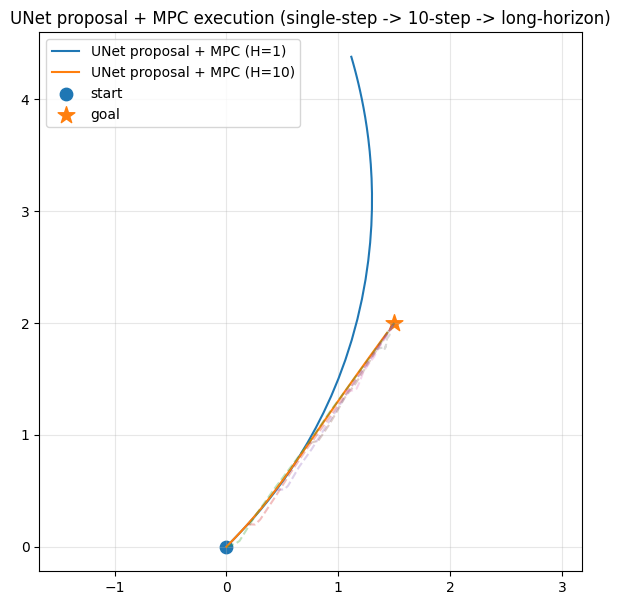

In [ ]:
# =========================
# UNet proposal policy + MPC execution (single-step -> 10-step -> long-horizon)
#
# Idea (as your advisor suggested):
#   - Use the trained UNet (stage-1) to PROPOSE a short reference (H steps) from current state.
#   - Use MPC to EXECUTE one feasible/smooth step toward that proposal (and still respect goal).
#   - Repeat (receding horizon) to get long-horizon rollout.
#
# This cell only adds new code. It does NOT change your training dataset.
# =========================

import numpy as np
import inspect
import torch
import torch.nn as nn

#UNet 生成的轨迹长度可能是 UNET_T（比如 50/100），但你每一步只想用 H+1（比如 2 或 11） 个点作为短期参考
#把一条二维轨迹（折线）按“时间比例”重新采样成指定长度
def _resample_polyline_xy(xy_T2: np.ndarray, out_len: int) -> np.ndarray:
    """Resample a (T,2) polyline to length out_len using linear interpolation in normalized time."""
    xy_T2 = np.asarray(xy_T2, dtype=np.float64)
    T = xy_T2.shape[0]
    if T == out_len:
        return xy_T2
    t_in = np.linspace(0.0, 1.0, T)
    t_out = np.linspace(0.0, 1.0, out_len)
    x_out = np.interp(t_out, t_in, xy_T2[:, 0])
    y_out = np.interp(t_out, t_in, xy_T2[:, 1])
    return np.stack([x_out, y_out], axis=1)


#把一条参考轨迹的后半段“逐渐拉向 goal”，并强制最后一个点等于 goal
def blend_to_goal_simple(ref_xy: np.ndarray, goal_xy: np.ndarray, start_frac: float = 0.3, strength: float = 0.95) -> np.ndarray:
    """Blend a reference path toward a goal (softly) from some fraction onward."""
    ref = np.asarray(ref_xy, dtype=np.float64) #原始参考轨迹
    goal = np.asarray(goal_xy, dtype=np.float64).reshape(2) #目标点

    T = ref.shape[0]
    k0 = int(np.clip(start_frac, 0.0, 1.0) * (T - 1))  #计算起始索引从k0开始 做凸组合的线性插值

    out = ref.copy()
    for k in range(k0, T):
        alpha = strength * float(k - k0) / max(1, (T - 1 - k0))
        alpha = float(np.clip(alpha, 0.0, strength))
        out[k] = (1.0 - alpha) * out[k] + alpha * goal

    # force last point closer to goal
    out[-1] = goal
    return out

#生成短期参考轨迹
def unet_propose_ref_single_or_k_step(
    state4_or_5: np.ndarray, #当前车辆状态
    goal_xy: np.ndarray, #保证末端朝goal收敛
    *,
    H: int = 1,
    device: str = None,
    n_ode_steps: int = 30,
    blend_strength: float = 0.95,
    blend_start_frac: float = 0.2,
) -> np.ndarray:
    """Use the trained UNet to propose a short reference of length (H+1) in WORLD frame.

    Requirements in globals:
      - model: trained UNet-like model
      - sample_traj_from_theta(theta, ...) returning traj as (2,T)

    The UNet in this notebook is angle-conditioned by (cosθ, sinθ). We use current theta.
    """
    def _find_stage1_unet_from_globals():
        # common names first
        for name in (
            "model",
            "model_stage1",
            "stage1_model",
            "unet",
            "unet_model",
            "net",
        ):
            v = globals().get(name, None)
            if isinstance(v, nn.Module):
                return v

        # then search any nn.Module whose class name hints it's a UNet
        for k, v in globals().items():
            if isinstance(v, nn.Module):
                cname = v.__class__.__name__.lower()
                if "simpleunet1d" in cname or ("unet" in cname and "encoder" not in cname):
                    return v

        raise RuntimeError(
            "Stage-1 UNet model not found in globals. "
            "Please run the SimpleUNet1D training cell (the one that creates the model instance)."
        )
    #欧拉采样 一步步把Flow matching网络训练得到的速度一步一步推理得到现有的轨迹
    def _sample_traj_from_theta_fallback(model_stage1, theta, T_traj, n_steps, device):
        """Fallback Euler sampler for the stage-1 flow model. Returns (2,T)."""
        model_stage1.eval()
        dev = torch.device(device)
        cond = torch.tensor([[np.cos(theta), np.sin(theta)]], dtype=torch.float32, device=dev)
        x = torch.randn(1, 2, int(T_traj), device=dev) * 0.1
        t_vals = torch.linspace(0.0, 1.0, int(n_steps) + 1, device=dev)

        for i in range(int(n_steps)):
            t = t_vals[i].view(1)
            try:
                v = model_stage1(x, t, cond=cond)
            except TypeError:
                v = model_stage1(x, t, cond)
            dt_local = float(t_vals[i + 1] - t_vals[i])
            x = x + dt_local * v #主要的欧拉推理部分

        traj = x[0].detach().cpu().numpy()  # (2,T)
        return traj

    model_stage1 = _find_stage1_unet_from_globals()
    sampler = globals().get("sample_traj_from_theta", None)

    s = np.asarray(state4_or_5, dtype=np.float64)
    x, y, theta = float(s[0]), float(s[1]), float(s[2])

    # choose a sampling length: use UNET_T if exists, else fallback to something safe
    T_traj = int(globals().get("UNET_T", max(50, H + 1)))

    # device fallback
    if device is None:
        device = globals().get("device", "cpu")

    # sample proposal trajectory
    if sampler is None:
        traj_2T = _sample_traj_from_theta_fallback(
            model_stage1,
            theta=float(theta),
            T_traj=T_traj,
            n_steps=int(n_ode_steps),
            device=str(device),
        )
    else:
        # support both sampler(model=..., ...) and sampler(model, ...)
        try:
            traj_2T = sampler(
                model=model_stage1,
                theta=float(theta),
                T_traj=T_traj,
                n_steps=int(n_ode_steps),
                device=str(device),
            )
        except TypeError:
            traj_2T = sampler(
                model_stage1,
                theta=float(theta),
                T_traj=T_traj,
                n_steps=int(n_ode_steps),
                device=str(device),
            )
    # (2,T)

    ref = np.asarray(traj_2T, dtype=np.float64).T  # (T,2)

    # translate to current position (treat UNet output as in world frame with origin at 0)
    ref = ref - ref[0:1] + np.array([x, y], dtype=np.float64)

    # blend to goal and resample to H+1
    ref = blend_to_goal_simple(ref, goal_xy, start_frac=float(blend_start_frac), strength=float(blend_strength))
    ref_h = _resample_polyline_xy(ref, out_len=int(H) + 1)
    return ref_h #MPC 每一步要跟踪的短期参考轨迹


# Export a stable alias to this UNet-based proposer (so later overrides can call it safely).
unet_propose_ref_unet_impl = unet_propose_ref_single_or_k_step



def mpc_one_step_track_ref(
    state5: np.ndarray,
    ref_xy: np.ndarray,
    goal_xy: np.ndarray,
    *,
    dt: float,
    L: float,
    delta_max: float,
    a_max: float,
    delta_rate_max: float,
    horizon: int,
    u_last_applied: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray]: 
    """Solve ONE MPC step to track ref_xy (len = horizon+1) and return (next_state5, u0)."""
    # IMPORTANT:
    # - Use ref length as the true MPC horizon (lets H=1 still pass a longer straight-line ref).
    # - Pass u_last_applied so the Δu penalty is relative to the *real* previous control.
    horizon_eff = int(np.asarray(ref_xy).shape[0] - 1) #Unet的步数H-1

    # Call MPC with backward-compat: older kernels may have an older mpc_track_ref_to_goal signature.
    sig = inspect.signature(mpc_track_ref_to_goal) 

    kwargs = dict(
        x0_state5=np.asarray(state5, dtype=np.float64),
        ref_xy=np.asarray(ref_xy, dtype=np.float64),
        goal_xy=np.asarray(goal_xy, dtype=np.float64),
        dt=float(dt),
        L=float(L),
        delta_max=float(delta_max),
        a_max=float(a_max),
        delta_rate_max=float(delta_rate_max),
        horizon=horizon_eff,
        max_steps=1,
        goal_tol=0.15,
        stop_at_goal=False,
        # weights
        w_track=120.0,
        w_goal_stage=60.0,
        w_goal_terminal=4000.0,
        w_goal_barrier=20000.0,
        w_u=0.05,
        w_delta=0.15,
        w_du=0.5,
        tau_track=float(max(1.0, horizon_eff)),
        warm_start=True,
    )

    if "u_last_applied_init" in sig.parameters:
        kwargs["u_last_applied_init"] = (
            np.zeros(2, dtype=np.float64)
            if u_last_applied is None
            else np.asarray(u_last_applied, dtype=np.float64)
        )

    states_mpc, ctrls_mpc = mpc_track_ref_to_goal(**kwargs)

    next_state = np.asarray(states_mpc[-1], dtype=np.float64)
    u0 = np.asarray(ctrls_mpc[0], dtype=np.float64) if ctrls_mpc.shape[0] > 0 else np.zeros(2, dtype=np.float64)
    return next_state, u0


def rollout_unet_proposal_mpc(
    x0_state5: np.ndarray,
    goal_xy: np.ndarray,
    *,
    H: int = 10,
    max_total_steps: int = 200,
    goal_tol: float = 0.15,
    dt: float = 0.05,
    L: float = 2.5,
    delta_max: float = np.deg2rad(30.0),
    a_max: float = 3.0,
    delta_rate_max: float = np.deg2rad(120.0),
    n_ode_steps: int = 30,
    device: str = None,
) -> tuple[np.ndarray, np.ndarray, list[np.ndarray]]:
    """Long-horizon rollout:

    - Proposal: UNet generates a short ref of length H+1 each step.
    - Execution: MPC solves one-step control to track that ref.

    Returns: (states, controls, refs_list)
    """
    state = np.asarray(x0_state5, dtype=np.float64).copy()
    goal = np.asarray(goal_xy, dtype=np.float64).reshape(2)

    states = [state.copy()]
    ctrls = []
    refs_list = []

    u_last = np.zeros(2, dtype=np.float64)

    for _ in range(int(max_total_steps)):
        if float(np.linalg.norm(state[:2] - goal)) <= float(goal_tol):
            break

        # 1) UNet proposal (H-step)
        ref_h = unet_propose_ref_single_or_k_step(
            state,
            goal,
            H=int(H),
            device=device,
            n_ode_steps=int(n_ode_steps),
            blend_strength=0.95,
            blend_start_frac=0.2,
        )
        refs_list.append(ref_h)

        # 2) MPC execution (one step)
        next_state, u0 = mpc_one_step_track_ref(
            state,
            ref_h,
            goal,
            dt=dt,
            L=L,
            delta_max=delta_max,
            a_max=a_max,
            delta_rate_max=delta_rate_max,
            horizon=int(H),
            u_last_applied=u_last,
        )

        state = next_state
        states.append(state.copy())
        ctrls.append(u0.copy())
        u_last = np.asarray(u0, dtype=np.float64)

    return np.asarray(states, dtype=np.float64), np.asarray(ctrls, dtype=np.float64), refs_list


# -------------------------
# Demo: single-step (H=1) vs 10-step (H=10) proposal+MPC
# -------------------------
# NOTE: This demo assumes you've already trained the UNet and created `mpc_track_ref_to_goal` (cell 13).

# Example start/goal (adjust as needed)
goal_xy = np.array([1.5, 2.0], dtype=np.float64)
state0 = np.array([0.0, 0.0, 0.8, 1.0, 0.0], dtype=np.float64)  # [x,y,theta,v,delta]

states_H1, _, _ = rollout_unet_proposal_mpc(state0, goal_xy, H=1, max_total_steps=80, dt=0.05, L=2.5, a_max=3.0)
states_H10, _, refs10 = rollout_unet_proposal_mpc(state0, goal_xy, H=10, max_total_steps=120, dt=0.05, L=2.5, a_max=3.0)

plt.figure(figsize=(7, 7))
plt.plot(states_H1[:, 0], states_H1[:, 1], "-", label="UNet proposal + MPC (H=1)")
plt.plot(states_H10[:, 0], states_H10[:, 1], "-", label="UNet proposal + MPC (H=10)")

# plot a few proposed refs for H=10
for r in refs10[::max(1, len(refs10)//5)]:
    plt.plot(r[:, 0], r[:, 1], "--", alpha=0.3)

plt.scatter([state0[0]], [state0[1]], s=80, label="start")
plt.scatter([goal_xy[0]], [goal_xy[1]], s=160, marker="*", label="goal")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("UNet proposal + MPC execution (single-step -> 10-step -> long-horizon)")
plt.legend()
plt.show()



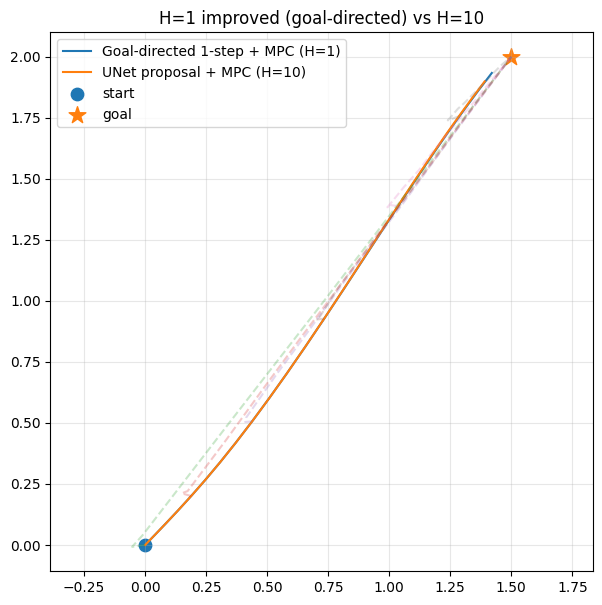

In [33]:
# =========================
# Make H=1 (single-step) proposal more goal-directed
#
# For H=1, using a stochastic UNet sample can cause drift/odd turns.
# Here we override only the H=1 proposal to be a simple goal-directed one-step reference.
# H>1 keeps using the original UNet proposal.
# =========================

import numpy as np

# keep a stable UNet-based proposer (exported by the UNet+MPC cell)
_unet_propose_ref_unet = globals().get("unet_propose_ref_unet_impl", None)
if _unet_propose_ref_unet is None:
    raise RuntimeError(
        "`unet_propose_ref_unet_impl` not found. Please re-run the UNet proposal + MPC cell first."
    )


def unet_propose_ref_single_or_k_step(
    state4_or_5: np.ndarray,
    goal_xy: np.ndarray,
    *,
    H: int = 1,
    device: str = None,
    n_ode_steps: int = 30,
    blend_strength: float = 0.95,
    blend_start_frac: float = 0.2,
    # new knobs for H=1
    step_len: float = 0.35,
) -> np.ndarray:
    """Goal-biased override for H=1; fallback to UNet proposal for H>1."""
    if int(H) == 1:
        # Give MPC a short straight-line reference of length (H_exec+1)
        # so execution is not purely myopic.
        H_exec = 10
        s = np.asarray(state4_or_5, dtype=np.float64)
        x, y = float(s[0]), float(s[1])
        g = np.asarray(goal_xy, dtype=np.float64).reshape(2)
        d = g - np.array([x, y], dtype=np.float64)
        dist = float(np.linalg.norm(d) + 1e-8)
        direction = d / dist

        p0 = np.array([x, y], dtype=np.float64)
        pts = [p0]
        for k in range(1, H_exec + 1):
            step = float(min(step_len * k, dist))
            pts.append(p0 + step * direction)
        return np.stack(pts, axis=0)  # (H_exec+1,2)

    return _unet_propose_ref_unet(
        state4_or_5,
        goal_xy,
        H=int(H),
        device=device,
        n_ode_steps=int(n_ode_steps),
        blend_strength=float(blend_strength),
        blend_start_frac=float(blend_start_frac),
    )


# -------------------------
# Quick re-run demo
# -------------------------
goal_xy = np.array([1.5, 2.0], dtype=np.float64)
state0 = np.array([0.0, 0.0, 0.8, 1.0, 0.0], dtype=np.float64)

states_H1_goal, _, _ = rollout_unet_proposal_mpc(state0, goal_xy, H=1, max_total_steps=80, dt=0.05, L=2.5, a_max=3.0)
states_H10, _, refs10 = rollout_unet_proposal_mpc(state0, goal_xy, H=10, max_total_steps=120, dt=0.05, L=2.5, a_max=3.0)

plt.figure(figsize=(7, 7))
plt.plot(states_H1_goal[:, 0], states_H1_goal[:, 1], "-", label="Goal-directed 1-step + MPC (H=1)")
plt.plot(states_H10[:, 0], states_H10[:, 1], "-", label="UNet proposal + MPC (H=10)")
for r in refs10[::max(1, len(refs10)//5)]:
    plt.plot(r[:, 0], r[:, 1], "--", alpha=0.25)
plt.scatter([state0[0]], [state0[1]], s=80, label="start")
plt.scatter([goal_xy[0]], [goal_xy[1]], s=160, marker="*", label="goal")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("H=1 improved (goal-directed) vs H=10")
plt.legend()
plt.show()


In [6]:
# ===============================================================
# CBF 投影（世界坐标）：整条轨迹版本 + 单步 wrapper
# ===============================================================

@torch.no_grad()
def cbf_project_velocity_world(
    x_1x2N: torch.Tensor,
    v_nom_1x2N: torch.Tensor,
    ellipses,
    extra_margin: float = 0.5,
    max_corr_norm: float = 2.0,
    passes: int = 5,
    # ★ 两车互相避障相关
    other_agent_traj: torch.Tensor = None,   # 允许形状 (1,2,N) 或 (2,N)
    agent_safe_radius: float = 0.5,
    # ★ 压强 + α(h) 参数
    gamma_min: float = 1.0,
    w_p: float = 5.0,
    press_k: float = 1.0,
    press_n: float = 2.0,
):
    """
    CBF 投影（世界坐标，整条轨迹版本）：
      - 对静态椭圆障碍 + 另一辆车，都加 CBF 约束
      - α(h) = γ(x) * h，其中 γ(x) = γ_min + w_p * P(x)，压强 P(x)=k/d^n

    输入:
      - x_1x2N:      (1,2,N) 当前整条轨迹（A 车位置）
      - v_nom_1x2N:  (1,2,N) 名义速度场（FM 输出）
      - ellipses:    障碍物列表（可以为 [] 或 None）
      - other_agent_traj:
            - (1,2,N) 或 (2,N)，另一辆车的整条轨迹（B 车）
    输出:
      - v_safe_1x2N: (1,2,N) 投影后的安全速度
    """
    has_ellipses = (ellipses is not None) and (len(ellipses) > 0)
    has_other = other_agent_traj is not None

    # 如果既没有障碍又没有对车，那就不用 CBF
    if (not has_ellipses) and (not has_other):
        return v_nom_1x2N

    # 允许 x_1x2N 传入 (2,N)，统一成 (1,2,N)
    if x_1x2N.dim() == 2:
        x_1x2N = x_1x2N.unsqueeze(0)
    B, D, N = x_1x2N.shape
    assert D == 2, "x_1x2N 的 shape 必须是 (B,2,N) 或 (2,N)"

    # v_nom 同样统一维度
    if v_nom_1x2N.dim() == 2:
        v_nom_1x2N = v_nom_1x2N.unsqueeze(0)

    # 为了简单，我们目前只支持 B=1 的单条轨迹
    assert B == 1, "当前实现假定 batch=1（单条轨迹），如果需要批量可再扩展"

    x_world_2N = x_1x2N.squeeze(0)  # (2,N)
    v_now = v_nom_1x2N.squeeze(0)   # (2,N)

    # ============================================================
    # 1) 计算两车之间的压强 P(x)
    # ============================================================
    if has_other:
        # 支持 (1,2,N) 或 (2,N)
        if other_agent_traj.dim() == 3:
            x_other_2N = other_agent_traj.squeeze(0)  # (2,N)
        elif other_agent_traj.dim() == 2:
            x_other_2N = other_agent_traj             # (2,N)
        else:
            raise ValueError("other_agent_traj 形状必须是 (1,2,N) 或 (2,N)")

        # delta_agent: (N,2) = x_A - x_B
        delta_agent = x_world_2N.transpose(0, 1) - x_other_2N.transpose(0, 1)  # (N,2)
        dist = torch.norm(delta_agent, dim=1).clamp_min(1e-3)                  # (N,)
        P = press_k / dist.pow(press_n)                                        # (N,)
    else:
        delta_agent = None
        dist = None
        P = torch.zeros(N, device=x_world_2N.device)

    # γ(x) = γ_min + w_p * P
    gamma_x = gamma_min + w_p * P  # (N,)

    # ============================================================
    # 2) CBF 投影主循环（多次迭代 refine）
    # ============================================================
    for _ in range(max(1, passes)):
        all_s = []
        all_a = []

        v_T = v_now.transpose(0, 1)  # (N,2)

        # ---------- (a) 静态椭圆障碍 CBF ----------
        if has_ellipses:
            for e in ellipses:
                # 你之前定义好的函数：ellipse_h_grad_batch(x, e)
                # 返回:
                #   h_e:   (N,)
                #   grad_w:(N,2)
                h_e, grad_w = ellipse_h_grad_batch(x_world_2N, e)
                h_eff = h_e - float(extra_margin)          # 安全 margin

                # α(h) = γ(x) * h
                alpha_h = gamma_x * h_eff                  # (N,)

                # CBF: ∇h·v + α(h) ≥ 0
                s_e = (grad_w * v_T).sum(dim=1) + alpha_h  # (N,)

                all_s.append(s_e)
                all_a.append(grad_w)

        # ---------- (b) 两车之间的 CBF ----------
        if has_other:
            # 注意：delta_agent 和 dist 在上面已经算过
            # h_agent(x) = ||x - x_other||^2 - R_safe^2
            h_agent = dist**2 - agent_safe_radius**2      # (N,)
            grad_agent = 2.0 * delta_agent                # (N,2)

            alpha_h_agent = gamma_x * h_agent             # (N,)
            s_agent = (grad_agent * v_T).sum(dim=1) + alpha_h_agent

            all_s.append(s_agent)
            all_a.append(grad_agent)

        if len(all_s) == 0:
            # 没有任何约束
            break

        S_cat = torch.stack(all_s, dim=0)          # (E,N)
        s_min, idx_min = torch.min(S_cat, dim=0)   # (N,)

        A_cat = torch.stack(all_a, dim=0)          # (E,N,2)
        a_pick = A_cat.gather(
            0,
            idx_min.view(1, -1, 1).expand(1, S_cat.size(1), 2)
        ).squeeze(0)  # (N,2)

        # ---------- 只修正违反约束的点 ----------
        mask = (s_min < 0.0)
        if mask.any():
            a_sq = (a_pick ** 2).sum(dim=1).clamp_min(1e-12)
            coef = torch.zeros_like(s_min)
            coef[mask] = -s_min[mask] / a_sq[mask]     # λ = -s / ||a||^2

            delta = (coef.view(1, -1) * a_pick.transpose(0, 1))  # (2,N)

            if max_corr_norm > 0:
                dnorm = delta.norm(dim=0).clamp_min(1e-12)
                scale = torch.clamp(max_corr_norm / dnorm, max=1.0)
                delta = delta * scale

            v_now = v_now + delta

    return v_now.unsqueeze(0)  # (1,2,N)


# ===============================================================
# 单步版本 wrapper：方便在 rollout 的 for k in range(T) 里调用
# ===============================================================

@torch.no_grad()
def cbf_project_velocity_step(
    x_now_2: torch.Tensor,          # (2,)  当前 A 车位置
    v_nom_2: torch.Tensor,          # (2,)  名义速度
    ellipses,
    other_agent_pos_2: torch.Tensor = None,  # (2,) 当前 B 车位置
    agent_safe_radius: float = 0.5,
    extra_margin: float = 0.5,
    max_corr_norm: float = 2.0,
    gamma_min: float = 1.0,
    w_p: float = 5.0,
    press_k: float = 1.0,
    press_n: float = 2.0,
):
    """
    单步 CBF 投影，专为在线仿真准备：
      输入单个时刻的 x_A, v_nom, x_B
      内部自动扩展成 (1,2,1)，调用上面的 cbf_project_velocity_world。
    """
    device = x_now_2.device
    x_traj = x_now_2.view(1, 2, 1)      # (1,2,1)
    v_traj = v_nom_2.view(1, 2, 1)      # (1,2,1)

    if other_agent_pos_2 is not None:
        other_traj = other_agent_pos_2.view(1, 2, 1)   # (1,2,1)
    else:
        other_traj = None

    v_safe_traj = cbf_project_velocity_world(
        x_traj,
        v_traj,
        ellipses,
        extra_margin=extra_margin,
        max_corr_norm=max_corr_norm,
        passes=5,
        other_agent_traj=other_traj,
        agent_safe_radius=agent_safe_radius,
        gamma_min=gamma_min,
        w_p=w_p,
        press_k=press_k,
        press_n=press_n,
    )  # (1,2,1)

    v_safe_2 = v_safe_traj.squeeze(0).squeeze(-1)  # (2,)
    return v_safe_2


In [ ]:
# ===============================================================
# NEW CELL: Virtual obstacle canonicalization (dataset augmentation)
#
# Goal: train a model that generalizes to different obstacle placements by canonicalizing geometry.
#   - For each trajectory: sample a VIRTUAL obstacle center near the start-goal line + lateral offset
#   - Canonical frame:
#       * translate start -> origin
#       * rotate so goal lies on +x axis
#       * reflect if needed so obstacle is always on +y ("left")
#   - Apply the same transform to trajectory states + controls.
#   - New dataset: (u_seq, cond) where cond includes (goal_dist, obs_x, obs_y, ...)
#
# Notes on reflection:
#   - reflect across x-axis => y -> -y, theta -> -theta, delta -> -delta, delta_rate -> -delta_rate
#   - acceleration a unchanged
# ===============================================================

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

if "data" not in globals() or (not isinstance(data, dict)) or ("params" not in data):
    raise RuntimeError("Need `data['params']` in globals to get dt/L/etc.")

# Always use current data
traj_xy_np = np.asarray(data["traj_xy"], dtype=np.float32)


def _wrap_pi(a: float) -> float:
    return float((a + np.pi) % (2 * np.pi) - np.pi)


def _rot2(a: float) -> np.ndarray:
    ca, sa = float(np.cos(a)), float(np.sin(a))
    return np.array([[ca, -sa], [sa, ca]], dtype=np.float64)


def sample_virtual_obstacle(start_xy, goal_xy, *, alpha_range=(0.25, 0.75), offset_range=(0.15, 0.55), rng=None):
    """Sample obstacle near start-goal line with lateral offset."""
    if rng is None:
        rng = np.random.default_rng()

    s = np.asarray(start_xy, dtype=np.float64).reshape(2)
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    d = g - s
    dn = float(np.linalg.norm(d) + 1e-12)
    u = d / dn
    n = np.array([-u[1], u[0]], dtype=np.float64)  # left normal

    alpha = float(rng.uniform(alpha_range[0], alpha_range[1]))
    off = float(rng.uniform(offset_range[0], offset_range[1]))

    c = s + alpha * d + off * n
    return c


def canonicalize_episode(traj_T2, goal_xy, obs_xy):
    """Return canonicalized (traj, cond, meta).

    traj_T2: (T,2) [x,y]
    goal_xy: (2,)
    obs_xy: (2,)

    Outputs:
      traj_can: (T,2)
      cond: (cond_dim,)  -> [goal_dist, obs_x, obs_y]
      meta: dict with transform params for inverse mapping
    """

    tr = np.asarray(traj_T2, dtype=np.float64)
    T = tr.shape[0]

    start_xy = tr[0]

    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    obs = np.asarray(obs_xy, dtype=np.float64).reshape(2)

    # translate so start at origin
    tr_xy = tr[:, :2] - start_xy[None, :]
    g0 = g - start_xy
    o0 = obs - start_xy

    # rotate so goal lies on +x
    phi = float(np.arctan2(g0[1], g0[0]))
    R = _rot2(-phi)
    tr_xy = (R @ tr_xy.T).T
    g_can = (R @ g0.reshape(2, 1)).reshape(2)
    o_can = (R @ o0.reshape(2, 1)).reshape(2)

    reflect = False
    if float(o_can[1]) < 0.0:
        reflect = True
        tr_xy[:, 1] *= -1.0
        o_can[1] *= -1.0
        g_can[1] *= -1.0

    goal_dist = float(np.linalg.norm(g0))
    cond = np.array(
        [
            goal_dist,
            float(o_can[0]),
            float(o_can[1]),
        ],
        dtype=np.float64,
    )

    meta = {
        "start_xy": start_xy,
        "phi": phi,
        "reflect": reflect,
        "goal_can": g_can,
        "obs_can": o_can,
    }

    return tr_xy, cond, meta


def decanonicalize_xy(xy_can, meta):
    """Inverse transform from canonical frame back to world XY.

    xy_can: (...,2)
    meta: {start_xy, phi, reflect}
    """
    xy = np.asarray(xy_can, dtype=np.float64)
    xy_flat = xy.reshape(-1, 2).copy()

    if bool(meta.get("reflect", False)):
        xy_flat[:, 1] *= -1.0

    R = _rot2(float(meta["phi"]))  # inverse rotation
    xy_flat = (R @ xy_flat.T).T
    xy_flat = xy_flat + np.asarray(meta["start_xy"], dtype=np.float64).reshape(1, 2)

    return xy_flat.reshape(xy.shape)


class CanonicalVirtualObstacleTrajDataset(Dataset):
    def __init__(
        self,
        traj_xy: np.ndarray,
        goals: np.ndarray,
        *,
        n_virtual: int = 1,
        alpha_range=(0.25, 0.75),
        offset_range=(0.15, 0.55),
        seed: int = 0,
        return_meta: bool = False,
    ):
        self.traj_xy = np.asarray(traj_xy, dtype=np.float64)   # (N,2,T)
        self.goals = np.asarray(goals, dtype=np.float64)
        self.n_virtual = int(n_virtual)
        self.alpha_range = alpha_range
        self.offset_range = offset_range
        self.rng = np.random.default_rng(int(seed))
        self.return_meta = bool(return_meta)

        assert self.traj_xy.ndim == 3 and self.traj_xy.shape[1] == 2
        assert self.goals.ndim == 2 and self.goals.shape[1] == 2

    def __len__(self):
        return int(self.traj_xy.shape[0]) * int(self.n_virtual)

    def __getitem__(self, idx):
        # map to original episode index + augmentation index
        epi = int(idx // self.n_virtual)

        tr = self.traj_xy[epi].T   # (T,2)
        g = self.goals[epi]        # (2,)

        # sample virtual obstacle
        start_xy = tr[0]
        obs = sample_virtual_obstacle(
            start_xy,
            g,
            alpha_range=self.alpha_range,
            offset_range=self.offset_range,
            rng=self.rng,
        )

        tr_can, cond, meta = canonicalize_episode(tr, g, obs)

        # trajectory sequence, channel-first for Conv1d
        traj_seq = tr_can.T.astype(np.float32)     # (2, T)
        cond = cond.astype(np.float32)            # (3,)

        if self.return_meta:
            return torch.from_numpy(traj_seq), torch.from_numpy(cond), meta

        return torch.from_numpy(traj_seq), torch.from_numpy(cond)


# -------------------------
# Build canonicalized dataset
# -------------------------
goals_np = np.asarray(data["goals"], dtype=np.float64)

canon_ds = CanonicalVirtualObstacleTrajDataset(
    traj_xy_np,
    goals_np,
    n_virtual=4,
    alpha_range=(0.25, 0.75),
    offset_range=(0.15, 0.60),
    seed=123,
    return_meta=True,
)

canon_loader = DataLoader(canon_ds, batch_size=64, shuffle=True, drop_last=True)

x_ex, cond_ex, meta_ex = canon_ds[0]
print("Canonical dataset size:", len(canon_ds))
print("traj_seq shape:", tuple(x_ex.shape), "cond shape:", tuple(cond_ex.shape))
print("cond = [goal_dist, obs_x, obs_y] ->", cond_ex.numpy())
print("meta:", meta_ex)



Canonical dataset size: 400
u_seq shape: (2, 59) cond shape: (6,)
cond = [goal_dist, obs_x, obs_y, v0, theta0, delta0] -> [ 3.          1.7735277   0.17421946  0.25       -1.420276    0.        ]


In [13]:
# ===============================================================
# NEW CELL: Train a control-UNet on canonicalized virtual-obstacle data
#
# This produces `model_u_obs` which can be used at inference by:
#   - canonicalize current (state, goal, obstacle)
#   - sample u_seq in canonical
#   - un-canonicalize u_seq (only needs reflection sign flip of delta_rate)
# ===============================================================

import torch
import torch.nn as nn

if "canon_loader" not in globals():
    raise RuntimeError("Please run the virtual-obstacle canonicalization dataset cell first (it defines canon_loader).")

# Reuse SimpleUNet1D if defined, else error
if "SimpleUNet1D" not in globals():
    raise RuntimeError("SimpleUNet1D not found. Please run the Control-UNet definition cell first.")

# -------- model --------
COND_DIM_OBS = 6
model_u_obs = SimpleUNet1D(time_emb_dim=128, hidden_dim=128, cond_dim=COND_DIM_OBS).to(device)
optimizer_u_obs = torch.optim.Adam(model_u_obs.parameters(), lr=1e-3)

# -------- FM training pieces (reuse if available) --------
if "CondOTScheduler" not in globals() or "AffinePath" not in globals():
    raise RuntimeError("Need CondOTScheduler/AffinePath. Please run the FM components cell first.")

scheduler = CondOTScheduler()
path = AffinePath(scheduler)

# Training hyperparams
EPOCHS = 8
LOG_EVERY = 100

model_u_obs.train()
step = 0
for ep in range(int(EPOCHS)):
    for u_seq, cond in canon_loader:
        u_seq = u_seq.to(device)   # (B,2,T)
        cond = cond.to(device)     # (B,6)

        B = u_seq.shape[0]
        # sample endpoints
        x0 = torch.randn_like(u_seq) * 1.0
        x1 = u_seq

        # time
        t = torch.rand(B, device=device)
        ps = path.sample(x0, x1, t)
        x_t = ps.x_t
        dx_t = ps.dx_t

        v_pred = model_u_obs(x_t, t, cond=cond)
        loss = torch.mean((v_pred - dx_t) ** 2)

        optimizer_u_obs.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_u_obs.parameters(), 1.0)
        optimizer_u_obs.step()

        if step % int(LOG_EVERY) == 0:
            print(f"[train model_u_obs] ep={ep} step={step} loss={loss.item():.6f}")
        step += 1

print("✅ Trained `model_u_obs` (canonical virtual obstacle).")



[train model_u_obs] ep=0 step=0 loss=1.536121
✅ Trained `model_u_obs` (canonical virtual obstacle).


[step 000] dist=3.000 bestJ=315.37 reflect=False v=0.32
[step 020] dist=2.427 bestJ=20.13 reflect=False v=1.28


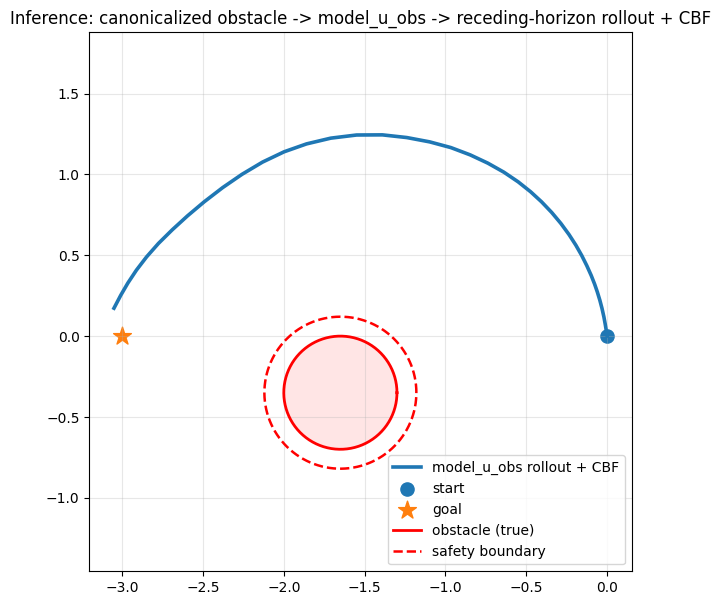

In [ ]:
# ===============================================================
# NEW CELL: Inference + rollout with canonicalized virtual-obstacle model `model_u_obs`
#
# At each step (receding horizon):
#   1) canonicalize geometry wrt current position:
#        - translate current pos -> origin
#        - rotate so goal direction is +x
#        - reflect so obstacle is on +y (left)
#   2) build cond = [goal_dist, obs_x, obs_y, v0, cos(theta0_can), sin(theta0_can), delta0_can]
#      (optionally compensate obs_y with car width change)
#   3) sample K control sequences u=[a,delta_rate] from `model_u_obs`
#   4) evaluate first H steps in CANONICAL frame with obstacle clearance cost
#   5) execute u0 in REAL frame, with CBF projection for safety
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

if "model_u_obs" not in globals():
    raise RuntimeError("`model_u_obs` not found. Please run the canonical-obstacle training cell first.")

if "CTRL_T" not in globals():
    raise RuntimeError("`CTRL_T` not found. Please run the dataset loading cell first.")

if "cbf_project_velocity_step" not in globals() and "cbf_project_velocity_world" not in globals():
    raise RuntimeError("CBF projector not found. Please run the CBF cell first.")


def _wrap_pi(a: float) -> float:
    return float((a + np.pi) % (2 * np.pi) - np.pi)


def _rot2(a: float) -> np.ndarray:
    ca, sa = float(np.cos(a)), float(np.sin(a))
    return np.array([[ca, -sa], [sa, ca]], dtype=np.float64)


def canonicalize_step(state5, goal_xy, obs_xy, *, car_width_ref=0.32, car_width_new=0.32):
    """Canonicalize a single step around CURRENT state.

    Returns:
      - state_can5: [0,0,theta_can,v,delta_can]
      - goal_dist
      - obs_can (2,)
      - cond (6,)
      - meta (start_xy, phi, reflect)

    Width compensation (from your note):
      d'_obs = d_obs + (W_new - W_ref)/2  applied on obs_y in canonical frame.
    """
    s = np.asarray(state5, dtype=np.float64).copy()
    start_xy = s[:2].copy()
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    o = np.asarray(obs_xy, dtype=np.float64).reshape(2)

    g0 = g - start_xy
    o0 = o - start_xy

    goal_dist = float(np.linalg.norm(g0) + 1e-12)

    # rotate so goal on +x
    phi = float(np.arctan2(g0[1], g0[0]))
    R = _rot2(-phi)
    o_can = (R @ o0.reshape(2, 1)).reshape(2)

    reflect = False
    if float(o_can[1]) < 0.0:
        reflect = True
        o_can[1] *= -1.0

    # width compensation in canonical lateral offset (obs_y)
    comp = 0.5 * float(car_width_new - car_width_ref)
    o_can_adj = o_can.copy()
    o_can_adj[1] = float(o_can_adj[1] + comp)

    # angles
    theta_can = _wrap_pi(float(s[2]) - phi)
    delta_can = float(s[4])
    if reflect:
        theta_can = -theta_can
        delta_can = -delta_can

    state_can = np.array([0.0, 0.0, theta_can, float(s[3]), delta_can], dtype=np.float64)

    cond = np.array([
        goal_dist,
        float(o_can_adj[0]),
        float(o_can_adj[1]),
        float(s[3]),
        float(theta_can),
        float(delta_can),
    ], dtype=np.float64)

    meta = {
        "start_xy": start_xy,
        "phi": phi,
        "reflect": reflect,
        "obs_can": o_can,
        "obs_can_adj": o_can_adj,
        "goal_dist": goal_dist,
    }

    return state_can, goal_dist, o_can_adj, cond, meta


def uncanonicalize_u0(u0_can, *, reflect: bool):
    """Map control back from canonical to real.

    For rotation: a and delta_rate are vehicle-frame, invariant.
    For reflection across x-axis: delta_rate flips sign; acceleration unchanged.
    """
    u = np.asarray(u0_can, dtype=np.float64).reshape(2).copy()
    if reflect:
        u[1] = -u[1]
    return u


def sample_u_seq_from_model(model_u, cond_vec, ctrl_T, *, n_steps=60, device="cpu", noise_scale=1.0):
    dev = torch.device(device)
    model_u.eval()

    cond = torch.as_tensor(cond_vec, dtype=torch.float32, device=dev).view(1, -1)
    x = torch.randn(1, 2, int(ctrl_T), device=dev) * float(noise_scale)
    t_grid = torch.linspace(0.0, 1.0, int(n_steps) + 1, device=dev)

    with torch.no_grad():
        for i in range(int(n_steps)):
            t = t_grid[i].view(1)
            v = model_u(x, t, cond=cond)
            if v.shape[-1] != x.shape[-1]:
                Lmin = min(v.shape[-1], x.shape[-1])
                v = v[..., :Lmin]
                x = x[..., :Lmin]
            dt_local = float(t_grid[i + 1] - t_grid[i])
            x = x + dt_local * v

    u_seq = x[0].detach().cpu().numpy().astype(np.float64)  # (2,T)
    return u_seq.T  # (T,2)


def apply_cbf_to_xy(xy, v_nom_xy, ellipses, *, extra_margin, max_corr_norm, gamma_min, device):
    dev = torch.device(device)
    x_now_2 = torch.as_tensor(np.asarray(xy, dtype=np.float64), dtype=torch.float32, device=dev)
    v_nom_2 = torch.as_tensor(np.asarray(v_nom_xy, dtype=np.float64), dtype=torch.float32, device=dev)

    if "cbf_project_velocity_step" in globals():
        v_safe_2 = cbf_project_velocity_step(
            x_now_2,
            v_nom_2,
            ellipses,
            other_agent_pos_2=None,
            agent_safe_radius=0.5,
            extra_margin=float(extra_margin),
            max_corr_norm=float(max_corr_norm),
            gamma_min=float(gamma_min),
            w_p=0.0,
            press_k=1.0,
            press_n=2.0,
        )
        return v_safe_2.detach().cpu().numpy().astype(np.float64)

    x_traj = x_now_2.view(1, 2, 1)
    v_traj = v_nom_2.view(1, 2, 1)
    v_safe = cbf_project_velocity_world(
        x_traj,
        v_traj,
        ellipses=ellipses,
        extra_margin=float(extra_margin),
        max_corr_norm=float(max_corr_norm),
        passes=5,
        other_agent_traj=None,
        agent_safe_radius=0.5,
        gamma_min=float(gamma_min),
        w_p=0.0,
        press_k=1.0,
        press_n=2.0,
    )
    return v_safe.squeeze(0).squeeze(-1).detach().cpu().numpy().astype(np.float64)


def rollout_model_u_obs_with_real_obstacle(
    *,
    model_u_obs,
    init_state5,
    goal_xy,
    obstacle_center,
    obstacle_radius,
    safety_margin=0.12,
    # vehicle
    dt=0.1,
    L=0.8,
    delta_max=np.deg2rad(30.0),
    a_max=0.8,
    delta_rate_max=np.deg2rad(120.0),
    v_floor=0.25,
    # MPC
    H=12,
    K=24,
    max_steps=240,
    goal_tol=0.18,
    # sampling
    n_steps_sample=60,
    noise_scale=1.0,
    # costs
    w_goal=40.0,
    w_u=0.05,
    w_du=0.15,
    w_clear=0.40,
    # CBF
    gamma_min=6.0,
    max_corr_norm=10.0,
    device="cpu",
    # width compensation
    car_width_ref=0.32,
    car_width_new=0.32,
    debug_every=20,
):
    goal = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    c_real = np.asarray(obstacle_center, dtype=np.float64).reshape(2)
    R_true = float(obstacle_radius)
    R_safe = float(obstacle_radius) + float(safety_margin)

    # Real-frame ellipse for CBF (circle)
    ell_real = [{"center": c_real.copy(), "radius": float(R_true)}]

    def clearance_cost_real(xy):
        # soft cost on safe boundary
        h = float(np.sum((xy - c_real) ** 2) - R_safe * R_safe)
        if h < 0.0:
            return 1e6
        return 1.0 / (h + 1e-6)

    state = np.asarray(init_state5, dtype=np.float64).copy()
    state[3] = max(float(state[3]), float(v_floor))

    xs = [state[:2].copy()]
    us = []

    u_last = np.zeros(2, dtype=np.float64)

    for step in range(int(max_steps)):
        dist = float(np.linalg.norm(state[:2] - goal))
        if dist <= float(goal_tol):
            break

        # canonicalize wrt current state
        state_can, goal_dist, obs_can, cond, meta = canonicalize_step(
            state,
            goal,
            c_real,
            car_width_ref=float(car_width_ref),
            car_width_new=float(car_width_new),
        )

        # canonical obstacle ellipse for evaluation
        ell_can = [{"center": np.asarray(obs_can, dtype=np.float64).reshape(2), "radius": float(R_true)}]

        def clearance_cost_can(xy_can):
            c = np.asarray(obs_can, dtype=np.float64).reshape(2)
            h = float(np.sum((xy_can - c) ** 2) - R_safe * R_safe)
            if h < 0.0:
                return 1e6
            return 1.0 / (h + 1e-6)

        best_J = float("inf")
        best_u0_can = None

        # sample candidates in canonical frame
        for k in range(int(K)):
            u_seq = sample_u_seq_from_model(
                model_u_obs,
                cond.astype(np.float32),
                ctrl_T=int(CTRL_T),
                n_steps=int(n_steps_sample),
                device=str(device),
                noise_scale=float(noise_scale) * (1.0 + 0.04 * k),
            )

            # clip
            u_seq[:, 0] = np.clip(u_seq[:, 0], -float(a_max), float(a_max))
            u_seq[:, 1] = np.clip(u_seq[:, 1], -float(delta_rate_max), float(delta_rate_max))

            s = state_can.copy()  # canonical state (x,y start at 0)
            J = 0.0
            prev_u = u_last.copy()

            for t in range(int(H)):
                u = u_seq[t]
                # control cost
                J += w_u * float(u[0] * u[0] + u[1] * u[1])
                du = u - prev_u
                J += w_du * float(du[0] * du[0] + du[1] * du[1])
                prev_u = u

                # integrate v/theta/delta (canonical)
                x, y, th, v, delta = [float(z) for z in s]
                a, d_rate = float(u[0]), float(u[1])
                delta = float(np.clip(delta + dt * d_rate, -float(delta_max), float(delta_max)))
                v = float(max(0.0, v + dt * a))
                th = _wrap_pi(th + dt * (v / float(L)) * np.tan(delta))

                v_nom_xy = np.array([v * np.cos(th), v * np.sin(th)], dtype=np.float64)
                v_safe_xy = apply_cbf_to_xy(
                    np.array([x, y], dtype=np.float64),
                    v_nom_xy,
                    ell_can,
                    extra_margin=float(safety_margin),
                    max_corr_norm=float(max_corr_norm),
                    gamma_min=float(gamma_min),
                    device=str(device),
                )

                x = float(x + dt * v_safe_xy[0])
                y = float(y + dt * v_safe_xy[1])

                s = np.array([x, y, th, v, delta], dtype=np.float64)

                J += w_clear * float(clearance_cost_can(s[:2]))

            # terminal goal in canonical is (goal_dist, 0)
            goal_can = np.array([goal_dist, 0.0], dtype=np.float64)
            J += w_goal * float(np.sum((s[:2] - goal_can) ** 2))

            if J < best_J:
                best_J = J
                best_u0_can = u_seq[0].copy()

        if best_u0_can is None:
            best_u0_can = np.array([-0.2 * float(a_max), 0.0], dtype=np.float64)

        # map control back to real (reflection only)
        u0_real = uncanonicalize_u0(best_u0_can, reflect=bool(meta["reflect"]))
        u0_real[0] = float(np.clip(u0_real[0], -float(a_max), float(a_max)))
        u0_real[1] = float(np.clip(u0_real[1], -float(delta_rate_max), float(delta_rate_max)))

        # execute one step in REAL frame with CBF
        x, y, th, v, delta = [float(z) for z in state]
        a, d_rate = float(u0_real[0]), float(u0_real[1])
        delta = float(np.clip(delta + dt * d_rate, -float(delta_max), float(delta_max)))
        v = float(max(float(v_floor), v + dt * a))
        th = _wrap_pi(th + dt * (v / float(L)) * np.tan(delta))

        v_nom_xy = np.array([v * np.cos(th), v * np.sin(th)], dtype=np.float64)
        v_safe_xy = apply_cbf_to_xy(
            np.array([x, y], dtype=np.float64),
            v_nom_xy,
            ell_real,
            extra_margin=float(safety_margin),
            max_corr_norm=float(max_corr_norm),
            gamma_min=float(gamma_min),
            device=str(device),
        )
        x = float(x + dt * v_safe_xy[0])
        y = float(y + dt * v_safe_xy[1])

        state = np.array([x, y, th, v, delta], dtype=np.float64)
        xs.append(state[:2].copy())
        us.append(u0_real.copy())
        u_last = best_u0_can.copy()  # keep last in canonical sense (works well with reflect flip)

        if debug_every is not None and step % int(debug_every) == 0:
            print(f"[step {step:03d}] dist={dist:.3f} bestJ={best_J:.2f} reflect={meta['reflect']} v={state[3]:.2f}")

    return np.asarray(xs, dtype=np.float64), np.asarray(us, dtype=np.float64), ell_real, R_safe


# -------------------------
# RUN DEMO
# -------------------------
# init state from dataset if present
if "states_np" in globals():
    s0 = np.asarray(states_np[0, 0], dtype=np.float64)
else:
    s0 = np.array([0.0, 0.0, 0.8, 0.25, 0.0], dtype=np.float64)

# goal: use dataset goal if available
if "data" in globals() and isinstance(data, dict) and ("goals" in data):
    goal = np.asarray(data["goals"][0], dtype=np.float64)
elif "goal_xy" in globals():
    goal = np.asarray(goal_xy, dtype=np.float64)
else:
    goal = np.array([3.0, 0.0], dtype=np.float64)

# obstacle: place between start-goal with lateral offset (you can set your real obstacle here)
start_xy = s0[:2]
d = goal - start_xy
u = d / (np.linalg.norm(d) + 1e-12)
n = np.array([-u[1], u[0]], dtype=np.float64)
obs_center = start_xy + 0.55 * d + 0.35 * n
R_obs = 0.35

# params from data if available
if "data" in globals() and isinstance(data, dict) and ("params" in data):
    dt = float(data["params"].get("dt", 0.1))
    L = float(data["params"].get("L", 0.8))
    delta_max = float(data["params"].get("delta_max", np.deg2rad(30.0)))
    a_max = float(data["params"].get("a_max", 0.8))
    delta_rate_max = float(data["params"].get("delta_rate_max", np.deg2rad(120.0)))
else:
    dt, L = 0.1, 0.8
    delta_max = float(np.deg2rad(30.0))
    a_max = 0.8
    delta_rate_max = float(np.deg2rad(120.0))

xs_can, us_can, ell_real, R_safe = rollout_model_u_obs_with_real_obstacle(
    model_u_obs=model_u_obs,
    init_state5=s0,
    goal_xy=goal,
    obstacle_center=obs_center,
    obstacle_radius=R_obs,
    safety_margin=float(globals().get("safety_margin", 0.12)),
    dt=float(dt),
    L=float(L),
    delta_max=float(delta_max),
    a_max=float(a_max),
    delta_rate_max=float(delta_rate_max),
    v_floor=0.25,
    H=12,
    K=24,
    max_steps=260,
    goal_tol=0.18,
    n_steps_sample=60,
    noise_scale=1.0,
    w_goal=40.0,
    w_u=0.05,
    w_du=0.15,
    w_clear=0.40,
    gamma_min=6.0,
    max_corr_norm=10.0,
    device=str(globals().get("device", "cpu")),
    car_width_ref=0.32,
    car_width_new=0.32,
    debug_every=20,
)

# Plot
th = np.linspace(0, 2 * np.pi, 360)
plt.figure(figsize=(7, 7))
plt.plot(xs_can[:, 0], xs_can[:, 1], "-", linewidth=2.6, label="model_u_obs rollout + CBF")
plt.scatter([xs_can[0, 0]], [xs_can[0, 1]], s=90, label="start")
plt.scatter([goal[0]], [goal[1]], s=180, marker="*", label="goal")

c = np.asarray(obs_center, dtype=np.float64).reshape(2)
plt.plot(c[0] + float(R_obs) * np.cos(th), c[1] + float(R_obs) * np.sin(th), "r-", linewidth=2.0, label="obstacle (true)")
plt.fill(c[0] + float(R_obs) * np.cos(th), c[1] + float(R_obs) * np.sin(th), color="red", alpha=0.10)
plt.plot(c[0] + float(R_safe) * np.cos(th), c[1] + float(R_safe) * np.sin(th), "r--", linewidth=1.8, label="safety boundary")

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("Inference: canonicalized obstacle -> model_u_obs -> receding-horizon rollout + CBF")
plt.legend()
plt.show()



In [ ]:
# ===============================================================
# NEW CELL (corrected): Canonical goal-only training set (NO obstacle conditioning)
#
# Why:
#   - Your dataset is obstacle-free, so labels (u_seq) contain no obstacle info.
#   - Conditioning on obs would encourage the network to ignore obs (correct behavior),
#     but it won't learn obstacle-reactive controls.
#
# What we do:
#   - Canonicalize by GOAL direction only (translate start -> origin, rotate goal -> +x)
#   - Random reflect w.p. 0.5 to enforce left/right equivariance
#   - Train model to generate u_seq in this canonical frame.
#   - Obstacle avoidance will be handled at inference by a geometric action-mapping correction.
# ===============================================================

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

if "data" not in globals() or (not isinstance(data, dict)):
    raise RuntimeError("Need `data` in globals.")

# Always use current data
states_np = np.asarray(data["states"], dtype=np.float32)
controls_np = np.asarray(data["controls"], dtype=np.float32)
goals_np = np.asarray(data["goals"], dtype=np.float64)


def _wrap_pi(a: float) -> float:
    return float((a + np.pi) % (2 * np.pi) - np.pi)


def _rot2(a: float) -> np.ndarray:
    ca, sa = float(np.cos(a)), float(np.sin(a))
    return np.array([[ca, -sa], [sa, ca]], dtype=np.float64)


def canonicalize_goal_only(states_T5, controls_T2, goal_xy, *, do_reflect: bool):
    """Canonicalize by goal direction.

    states_T5: (T,5) [x,y,theta,v,delta]
    controls_T2: (T,2) padded, last row 0

    reflect (x-axis in canonical): y->-y, theta->-theta, delta->-delta, delta_rate->-delta_rate
    """
    st = np.asarray(states_T5, dtype=np.float64)
    u = np.asarray(controls_T2, dtype=np.float64).copy()

    start = st[0, :2].copy()
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)

    # translate
    xy = st[:, :2] - start[None, :]
    g0 = g - start

    # rotate goal to +x
    phi = float(np.arctan2(g0[1], g0[0]))
    R = _rot2(-phi)
    xy = (R @ xy.T).T

    th = np.array([_wrap_pi(float(a) - phi) for a in st[:, 2]], dtype=np.float64)
    delta = np.asarray(st[:, 4], dtype=np.float64)

    if bool(do_reflect):
        xy[:, 1] *= -1.0
        th = -th
        delta = -delta
        u[:-1, 1] = -u[:-1, 1]  # delta_rate flip

    st_can = st.copy()
    st_can[:, 0] = xy[:, 0]
    st_can[:, 1] = xy[:, 1]
    st_can[:, 2] = th
    st_can[:, 4] = delta

    goal_dist = float(np.linalg.norm(g0) + 1e-12)

    # cond without obstacle (and without goal_dist to reduce goal-distribution shift):
    #   [v0, theta0_can, delta0_can]
    # Goal direction is already canonicalized (goal on +x).
    cond = np.array([
        float(st_can[0, 3]),
        float(st_can[0, 2]),
        float(st_can[0, 4]),
    ], dtype=np.float32)

    return st_can, u, cond


class CanonicalGoalControlDataset(Dataset):
    def __init__(self, states, controls, goals, *, seed=0):
        self.states = np.asarray(states, dtype=np.float64)
        self.controls = np.asarray(controls, dtype=np.float64)
        self.goals = np.asarray(goals, dtype=np.float64)
        self.rng = np.random.default_rng(int(seed))

    def __len__(self):
        return int(self.states.shape[0])

    def __getitem__(self, idx):
        st = self.states[int(idx)]
        u = self.controls[int(idx)]
        g = self.goals[int(idx)]

        do_reflect = bool(self.rng.uniform() < 0.5)
        _, u_can, cond = canonicalize_goal_only(st, u, g, do_reflect=do_reflect)

        u_seq = u_can[:-1].T.astype(np.float32)  # (2,CTRL_T)
        return torch.from_numpy(u_seq), torch.from_numpy(cond)


goals_np = np.asarray(data["goals"], dtype=np.float64)
canon_goal_ds = CanonicalGoalControlDataset(states_np, controls_np, goals_np, seed=123)
canon_goal_loader = DataLoader(canon_goal_ds, batch_size=64, shuffle=True, drop_last=True)

u_ex, cond_ex = canon_goal_ds[0]
print("canon_goal_ds size:", len(canon_goal_ds))
print("u_seq shape:", tuple(u_ex.shape), "cond shape:", tuple(cond_ex.shape))
print("cond = [v0, theta0_can, delta0_can] ->", cond_ex.numpy())



canon_goal_ds size: 100
u_seq shape: (2, 59) cond shape: (3,)
cond = [v0, theta0_can, delta0_can] -> [ 0.25     -1.420276  0.      ]


In [17]:
# ===============================================================
# NEW CELL (corrected): Train `model_u_can` on goal-canonicalized data
# ===============================================================

import torch
import torch.nn as nn

if "canon_goal_loader" not in globals():
    raise RuntimeError("Please run the goal-only canonical dataset cell first.")

if "SimpleUNet1D" not in globals():
    raise RuntimeError("SimpleUNet1D not found. Run the model definition cell first.")

if "CondOTScheduler" not in globals() or "AffinePath" not in globals():
    raise RuntimeError("Need CondOTScheduler/AffinePath. Run the FM components cell first.")

COND_DIM_CAN = 3
model_u_can = SimpleUNet1D(time_emb_dim=128, hidden_dim=128, cond_dim=COND_DIM_CAN).to(device)
optimizer_u_can = torch.optim.Adam(model_u_can.parameters(), lr=1e-3)

scheduler = CondOTScheduler()
path = AffinePath(scheduler)

EPOCHS = 8
LOG_EVERY = 100

model_u_can.train()
step = 0
for ep in range(int(EPOCHS)):
    for u_seq, cond in canon_goal_loader:
        u_seq = u_seq.to(device)  # (B,2,T)
        cond = cond.to(device)    # (B,4)

        B = u_seq.shape[0]
        x0 = torch.randn_like(u_seq)
        x1 = u_seq

        t = torch.rand(B, device=device)
        ps = path.sample(x0, x1, t)

        v_pred = model_u_can(ps.x_t, t, cond=cond)
        loss = torch.mean((v_pred - ps.dx_t) ** 2)

        optimizer_u_can.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_u_can.parameters(), 1.0)
        optimizer_u_can.step()

        if step % int(LOG_EVERY) == 0:
            print(f"[train model_u_can] ep={ep} step={step} loss={loss.item():.6f}")
        step += 1

print("✅ Trained `model_u_can` (goal-canonical, no obstacle conditioning).")



[train model_u_can] ep=0 step=0 loss=1.343399
✅ Trained `model_u_can` (goal-canonical, no obstacle conditioning).


[step 000] dist=3.000 bestJ=353.06 reflect=False v=0.25
[step 020] dist=2.861 bestJ=272.51 reflect=False v=0.47
[step 040] dist=2.264 bestJ=74.48 reflect=False v=0.80
[step 060] dist=0.570 bestJ=4.02 reflect=False v=0.73


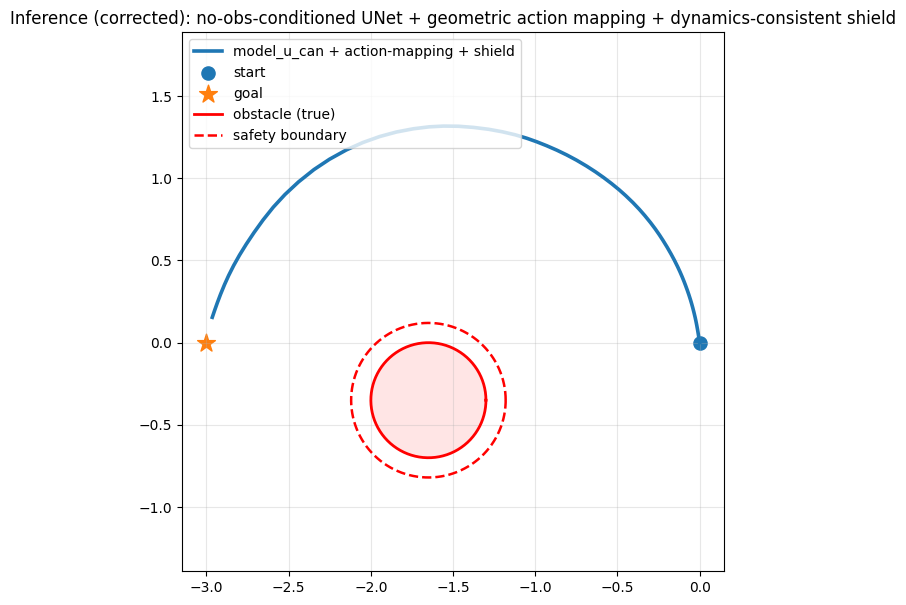

In [20]:
# ===============================================================
# NEW CELL (corrected): Inference rollout with real obstacle using
#   - model_u_can (goal-canonical, no obstacle conditioning)
#   - geometric action mapping (avoidance correction) in canonical frame
#   - dynamics-consistent rollout (pure bicycle), with shield (reject unsafe u0)
#
# This avoids the previous inconsistency of projecting world velocity with CBF
# inside a bicycle-control rollout.
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

if "model_u_can" not in globals():
    raise RuntimeError("`model_u_can` not found. Run the training cell above first.")

if "CTRL_T" not in globals():
    raise RuntimeError("CTRL_T not found.")

# Need a bicycle step
if "_step_bicycle_simple" not in globals():
    def _wrap_pi(a: float) -> float:
        return float((a + np.pi) % (2 * np.pi) - np.pi)

    def _step_bicycle_simple(state5, u, dt, L, delta_max, v_min=0.0):
        x, y, th, v, delta = [float(z) for z in state5]
        a, delta_rate = float(u[0]), float(u[1])
        delta = float(np.clip(delta + dt * delta_rate, -delta_max, delta_max))
        v = float(max(v_min, v + dt * a))
        th = _wrap_pi(th + dt * (v / float(L)) * np.tan(delta))
        x = float(x + dt * v * np.cos(th))
        y = float(y + dt * v * np.sin(th))
        return np.array([x, y, th, v, delta], dtype=np.float64)


def _rot2(a: float) -> np.ndarray:
    ca, sa = float(np.cos(a)), float(np.sin(a))
    return np.array([[ca, -sa], [sa, ca]], dtype=np.float64)


def canonicalize_runtime(state5, goal_xy, obs_xy):
    """Translate current pos->origin, rotate goal->+x, reflect so obs is +y."""
    s = np.asarray(state5, dtype=np.float64)
    p = s[:2]
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    o = np.asarray(obs_xy, dtype=np.float64).reshape(2)

    g0 = g - p
    o0 = o - p

    goal_dist = float(np.linalg.norm(g0) + 1e-12)
    phi = float(np.arctan2(g0[1], g0[0]))
    R = _rot2(-phi)

    o_can = (R @ o0.reshape(2, 1)).reshape(2)

    reflect = False
    if float(o_can[1]) < 0.0:
        reflect = True
        o_can[1] *= -1.0

    theta_can = float((float(s[2]) - phi + np.pi) % (2 * np.pi) - np.pi)
    delta_can = float(s[4])
    if reflect:
        theta_can = -theta_can
        delta_can = -delta_can

    state_can = np.array([0.0, 0.0, theta_can, float(s[3]), delta_can], dtype=np.float64)

    # cond does NOT include goal_dist to reduce distribution shift when testing arbitrary goals
    cond = np.array([float(s[3]), float(theta_can), float(delta_can)], dtype=np.float32)

    meta = {"phi": phi, "reflect": reflect, "goal_dist": goal_dist, "obs_can": o_can}
    return state_can, cond, meta


def uncanonicalize_u0(u0_can, reflect: bool):
    u = np.asarray(u0_can, dtype=np.float64).reshape(2).copy()
    if reflect:
        u[1] = -u[1]
    return u


def sample_u_seq(model, cond, ctrl_T, *, n_steps=60, device="cpu", noise_scale=1.0):
    dev = torch.device(device)
    model.eval()
    cond_t = torch.as_tensor(cond, dtype=torch.float32, device=dev).view(1, -1)

    x = torch.randn(1, 2, int(ctrl_T), device=dev) * float(noise_scale)
    t_grid = torch.linspace(0.0, 1.0, int(n_steps) + 1, device=dev)

    with torch.no_grad():
        for i in range(int(n_steps)):
            t = t_grid[i].view(1)
            v = model(x, t, cond=cond_t)
            if v.shape[-1] != x.shape[-1]:
                Lmin = min(v.shape[-1], x.shape[-1])
                v = v[..., :Lmin]
                x = x[..., :Lmin]
            x = x + float(t_grid[i + 1] - t_grid[i]) * v

    return x[0].detach().cpu().numpy().T.astype(np.float64)  # (T,2)


def circle_h(xy, c, R):
    d = np.asarray(xy, dtype=np.float64) - np.asarray(c, dtype=np.float64)
    return float(d @ d - R * R)


def apply_avoidance_action_mapping(
    u_seq_can,
    obs_can,
    *,
    R_safe,
    car_width_ref=0.32,
    car_width_new=0.32,
    # smaller + more local correction (prevents huge detours)
    k_lat=0.25,
    k_brake=0.05,
    p=2.0,
    x_gate=(0.0, 2.0),
    y_gate=0.9,
    tau=4.0,
    corr_steps=10,
):
    """Geometric correction in canonical frame.

    Key change: make the correction LOCAL and PROPORTIONAL to how much we need to clear R_safe.
    This avoids the "big loop" behavior.

    - obstacle is canonicalized to +y side.
    - to pass on the right, apply negative delta_rate.
    """
    u = np.asarray(u_seq_can, dtype=np.float64).copy()
    ox, oy = float(obs_can[0]), float(obs_can[1])

    # width compensation on lateral offset
    oy = oy + 0.5 * float(car_width_new - car_width_ref)

    # only when obstacle is ahead and close to centerline
    if not (float(x_gate[0]) <= ox <= float(x_gate[1])):
        return u
    if oy > float(y_gate):
        return u

    # how much lateral clearance we are missing (in meters)
    miss = max(0.0, float(R_safe) - abs(oy))
    if miss <= 0.0:
        return u

    # scale: smaller and bounded; decreases with oy
    strength = float(k_lat) * (miss / (abs(oy) ** float(p) + 1e-6))
    brake = float(k_brake) * (miss / (abs(oy) ** float(p) + 1e-6))

    T = int(u.shape[0])
    Tcorr = int(min(max(1, int(corr_steps)), T))
    for t in range(Tcorr):
        w = float(np.exp(-float(t) / max(1.0, float(tau))))
        u[t, 1] += -w * strength
        u[t, 0] += -w * brake

    return u


def rollout_model_u_can_with_obstacle(
    *,
    model,
    init_state5,
    goal_xy,
    obs_center,
    obs_radius,
    safety_margin=0.12,
    dt=0.1,
    L=0.8,
    delta_max=np.deg2rad(30.0),
    a_max=0.8,
    delta_rate_max=np.deg2rad(120.0),
    v_floor=0.25,
    # receding horizon
    H=12,
    K=12,
    max_steps=260,
    goal_tol=0.18,
    # sampling
    n_steps_sample=40,
    noise_scale=1.0,
    # costs
    w_goal=40.0,
    w_u=0.05,
    w_du=0.15,
    w_clear=0.50,
    w_lane=0.15,   # keep y close to 0 in canonical (prevents huge detours)
    # action mapping
    car_width_ref=0.32,
    car_width_new=0.32,
    k_lat=0.25,
    k_brake=0.05,
    p=2.0,
    device="cpu",
    debug_every=20,
):
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    c = np.asarray(obs_center, dtype=np.float64).reshape(2)
    R_true = float(obs_radius)
    R_safe = float(obs_radius) + float(safety_margin)

    state = np.asarray(init_state5, dtype=np.float64).copy()
    state[3] = max(float(state[3]), float(v_floor))

    xs = [state[:2].copy()]
    us = []

    # Keep last-applied control in REAL frame, then map into current canonical frame
    # so smoothness penalty does not break when reflect flips.
    u_last_real = np.zeros(2, dtype=np.float64)

    for step in range(int(max_steps)):
        dist = float(np.linalg.norm(state[:2] - g))
        if dist <= float(goal_tol):
            break

        # canonicalize wrt current state
        state_can, cond, meta = canonicalize_runtime(state, g, c)
        goal_dist = float(meta["goal_dist"])
        obs_can = np.asarray(meta["obs_can"], dtype=np.float64)

        # map last control into THIS canonical frame (reflection flips delta_rate)
        u_last_can0 = u_last_real.copy()
        if bool(meta["reflect"]):
            u_last_can0[1] = -u_last_can0[1]

        bestJ = float("inf")
        best_u0_can = None

        for k in range(int(K)):
            u_seq = sample_u_seq(
                model,
                cond,
                ctrl_T=int(CTRL_T),
                n_steps=int(n_steps_sample),
                device=str(device),
                noise_scale=float(noise_scale) * (1.0 + 0.04 * k),
            )

            # apply geometric avoidance correction in canonical frame
            u_seq = apply_avoidance_action_mapping(
                u_seq,
                obs_can,
                R_safe=R_safe,
                car_width_ref=float(car_width_ref),
                car_width_new=float(car_width_new),
                k_lat=float(k_lat),
                k_brake=float(k_brake),
                p=float(p),
            )

            # clip
            u_seq[:, 0] = np.clip(u_seq[:, 0], -float(a_max), float(a_max))
            u_seq[:, 1] = np.clip(u_seq[:, 1], -float(delta_rate_max), float(delta_rate_max))

            s = state_can.copy()
            J = 0.0
            prev_u = u_last_can0.copy()

            # canonical obstacle center
            c_can = obs_can.copy()

            for t in range(int(H)):
                u = u_seq[t]
                J += w_u * float(u[0] * u[0] + u[1] * u[1])
                du = u - prev_u
                J += w_du * float(du[0] * du[0] + du[1] * du[1])
                prev_u = u

                # keep forward progress; avoid getting stuck at v=0
                s = _step_bicycle_simple(s, u, float(dt), float(L), float(delta_max), v_min=float(v_floor))

                # keep close to canonical centerline unless needed (reduces big loops)
                J += float(w_lane) * float(s[1] * s[1])

                h = circle_h(s[:2], c_can, R_safe)
                if h < 0.0:
                    J += 1e6
                    break
                J += w_clear * (1.0 / (h + 1e-6))

            # terminal goal in canonical: (goal_dist, 0)
            goal_can = np.array([goal_dist, 0.0], dtype=np.float64)
            J += w_goal * float(np.sum((s[:2] - goal_can) ** 2))

            if J < bestJ:
                bestJ = J
                best_u0_can = u_seq[0].copy()

        if best_u0_can is None:
            best_u0_can = np.array([-0.2 * float(a_max), 0.0], dtype=np.float64)

        # map u0 back to real
        u0 = uncanonicalize_u0(best_u0_can, reflect=bool(meta["reflect"]))
        u0[0] = float(np.clip(u0[0], -float(a_max), float(a_max)))
        u0[1] = float(np.clip(u0[1], -float(delta_rate_max), float(delta_rate_max)))

        # shield: if next state collides, resample a few times
        ok = False
        for j in range(10):
            nxt = _step_bicycle_simple(state, u0, float(dt), float(L), float(delta_max), v_min=float(v_floor))
            if circle_h(nxt[:2], c, R_safe) >= 0.0:
                ok = True
                state = nxt
                break

            # resample and add stronger avoidance
            u_seq2 = sample_u_seq(
                model,
                cond,
                ctrl_T=int(CTRL_T),
                n_steps=int(n_steps_sample),
                device=str(device),
                noise_scale=float(noise_scale) * (1.2 + 0.10 * j),
            )
            u_seq2 = apply_avoidance_action_mapping(
                u_seq2,
                obs_can,
                R_safe=R_safe,
                car_width_ref=float(car_width_ref),
                car_width_new=float(car_width_new),
                k_lat=float(k_lat) * (1.0 + 0.25 * j),
                k_brake=float(k_brake) * (1.0 + 0.25 * j),
                p=float(p),
            )
            u0 = uncanonicalize_u0(u_seq2[0], reflect=bool(meta["reflect"]))
            u0[0] = float(np.clip(u0[0], -float(a_max), float(a_max)))
            u0[1] = float(np.clip(u0[1], -float(delta_rate_max), float(delta_rate_max)))

        if not ok:
            # final fallback: brake + steer away from obstacle
            vec = c - state[:2]
            left = np.array([-vec[1], vec[0]], dtype=np.float64)
            sign = -1.0 if float(left[1]) > 0 else 1.0
            u0 = np.array([-0.4 * float(a_max), sign * float(delta_rate_max)], dtype=np.float64)
            state = _step_bicycle_simple(state, u0, float(dt), float(L), float(delta_max), v_min=float(v_floor))

        xs.append(state[:2].copy())
        us.append(u0.copy())
        # store last applied control in REAL frame (reflection-safe)
        u_last_real = u0.copy()

        if debug_every is not None and step % int(debug_every) == 0:
            print(f"[step {step:03d}] dist={dist:.3f} bestJ={bestJ:.2f} reflect={meta['reflect']} v={state[3]:.2f}")

    return np.asarray(xs, dtype=np.float64), np.asarray(us, dtype=np.float64), R_safe


# -------------------------
# RUN DEMO
# -------------------------
# init state
if "states_np" in globals():
    s0 = np.asarray(states_np[0, 0], dtype=np.float64)
else:
    s0 = np.array([0.0, 0.0, 0.8, 0.25, 0.0], dtype=np.float64)

# goal
if "data" in globals() and isinstance(data, dict) and ("goals" in data):
    goal = np.asarray(data["goals"][0], dtype=np.float64)
else:
    goal = np.array([3.0, 0.0], dtype=np.float64)

# obstacle (real)
start_xy = s0[:2]
d = goal - start_xy
u = d / (np.linalg.norm(d) + 1e-12)
n = np.array([-u[1], u[0]], dtype=np.float64)
obs_center = start_xy + 0.55 * d + 0.35 * n
R_obs = 0.35

# params
if "data" in globals() and isinstance(data, dict) and ("params" in data):
    dt = float(data["params"].get("dt", 0.1))
    L = float(data["params"].get("L", 0.8))
    delta_max = float(data["params"].get("delta_max", np.deg2rad(30.0)))
    a_max = float(data["params"].get("a_max", 0.8))
    delta_rate_max = float(data["params"].get("delta_rate_max", np.deg2rad(120.0)))
else:
    dt, L = 0.1, 0.8
    delta_max = float(np.deg2rad(30.0))
    a_max = 0.8
    delta_rate_max = float(np.deg2rad(120.0))

xs_fix, us_fix, R_safe = rollout_model_u_can_with_obstacle(
    model=model_u_can,
    init_state5=s0,
    goal_xy=goal,
    obs_center=obs_center,
    obs_radius=R_obs,
    safety_margin=float(globals().get("safety_margin", 0.12)),
    dt=float(dt),
    L=float(L),
    delta_max=float(delta_max),
    a_max=float(a_max),
    delta_rate_max=float(delta_rate_max),
    v_floor=0.25,
    H=12,
    K=12,
    max_steps=260,
    goal_tol=0.18,
    n_steps_sample=40,
    noise_scale=1.0,
    w_goal=40.0,
    w_u=0.05,
    w_du=0.15,
    w_clear=0.50,
    car_width_ref=0.32,
    car_width_new=0.32,
    k_lat=0.8,
    k_brake=0.15,
    p=2.0,
    device=str(globals().get("device", "cpu")),
    debug_every=20,
)

# Plot
th = np.linspace(0, 2*np.pi, 360)
plt.figure(figsize=(7, 7))
plt.plot(xs_fix[:, 0], xs_fix[:, 1], "-", linewidth=2.6, label="model_u_can + action-mapping + shield")
plt.scatter([xs_fix[0, 0]], [xs_fix[0, 1]], s=90, label="start")
plt.scatter([goal[0]], [goal[1]], s=180, marker="*", label="goal")

c = np.asarray(obs_center, dtype=np.float64)
plt.plot(c[0] + R_obs*np.cos(th), c[1] + R_obs*np.sin(th), "r-", linewidth=2.0, label="obstacle (true)")
plt.fill(c[0] + R_obs*np.cos(th), c[1] + R_obs*np.sin(th), color="red", alpha=0.10)
plt.plot(c[0] + R_safe*np.cos(th), c[1] + R_safe*np.sin(th), "r--", linewidth=1.8, label="safety boundary")

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("Inference (corrected): no-obs-conditioned UNet + geometric action mapping + dynamics-consistent shield")
plt.legend()
plt.show()




[step 000] dAB=1.959  JA=229.8 JB=232.3  |dA|=2.80 |dB|=2.80
[step 020] dAB=0.684  JA=1000109.8 JB=1000121.6  |dA|=1.65 |dB|=1.75
[step 040] dAB=1.608  JA=196.0 JB=28.8  |dA|=1.99 |dB|=1.20
[step 060] dAB=1.411  JA=288.1 JB=10.3  |dA|=2.45 |dB|=0.51
[step 080] dAB=1.541  JA=396.2 JB=6.6  |dA|=2.92 |dB|=0.00
[step 100] dAB=1.872  JA=517.8 JB=23.0  |dA|=3.39 |dB|=0.50
[step 120] dAB=2.435  JA=635.5 JB=60.4  |dA|=3.81 |dB|=0.99
[step 140] dAB=3.142  JA=735.7 JB=118.2  |dA|=4.15 |dB|=1.49
[step 160] dAB=3.822  JA=803.7 JB=196.4  |dA|=4.41 |dB|=1.99
[step 180] dAB=4.408  JA=836.6 JB=282.9  |dA|=4.55 |dB|=2.46
[step 200] dAB=5.218  JA=664.7 JB=370.6  |dA|=4.48 |dB|=2.88
[step 220] dAB=5.803  JA=100.9 JB=446.3  |dA|=2.98 |dB|=3.21
[step 240] dAB=5.313  JA=10.5 JB=500.2  |dA|=0.20 |dB|=3.46


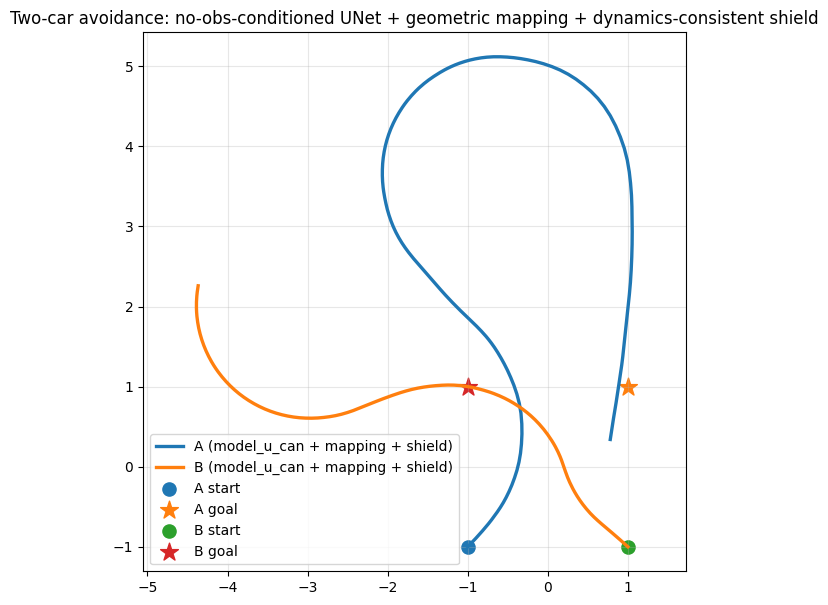

In [ ]:
# ===============================================================
# NEW CELL (corrected): Two-car avoidance with `model_u_can` + action-mapping + shield
#
# - Each car uses its own goal-canonical frame (goal -> +x).
# - The other car is treated as a moving circular obstacle (center only).
# - We apply geometric action-mapping correction in canonical frame.
# - Rollout is dynamics-consistent (pure bicycle) and uses shield (reject unsafe u0).
# - Mild priority/yield: B has stronger avoidance/brake so the symmetric case doesn't deadlock.
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

if "model_u_can" not in globals():
    raise RuntimeError("`model_u_can` not found. Run the training cell for model_u_can first.")

if "CTRL_T" not in globals():
    raise RuntimeError("CTRL_T not found.")

# Reuse helpers from the corrected single-car cell
if "canonicalize_runtime" not in globals() or "sample_u_seq" not in globals() or "apply_avoidance_action_mapping" not in globals():
    raise RuntimeError("Please run the corrected single-car inference cell above (it defines canonicalize_runtime/sample_u_seq/apply_avoidance_action_mapping).")

if "_step_bicycle_simple" not in globals():
    raise RuntimeError("_step_bicycle_simple not found.")


def circle_h(xy, c, R):
    d = np.asarray(xy, dtype=np.float64) - np.asarray(c, dtype=np.float64)
    return float(d @ d - R * R)


def plan_one_step_against_other(
    *,
    model,
    state5,
    goal_xy,
    other_pos_xy,
    other_safe_R,
    dt,
    L,
    delta_max,
    a_max,
    delta_rate_max,
    v_floor,
    H,
    K,
    n_steps_sample,
    noise_scale,
    # costs
    w_goal,
    w_u,
    w_du,
    w_clear,
    w_lane,
    # mapping
    k_lat,
    k_brake,
    p,
    # priority
    extra_brake_close=0.0,
    device="cpu",
):
    """Return (u0_real, bestJ, meta) for this car."""
    s = np.asarray(state5, dtype=np.float64).copy()
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    other = np.asarray(other_pos_xy, dtype=np.float64).reshape(2)

    # canonicalize using other as 'obs' (canonicalize_runtime reflects so obs is +y)
    state_can, cond, meta = canonicalize_runtime(s, g, other)
    goal_dist = float(meta["goal_dist"])
    obs_can = np.asarray(meta["obs_can"], dtype=np.float64)

    bestJ = float("inf")
    best_u0_can = None

    # canonical goal point is (goal_dist, 0)
    goal_can = np.array([goal_dist, 0.0], dtype=np.float64)

    # initial smoothness reference (no history passed here)
    # caller should incorporate history if desired; we keep it simple.
    u_last_can0 = np.zeros(2, dtype=np.float64)

    for k in range(int(K)):
        u_seq = sample_u_seq(
            model,
            cond,
            ctrl_T=int(CTRL_T),
            n_steps=int(n_steps_sample),
            device=str(device),
            noise_scale=float(noise_scale) * (1.0 + 0.04 * k),
        )

        # action mapping against other car (treated as circular obstacle)
        u_seq = apply_avoidance_action_mapping(
            u_seq,
            obs_can,
            R_safe=float(other_safe_R),
            k_lat=float(k_lat),
            k_brake=float(k_brake),
            p=float(p),
        )

        # clip
        u_seq[:, 0] = np.clip(u_seq[:, 0], -float(a_max), float(a_max))
        u_seq[:, 1] = np.clip(u_seq[:, 1], -float(delta_rate_max), float(delta_rate_max))

        st = state_can.copy()
        J = 0.0
        prev_u = u_last_can0.copy()

        for t in range(int(H)):
            u = u_seq[t]
            J += float(w_u) * float(u[0] * u[0] + u[1] * u[1])
            du = u - prev_u
            J += float(w_du) * float(du[0] * du[0] + du[1] * du[1])
            prev_u = u

            st = _step_bicycle_simple(st, u, float(dt), float(L), float(delta_max), v_min=float(v_floor))

            # keep near centerline in canonical
            J += float(w_lane) * float(st[1] * st[1])

            h = circle_h(st[:2], obs_can, float(other_safe_R))
            if h < 0.0:
                J += 1e6
                break
            J += float(w_clear) * (1.0 / (h + 1e-6))

        J += float(w_goal) * float(np.sum((st[:2] - goal_can) ** 2))

        if J < bestJ:
            bestJ = J
            best_u0_can = u_seq[0].copy()

    if best_u0_can is None:
        best_u0_can = np.array([-0.2 * float(a_max), 0.0], dtype=np.float64)

    # map u0 back to real (reflect flips delta_rate)
    u0 = np.asarray(best_u0_can, dtype=np.float64).copy()
    if bool(meta["reflect"]):
        u0[1] = -u0[1]

    # optional extra brake when very close
    if float(np.linalg.norm(s[:2] - other)) < float(other_safe_R) * 1.15:
        u0[0] = float(u0[0] - abs(extra_brake_close) * float(a_max))

    u0[0] = float(np.clip(u0[0], -float(a_max), float(a_max)))
    u0[1] = float(np.clip(u0[1], -float(delta_rate_max), float(delta_rate_max)))

    return u0, bestJ, meta


def rollout_two_car_model_u_can(
    *,
    model,
    stateA0,
    goalA,
    stateB0,
    goalB,
    dt=0.1,
    L=0.8,
    delta_max=np.deg2rad(30.0),
    a_max=0.8,
    delta_rate_max=np.deg2rad(120.0),
    v_floor=0.25,
    # safety radius between cars
    other_safe_R=1.0,
    # MPC sampling
    H=10,
    K=10,
    n_steps_sample=40,
    noise_scale=1.0,
    # costs
    w_goal=40.0,
    w_u=0.05,
    w_du=0.15,
    w_clear=0.45,
    w_lane=0.15,
    # mapping params
    k_lat_A=0.25,
    k_brake_A=0.05,
    k_lat_B=0.35,
    k_brake_B=0.08,
    p=2.0,
    # deadlock breaker
    extra_brake_close_B=0.25,
    max_steps=260,
    goal_tol=0.20,
    device="cpu",
    debug_every=20,
):
    sA = np.asarray(stateA0, dtype=np.float64).copy()
    sB = np.asarray(stateB0, dtype=np.float64).copy()
    gA = np.asarray(goalA, dtype=np.float64).reshape(2)
    gB = np.asarray(goalB, dtype=np.float64).reshape(2)

    sA[3] = max(float(sA[3]), float(v_floor))
    sB[3] = max(float(sB[3]), float(v_floor))

    xsA = [sA[:2].copy()]
    xsB = [sB[:2].copy()]

    for step in range(int(max_steps)):
        if float(np.linalg.norm(sA[:2] - gA)) <= float(goal_tol) and float(np.linalg.norm(sB[:2] - gB)) <= float(goal_tol):
            break

        # Plan A against current B
        uA, JA, _ = plan_one_step_against_other(
            model=model,
            state5=sA,
            goal_xy=gA,
            other_pos_xy=sB[:2],
            other_safe_R=float(other_safe_R),
            dt=float(dt),
            L=float(L),
            delta_max=float(delta_max),
            a_max=float(a_max),
            delta_rate_max=float(delta_rate_max),
            v_floor=float(v_floor),
            H=int(H),
            K=int(K),
            n_steps_sample=int(n_steps_sample),
            noise_scale=float(noise_scale),
            w_goal=float(w_goal),
            w_u=float(w_u),
            w_du=float(w_du),
            w_clear=float(w_clear),
            w_lane=float(w_lane),
            k_lat=float(k_lat_A),
            k_brake=float(k_brake_A),
            p=float(p),
            extra_brake_close=0.0,
            device=str(device),
        )

        # Plan B against current A (with stronger yield)
        uB, JB, _ = plan_one_step_against_other(
            model=model,
            state5=sB,
            goal_xy=gB,
            other_pos_xy=sA[:2],
            other_safe_R=float(other_safe_R),
            dt=float(dt),
            L=float(L),
            delta_max=float(delta_max),
            a_max=float(a_max),
            delta_rate_max=float(delta_rate_max),
            v_floor=float(v_floor),
            H=int(H),
            K=int(K),
            n_steps_sample=int(n_steps_sample),
            noise_scale=float(noise_scale),
            w_goal=float(w_goal),
            w_u=float(w_u),
            w_du=float(w_du),
            w_clear=float(w_clear),
            w_lane=float(w_lane),
            k_lat=float(k_lat_B),
            k_brake=float(k_brake_B),
            p=float(p),
            extra_brake_close=float(extra_brake_close_B),
            device=str(device),
        )

        # Predict next states
        nxtA = _step_bicycle_simple(sA, uA, float(dt), float(L), float(delta_max), v_min=float(v_floor))
        nxtB = _step_bicycle_simple(sB, uB, float(dt), float(L), float(delta_max), v_min=float(v_floor))

        # Shield: if predicted collision, force B to brake harder this step
        if float(np.linalg.norm(nxtA[:2] - nxtB[:2])) < float(other_safe_R):
            uB2 = np.array([-0.6 * float(a_max), 0.0], dtype=np.float64)
            nxtB = _step_bicycle_simple(sB, uB2, float(dt), float(L), float(delta_max), v_min=float(v_floor))
            uB = uB2

        sA, sB = nxtA, nxtB
        xsA.append(sA[:2].copy())
        xsB.append(sB[:2].copy())

        if debug_every is not None and step % int(debug_every) == 0:
            dAB = float(np.linalg.norm(sA[:2] - sB[:2]))
            print(f"[step {step:03d}] dAB={dAB:.3f}  JA={JA:.1f} JB={JB:.1f}  |dA|={np.linalg.norm(sA[:2]-gA):.2f} |dB|={np.linalg.norm(sB[:2]-gB):.2f}")

    return np.asarray(xsA, dtype=np.float64), np.asarray(xsB, dtype=np.float64)


# -------------------------
# RUN DEMO (two-car crossing)
# -------------------------
# Use the same scenario you used earlier
A0 = np.array([ -1.0, -1.0, 0.8, 0.25, 0.0 ], dtype=np.float64)
GA = np.array([ +1.0, +1.0 ], dtype=np.float64)
B0 = np.array([ +1.0, -1.0, 2.4, 0.25, 0.0 ], dtype=np.float64)
GB = np.array([ -1.0, +1.0 ], dtype=np.float64)

# params from data if available
if "data" in globals() and isinstance(data, dict) and ("params" in data):
    dt = float(data["params"].get("dt", 0.1))
    L = float(data["params"].get("L", 0.8))
    delta_max = float(data["params"].get("delta_max", np.deg2rad(30.0)))
    a_max = float(data["params"].get("a_max", 0.8))
    delta_rate_max = float(data["params"].get("delta_rate_max", np.deg2rad(120.0)))
else:
    dt, L = 0.1, 0.8
    delta_max = float(np.deg2rad(30.0))
    a_max = 0.8
    delta_rate_max = float(np.deg2rad(120.0))

xsA2, xsB2 = rollout_two_car_model_u_can(
    model=model_u_can,
    stateA0=A0,
    goalA=GA,
    stateB0=B0,
    goalB=GB,
    dt=float(dt),
    L=float(L),
    delta_max=float(delta_max),
    a_max=float(a_max),
    delta_rate_max=float(delta_rate_max),
    v_floor=0.25,
    other_safe_R=1.0,
    H=10,
    K=10,
    n_steps_sample=35,
    noise_scale=1.0,
    w_goal=40.0,
    w_u=0.05,
    w_du=0.15,
    w_clear=0.45,
    w_lane=0.15,
    k_lat_A=0.25,
    k_brake_A=0.05,
    k_lat_B=0.35,
    k_brake_B=0.08,
    p=2.0,
    extra_brake_close_B=0.25,
    max_steps=260,
    goal_tol=0.20,
    device=str(globals().get("device", "cpu")),
    debug_every=20,
)

plt.figure(figsize=(7, 7))
plt.plot(xsA2[:, 0], xsA2[:, 1], "-", linewidth=2.4, label="A (model_u_can + mapping + shield)")
plt.plot(xsB2[:, 0], xsB2[:, 1], "-", linewidth=2.4, label="B (model_u_can + mapping + shield)")
plt.scatter([xsA2[0, 0]], [xsA2[0, 1]], s=90, label="A start")
plt.scatter([GA[0]], [GA[1]], s=180, marker="*", label="A goal")
plt.scatter([xsB2[0, 0]], [xsB2[0, 1]], s=90, label="B start")
plt.scatter([GB[0]], [GB[1]], s=180, marker="*", label="B goal")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("Two-car avoidance: no-obs-conditioned UNet + geometric mapping + dynamics-consistent shield")
plt.legend()
plt.show()

